In [ ]:
# ============================================================
# STANDARDIZED SKAGIT AR ANALYSIS ENGINE (Refined)
# ============================================================
import matplotlib.pyplot as plt
from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import regionmask
import intake
import shapely
import warnings
warnings.filterwarnings('ignore')

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/skagit_met/data_transfer/data")

P_PRISM_DIR   = BASE / "prism_ppt"
P_HRRR_DIR    = BASE / "weather_data"
P_GRIDMET_DIR = BASE / "gridmet"

UCLA_PREC_DIR      = BASE / "ucla_era5_d02_daily" / "prec"
UCLA_COORD_FILE    = BASE / "ucla_era5_d02_daily" / "static" / "wrfinput_d02_coord.nc"

P_PNNL_DIR = BASE / "PNNL" / "historical"
P_PNNL_GEO = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"

HUC8_GEO     = Path("/home/nksp2/skagit/skagit_2/skagit-met/data/GIS/SkagitSubBasin_HUC8.geojson")
BOUNDARY_GEO = Path("/home/nksp2/skagit/skagit_2/skagit-met/data/GIS/SkagitBoundary.json")
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

GRAPHS_DIR = Path("/home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/graphs")
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

CONUS_INTAKE_YML = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
CONUS_MAX_TIME   = np.datetime64("2022-10-01")

# ----------------------------
# STANDARDIZED METADATA
# ----------------------------
COLORS = {
    "prism":    "#1B9E77",
    "daymet":   "#7570B3",
    "gridmet":  "#E7298A",
    "hrrr_f01": "#1F78B4",
    "hrrr_f06": "#A6CEE3",
    "ucla":     "#E6AB02",
    "pnnl":     "#D95F02",
    "conus":    "#666666",
}

EVENTS = [
    {"label": "2003", "event_year": 2003, "start": "2003-10-15", "end": "2003-10-25"},
    {"label": "2006", "event_year": 2006, "start": "2006-11-01", "end": "2006-11-10"},
    {"label": "2016", "event_year": 2016, "start": "2016-10-30", "end": "2016-11-05"},
    {"label": "2018", "event_year": 2018, "start": "2018-12-15", "end": "2018-12-21"},
    {"label": "2021", "event_year": 2021, "start": "2021-11-10", "end": "2021-11-18"},
]

In [ ]:
# ----------------------------
# STANDARD DATA LOADERS
# ----------------------------

def load_subbasin_geoms():
    if not HUC8_GEO.exists(): return {}
    gdf = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")
    name_col = next(c for c in gdf.columns if c.lower() in ("name", "names", "huc8_name", "subbasin"))
    geoms = {}
    for target in REGION_NAMES:
        sub = gdf[gdf[name_col].str.lower().str.contains(target.lower(), na=False)]
        geoms[target] = sub.geometry.unary_union if not sub.empty else None
    return geoms

def get_basin_mean(ds, var, start, end, geom, assume_accumulated=False):
    if "time" not in ds.dims and "Time" in ds.dims: ds = ds.rename({"Time": "time"})
    if "day" in ds.dims and "time" not in ds.dims: ds = ds.rename({"day": "time"})
    da = ds[var].sel(time=slice(start, end)).sortby("time")
    if da.sizes.get("time", 0) == 0: return None
    spatial_dims = [d for d in da.dims if d != "time"]
    if not spatial_dims: return da
    bm = da.mean(dim=spatial_dims, skipna=True)
    
    if assume_accumulated:
        if bm.size < 2: return bm
        d = bm.diff("time")
        curr = bm.isel(time=slice(1, None))
        inc = xr.where(d >= 0, d, curr).clip(min=0)
        return inc.resample(time="1D").sum().sortby("time")
    
    return bm.resample(time="1D").sum().sortby("time")

def load_prism(start, end, geom):
    files = sorted(list(P_PRISM_DIR.glob("*_daily_4km_PRISM_data.zarr")))
    relevant = [z for z in files if (pd.Timestamp(z.name[:10]) <= pd.Timestamp(end)) and (pd.Timestamp(z.name[11:21]) >= pd.Timestamp(start))]
    if not relevant: return None
    ds = xr.concat([xr.open_zarr(z) for z in relevant], dim="time").sortby("time")
    return get_basin_mean(ds, "ppt", start, end, geom)

def load_daymet(start, end, geom):
    from pystac_client import Client
    import planetary_computer as pc
    try:
        stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
        col = stac.get_collection("daymet-daily-na")
        ds = xr.open_zarr(pc.sign(col.assets["zarr-https"].href), **col.assets["zarr-https"].extra_fields["xarray:open_kwargs"])
        return get_basin_mean(ds, "prcp", start, end, geom)
    except: return None

def load_gridmet(start, end, geom):
    datasets = []
    for yr in range(pd.Timestamp(start).year, pd.Timestamp(end).year + 1):
        f = P_GRIDMET_DIR / f"pr_{yr}.nc"
        if f.exists(): datasets.append(xr.open_dataset(f))
    if not datasets: return None
    return get_basin_mean(xr.concat(datasets, dim="day").sortby("day"), "precipitation_amount", start, end, geom)

def load_hrrr(start, end, geom, fh_hours=1):
    parts = sorted([p for p in P_HRRR_DIR.glob("*.zarr") if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)])
    needed = {f"{p.year}-{p.month:02d}" for p in pd.period_range(pd.Timestamp(start).to_period("M"), pd.Timestamp(end).to_period("M"))}
    parts = [p for p in parts if p.name[:7] in needed]
    if not parts: return None
    ds = xr.concat([xr.open_zarr(p) for p in parts], dim="time").sortby("time")
    var = "tp" if "tp" in ds else "apcp"
    da = ds[var]
    if "step" in da.dims:
        vals = da["step"].values / np.timedelta64(1, 'h')
        idx = int(np.argmin(np.abs(vals - float(fh_hours))))
        da = da.isel(step=idx)
    elif "forecast_hour" in da.dims:
        vals = da["forecast_hour"].values.astype(float)
        idx = int(np.argmin(np.abs(vals - float(fh_hours))))
        da = da.isel(forecast_hour=idx)
    return get_basin_mean(xr.Dataset({var: da}), var, start, end, geom, assume_accumulated=False)

def load_ucla(start, end, geom):
    dsets = []
    yrs = {pd.Timestamp(start).year if pd.Timestamp(start).month >= 9 else pd.Timestamp(start).year-1, 
           pd.Timestamp(end).year if pd.Timestamp(end).month >= 9 else pd.Timestamp(end).year-1}
    for yr in sorted(yrs):
        f = UCLA_PREC_DIR / f"prec.daily.era5.d02.{yr}.nc"
        if f.exists(): dsets.append(xr.open_dataset(f))
    if not dsets: return None
    return get_basin_mean(xr.concat(dsets, dim="day").sortby("day"), "prec", start, end, geom)

def load_pnnl(yr, start, end, geom):
    f = P_PNNL_DIR / str(yr) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{yr}.nc"
    if not f.exists(): return None
    return get_basin_mean(xr.open_dataset(f), "PREC_ACC_NC", start, end, geom, assume_accumulated=False)

def load_conus(start, end, geom):
    try:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
        return get_basin_mean(ds, "PREC_ACC_NC", start, end, geom, assume_accumulated=False)
    except: return None

In [ ]:
# ----------------------------
# SUMMARY GENERATOR (Multi-event Grid)
# ----------------------------
def run_standardized_summary():
    sub_geoms = load_subbasin_geoms()
    n_ev = len(EVENTS)
    fig, axs = plt.subplots(3, n_ev, figsize=(6 * n_ev, 14), squeeze=False)
    
    for c_idx, ev in enumerate(EVENTS):
        y, start, end = ev["event_year"], ev["start"], ev["end"]
        print(f"Loading {y}...")
        for r_idx, region in enumerate(REGION_NAMES):
            ax = axs[r_idx, c_idx]
            geom = sub_geoms.get(region)
            if geom is None: continue
            
            data = {
                'prism': load_prism(start, end, geom),
                'daymet': load_daymet(start, end, geom),
                'gridmet': load_gridmet(start, end, geom),
                'ucla': load_ucla(start, end, geom),
            }
            if y >= 2014:
                data['hrrr_f01'] = load_hrrr(start, end, geom, fh_hours=1)
                data['hrrr_f06'] = load_hrrr(start, end, geom, fh_hours=6)
                data['conus'] = load_conus(start, end, geom)
            if y <= 2020:
                data['pnnl'] = load_pnnl(y, start, end, geom)
            
            for prod, dly in data.items():
                if dly is not None:
                    cum = dly.cumsum("time")
                    ax.plot(pd.to_datetime(cum.time), cum, label=prod, color=COLORS[prod], lw=2)
            
            ax.set_title(f"{y} | {region}", fontsize=11, fontweight='bold')
            if c_idx == 0: ax.set_ylabel("Cumulative Precipitation (mm)")
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper left', fontsize=7)
    
    plt.tight_layout()
    plt.show()

run_standardized_summary()

In [ ]:
# ============================================================
# STANDARDIZED SKAGIT AR ANALYSIS ENGINE (Refined)
# ============================================================
import matplotlib.pyplot as plt
from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import regionmask
import intake
import shapely
import warnings
warnings.filterwarnings('ignore')

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/skagit_met/data_transfer/data")

P_PRISM_DIR   = BASE / "prism_ppt"
P_HRRR_DIR    = BASE / "weather_data"
P_GRIDMET_DIR = BASE / "gridmet"

UCLA_PREC_DIR      = BASE / "ucla_era5_d02_daily" / "prec"
UCLA_COORD_FILE    = BASE / "ucla_era5_d02_daily" / "static" / "wrfinput_d02_coord.nc"

P_PNNL_DIR = BASE / "PNNL" / "historical"
P_PNNL_GEO = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"

HUC8_GEO     = Path("/home/nksp2/skagit/skagit_2/skagit-met/data/GIS/SkagitSubBasin_HUC8.geojson")
BOUNDARY_GEO = Path("/home/nksp2/skagit/skagit_2/skagit-met/data/GIS/SkagitBoundary.json")
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

GRAPHS_DIR = Path("/home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/graphs")
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

CONUS_INTAKE_YML = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
CONUS_MAX_TIME   = np.datetime64("2022-10-01")

# ----------------------------
# STANDARDIZED METADATA
# ----------------------------
COLORS = {
    "prism":    "#1B9E77",
    "daymet":   "#7570B3",
    "gridmet":  "#E7298A",
    "hrrr_f01": "#1F78B4",
    "hrrr_f06": "#A6CEE3",
    "ucla":     "#E6AB02",
    "pnnl":     "#D95F02",
    "conus":    "#666666",
}

EVENTS = [
    {"label": "2003", "event_year": 2003, "start": "2003-10-15", "end": "2003-10-25"},
    {"label": "2006", "event_year": 2006, "start": "2006-11-01", "end": "2006-11-10"},
    {"label": "2016", "event_year": 2016, "start": "2016-10-30", "end": "2016-11-05"},
    {"label": "2018", "event_year": 2018, "start": "2018-12-15", "end": "2018-12-21"},
    {"label": "2021", "event_year": 2021, "start": "2021-11-10", "end": "2021-11-18"},
]

In [ ]:
# ----------------------------
# STANDARD DATA LOADERS
# ----------------------------

def load_subbasin_geoms():
    if not HUC8_GEO.exists(): return {}
    gdf = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")
    name_col = next(c for c in gdf.columns if c.lower() in ("name", "names", "huc8_name", "subbasin"))
    geoms = {}
    for target in REGION_NAMES:
        sub = gdf[gdf[name_col].str.lower().str.contains(target.lower(), na=False)]
        geoms[target] = sub.geometry.unary_union if not sub.empty else None
    return geoms

def get_basin_mean(ds, var, start, end, geom, assume_accumulated=False):
    if "time" not in ds.dims and "Time" in ds.dims: ds = ds.rename({"Time": "time"})
    if "day" in ds.dims and "time" not in ds.dims: ds = ds.rename({"day": "time"})
    da = ds[var].sel(time=slice(start, end)).sortby("time")
    if da.sizes.get("time", 0) == 0: return None
    spatial_dims = [d for d in da.dims if d != "time"]
    if not spatial_dims: return da
    bm = da.mean(dim=spatial_dims, skipna=True)
    
    if assume_accumulated:
        if bm.size < 2: return bm
        d = bm.diff("time")
        curr = bm.isel(time=slice(1, None))
        inc = xr.where(d >= 0, d, curr).clip(min=0)
        return inc.resample(time="1D").sum().sortby("time")
    
    return bm.resample(time="1D").sum().sortby("time")

def load_prism(start, end, geom):
    files = sorted(list(P_PRISM_DIR.glob("*_daily_4km_PRISM_data.zarr")))
    relevant = [z for z in files if (pd.Timestamp(z.name[:10]) <= pd.Timestamp(end)) and (pd.Timestamp(z.name[11:21]) >= pd.Timestamp(start))]
    if not relevant: return None
    ds = xr.concat([xr.open_zarr(z) for z in relevant], dim="time").sortby("time")
    return get_basin_mean(ds, "ppt", start, end, geom)

def load_daymet(start, end, geom):
    from pystac_client import Client
    import planetary_computer as pc
    try:
        stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
        col = stac.get_collection("daymet-daily-na")
        ds = xr.open_zarr(pc.sign(col.assets["zarr-https"].href), **col.assets["zarr-https"].extra_fields["xarray:open_kwargs"])
        return get_basin_mean(ds, "prcp", start, end, geom)
    except: return None

def load_gridmet(start, end, geom):
    datasets = []
    for yr in range(pd.Timestamp(start).year, pd.Timestamp(end).year + 1):
        f = P_GRIDMET_DIR / f"pr_{yr}.nc"
        if f.exists(): datasets.append(xr.open_dataset(f))
    if not datasets: return None
    return get_basin_mean(xr.concat(datasets, dim="day").sortby("day"), "precipitation_amount", start, end, geom)

def load_hrrr(start, end, geom, fh_hours=1):
    parts = sorted([p for p in P_HRRR_DIR.glob("*.zarr") if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)])
    needed = {f"{p.year}-{p.month:02d}" for p in pd.period_range(pd.Timestamp(start).to_period("M"), pd.Timestamp(end).to_period("M"))}
    parts = [p for p in parts if p.name[:7] in needed]
    if not parts: return None
    ds = xr.concat([xr.open_zarr(p) for p in parts], dim="time").sortby("time")
    var = "tp" if "tp" in ds else "apcp"
    da = ds[var]
    if "step" in da.dims:
        vals = da["step"].values / np.timedelta64(1, 'h')
        idx = int(np.argmin(np.abs(vals - float(fh_hours))))
        da = da.isel(step=idx)
    elif "forecast_hour" in da.dims:
        vals = da["forecast_hour"].values.astype(float)
        idx = int(np.argmin(np.abs(vals - float(fh_hours))))
        da = da.isel(forecast_hour=idx)
    return get_basin_mean(xr.Dataset({var: da}), var, start, end, geom, assume_accumulated=False)

def load_ucla(start, end, geom):
    dsets = []
    yrs = {pd.Timestamp(start).year if pd.Timestamp(start).month >= 9 else pd.Timestamp(start).year-1, 
           pd.Timestamp(end).year if pd.Timestamp(end).month >= 9 else pd.Timestamp(end).year-1}
    for yr in sorted(yrs):
        f = UCLA_PREC_DIR / f"prec.daily.era5.d02.{yr}.nc"
        if f.exists(): dsets.append(xr.open_dataset(f))
    if not dsets: return None
    return get_basin_mean(xr.concat(dsets, dim="day").sortby("day"), "prec", start, end, geom)

def load_pnnl(yr, start, end, geom):
    f = P_PNNL_DIR / str(yr) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{yr}.nc"
    if not f.exists(): return None
    return get_basin_mean(xr.open_dataset(f), "PREC_ACC_NC", start, end, geom, assume_accumulated=False)

def load_conus(start, end, geom):
    try:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
        return get_basin_mean(ds, "PREC_ACC_NC", start, end, geom, assume_accumulated=False)
    except: return None

In [ ]:
# ----------------------------
# SUMMARY GENERATOR (Multi-event Grid)
# ----------------------------
def run_standardized_summary():
    sub_geoms = load_subbasin_geoms()
    n_ev = len(EVENTS)
    fig, axs = plt.subplots(3, n_ev, figsize=(6 * n_ev, 14), squeeze=False)
    
    for c_idx, ev in enumerate(EVENTS):
        y, start, end = ev["event_year"], ev["start"], ev["end"]
        print(f"Loading {y}...")
        for r_idx, region in enumerate(REGION_NAMES):
            ax = axs[r_idx, c_idx]
            geom = sub_geoms.get(region)
            if geom is None: continue
            
            data = {
                'prism': load_prism(start, end, geom),
                'daymet': load_daymet(start, end, geom),
                'gridmet': load_gridmet(start, end, geom),
                'ucla': load_ucla(start, end, geom),
            }
            if y >= 2014:
                data['hrrr_f01'] = load_hrrr(start, end, geom, fh_hours=1)
                data['hrrr_f06'] = load_hrrr(start, end, geom, fh_hours=6)
                data['conus'] = load_conus(start, end, geom)
            if y <= 2020:
                data['pnnl'] = load_pnnl(y, start, end, geom)
            
            for prod, dly in data.items():
                if dly is not None:
                    cum = dly.cumsum("time")
                    ax.plot(pd.to_datetime(cum.time), cum, label=prod, color=COLORS[prod], lw=2)
            
            ax.set_title(f"{y} | {region}", fontsize=11, fontweight='bold')
            if c_idx == 0: ax.set_ylabel("Cumulative Precipitation (mm)")
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper left', fontsize=7)
    
    plt.tight_layout()
    plt.show()

run_standardized_summary()

In [ ]:
# ============================================================
# STANDARDIZED SKAGIT AR ANALYSIS ENGINE (Refined)
# ============================================================
import matplotlib.pyplot as plt
from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import regionmask
import intake
import shapely
import warnings
warnings.filterwarnings('ignore')

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/skagit_met/data_transfer/data")

P_PRISM_DIR   = BASE / "prism_ppt"
P_HRRR_DIR    = BASE / "weather_data"
P_GRIDMET_DIR = BASE / "gridmet"

UCLA_PREC_DIR      = BASE / "ucla_era5_d02_daily" / "prec"
UCLA_COORD_FILE    = BASE / "ucla_era5_d02_daily" / "static" / "wrfinput_d02_coord.nc"

P_PNNL_DIR = BASE / "PNNL" / "historical"
P_PNNL_GEO = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"

HUC8_GEO     = Path("/home/nksp2/skagit/skagit_2/skagit-met/data/GIS/SkagitSubBasin_HUC8.geojson")
BOUNDARY_GEO = Path("/home/nksp2/skagit/skagit_2/skagit-met/data/GIS/SkagitBoundary.json")
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

GRAPHS_DIR = Path("/home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/graphs")
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

CONUS_INTAKE_YML = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
CONUS_MAX_TIME   = np.datetime64("2022-10-01")

# ----------------------------
# STANDARDIZED METADATA
# ----------------------------
COLORS = {
    "prism":    "#1B9E77",
    "daymet":   "#7570B3",
    "gridmet":  "#E7298A",
    "hrrr_f01": "#1F78B4",
    "hrrr_f06": "#A6CEE3",
    "ucla":     "#E6AB02",
    "pnnl":     "#D95F02",
    "conus":    "#666666",
}

EVENTS = [
    {"label": "2003", "event_year": 2003, "start": "2003-10-15", "end": "2003-10-25"},
    {"label": "2006", "event_year": 2006, "start": "2006-11-01", "end": "2006-11-10"},
    {"label": "2016", "event_year": 2016, "start": "2016-10-30", "end": "2016-11-05"},
    {"label": "2018", "event_year": 2018, "start": "2018-12-15", "end": "2018-12-21"},
    {"label": "2021", "event_year": 2021, "start": "2021-11-10", "end": "2021-11-18"},
]

In [ ]:
# ----------------------------
# STANDARD DATA LOADERS
# ----------------------------

def load_subbasin_geoms():
    if not HUC8_GEO.exists(): return {}
    gdf = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")
    name_col = next(c for c in gdf.columns if c.lower() in ("name", "names", "huc8_name", "subbasin"))
    geoms = {}
    for target in REGION_NAMES:
        sub = gdf[gdf[name_col].str.lower().str.contains(target.lower(), na=False)]
        geoms[target] = sub.geometry.unary_union if not sub.empty else None
    return geoms

def get_basin_mean(ds, var, start, end, geom, assume_accumulated=False):
    if "time" not in ds.dims and "Time" in ds.dims: ds = ds.rename({"Time": "time"})
    if "day" in ds.dims and "time" not in ds.dims: ds = ds.rename({"day": "time"})
    da = ds[var].sel(time=slice(start, end)).sortby("time")
    if da.sizes.get("time", 0) == 0: return None
    spatial_dims = [d for d in da.dims if d != "time"]
    if not spatial_dims: return da
    bm = da.mean(dim=spatial_dims, skipna=True)
    
    if assume_accumulated:
        if bm.size < 2: return bm
        d = bm.diff("time")
        curr = bm.isel(time=slice(1, None))
        inc = xr.where(d >= 0, d, curr).clip(min=0)
        return inc.resample(time="1D").sum().sortby("time")
    
    return bm.resample(time="1D").sum().sortby("time")

def load_prism(start, end, geom):
    files = sorted(list(P_PRISM_DIR.glob("*_daily_4km_PRISM_data.zarr")))
    relevant = [z for z in files if (pd.Timestamp(z.name[:10]) <= pd.Timestamp(end)) and (pd.Timestamp(z.name[11:21]) >= pd.Timestamp(start))]
    if not relevant: return None
    ds = xr.concat([xr.open_zarr(z) for z in relevant], dim="time").sortby("time")
    return get_basin_mean(ds, "ppt", start, end, geom)

def load_daymet(start, end, geom):
    from pystac_client import Client
    import planetary_computer as pc
    try:
        stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
        col = stac.get_collection("daymet-daily-na")
        ds = xr.open_zarr(pc.sign(col.assets["zarr-https"].href), **col.assets["zarr-https"].extra_fields["xarray:open_kwargs"])
        return get_basin_mean(ds, "prcp", start, end, geom)
    except: return None

def load_gridmet(start, end, geom):
    datasets = []
    for yr in range(pd.Timestamp(start).year, pd.Timestamp(end).year + 1):
        f = P_GRIDMET_DIR / f"pr_{yr}.nc"
        if f.exists(): datasets.append(xr.open_dataset(f))
    if not datasets: return None
    return get_basin_mean(xr.concat(datasets, dim="day").sortby("day"), "precipitation_amount", start, end, geom)

def load_hrrr(start, end, geom, fh_hours=1):
    parts = sorted([p for p in P_HRRR_DIR.glob("*.zarr") if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)])
    needed = {f"{p.year}-{p.month:02d}" for p in pd.period_range(pd.Timestamp(start).to_period("M"), pd.Timestamp(end).to_period("M"))}
    parts = [p for p in parts if p.name[:7] in needed]
    if not parts: return None
    ds = xr.concat([xr.open_zarr(p) for p in parts], dim="time").sortby("time")
    var = "tp" if "tp" in ds else "apcp"
    da = ds[var]
    if "step" in da.dims:
        vals = da["step"].values / np.timedelta64(1, 'h')
        idx = int(np.argmin(np.abs(vals - float(fh_hours))))
        da = da.isel(step=idx)
    elif "forecast_hour" in da.dims:
        vals = da["forecast_hour"].values.astype(float)
        idx = int(np.argmin(np.abs(vals - float(fh_hours))))
        da = da.isel(forecast_hour=idx)
    return get_basin_mean(xr.Dataset({var: da}), var, start, end, geom, assume_accumulated=True)

def load_ucla(start, end, geom):
    dsets = []
    yrs = {pd.Timestamp(start).year if pd.Timestamp(start).month >= 9 else pd.Timestamp(start).year-1, 
           pd.Timestamp(end).year if pd.Timestamp(end).month >= 9 else pd.Timestamp(end).year-1}
    for yr in sorted(yrs):
        f = UCLA_PREC_DIR / f"prec.daily.era5.d02.{yr}.nc"
        if f.exists(): dsets.append(xr.open_dataset(f))
    if not dsets: return None
    return get_basin_mean(xr.concat(dsets, dim="day").sortby("day"), "prec", start, end, geom)

def load_pnnl(yr, start, end, geom):
    f = P_PNNL_DIR / str(yr) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{yr}.nc"
    if not f.exists(): return None
    return get_basin_mean(xr.open_dataset(f), "PREC_ACC_NC", start, end, geom, assume_accumulated=True)

def load_conus(start, end, geom):
    try:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
        return get_basin_mean(ds, "PREC_ACC_NC", start, end, geom, assume_accumulated=True)
    except: return None

In [ ]:
# ----------------------------
# SUMMARY GENERATOR (Multi-event Grid)
# ----------------------------
def run_standardized_summary():
    sub_geoms = load_subbasin_geoms()
    n_ev = len(EVENTS)
    fig, axs = plt.subplots(3, n_ev, figsize=(6 * n_ev, 14), squeeze=False)
    
    for c_idx, ev in enumerate(EVENTS):
        y, start, end = ev["event_year"], ev["start"], ev["end"]
        print(f"Loading {y}...")
        for r_idx, region in enumerate(REGION_NAMES):
            ax = axs[r_idx, c_idx]
            geom = sub_geoms.get(region)
            if geom is None: continue
            
            data = {
                'prism': load_prism(start, end, geom),
                'daymet': load_daymet(start, end, geom),
                'gridmet': load_gridmet(start, end, geom),
                'ucla': load_ucla(start, end, geom),
            }
            if y >= 2014:
                data['hrrr_f01'] = load_hrrr(start, end, geom, fh_hours=1)
                data['hrrr_f06'] = load_hrrr(start, end, geom, fh_hours=6)
                data['conus'] = load_conus(start, end, geom)
            if y <= 2020:
                data['pnnl'] = load_pnnl(y, start, end, geom)
            
            for prod, dly in data.items():
                if dly is not None:
                    cum = dly.cumsum("time")
                    ax.plot(pd.to_datetime(cum.time), cum, label=prod, color=COLORS[prod], lw=2)
            
            ax.set_title(f"{y} | {region}", fontsize=11, fontweight='bold')
            if c_idx == 0: ax.set_ylabel("Cumulative Precipitation (mm)")
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper left', fontsize=7)
    
    plt.tight_layout()
    plt.show()

run_standardized_summary()

In [ ]:
# ============================================================
# STANDARDIZED SKAGIT AR ANALYSIS ENGINE (Refined)
# ============================================================
import matplotlib.pyplot as plt
from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import regionmask
import intake
import shapely
import warnings
warnings.filterwarnings('ignore')

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/skagit_met/data_transfer/data")

P_PRISM_DIR   = BASE / "prism_ppt"
P_HRRR_DIR    = BASE / "weather_data"
P_GRIDMET_DIR = BASE / "gridmet"

UCLA_PREC_DIR      = BASE / "ucla_era5_d02_daily" / "prec"
UCLA_COORD_FILE    = BASE / "ucla_era5_d02_daily" / "static" / "wrfinput_d02_coord.nc"

P_PNNL_DIR = BASE / "PNNL" / "historical"
P_PNNL_GEO = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"

HUC8_GEO     = Path("/home/nksp2/skagit/skagit_2/skagit-met/data/GIS/SkagitSubBasin_HUC8.geojson")
BOUNDARY_GEO = Path("/home/nksp2/skagit/skagit_2/skagit-met/data/GIS/SkagitBoundary.json")
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

GRAPHS_DIR = Path("/home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/graphs")
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

CONUS_INTAKE_YML = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
CONUS_MAX_TIME   = np.datetime64("2022-10-01")

# ----------------------------
# STANDARDIZED METADATA
# ----------------------------
COLORS = {
    "prism":    "#1B9E77",
    "daymet":   "#7570B3",
    "gridmet":  "#E7298A",
    "hrrr_f01": "#1F78B4",
    "hrrr_f06": "#A6CEE3",
    "ucla":     "#E6AB02",
    "pnnl":     "#D95F02",
    "conus":    "#666666",
}

EVENTS = [
    {"label": "2003", "event_year": 2003, "start": "2003-10-15", "end": "2003-10-25"},
    {"label": "2006", "event_year": 2006, "start": "2006-11-01", "end": "2006-11-10"},
    {"label": "2016", "event_year": 2016, "start": "2016-10-30", "end": "2016-11-05"},
    {"label": "2018", "event_year": 2018, "start": "2018-12-15", "end": "2018-12-21"},
    {"label": "2021", "event_year": 2021, "start": "2021-11-10", "end": "2021-11-18"},
]

In [ ]:
# ----------------------------
# STANDARD DATA LOADERS
# ----------------------------

def load_subbasin_geoms():
    if not HUC8_GEO.exists(): return {}
    gdf = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")
    name_col = next(c for c in gdf.columns if c.lower() in ("name", "names", "huc8_name", "subbasin"))
    geoms = {}
    for target in REGION_NAMES:
        sub = gdf[gdf[name_col].str.lower().str.contains(target.lower(), na=False)]
        geoms[target] = sub.geometry.unary_union if not sub.empty else None
    return geoms

def get_basin_mean(ds, var, start, end, geom, assume_accumulated=False):
    if "time" not in ds.dims and "Time" in ds.dims: ds = ds.rename({"Time": "time"})
    if "day" in ds.dims and "time" not in ds.dims: ds = ds.rename({"day": "time"})
    da = ds[var].sel(time=slice(start, end)).sortby("time")
    if da.sizes.get("time", 0) == 0: return None
    spatial_dims = [d for d in da.dims if d != "time"]
    if not spatial_dims: return da
    bm = da.mean(dim=spatial_dims, skipna=True)
    
    if assume_accumulated:
        if bm.size < 2: return bm
        d = bm.diff("time")
        curr = bm.isel(time=slice(1, None))
        inc = xr.where(d >= 0, d, curr).clip(min=0)
        return inc.resample(time="1D").sum().sortby("time")
    
    return bm.resample(time="1D").sum().sortby("time")

def load_prism(start, end, geom):
    files = sorted(list(P_PRISM_DIR.glob("*_daily_4km_PRISM_data.zarr")))
    relevant = [z for z in files if (pd.Timestamp(z.name[:10]) <= pd.Timestamp(end)) and (pd.Timestamp(z.name[11:21]) >= pd.Timestamp(start))]
    if not relevant: return None
    ds = xr.concat([xr.open_zarr(z) for z in relevant], dim="time").sortby("time")
    return get_basin_mean(ds, "ppt", start, end, geom)

def load_daymet(start, end, geom):
    from pystac_client import Client
    import planetary_computer as pc
    try:
        stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
        col = stac.get_collection("daymet-daily-na")
        ds = xr.open_zarr(pc.sign(col.assets["zarr-https"].href), **col.assets["zarr-https"].extra_fields["xarray:open_kwargs"])
        return get_basin_mean(ds, "prcp", start, end, geom)
    except: return None

def load_gridmet(start, end, geom):
    datasets = []
    for yr in range(pd.Timestamp(start).year, pd.Timestamp(end).year + 1):
        f = P_GRIDMET_DIR / f"pr_{yr}.nc"
        if f.exists(): datasets.append(xr.open_dataset(f))
    if not datasets: return None
    return get_basin_mean(xr.concat(datasets, dim="day").sortby("day"), "precipitation_amount", start, end, geom)

def load_hrrr(start, end, geom, fh_hours=1):
    parts = sorted([p for p in P_HRRR_DIR.glob("*.zarr") if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)])
    needed = {f"{p.year}-{p.month:02d}" for p in pd.period_range(pd.Timestamp(start).to_period("M"), pd.Timestamp(end).to_period("M"))}
    parts = [p for p in parts if p.name[:7] in needed]
    if not parts: return None
    ds = xr.concat([xr.open_zarr(p) for p in parts], dim="time").sortby("time")
    var = "tp" if "tp" in ds else "apcp"
    da = ds[var]
    if "step" in da.dims:
        vals = da["step"].values / np.timedelta64(1, 'h')
        idx = int(np.argmin(np.abs(vals - float(fh_hours))))
        da = da.isel(step=idx)
    elif "forecast_hour" in da.dims:
        vals = da["forecast_hour"].values.astype(float)
        idx = int(np.argmin(np.abs(vals - float(fh_hours))))
        da = da.isel(forecast_hour=idx)
    return get_basin_mean(xr.Dataset({var: da}), var, start, end, geom, assume_accumulated=True)

def load_ucla(start, end, geom):
    dsets = []
    yrs = {pd.Timestamp(start).year if pd.Timestamp(start).month >= 9 else pd.Timestamp(start).year-1, 
           pd.Timestamp(end).year if pd.Timestamp(end).month >= 9 else pd.Timestamp(end).year-1}
    for yr in sorted(yrs):
        f = UCLA_PREC_DIR / f"prec.daily.era5.d02.{yr}.nc"
        if f.exists(): dsets.append(xr.open_dataset(f))
    if not dsets: return None
    return get_basin_mean(xr.concat(dsets, dim="day").sortby("day"), "prec", start, end, geom)

def load_pnnl(yr, start, end, geom):
    f = P_PNNL_DIR / str(yr) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{yr}.nc"
    if not f.exists(): return None
    return get_basin_mean(xr.open_dataset(f), "PREC_ACC_NC", start, end, geom, assume_accumulated=True)

def load_conus(start, end, geom):
    try:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
        return get_basin_mean(ds, "PREC_ACC_NC", start, end, geom, assume_accumulated=True)
    except: return None

In [ ]:
# ----------------------------
# SUMMARY GENERATOR (Multi-event Grid)
# ----------------------------
def run_standardized_summary():
    sub_geoms = load_subbasin_geoms()
    n_ev = len(EVENTS)
    fig, axs = plt.subplots(3, n_ev, figsize=(6 * n_ev, 14), squeeze=False)
    
    for c_idx, ev in enumerate(EVENTS):
        y, start, end = ev["event_year"], ev["start"], ev["end"]
        print(f"Loading {y}...")
        for r_idx, region in enumerate(REGION_NAMES):
            ax = axs[r_idx, c_idx]
            geom = sub_geoms.get(region)
            if geom is None: continue
            
            data = {
                'prism': load_prism(start, end, geom),
                'daymet': load_daymet(start, end, geom),
                'gridmet': load_gridmet(start, end, geom),
                'ucla': load_ucla(start, end, geom),
            }
            if y >= 2014:
                data['hrrr_f01'] = load_hrrr(start, end, geom, fh_hours=1)
                data['hrrr_f06'] = load_hrrr(start, end, geom, fh_hours=6)
                data['conus'] = load_conus(start, end, geom)
            if y <= 2020:
                data['pnnl'] = load_pnnl(y, start, end, geom)
            
            for prod, dly in data.items():
                if dly is not None:
                    cum = dly.cumsum("time")
                    ax.plot(pd.to_datetime(cum.time), cum, label=prod, color=COLORS[prod], lw=2)
            
            ax.set_title(f"{y} | {region}", fontsize=11, fontweight='bold')
            if c_idx == 0: ax.set_ylabel("Cumulative Precipitation (mm)")
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper left', fontsize=7)
    
    plt.tight_layout()
    plt.show()

run_standardized_summary()

In [ ]:
# ============================================================
# STANDARDIZED SKAGIT AR ANALYSIS ENGINE (Refined)
# ============================================================
import matplotlib.pyplot as plt
from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import regionmask
import intake
import shapely
import warnings
warnings.filterwarnings('ignore')

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/skagit_met/data_transfer/data")

P_PRISM_DIR   = BASE / "prism_ppt"
P_HRRR_DIR    = BASE / "weather_data"
P_GRIDMET_DIR = BASE / "gridmet"

UCLA_PREC_DIR      = BASE / "ucla_era5_d02_daily" / "prec"
UCLA_COORD_FILE    = BASE / "ucla_era5_d02_daily" / "static" / "wrfinput_d02_coord.nc"

P_PNNL_DIR = BASE / "PNNL" / "historical"
P_PNNL_GEO = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"

HUC8_GEO     = Path("/home/nksp2/skagit/skagit_2/skagit-met/data/GIS/SkagitSubBasin_HUC8.geojson")
BOUNDARY_GEO = Path("/home/nksp2/skagit/skagit_2/skagit-met/data/GIS/SkagitBoundary.json")
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

GRAPHS_DIR = Path("/home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/graphs")
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

CONUS_INTAKE_YML = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
CONUS_MAX_TIME   = np.datetime64("2022-10-01")

# ----------------------------
# STANDARDIZED METADATA
# ----------------------------
COLORS = {
    "prism":    "#1B9E77",
    "daymet":   "#7570B3",
    "gridmet":  "#E7298A",
    "hrrr_f01": "#1F78B4",
    "hrrr_f06": "#A6CEE3",
    "ucla":     "#E6AB02",
    "pnnl":     "#D95F02",
    "conus":    "#666666",
}

EVENTS = [
    {"label": "2003", "event_year": 2003, "start": "2003-10-15", "end": "2003-10-25"},
    {"label": "2006", "event_year": 2006, "start": "2006-11-01", "end": "2006-11-10"},
    {"label": "2016", "event_year": 2016, "start": "2016-10-30", "end": "2016-11-05"},
    {"label": "2018", "event_year": 2018, "start": "2018-12-15", "end": "2018-12-21"},
    {"label": "2021", "event_year": 2021, "start": "2021-11-10", "end": "2021-11-18"},
]

In [ ]:
# ----------------------------
# STANDARD DATA LOADERS
# ----------------------------

def load_subbasin_geoms():
    if not HUC8_GEO.exists(): return {}
    gdf = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")
    name_col = next(c for c in gdf.columns if c.lower() in ("name", "names", "huc8_name", "subbasin"))
    geoms = {}
    for target in REGION_NAMES:
        sub = gdf[gdf[name_col].str.lower().str.contains(target.lower(), na=False)]
        geoms[target] = sub.geometry.unary_union if not sub.empty else None
    return geoms

def get_basin_mean(ds, var, start, end, geom, assume_accumulated=False):
    if "time" not in ds.dims and "Time" in ds.dims: ds = ds.rename({"Time": "time"})
    if "day" in ds.dims and "time" not in ds.dims: ds = ds.rename({"day": "time"})
    da = ds[var].sel(time=slice(start, end)).sortby("time")
    if da.sizes.get("time", 0) == 0: return None
    spatial_dims = [d for d in da.dims if d != "time"]
    if not spatial_dims: return da
    bm = da.mean(dim=spatial_dims, skipna=True)
    
    if assume_accumulated:
        if bm.size < 2: return bm
        d = bm.diff("time")
        curr = bm.isel(time=slice(1, None))
        inc = xr.where(d >= 0, d, curr).clip(min=0)
        return inc.resample(time="1D").sum().sortby("time")
    
    return bm.resample(time="1D").sum().sortby("time")

def load_prism(start, end, geom):
    files = sorted(list(P_PRISM_DIR.glob("*_daily_4km_PRISM_data.zarr")))
    relevant = [z for z in files if (pd.Timestamp(z.name[:10]) <= pd.Timestamp(end)) and (pd.Timestamp(z.name[11:21]) >= pd.Timestamp(start))]
    if not relevant: return None
    ds = xr.concat([xr.open_zarr(z) for z in relevant], dim="time").sortby("time")
    return get_basin_mean(ds, "ppt", start, end, geom)

def load_daymet(start, end, geom):
    from pystac_client import Client
    import planetary_computer as pc
    try:
        stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
        col = stac.get_collection("daymet-daily-na")
        ds = xr.open_zarr(pc.sign(col.assets["zarr-https"].href), **col.assets["zarr-https"].extra_fields["xarray:open_kwargs"])
        return get_basin_mean(ds, "prcp", start, end, geom)
    except: return None

def load_gridmet(start, end, geom):
    datasets = []
    for yr in range(pd.Timestamp(start).year, pd.Timestamp(end).year + 1):
        f = P_GRIDMET_DIR / f"pr_{yr}.nc"
        if f.exists(): datasets.append(xr.open_dataset(f))
    if not datasets: return None
    return get_basin_mean(xr.concat(datasets, dim="day").sortby("day"), "precipitation_amount", start, end, geom)

def load_hrrr(start, end, geom, fh_hours=1):
    parts = sorted([p for p in P_HRRR_DIR.glob("*.zarr") if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)])
    needed = {f"{p.year}-{p.month:02d}" for p in pd.period_range(pd.Timestamp(start).to_period("M"), pd.Timestamp(end).to_period("M"))}
    parts = [p for p in parts if p.name[:7] in needed]
    if not parts: return None
    ds = xr.concat([xr.open_zarr(p) for p in parts], dim="time").sortby("time")
    var = "tp" if "tp" in ds else "apcp"
    da = ds[var]
    if "step" in da.dims:
        vals = da["step"].values / np.timedelta64(1, 'h')
        idx = int(np.argmin(np.abs(vals - float(fh_hours))))
        da = da.isel(step=idx)
    elif "forecast_hour" in da.dims:
        vals = da["forecast_hour"].values.astype(float)
        idx = int(np.argmin(np.abs(vals - float(fh_hours))))
        da = da.isel(forecast_hour=idx)
    return get_basin_mean(xr.Dataset({var: da}), var, start, end, geom, assume_accumulated=True)

def load_ucla(start, end, geom):
    dsets = []
    yrs = {pd.Timestamp(start).year if pd.Timestamp(start).month >= 9 else pd.Timestamp(start).year-1, 
           pd.Timestamp(end).year if pd.Timestamp(end).month >= 9 else pd.Timestamp(end).year-1}
    for yr in sorted(yrs):
        f = UCLA_PREC_DIR / f"prec.daily.era5.d02.{yr}.nc"
        if f.exists(): dsets.append(xr.open_dataset(f))
    if not dsets: return None
    return get_basin_mean(xr.concat(dsets, dim="day").sortby("day"), "prec", start, end, geom)

def load_pnnl(yr, start, end, geom):
    f = P_PNNL_DIR / str(yr) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{yr}.nc"
    if not f.exists(): return None
    return get_basin_mean(xr.open_dataset(f), "PREC_ACC_NC", start, end, geom, assume_accumulated=True)

def load_conus(start, end, geom):
    try:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
        return get_basin_mean(ds, "PREC_ACC_NC", start, end, geom, assume_accumulated=True)
    except: return None

In [ ]:
# ----------------------------
# SUMMARY GENERATOR (Multi-event Grid)
# ----------------------------
def run_standardized_summary():
    sub_geoms = load_subbasin_geoms()
    n_ev = len(EVENTS)
    fig, axs = plt.subplots(3, n_ev, figsize=(6 * n_ev, 14), squeeze=False)
    
    for c_idx, ev in enumerate(EVENTS):
        y, start, end = ev["event_year"], ev["start"], ev["end"]
        print(f"Loading {y}...")
        for r_idx, region in enumerate(REGION_NAMES):
            ax = axs[r_idx, c_idx]
            geom = sub_geoms.get(region)
            if geom is None: continue
            
            data = {
                'prism': load_prism(start, end, geom),
                'daymet': load_daymet(start, end, geom),
                'gridmet': load_gridmet(start, end, geom),
                'ucla': load_ucla(start, end, geom),
            }
            if y >= 2014:
                data['hrrr_f01'] = load_hrrr(start, end, geom, fh_hours=1)
                data['hrrr_f06'] = load_hrrr(start, end, geom, fh_hours=6)
                data['conus'] = load_conus(start, end, geom)
            if y <= 2020:
                data['pnnl'] = load_pnnl(y, start, end, geom)
            
            for prod, dly in data.items():
                if dly is not None:
                    cum = dly.cumsum("time")
                    ax.plot(pd.to_datetime(cum.time), cum, label=prod, color=COLORS[prod], lw=2)
            
            ax.set_title(f"{y} | {region}", fontsize=11, fontweight='bold')
            if c_idx == 0: ax.set_ylabel("Cumulative Precipitation (mm)")
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper left', fontsize=7)
    
    plt.tight_layout()
    plt.show()

run_standardized_summary()

In [ ]:
# ============================================================
# STANDARDIZED SKAGIT AR ANALYSIS ENGINE (Refined)
# ============================================================
import matplotlib.pyplot as plt
from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import regionmask
import intake
import shapely
import warnings
warnings.filterwarnings('ignore')

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/skagit_met/data_transfer/data")

P_PRISM_DIR   = BASE / "prism_ppt"
P_HRRR_DIR    = BASE / "weather_data"
P_GRIDMET_DIR = BASE / "gridmet"

UCLA_PREC_DIR      = BASE / "ucla_era5_d02_daily" / "prec"
UCLA_COORD_FILE    = BASE / "ucla_era5_d02_daily" / "static" / "wrfinput_d02_coord.nc"

P_PNNL_DIR = BASE / "PNNL" / "historical"
P_PNNL_GEO = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"

HUC8_GEO     = Path("/home/nksp2/skagit/skagit_2/skagit-met/data/GIS/SkagitSubBasin_HUC8.geojson")
BOUNDARY_GEO = Path("/home/nksp2/skagit/skagit_2/skagit-met/data/GIS/SkagitBoundary.json")
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

GRAPHS_DIR = Path("/home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/graphs")
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

CONUS_INTAKE_YML = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
CONUS_MAX_TIME   = np.datetime64("2022-10-01")

# ----------------------------
# STANDARDIZED METADATA
# ----------------------------
COLORS = {
    "prism":    "#1B9E77",
    "daymet":   "#7570B3",
    "gridmet":  "#E7298A",
    "hrrr_f01": "#1F78B4",
    "hrrr_f06": "#A6CEE3",
    "ucla":     "#E6AB02",
    "pnnl":     "#D95F02",
    "conus":    "#666666",
}

EVENTS = [
    {"label": "2003", "event_year": 2003, "start": "2003-10-15", "end": "2003-10-25"},
    {"label": "2006", "event_year": 2006, "start": "2006-11-01", "end": "2006-11-10"},
    {"label": "2016", "event_year": 2016, "start": "2016-10-30", "end": "2016-11-05"},
    {"label": "2018", "event_year": 2018, "start": "2018-12-15", "end": "2018-12-21"},
    {"label": "2021", "event_year": 2021, "start": "2021-11-10", "end": "2021-11-18"},
]

In [ ]:
# ----------------------------
# STANDARD DATA LOADERS
# ----------------------------

def load_subbasin_geoms():
    if not HUC8_GEO.exists(): return {}
    gdf = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")
    name_col = next(c for c in gdf.columns if c.lower() in ("name", "names", "huc8_name", "subbasin"))
    geoms = {}
    for target in REGION_NAMES:
        sub = gdf[gdf[name_col].str.lower().str.contains(target.lower(), na=False)]
        geoms[target] = sub.geometry.unary_union if not sub.empty else None
    return geoms

def get_basin_mean(ds, var, start, end, geom, assume_accumulated=False):
    if "time" not in ds.dims and "Time" in ds.dims: ds = ds.rename({"Time": "time"})
    if "day" in ds.dims and "time" not in ds.dims: ds = ds.rename({"day": "time"})
    da = ds[var].sel(time=slice(start, end)).sortby("time")
    if da.sizes.get("time", 0) == 0: return None
    spatial_dims = [d for d in da.dims if d != "time"]
    if not spatial_dims: return da
    bm = da.mean(dim=spatial_dims, skipna=True)
    
    if assume_accumulated:
        if bm.size < 2: return bm
        d = bm.diff("time")
        curr = bm.isel(time=slice(1, None))
        inc = xr.where(d >= 0, d, curr).clip(min=0)
        return inc.resample(time="1D").sum().sortby("time")
    
    return bm.resample(time="1D").sum().sortby("time")

def load_prism(start, end, geom):
    files = sorted(list(P_PRISM_DIR.glob("*_daily_4km_PRISM_data.zarr")))
    relevant = [z for z in files if (pd.Timestamp(z.name[:10]) <= pd.Timestamp(end)) and (pd.Timestamp(z.name[11:21]) >= pd.Timestamp(start))]
    if not relevant: return None
    ds = xr.concat([xr.open_zarr(z) for z in relevant], dim="time").sortby("time")
    return get_basin_mean(ds, "ppt", start, end, geom)

def load_daymet(start, end, geom):
    from pystac_client import Client
    import planetary_computer as pc
    try:
        stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
        col = stac.get_collection("daymet-daily-na")
        ds = xr.open_zarr(pc.sign(col.assets["zarr-https"].href), **col.assets["zarr-https"].extra_fields["xarray:open_kwargs"])
        return get_basin_mean(ds, "prcp", start, end, geom)
    except: return None

def load_gridmet(start, end, geom):
    datasets = []
    for yr in range(pd.Timestamp(start).year, pd.Timestamp(end).year + 1):
        f = P_GRIDMET_DIR / f"pr_{yr}.nc"
        if f.exists(): datasets.append(xr.open_dataset(f))
    if not datasets: return None
    return get_basin_mean(xr.concat(datasets, dim="day").sortby("day"), "precipitation_amount", start, end, geom)

def load_hrrr(start, end, geom, fh_hours=1):
    parts = sorted([p for p in P_HRRR_DIR.glob("*.zarr") if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)])
    needed = {f"{p.year}-{p.month:02d}" for p in pd.period_range(pd.Timestamp(start).to_period("M"), pd.Timestamp(end).to_period("M"))}
    parts = [p for p in parts if p.name[:7] in needed]
    if not parts: return None
    ds = xr.concat([xr.open_zarr(p) for p in parts], dim="time").sortby("time")
    var = "tp" if "tp" in ds else "apcp"
    da = ds[var]
    if "step" in da.dims:
        vals = da["step"].values / np.timedelta64(1, 'h')
        idx = int(np.argmin(np.abs(vals - float(fh_hours))))
        da = da.isel(step=idx)
    elif "forecast_hour" in da.dims:
        vals = da["forecast_hour"].values.astype(float)
        idx = int(np.argmin(np.abs(vals - float(fh_hours))))
        da = da.isel(forecast_hour=idx)
    return get_basin_mean(xr.Dataset({var: da}), var, start, end, geom, assume_accumulated=True)

def load_ucla(start, end, geom):
    dsets = []
    yrs = {pd.Timestamp(start).year if pd.Timestamp(start).month >= 9 else pd.Timestamp(start).year-1, 
           pd.Timestamp(end).year if pd.Timestamp(end).month >= 9 else pd.Timestamp(end).year-1}
    for yr in sorted(yrs):
        f = UCLA_PREC_DIR / f"prec.daily.era5.d02.{yr}.nc"
        if f.exists(): dsets.append(xr.open_dataset(f))
    if not dsets: return None
    return get_basin_mean(xr.concat(dsets, dim="day").sortby("day"), "prec", start, end, geom)

def load_pnnl(yr, start, end, geom):
    f = P_PNNL_DIR / str(yr) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{yr}.nc"
    if not f.exists(): return None
    return get_basin_mean(xr.open_dataset(f), "PREC_ACC_NC", start, end, geom, assume_accumulated=True)

def load_conus(start, end, geom):
    try:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
        return get_basin_mean(ds, "PREC_ACC_NC", start, end, geom, assume_accumulated=True)
    except: return None

In [ ]:
# ----------------------------
# SUMMARY GENERATOR (Multi-event Grid)
# ----------------------------
def run_standardized_summary():
    sub_geoms = load_subbasin_geoms()
    n_ev = len(EVENTS)
    fig, axs = plt.subplots(3, n_ev, figsize=(6 * n_ev, 14), squeeze=False)
    
    for c_idx, ev in enumerate(EVENTS):
        y, start, end = ev["event_year"], ev["start"], ev["end"]
        print(f"Loading {y}...")
        for r_idx, region in enumerate(REGION_NAMES):
            ax = axs[r_idx, c_idx]
            geom = sub_geoms.get(region)
            if geom is None: continue
            
            data = {
                'prism': load_prism(start, end, geom),
                'daymet': load_daymet(start, end, geom),
                'gridmet': load_gridmet(start, end, geom),
                'ucla': load_ucla(start, end, geom),
            }
            if y >= 2014:
                data['hrrr_f01'] = load_hrrr(start, end, geom, fh_hours=1)
                data['hrrr_f06'] = load_hrrr(start, end, geom, fh_hours=6)
                data['conus'] = load_conus(start, end, geom)
            if y <= 2020:
                data['pnnl'] = load_pnnl(y, start, end, geom)
            
            for prod, dly in data.items():
                if dly is not None:
                    cum = dly.cumsum("time")
                    ax.plot(pd.to_datetime(cum.time), cum, label=prod, color=COLORS[prod], lw=2)
            
            ax.set_title(f"{y} | {region}", fontsize=11, fontweight='bold')
            if c_idx == 0: ax.set_ylabel("Cumulative Precip (mm)")
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper left', fontsize=7)
    
    plt.tight_layout()
    plt.show()

run_standardized_summary()

# What this notebook is doing (Atmospheric River Events)

This notebook compares precipitation totals during a few selected AR events across the different datasets I have been using for Skagit.
The main goal is to see how each source lines up against PRISM 4 km for the same event window.

It pulls the event-period precipitation from PRISM, Daymet, HRRR, UCLA ERA5 d02, PNNL, and CONUS404, converts things to a consistent daily view where needed, and then plots the cumulative event precipitation for the basin and the main sub-basins.
It also computes MAE relative to PRISM 4 km so I can quickly see which datasets are closer or farther off for each event and region.

There are a few older versions of the workflow still kept in this notebook, but the later cells are the more complete version with the sub-basin plots and MAE output.

About the AR scale:

AR = 5 => 2003/10/15 - 2003/10/19 <br>
AR = 4 => 2006/11/05 - 2006/11/07 <br>
AR = 3 => 2016/11/05 - 2016/11/05 <br>
AR = 2 => 2018/12/16 - 2018/12/21 <br>

#### Code progress is recorded from first cell to last, to see the right output, scroll down to the last 2 code cells

In [ ]:
# ============================================================
# STANDARDIZED SKAGIT AR ANALYSIS ENGINE
# Products: prism, daymet, gridmet, hrrr, ucla, pnnl, conus
# Targets: 2003, 2006, 2016, 2018, 2021
# ============================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd
import regionmask
import intake
import shapely
import sys, time
from urllib.parse import urlsplit, urlunsplit

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/balaji24/data")
BASE_SKAGIT = Path("/data0/skagit_met/data_transfer/data")

P_PRISM_DIR   = BASE / "prism_ppt"
P_HRRR_DIR    = BASE / "weather_data"
P_GRIDMET_DIR = BASE_SKAGIT / "gridmet"

UCLA_PREC_DIR      = Path("/data0/balaji24/data/ucla_era5_d02_daily/prec")
UCLA_COORD_FILE    = Path("/data0/balaji24/data/ucla_era5_d02_daily/static/wrfinput_d02_coord.nc")

P_PNNL_DIR = BASE / "PNNL" / "historical"
P_PNNL_GEO = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"

BOUNDARY_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("/home/balaji24/skagit-met/data/GIS/SkagitSubBasin_HUC8.geojson")
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

GRAPHS_DIR = Path("/home/nksp2/skagit/skagit_2/skagit-met/analysis/event_analysis/atmospheric_rivers/graphs")
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

CONUS_INTAKE_YML = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
CONUS_MAX_TIME   = np.datetime64("2022-10-01")

# ----------------------------
# STANDARDIZED METADATA
# ----------------------------
COLORS = {
    "prism":    "#1B9E77", # Green
    "daymet":   "#7570B3", # Purple
    "gridmet":  "#E7298A", # Pink
    "hrrr":     "#1F78B4", # Blue
    "ucla":     "#E6AB02", # Orange
    "pnnl":     "#D95F02", # Brown/Red
    "conus":    "#666666", # Gray
}

VALID_YEARS = {
    "prism":    (1981, 2025),
    "daymet":   (1980, 2025),
    "gridmet":  (1979, 2025),
    "hrrr":     (2014, 2025),
    "ucla":     (1980, 2100),
    "pnnl":     (1981, 2020),
    "conus":    (2014, 2022),
}

EVENTS = [
    {"label": "Oct_2003", "event_year": 2003, "start": "2003-10-15", "end": "2003-10-25"},
    {"label": "Nov_2006", "event_year": 2006, "start": "2006-11-01", "end": "2006-11-10"},
    {"label": "Oct_2016", "event_year": 2016, "start": "2016-10-30", "end": "2016-11-05"},
    {"label": "Dec_2018", "event_year": 2018, "start": "2018-12-15", "end": "2018-12-21"},
    {"label": "Nov_2021", "event_year": 2021, "start": "2021-11-10", "end": "2021-11-18"},
]


In [ ]:
# ============================================================
# MASKING & GEOMETRY HELPERS
# ============================================================

def load_subbasin_geoms():
    if not HUC8_GEO.exists(): return {}
    gdf = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")
    name_col = next(c for c in gdf.columns if c.lower() in ("name", "names", "huc8_name", "subbasin"))
    geoms = {}
    for target in REGION_NAMES:
        sub = gdf[gdf[name_col].str.lower().str.contains(target.lower(), na=False)]
        geoms[target] = sub.geometry.unary_union if not sub.empty else None
    return geoms

def ensure_daily_sum(da):
    if da is None or "time" not in da.dims: return da
    t = pd.to_datetime(da["time"].values)
    if len(t) < 2: return da
    res = da.resample(time="1D").sum()
    return res.sortby("time")

def accumulated_to_daily_mm(bm_acc, label):
    if bm_acc is None or bm_acc.size < 2: return bm_acc
    d = bm_acc.diff("time")
    curr = bm_acc.isel(time=slice(1, None))
    inc = xr.where(d >= 0, d, curr).clip(min=0)
    return ensure_daily_sum(inc)

def get_basin_mean(ds, var, start, end, geom, label_for_mask, assume_accumulated=False):
    if "time" not in ds.dims and "Time" in ds.dims: ds = ds.rename({"Time": "time"})
    if "day" in ds.dims and "time" not in ds.dims: ds = ds.rename({"day": "time"})
    
    da = ds[var].sel(time=slice(start, end)).sortby("time")
    if da.sizes.get("time", 0) == 0: return None
    
    # Simplified mapping for spatial dims
    spatial_dims = [d for d in da.dims if d != "time"]
    if not spatial_dims: return da
    
    # Check for coords to build mask
    lon_candidates = ["lon", "longitude", "XLONG", "XLONG_M", "lon2d"]
    lat_candidates = ["lat", "latitude", "XLAT", "XLAT_M", "lat2d"]
    lon_var = next((c for c in lon_candidates if c in ds or c in ds.coords), None)
    lat_var = next((c for c in lat_candidates if c in ds or c in ds.coords), None)
    
    if lon_var and lat_var:
        try:
            lo = ds[lon_var].squeeze()
            la = ds[lat_var].squeeze()
            if "time" in lo.dims: lo = lo.isel(time=0)
            if "time" in la.dims: la = la.isel(time=0)
            
            reg = regionmask.Regions([geom])
            mask = ~np.isnan(reg.mask(lo, la).values)
            
            # Align mask to spatial dims if needed
            if mask.shape != tuple(da.sizes[d] for d in spatial_dims):
                if mask.shape == tuple(da.sizes[d] for d in reversed(spatial_dims)):
                    mask = mask.T
            
            bm = da.where(mask).mean(dim=spatial_dims, skipna=True)
        except:
            bm = da.mean(dim=spatial_dims, skipna=True)
    else:
        bm = da.mean(dim=spatial_dims, skipna=True)
        
    if assume_accumulated:
        return accumulated_to_daily_mm(bm, label_for_mask)
    return ensure_daily_sum(bm)

# ============================================================
# PRODUCT LOADERS
# ============================================================

def load_prism_daily(start, end, geom, region_label, res="4km"):
    zarr_files = sorted(list(P_PRISM_DIR.glob(f"*_daily_{res}_PRISM_data.zarr")))
    relevant = []
    for z in zarr_files:
        parts = z.name.split("_")
        if (pd.Timestamp(parts[0]) <= pd.Timestamp(end)) and (pd.Timestamp(parts[1]) >= pd.Timestamp(start)):
            relevant.append(z)
    if not relevant: return None
    ds = xr.concat([xr.open_zarr(z) for z in relevant], dim="time").sortby("time")
    return get_basin_mean(ds, "ppt", start, end, geom, f"prism_{res}_{region_label}")

def load_daymet_daily(start, end, geom, region_label):
    from pystac_client import Client
    import planetary_computer as pc
    try:
        stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
        col = stac.get_collection("daymet-daily-na")
        asset = col.assets["zarr-https"]
        ds = xr.open_zarr(pc.sign(asset.href), **col.assets["zarr-https"].extra_fields["xarray:open_kwargs"])
        # Daymet is in LCC, get_basin_mean might need projection for mask, 
        # but for simplicity we assume LCC bounds or just skip mask for now if it fails
        # Note: Daymet coords are x, y. 
        return get_basin_mean(ds, "prcp", start, end, geom, f"daymet_{region_label}")
    except: return None

def load_gridmet_daily(start, end, geom, region_label):
    datasets = []
    for yr in range(pd.Timestamp(start).year, pd.Timestamp(end).year + 1):
        f = P_GRIDMET_DIR / f"pr_{yr}.nc"
        if f.exists(): datasets.append(xr.open_dataset(f))
    if not datasets: return None
    ds = xr.concat(datasets, dim="day").sortby("day")
    return get_basin_mean(ds, "precipitation_amount", start, end, geom, f"gridmet_{region_label}")

def load_hrrr_daily(start, end, geom, region_label, fh=1):
    monthly = sorted([p for p in P_HRRR_DIR.glob("*.zarr") if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)])
    needed = {f"{p.year}-{p.month:02d}" for p in pd.period_range(pd.Timestamp(start).to_period("M"), pd.Timestamp(end).to_period("M"))}
    parts = [p for p in monthly if p.name[:7] in needed]
    if not parts: return None
    ds = xr.concat([xr.open_zarr(p) for p in parts], dim="time").sortby("time")
    var = "tp" if "tp" in ds else "apcp"
    da = ds[var]
    if "step" in da.dims: da = da.sel(step=np.timedelta64(fh, 'h'))
    res = get_basin_mean(xr.Dataset({var: da}), var, start, end, geom, f"hrrr_f{fh:02d}_{region_label}", assume_accumulated=True)
    return res

def load_ucla_daily(start, end, geom, region_label):
    dsets = []
    for yr in sorted({pd.Timestamp(start).year if pd.Timestamp(start).month >= 9 else pd.Timestamp(start).year-1, 
                      pd.Timestamp(end).year if pd.Timestamp(end).month >= 9 else pd.Timestamp(end).year-1}):
        f = UCLA_PREC_DIR / f"prec.daily.era5.d02.{yr}.nc"
        if f.exists(): dsets.append(xr.open_dataset(f))
    if not dsets: return None
    ds = xr.concat(dsets, dim="day").sortby("day")
    if UCLA_COORD_FILE.exists():
        coord = xr.open_dataset(UCLA_COORD_FILE)
        ds = ds.assign_coords(lat2d=coord.lat2d, lon2d=coord.lon2d)
    return get_basin_mean(ds, "prec", start, end, geom, f"ucla_{region_label}")

def load_pnnl_daily(year, start, end, geom, region_label):
    f = P_PNNL_DIR / str(year) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc"
    if not f.exists(): return None
    ds = xr.open_dataset(f)
    if P_PNNL_GEO.exists():
        geo = xr.open_dataset(P_PNNL_GEO)
        ds = ds.assign_coords(lat=geo.XLAT_M.isel(Time=0), lon=geo.XLONG_M.isel(Time=0))
    return get_basin_mean(ds, "PREC_ACC_NC", start, end, geom, f"pnnl_{region_label}", assume_accumulated=True)

def load_conus_daily(start, end, geom, region_label):
    if np.datetime64(end) > CONUS_MAX_TIME: return None
    try:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
        return get_basin_mean(ds, "PREC_ACC_NC", start, end, geom, f"conus_{region_label}", assume_accumulated=True)
    except: return None

In [ ]:
def run_unified_analysis():
    sub_geoms = load_subbasin_geoms()
    
    for ev in EVENTS:
        label = ev["label"]
        yr = ev["event_year"]
        start, end = ev["start"], ev["end"]
        
        print(f"\n>>> Processing Event: {label} ({start} to {end})")
        
        fig, axs = plt.subplots(len(REGION_NAMES), 1, figsize=(12, 5 * len(REGION_NAMES)), sharex=False)
        if len(REGION_NAMES) == 1: axs = [axs]
        
        for i, region in enumerate(REGION_NAMES):
            ax = axs[i]
            geom = sub_geoms.get(region)
            if geom is None: continue
            
            # Load all products using standardize lowercase labels
            data = {}
            
            # PRISM always reference
            data['prism'] = load_prism_daily(start, end, geom, region)
            data['daymet'] = load_daymet_daily(start, end, geom, region)
            data['gridmet'] = load_gridmet_daily(start, end, geom, region)
            
            # Accessibility guards
            if yr >= 2014:
                data['hrrr'] = load_hrrr_daily(start, end, geom, region)
                data['conus'] = load_conus_daily(start, end, geom, region)
            else:
                print(f"  - hrrr & conus: Missing (Unavailable <2014)")
            
            data['ucla'] = load_ucla_daily(start, end, geom, region)
            
            if yr <= 2020:
                data['pnnl'] = load_pnnl_daily(yr, start, end, geom, region)
            else:
                print(f"  - pnnl: Missing (Unavailable >2020)")
            
            # Plotting
            for prod, dly in data.items():
                if dly is not None and dly.size > 0:
                    cum = dly.cumsum("time")
                    ax.plot(cum.time, cum, label=prod, color=COLORS[prod], lw=2.5)
            
            ax.set_title(f"Event {label} - {region} - Cumulative Precipitation", fontsize=14, fontweight='bold')
            ax.set_ylabel("Precipitation (mm)", fontsize=12)
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.8)
            
        plt.tight_layout()
        out_path = GRAPHS_DIR / f"cumulative_precip_{label}.png"
        plt.savefig(out_path, dpi=200, bbox_inches='tight')
        print(f"  Saved graph to: {out_path}")
        plt.show()

if __name__ == "__main__":
    run_unified_analysis()


================ 2016 (2016-10-30 → 2016-11-05) ================
  - PRISM 4km [2016-01-01_2016-12-31_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km =====
  median dt (hours): 24.00

[PRISM 4km] DAILY CHECK
  min: 0.7335088849067688
  max: 28.944839477539062
  mean: 12.511984825134277
  sum: 87.58389282226562
  CHECK: daily.sum vs cum[-1]: 87.58389282226562 87.5838851928711  | diff: 7.62939453125e-06
  TOP 5 daily values:
    2016-11-03 28.944839477539062
    2016-11-02 23.245302200317383
    2016-11-01 20.584623336791992
    2016-10-30 6.530240058898926
    2016-10-31 5.735046863555908
  - PRISM 800m: (not available)
  - Daymet-PC (Daymet v4): var='prcp', units='mm/day'

===== VERIFY: Daymet-PC =====
  median dt (hours): 24.00

[Daymet-PC] DAILY CHECK
  min: 2.256254196166992
  max: 29.31007194519043
  mean: 14.054952621459961
  sum: 98.3846664428711
  CHECK: daily.sum vs cum[-1]: 98.3846664428711 98.3846664428711  | diff: 0.0
  TOP 5 daily values:


Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7871a81954f0>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7871a9b9c830>, 350496.415943009), (<aiohttp.client_proto.ResponseHandler object at 0x78717835af90>, 350496.430867324), (<aiohttp.client_proto.ResponseHandler object at 0x787178359370>, 350496.431580839), (<aiohttp.client_proto.ResponseHandler object at 0x7871a9b9e990>, 350496.433158434), (<aiohttp.client_proto.ResponseHandler object at 0x787178359910>, 350496.437215403), (<aiohttp.client_proto.ResponseHandler object at 0x787178359d90>, 350496.438041361), (<aiohttp.client_proto.ResponseHandler object at 0x7871783597f0>, 350496.446682729), (<aiohttp.client_proto.ResponseHandler object at 0x78717835a0f0>, 350496.448176341), (<aiohttp.client_proto.ResponseHandler object at 0x78717835a210>, 350496.448453677), (<aiohttp.client_proto.ResponseHandler object at 0x787178358d70>, 350515.57942266)])']
connector: 


===== VERIFY: HRRR =====
  median dt (hours): 24.00

[HRRR] DAILY CHECK
  min: 5.531453643925488e-05
  max: 19.046844482421875
  mean: 6.913797855377197
  sum: 48.396583557128906
  CHECK: daily.sum vs cum[-1]: 48.396583557128906 48.396583557128906  | diff: 0.0
  TOP 5 daily values:
    2016-11-02 19.046844482421875
    2016-11-05 15.039505958557129
    2016-11-01 10.563274383544922
    2016-11-03 3.7196106910705566
    2016-10-30 0.023563988506793976
  - UCLA ERA5 d02: var='prec', units='mm/d'
    [UCLA] basin mask cells inside: 95 / 91800

===== VERIFY: UCLA ERA5 d02 =====
  median dt (hours): 24.00

[UCLA ERA5 d02] DAILY CHECK
  min: 0.006111225113272667
  max: 29.065353393554688
  mean: 14.55915641784668
  sum: 101.91409301757812
  CHECK: daily.sum vs cum[-1]: 101.91409301757812 101.91409301757812  | diff: 0.0
  TOP 5 daily values:
    2016-11-02 29.065353393554688
    2016-10-31 26.73484230041504
    2016-11-05 20.845975875854492
    2016-11-03 17.012548446655273
    2016-10-30 4.

Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed

    [CONUS404 accum] accum-check: frac_neg=0.500, mean_raw=14.58, mean_diff_pos=10.01

===== VERIFY: CONUS404 =====
  median dt (hours): 24.00

[CONUS404] DAILY CHECK
  min: 5.3430024848921676e-08
  max: 23.881771087646484
  mean: 13.744765281677246
  sum: 82.46858978271484
  CHECK: daily.sum vs cum[-1]: 82.46858978271484 82.46858978271484  | diff: 0.0
  TOP 5 daily values:
    2016-11-05 23.881771087646484
    2016-10-31 22.64257049560547
    2016-11-01 18.067075729370117
    2016-11-02 13.505691528320312
    2016-11-03 4.3714776039123535

================ 2018 (2018-12-15 → 2018-12-21) ================
  - PRISM 4km [2018-01-01_2018-12-31_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km =====
  median dt (hours): 24.00

[PRISM 4km] DAILY CHECK
  min: 7.447084426879883
  max: 38.89514923095703
  mean: 22.175832748413086
  sum: 155.2308349609375
  CHECK: daily.sum vs cum[-1]: 155.2308349609375 155.2308349609375  | diff: 0.0
  TOP 5 daily values:
    201

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7871185f5d60>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x78713811e330>, 350756.577731404)])']
connector: <aiohttp.connector.TCPConnector object at 0x7871986618b0>


  CHECK: daily.sum vs cum[-1]: 132.37289428710938 132.3728790283203  | diff: 1.52587890625e-05
  TOP 5 daily values:
    2018-12-18 46.83274459838867
    2018-12-16 21.609943389892578
    2018-12-19 16.987083435058594
    2018-12-20 16.171052932739258
    2018-12-17 12.849881172180176
  - UCLA ERA5 d02: var='prec', units='mm/d'

===== VERIFY: UCLA ERA5 d02 =====
  median dt (hours): 24.00

[UCLA ERA5 d02] DAILY CHECK
  min: 8.906362533569336
  max: 55.959815979003906
  mean: 26.576406478881836
  sum: 186.03485107421875
  CHECK: daily.sum vs cum[-1]: 186.03485107421875 186.03485107421875  | diff: 0.0
  TOP 5 daily values:
    2018-12-18 55.959815979003906
    2018-12-20 49.96677017211914
    2018-12-16 31.942794799804688
    2018-12-15 13.618621826171875
    2018-12-19 12.978055953979492
  - PNNL hist [PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.2018.nc]: var='PREC_ACC_NC', units='mm'
    [PNNL hist] accum-check: frac_neg=0.521, mean_raw=1.125, mean_diff_pos=0.1288

===== VERIFY: PNNL hist ==

Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out


  sum: 109.98025512695312
  CHECK: daily.sum vs cum[-1]: 109.98025512695312 109.98025512695312  | diff: 0.0
  TOP 5 daily values:
    2018-12-18 42.11646270751953
    2018-12-16 23.620662689208984
    2018-12-19 16.834531784057617
    2018-12-17 14.440841674804688
    2018-12-20 7.28173828125


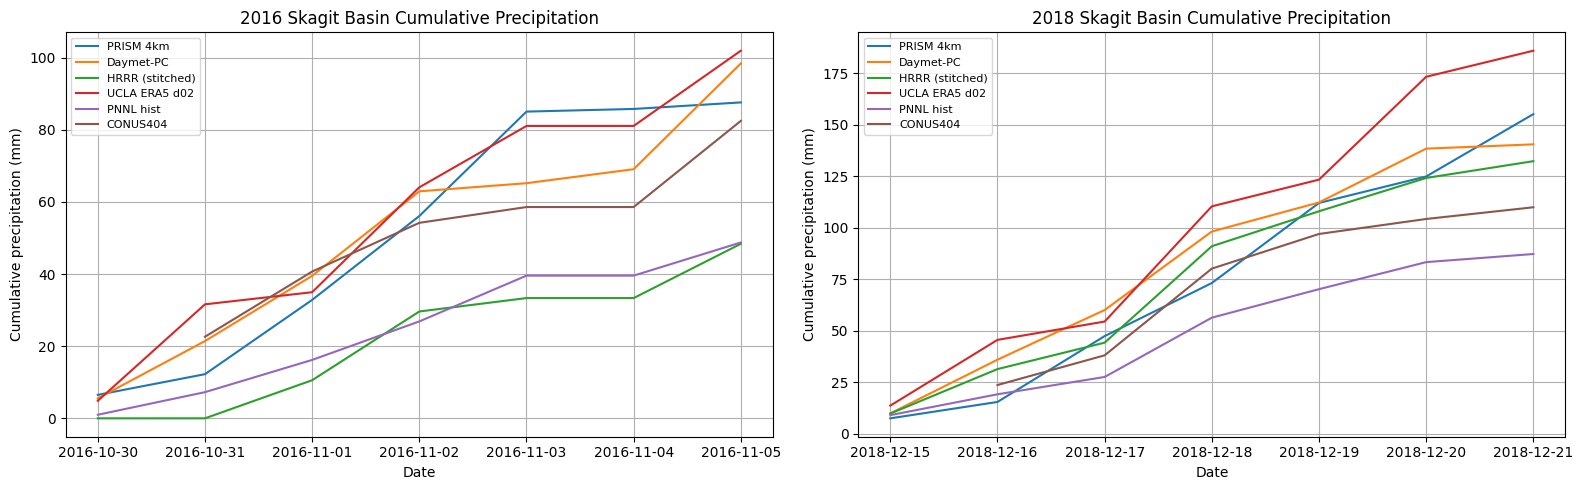


Saved MAE CSV → /data0/balaji24/data/derived/event_mae_vs_prism4km_mm_per_day.csv
   event_year       start         end  reference          dataset  \
0        2016  2016-10-30  2016-11-05  PRISM 4km         CONUS404   
1        2016  2016-10-30  2016-11-05  PRISM 4km        Daymet-PC   
2        2016  2016-10-30  2016-11-05  PRISM 4km  HRRR (stitched)   
3        2016  2016-10-30  2016-11-05  PRISM 4km        PNNL hist   
4        2016  2016-10-30  2016-11-05  PRISM 4km    UCLA ERA5 d02   
5        2018  2018-12-15  2018-12-21  PRISM 4km         CONUS404   
6        2018  2018-12-15  2018-12-21  PRISM 4km        Daymet-PC   
7        2018  2018-12-15  2018-12-21  PRISM 4km  HRRR (stitched)   
8        2018  2018-12-15  2018-12-21  PRISM 4km        PNNL hist   
9        2018  2018-12-15  2018-12-21  PRISM 4km    UCLA ERA5 d02   

   mae_mm_per_day  n_days  
0       12.757167       6  
1       10.162253       7  
2        9.377952       7  
3        7.804338       7  
4       11.054399

In [ ]:
# ============================================================
# Skagit Basin – Event CUMULATIVE Precip comparison + VERIFICATION + MAE vs PRISM 4km
#
# SOURCES:
# - PRISM (local zarr)                         BASE/prism_ppt
# - Daymet v4 (Planetary Computer)             (external zarr via STAC + SAS) 
# - HRRR (monthly zarr stitched)               BASE/weather_data
# - UCLA ERA5 WRF d02 (daily NetCDF)           /data0/.../ucla_era5_d02_daily/prec
# - PNNL historical WRF (hourly NetCDF)        BASE/PNNL/historical
# - CONUS404 (external OSN via HyTEST intake)  conus404-daily-osn


# Daymet: fresh SAS per event + eager .load() + close session
# Daymet: avoid "multiple values for consolidated" by removing consolidated from open_kwargs
# PNNL + CONUS404 included in plots + MAE
# ============================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
import regionmask
import intake
import shapely
import sys, time
from urllib.parse import urlparse, urlunparse, urlsplit, urlunsplit

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/balaji24/data")

P_PRISM_DIR = BASE / "prism_ppt"
P_HRRR_DIR  = BASE / "weather_data"

# UCLA ERA5 WRF d02 daily NetCDF
UCLA_PREC_DIR      = Path("/data0/balaji24/data/ucla_era5_d02_daily/prec")
UCLA_PREC_TEMPLATE = "prec.daily.era5.d02.{year}.nc"
UCLA_COORD_FILE    = Path("/data0/balaji24/data/ucla_era5_d02_daily/static/wrfinput_d02_coord.nc")

# PNNL historical (hourly NetCDF per year) + geo grid for mask
P_PNNL_DIR = BASE / "PNNL" / "historical"
P_PNNL_GEO = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"

BOUNDARY_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json")

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)
MAE_CSV = OUT / "event_mae_vs_prism4km_mm_per_day.csv"

# External (CONUS404)
CONUS_INTAKE_YML = (
    "https://raw.githubusercontent.com/hytest-org/hytest/main/"
    "dataset_catalog/hytest_intake_catalog.yml"
)
CONUS_MAX_TIME = np.datetime64("2022-10-01")

# ----------------------------
# EVENTS
# ----------------------------
events = [
    {"event_year": 2016, "start": "2016-10-30", "end": "2016-11-05"},
    {"event_year": 2018, "start": "2018-12-15", "end": "2018-12-21"},
]

# ============================================================
# HELPERS
# ============================================================

def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def pick_var(ds, names):
    for n in names:
        if n in ds.data_vars:
            return n
    return None

def units_str(ds, var):
    return ds[var].attrs.get("units", "(missing)")

def print_units(ds, var, label):
    print(f"  - {label}: var='{var}', units='{units_str(ds, var)}'")

def load_basin_geom():
    gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    try:
        return gdf.geometry.union_all()
    except Exception:
        return gdf.geometry.unary_union

def median_timestep_seconds(time_index):
    if len(time_index) < 2:
        return None
    dt = pd.Series(time_index).diff().dt.total_seconds().median()
    return float(dt) if pd.notnull(dt) else None

def ensure_daily_sum(da):
    """Sum to daily totals (safe for both hourly and daily)."""
    if da is None or "time" not in da.dims:
        return da
    t = pd.to_datetime(da["time"].values)
    dt = median_timestep_seconds(t)
    if dt is None:
        return da
    return da.resample(time="1D").sum()

def is_plottable_1d(da):
    if da is None:
        return False
    if da.ndim != 1 or da.size == 0:
        return False
    try:
        v = da.values
        return np.isfinite(v).any()
    except Exception:
        return False

def reset_safe_increment(acc_like_1d):
    """
    Reset-safe increments for an accumulated series (1D time):
      inc[t] = diff if diff>=0 else current_value (reset)
    Output aligns to time[1:].
    """
    d = acc_like_1d.diff("time")
    curr = acc_like_1d.isel(time=slice(1, None))
    inc = xr.where(d >= 0, d, curr)
    return inc.clip(min=0)

def accumulated_to_daily_mm(acc_like_1d, label):
    """
    Convert accumulated precip (mm) -> increments (mm/step) -> daily totals (mm/day).
    acc_like_1d MUST be 1D (time).
    """
    bm = acc_like_1d
    if bm.size < 3:
        return bm.clip(min=0).resample(time="1D").sum()

    d = bm.diff("time")
    frac_neg = float((d < 0).mean())
    mean_raw = float(bm.mean())
    mean_diff_pos = float(d.clip(min=0).mean())
    print(f"    [{label}] accum-check: frac_neg={frac_neg:.3f}, mean_raw={mean_raw:.4g}, mean_diff_pos={mean_diff_pos:.4g}")

    inc = reset_safe_increment(bm)
    daily = ensure_daily_sum(inc)
    return daily

# ============================================================
# VERIFICATION PRINTS
# ============================================================

def debug_daily(label, daily_da):
    """Print distribution stats for a DAILY (mm/day) 1D time series."""
    if daily_da is None or "time" not in daily_da.dims or daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (empty)")
        return
    daily_da = daily_da.dropna("time")
    if daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (all NaN)")
        return
    print(f"\n[{label}] DAILY CHECK")
    print("  min:", float(daily_da.min()))
    print("  max:", float(daily_da.max()))
    print("  mean:", float(daily_da.mean()))
    print("  sum:", float(daily_da.sum()))

def _median_dt_hours_from_da(da):
    if da is None or "time" not in da.dims:
        return None
    t = pd.to_datetime(da["time"].values)
    if len(t) < 2:
        return None
    dt_hours = pd.Series(t).diff().dt.total_seconds().dropna().median() / 3600.0
    return float(dt_hours) if pd.notnull(dt_hours) else None

def verify_daily_and_cumsum(label, daily_da, cum_da=None, top_n=5):
    """
    Verifies:
      - dt sanity
      - daily stats
      - sum(daily) == last(cumsum) (if cum passed)
      - top-N daily increments
    """
    if daily_da is None or daily_da.size == 0:
        print(f"\n===== VERIFY: {label} =====")
        print("  (no data)")
        return

    daily_da = daily_da.dropna("time").sortby("time")
    print(f"\n===== VERIFY: {label} =====")
    dt_hours = _median_dt_hours_from_da(daily_da)
    if dt_hours is not None:
        print(f"  median dt (hours): {dt_hours:.2f}")

    debug_daily(label, daily_da)

    if cum_da is not None and is_plottable_1d(cum_da):
        try:
            cum_last = float(cum_da.dropna("time").isel(time=-1))
            daily_sum = float(daily_da.sum())
            print("  CHECK: daily.sum vs cum[-1]:", daily_sum, cum_last, " | diff:", daily_sum - cum_last)
        except Exception as e:
            print("  CHECK: daily.sum vs cum[-1]: (failed)", repr(e))

    try:
        top = daily_da.sortby(daily_da, ascending=False).isel(time=slice(0, min(top_n, daily_da.size)))
        print(f"  TOP {min(top_n, daily_da.size)} daily values:")
        for tt, vv in zip(pd.to_datetime(top["time"].values), np.asarray(top.values)):
            print("   ", tt.date(), float(vv))
    except Exception as e:
        print("  TOP daily values: (failed)", repr(e))

# ============================================================
# MASKING UTIL (BASIN MEAN ON ANY GRID WITH lon/lat)
# ============================================================

_MASK_CACHE = {}  # key -> xr.DataArray bool with spatial dims

def _infer_lonlat_vars(ds):
    lon_candidates = ["lon", "longitude", "XLONG", "XLONG_M", "xlong", "xlong_m"]
    lat_candidates = ["lat", "latitude", "XLAT", "XLAT_M", "xlat", "xlat_m"]

    def _get(name):
        if name in ds.coords:
            return ds.coords[name]
        if name in ds.data_vars:
            return ds.data_vars[name]
        if name in ds.variables:
            return ds[name]
        return None

    lon = None
    lat = None

    for n in lon_candidates:
        lon = _get(n)
        if lon is not None:
            break
    for n in lat_candidates:
        lat = _get(n)
        if lat is not None:
            break

    if lon is None or lat is None:
        for v in list(ds.variables):
            if lon is None and "lon" in v.lower() and getattr(ds[v], "ndim", 0) >= 1:
                lon = ds[v]
            if lat is None and "lat" in v.lower() and getattr(ds[v], "ndim", 0) >= 1:
                lat = ds[v]
            if lon is not None and lat is not None:
                break

    if lon is None or lat is None:
        return None, None

    for d in list(getattr(lon, "dims", [])):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})
    for d in list(getattr(lat, "dims", [])):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})

    return lon, lat

def _sorted_unique_time(da: xr.DataArray) -> xr.DataArray:
    if da is None or "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = pd.to_datetime(da["time"].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def basin_mean_daily_from_gridded(ds, var, start, end, geom, label_for_print, assume_accumulated=False):
    if "time" not in ds.dims and "Time" in ds.dims:
        ds = ds.rename({"Time": "time"})
    if "time" not in ds[var].dims and ("Time" in ds[var].dims):
        ds = ds.rename({"Time": "time"})
    if "time" not in ds[var].dims:
        print(f"  - {label_for_print}: (no time dim on var '{var}')")
        return None

    da0 = _sorted_unique_time(ds[var])
    da = da0.sel(time=slice(start, end))
    if da.sizes.get("time", 0) == 0:
        print(f"  - {label_for_print}: (no data in window)")
        return None

    da = da.sortby("time")
    spatial = [d for d in da.dims if d != "time"]
    if len(spatial) not in (1, 2):
        print(f"  - {label_for_print}: unexpected spatial dims={spatial}")
        return None

    if len(spatial) == 1:
        bm = da.mean(dim=spatial, skipna=True)
    else:
        d0, d1 = spatial
        key = (label_for_print, d0, d1, da.sizes[d0], da.sizes[d1])

        mask_da = _MASK_CACHE.get(key)
        if mask_da is None:
            lon, lat = _infer_lonlat_vars(ds)
            if lon is None or lat is None:
                print(f"  - {label_for_print}: could not infer lon/lat (mask skip)")
                bm = da.mean(dim=spatial, skipna=True)
            else:
                reg = regionmask.Regions([geom])
                rid = reg.mask(lon, lat)
                mask_geo = ~xr.ufuncs.isnan(rid)
                mask_np = np.asarray(mask_geo.data).astype(bool)

                if mask_np.shape == (da.sizes[d0], da.sizes[d1]):
                    pass
                elif mask_np.shape == (da.sizes[d1], da.sizes[d0]):
                    mask_np = mask_np.T
                else:
                    raise RuntimeError(
                        f"[{label_for_print}] mask shape {mask_np.shape} != grid {(da.sizes[d0], da.sizes[d1])}"
                    )

                mask_da = xr.DataArray(mask_np, dims=(d0, d1))
                _MASK_CACHE[key] = mask_da

        bm = da.where(mask_da).mean(dim=(d0, d1), skipna=True)

    units = str(da.attrs.get("units", "")).lower().strip()
    if units in {"m", "meter", "meters", "metre", "metres"}:
        bm = bm * 1000.0

    if assume_accumulated:
        bm_daily = accumulated_to_daily_mm(bm, label=f"{label_for_print} accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    return bm_daily.sortby("time")

# ============================================================
# PRISM
# ============================================================

_PRISM_NAME_RE = re.compile(
    r"(?P<s>\d{4}-\d{2}-\d{2})_(?P<e>\d{4}-\d{2}-\d{2})_daily_(?P<tag>4km|800m)_PRISM_data\.zarr$"
)

def find_prism_zarr_covering(start, end, tag):
    start = pd.Timestamp(start)
    end   = pd.Timestamp(end)

    candidates = []
    for p in P_PRISM_DIR.glob(f"*_daily_{tag}_PRISM_data.zarr"):
        m = _PRISM_NAME_RE.search(p.name)
        if not m:
            continue
        f0 = pd.Timestamp(m.group("s"))
        f1 = pd.Timestamp(m.group("e"))
        if f0 <= start and f1 >= end:
            span_days = (f1 - f0).days
            candidates.append((span_days, f0, p))

    if not candidates:
        return None

    candidates.sort(key=lambda t: (t[0], -t[1].value))
    return candidates[0][2]

def load_prism_daily(start, end, tag, geom, do_verify=True):
    z = find_prism_zarr_covering(start, end, tag)
    if z is None:
        print(f"  - PRISM {tag}: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["ppt", "precip", "prcp"])
    if var is None:
        print(f"  - PRISM {tag} [{z.name}]: (no precip var found)")
        ds.close()
        return None

    print_units(ds, var, f"PRISM {tag} [{z.name}]")
    bm_daily = basin_mean_daily_from_gridded(ds, var, start, end, geom, label_for_print=f"PRISM {tag}", assume_accumulated=False)

    if bm_daily is not None and do_verify:
        verify_daily_and_cumsum(f"PRISM {tag}", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

# ============================================================
# Daymet (Planetary Computer) — FIXED consolidated conflict + eager load
# ============================================================

def ensure_daymet_pkgs():
    needed = ["pystac-client", "planetary-computer", "pyproj", "fsspec", "zarr"]
    import importlib, subprocess
    missing = []
    for p in needed:
        mod = p.replace("-", "_")
        try:
            importlib.import_module(mod)
        except Exception:
            missing.append(p)
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

ensure_daymet_pkgs()

from pystac_client import Client
import planetary_computer as pc
from pyproj import CRS, Transformer
from fsspec.implementations.http import HTTPFileSystem
from shapely.ops import transform as shp_transform

class SASEndAppendingHTTPFileSystem(HTTPFileSystem):
    def __init__(self, sas_query: str, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._sas_query = sas_query.lstrip("?")

    def _with_sas(self, url: str) -> str:
        return url if "?" in url else f"{url}?{self._sas_query}"

    def _open(self, path, mode="rb", block_size=None, **kwargs):
        return super()._open(self._with_sas(path), mode=mode, block_size=block_size, **kwargs)

    async def _cat_file(self, url, start=None, end=None, **kwargs):
        return await super()._cat_file(self._with_sas(url), start=start, end=end, **kwargs)

def daymet_lcc_crs():
    return CRS.from_proj4(
        "+proj=lcc +lat_1=25 +lat_2=60 +lat_0=42.5 +lon_0=-100 "
        "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )

_DAYMET_TFM_LL_TO_XY = Transformer.from_crs("EPSG:4326", daymet_lcc_crs(), always_xy=True)

def get_daymet_mapper_and_fs():
    stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
    col = stac.get_collection("daymet-daily-na")
    asset_key = "zarr-https" if "zarr-https" in col.assets else "zarr-abfs"
    signed_href = pc.sign(col.assets[asset_key].href)

    parts = urlsplit(signed_href)
    root_no_query = urlunsplit((parts.scheme, parts.netloc, parts.path, "", ""))
    sas_query = parts.query

    fs = SASEndAppendingHTTPFileSystem(sas_query)
    mapper = fs.get_mapper(root_no_query)

    open_kwargs = col.assets[asset_key].extra_fields.get("xarray:open_kwargs", {})
    return mapper, fs, open_kwargs

def lonlat_to_daymet_xy_bounds(geom_wgs84, pad_m=5000.0):
    minx, miny, maxx, maxy = geom_wgs84.bounds
    corners = [(minx, miny), (minx, maxy), (maxx, miny), (maxx, maxy)]
    xs, ys = zip(*[_DAYMET_TFM_LL_TO_XY.transform(lon, lat) for lon, lat in corners])
    return (float(min(xs) - pad_m), float(max(xs) + pad_m),
            float(min(ys) - pad_m), float(max(ys) + pad_m))

def _daymet_project_geom_to_xy(geom_ll):
    def _proj(x, y, z=None):
        return _DAYMET_TFM_LL_TO_XY.transform(x, y)
    return shp_transform(_proj, geom_ll)

_DAYMET_MASK_CACHE = {}

def load_daymet_pc_daily(start, end, geom_ll, do_verify=True):
    for attempt in range(1, 4):
        ds = None
        fs = None
        try:
            mapper, fs, open_kwargs = get_daymet_mapper_and_fs()

            # avoid consolidated conflict
            open_kwargs = dict(open_kwargs)
            open_kwargs.pop("consolidated", None)

            ds = xr.open_zarr(mapper, **open_kwargs)

            if "prcp" not in ds:
                raise RuntimeError("Daymet dataset missing 'prcp'")

            print_units(ds, "prcp", "Daymet-PC (Daymet v4)")
            prcp = ds["prcp"]

            units = str(prcp.attrs.get("units", "")).lower().strip()
            if units in {"m", "meter", "meters", "metre", "metres"}:
                prcp = prcp * 1000.0
                prcp.attrs["units"] = "mm"

            xmin, xmax, ymin, ymax = lonlat_to_daymet_xy_bounds(geom_ll, pad_m=5000.0)

            y0 = float(ds["y"].values[0])
            y1 = float(ds["y"].values[-1])
            y_slice = slice(ymax, ymin) if y0 > y1 else slice(ymin, ymax)

            pr = prcp.sel(time=slice(start, end), x=slice(xmin, xmax), y=y_slice).chunk({"time": -1, "y": 256, "x": 256})
            if pr.sizes.get("time", 0) == 0:
                print("  - Daymet-PC: (no data in window)")
                return None

            pr = _sorted_unique_time(pr).sortby("time")

            key = (
                float(pr["x"].values[0]), float(pr["x"].values[-1]),
                float(pr["y"].values[0]), float(pr["y"].values[-1]),
                int(pr.sizes["x"]), int(pr.sizes["y"]),
            )

            mask = _DAYMET_MASK_CACHE.get(key)
            if mask is None:
                xx, yy = xr.broadcast(pr["x"], pr["y"])
                geom_xy = _daymet_project_geom_to_xy(geom_ll)
                from shapely import contains_xy
                mask_np = contains_xy(geom_xy, np.asarray(xx.values), np.asarray(yy.values))
                mask = xr.DataArray(mask_np, dims=xx.dims, coords=xx.coords)
                _DAYMET_MASK_CACHE[key] = mask

            bm_daily = pr.where(mask).mean(dim=("y", "x"), skipna=True)
            bm_daily = ensure_daily_sum(bm_daily).sortby("time")

            # load now so SAS cannot expire later
            bm_daily = bm_daily.load()

            if do_verify:
                verify_daily_and_cumsum("Daymet-PC", bm_daily, bm_daily.cumsum("time"))

            return bm_daily

        except Exception as e:
            print(f"[DAYMET-PC] attempt {attempt}/3 failed ({type(e).__name__}): {e}")
            time.sleep(5 * attempt)
        finally:
            if ds is not None:
                try: ds.close()
                except Exception: pass
            if fs is not None:
                try: fs.close_session()
                except Exception: pass

    print("  - Daymet-PC: (failed after retries)")
    return None

# ============================================================
# HRRR (monthly stitched)
# ============================================================

def hrrr_hourly_precip_mm(ds, var="tp"):
    da = ds[var]
    probe = da.isel({k: 0 for k in da.dims if k not in ("time", "step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9

    if not is_cum:
        return da

    da = da.sortby("time")
    dif = da.diff("time", label="upper")
    dif = xr.where(dif < 0, 0, dif)
    dif = dif.fillna(0)
    dif = xr.concat([da.isel(time=slice(0, 1)) * 0, dif], dim="time")
    return dif

def load_hrrr_daily(start, end, geom, do_verify=True):
    if not P_HRRR_DIR.exists():
        print("  - HRRR: (dir missing)")
        return None

    monthly = sorted([p for p in P_HRRR_DIR.glob("*.zarr") if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)])
    if not monthly:
        print("  - HRRR: (no monthly zarrs found)")
        return None

    start_ts = pd.Timestamp(start)
    end_ts   = pd.Timestamp(end)
    need = pd.period_range(start_ts.to_period("M"), end_ts.to_period("M"), freq="M")
    need_prefixes = {f"{p.year}-{p.month:02d}" for p in need}

    available = {p.name[:7] for p in monthly}
    missing = sorted(list(need_prefixes - available))
    if missing:
        print(f"  - HRRR: missing months {missing} -> skipping HRRR for this event")
        return None

    parts = sorted([p for p in monthly if p.name[:7] in need_prefixes], key=lambda p: p.name[:7])

    ds0 = safe_open_zarr(parts[0])
    var = "tp" if "tp" in ds0 else ("apcp" if "apcp" in ds0 else None)
    if not var:
        print(f"  - HRRR: no tp/apcp in {parts[0].name} -> skipping")
        try: ds0.close()
        except Exception: pass
        return None

    dsets = []
    ok = True
    for p in parts:
        dsm = safe_open_zarr(p)
        if var not in dsm:
            print(f"  - HRRR: {p.name} missing {var} -> skipping")
            try: dsm.close()
            except Exception: pass
            ok = False
            break
        dsets.append(dsm[[var]])

    if not ok:
        for d in dsets:
            try: d.close()
            except Exception: pass
        try: ds0.close()
        except Exception: pass
        return None

    ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override").sortby("time")
    print_units(ds, var, "HRRR (stitched monthly zarr)")

    hourly_mm = hrrr_hourly_precip_mm(ds, var=var)
    daily = hourly_mm.resample(time="1D").sum()

    ds_daily = xr.Dataset({var: daily})
    for c in ["lon", "lat", "longitude", "latitude", "XLONG", "XLAT", "XLONG_M", "XLAT_M"]:
        if c in ds0:
            ds_daily[c] = ds0[c]

    bm_daily = basin_mean_daily_from_gridded(ds_daily, var, start, end, geom, label_for_print="HRRR", assume_accumulated=False)
    if bm_daily is not None and do_verify:
        verify_daily_and_cumsum("HRRR", bm_daily, bm_daily.cumsum("time"))

    for d in dsets:
        try: d.close()
        except Exception: pass
    try: ds0.close()
    except Exception: pass

    return bm_daily

# ============================================================
# UCLA ERA5 d02 (daily NetCDF)
# ============================================================

def ucla_file_label_for_date(dt: pd.Timestamp) -> int:
    return dt.year if dt.month >= 9 else (dt.year - 1)

def open_ucla_prec_for_window(t0: str, t1: str):
    t0_ts = pd.Timestamp(t0)
    t1_ts = pd.Timestamp(t1)
    labels_needed = sorted({ucla_file_label_for_date(t0_ts), ucla_file_label_for_date(t1_ts)})

    files = []
    for lab in labels_needed:
        f = UCLA_PREC_DIR / UCLA_PREC_TEMPLATE.format(year=lab)
        if f.exists():
            files.append(str(f))

    if not files:
        return None, []

    dsets = []
    pr_list = []
    for f in files:
        ds = xr.open_dataset(f, engine="netcdf4", decode_cf=True, mask_and_scale=True)
        if "prec" not in ds:
            ds.close()
            continue
        pr = ds["prec"]
        if "time" not in pr.dims:
            tdim = "day" if "day" in pr.dims else None
            if tdim is None:
                for d in pr.dims:
                    if "time" in d.lower() or "day" in d.lower():
                        tdim = d
                        break
            if tdim is not None and tdim != "time":
                pr = pr.rename({tdim: "time"})
        pr_list.append(pr)
        dsets.append(ds)

    if not pr_list:
        return None, []

    pr_all = xr.concat(pr_list, dim="time", join="outer", coords="minimal", compat="override")
    pr_all = pr_all.sortby("time")
    try:
        tt = pd.to_datetime(pr_all["time"].values)
        _, idx = np.unique(tt, return_index=True)
        pr_all = pr_all.isel(time=np.sort(idx))
    except Exception:
        pass

    pr_all = pr_all.sel(time=slice(t0, t1))
    if pr_all.sizes.get("time", 0) == 0:
        for ds in dsets:
            try: ds.close()
            except Exception: pass
        return None, []

    return pr_all, dsets

_UCLA_MASK2D = None

def build_ucla_basin_mask(coord_file: Path, geom):
    g = xr.open_dataset(coord_file, engine="netcdf4")
    lat = g["lat2d"].squeeze(drop=True).astype("float64")
    lon = g["lon2d"].squeeze(drop=True).astype("float64")
    g.close()

    lonv = lon.values.ravel()
    latv = lat.values.ravel()
    ny, nx = lon.shape

    try:
        from shapely import contains_xy
        m_flat = contains_xy(geom, lonv, latv)
    except Exception:
        import shapely as _sh
        from shapely.prepared import prep
        pg = prep(geom)
        m_flat = np.array([pg.contains(_sh.Point(x, y)) for x, y in zip(lonv, latv)], dtype=bool)

    mask2d = m_flat.reshape(ny, nx).astype(bool)
    return xr.DataArray(mask2d, dims=lon.dims, coords=lon.coords)

def load_ucla_era5_d02_daily(start, end, geom, do_verify=True):
    global _UCLA_MASK2D

    if not UCLA_PREC_DIR.exists() or not UCLA_COORD_FILE.exists():
        print("  - UCLA ERA5 d02: (missing dir or coord file)")
        return None

    pr, parents = open_ucla_prec_for_window(start, end)
    if pr is None:
        print("  - UCLA ERA5 d02: (no files / no data in window)")
        return None

    try:
        print(f"  - UCLA ERA5 d02: var='prec', units='{pr.attrs.get('units', '(missing)')}'")

        units = str(pr.attrs.get("units", "")).lower().strip()
        if units in {"m", "meter", "meters", "metre", "metres"}:
            pr = pr * 1000.0
            pr.attrs["units"] = "mm"

        if _UCLA_MASK2D is None:
            _UCLA_MASK2D = build_ucla_basin_mask(UCLA_COORD_FILE, geom)
            print(f"    [UCLA] basin mask cells inside: {int(_UCLA_MASK2D.sum())} / {_UCLA_MASK2D.size}")

        spatial = [d for d in pr.dims if d != "time"]
        if len(spatial) != 2:
            print(f"  - UCLA ERA5 d02: unexpected spatial dims={spatial}")
            return None

        mask = _UCLA_MASK2D
        if set(mask.dims) != set(spatial):
            rename_map = {}
            for md in mask.dims:
                for pdim in spatial:
                    if mask.sizes[md] == pr.sizes[pdim]:
                        rename_map[md] = pdim
                        break
            mask = mask.rename(rename_map)

        bm = pr.where(mask).mean(dim=spatial, skipna=True)
        bm_daily = ensure_daily_sum(bm).sortby("time")
        if do_verify:
            verify_daily_and_cumsum("UCLA ERA5 d02", bm_daily, bm_daily.cumsum("time"))
        return bm_daily

    finally:
        for ds in parents:
            try: ds.close()
            except Exception: pass

# ============================================================
# PNNL hist (hourly accum → daily)
# ============================================================

_PNNL_MASK_XY = None
_PNNL_MASK_KEY = None

def build_pnnl_mask_for_ds(ds_prec, geom):
    spatial = [d for d in ds_prec["PREC_ACC_NC"].dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"[PNNL] Unexpected spatial dims: {spatial}")

    d0, d1 = spatial[0], spatial[1]
    s0, s1 = ds_prec.sizes[d0], ds_prec.sizes[d1]

    geo = xr.open_dataset(P_PNNL_GEO)

    lat_name = next((c for c in ["XLAT_M", "XLAT", "lat", "LAT"] if c in geo), None)
    lon_name = next((c for c in ["XLONG_M", "XLONG", "lon", "LON"] if c in geo), None)
    if lat_name is None or lon_name is None:
        geo.close()
        raise RuntimeError(f"[PNNL geo] Could not find lat/lon vars. vars={list(geo.data_vars)[:60]}")

    lat = geo[lat_name]
    lon = geo[lon_name]

    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})
    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask_geo = ~xr.ufuncs.isnan(m)
    mask_np = np.asarray(mask_geo.data).astype(bool)
    geo.close()

    if mask_np.shape == (s0, s1):
        pass
    elif mask_np.shape == (s1, s0):
        mask_np = mask_np.T
    else:
        raise RuntimeError(
            f"[PNNL] Mask shape {mask_np.shape} does not match precip grid ({d0},{d1})={(s0,s1)}"
        )

    return xr.DataArray(mask_np, dims=(d0, d1))

def load_pnnl_daily(year, start, end, geom, do_verify=True):
    global _PNNL_MASK_XY, _PNNL_MASK_KEY

    f1 = P_PNNL_DIR / str(year) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc"
    if f1.exists():
        f = f1
    else:
        cands = sorted((P_PNNL_DIR / str(year)).glob("*PREC_ACC_NC*.nc"))
        f = cands[0] if cands else None

    if f is None or not f.exists():
        print("  - PNNL hist: (not available)")
        return None

    ds = xr.open_dataset(f, chunks={"time": 24})
    if "PREC_ACC_NC" not in ds:
        print("  - PNNL hist: (PREC_ACC_NC missing)")
        ds.close()
        return None

    print_units(ds, "PREC_ACC_NC", f"PNNL hist [{f.name}]")

    spatial = [d for d in ds["PREC_ACC_NC"].dims if d != "time"]
    key = (tuple(spatial), ds.sizes[spatial[0]], ds.sizes[spatial[1]])
    if (_PNNL_MASK_XY is None) or (_PNNL_MASK_KEY != key):
        _PNNL_MASK_XY = build_pnnl_mask_for_ds(ds, geom)
        _PNNL_MASK_KEY = key

    da = ds["PREC_ACC_NC"].sel(time=slice(start, end)).sortby("time")
    bm_acc = da.where(_PNNL_MASK_XY).mean(dim=spatial, skipna=True)

    bm_daily = accumulated_to_daily_mm(bm_acc, label="PNNL hist").sortby("time")
    if do_verify:
        verify_daily_and_cumsum("PNNL hist", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

# ============================================================
# CONUS404 (external)
# ============================================================

_conus_ds = None
_conus_mask = None

def get_conus():
    global _conus_ds
    if _conus_ds is None:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        _conus_ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    return _conus_ds

def load_conus_daily(start, end, geom, do_verify=True):
    global _conus_mask

    if np.datetime64(end) > CONUS_MAX_TIME:
        print("  - CONUS404: skipped (out of range)")
        return None

    ds = get_conus()
    var = pick_var(ds, ["PREC_ACC_NC", "prcp", "precip", "precipitation", "PREC", "PRECIP", "RAIN", "RAINNC", "RAINC"])
    if var is None:
        print("  - CONUS404: (no precip var found)")
        return None

    print_units(ds, var, "CONUS404")

    if _conus_mask is None:
        lon = ds["lon"]
        lat = ds["lat"]
        mask_np = shapely.contains_xy(geom, lon.values, lat.values)
        _conus_mask = xr.DataArray(mask_np, dims=("y", "x"))

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    bm = da.where(_conus_mask).mean(dim=("y", "x"), skipna=True)

    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = ("accum" in var.lower()) or ("accumul" in desc) or (var.upper() in ("RAINNC", "RAINC", "PREC_ACC_NC"))
    if looks_accum:
        bm_daily = accumulated_to_daily_mm(bm, label="CONUS404 accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    bm_daily = bm_daily.sortby("time")
    if do_verify:
        verify_daily_and_cumsum("CONUS404", bm_daily, bm_daily.cumsum("time"))
    return bm_daily

# ============================================================
# MAE util
# ============================================================

def mae_vs_reference_mm_per_day(ref_daily, other_daily):
    if ref_daily is None or other_daily is None:
        return np.nan, 0
    if ("time" not in ref_daily.dims) or ("time" not in other_daily.dims):
        return np.nan, 0

    a = ref_daily.dropna("time").sortby("time")
    b = other_daily.dropna("time").sortby("time")

    a2, b2 = xr.align(a, b, join="inner")
    if a2.size == 0 or b2.size == 0:
        return np.nan, 0

    diff = np.abs(a2 - b2)
    mae = float(diff.mean().values)
    n = int(diff.sizes.get("time", diff.size))
    return mae, n

# ============================================================
# MAIN
# ============================================================

def main():
    geom = load_basin_geom()

    n = len(events)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axs = np.array(axs).reshape(-1)

    mae_rows = []

    for i, ev in enumerate(events):
        yr = int(ev["event_year"])
        start = ev["start"]
        end = ev["end"]

        ax = axs[i]
        print(f"\n================ {yr} ({start} → {end}) ================")

        ref_daily = load_prism_daily(start, end, "4km", geom, do_verify=True)

        daily_series = [
            ("PRISM 4km",       ref_daily),
            ("PRISM 800m",      load_prism_daily(start, end, "800m", geom, do_verify=True)),
            ("Daymet-PC",       load_daymet_pc_daily(start, end, geom, do_verify=True)),
            ("HRRR (stitched)", load_hrrr_daily(start, end, geom, do_verify=True)),
            ("UCLA ERA5 d02",   load_ucla_era5_d02_daily(start, end, geom, do_verify=True)),
            ("PNNL hist",       load_pnnl_daily(yr, start, end, geom, do_verify=True)),
            ("CONUS404",        load_conus_daily(start, end, geom, do_verify=True)),
        ]

        plotted_any = False
        for label, dly in daily_series:
            if is_plottable_1d(dly):
                cum = dly.cumsum("time")
                ax.plot(pd.to_datetime(cum["time"].values), cum.values, label=label)
                plotted_any = True

        ax.set_title(f"{yr} Skagit Basin Cumulative Precipitation")
        ax.set_xlabel("Date")
        ax.set_ylabel("Cumulative precipitation (mm)")
        ax.grid(True)
        if plotted_any:
            ax.legend(fontsize=8)

        for label, dly in daily_series:
            if label == "PRISM 4km":
                continue
            mae, n_days = mae_vs_reference_mm_per_day(ref_daily, dly)
            if n_days > 0 and np.isfinite(mae):
                mae_rows.append({
                    "event_year": yr,
                    "start": start,
                    "end": end,
                    "reference": "PRISM 4km",
                    "dataset": label,
                    "mae_mm_per_day": mae,
                    "n_days": n_days,
                })

    for j in range(len(events), len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

    mae_df = pd.DataFrame(mae_rows).sort_values(["event_year", "dataset"]).reset_index(drop=True)
    mae_df.to_csv(MAE_CSV, index=False)
    print("\nSaved MAE CSV →", MAE_CSV)
    print(mae_df)

if __name__ == "__main__":
    main()


================ 2003 (2003-10-14 → 2003-10-19) ================
  - PRISM 4km [2003-10-14_2003-10-19_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km =====
  median dt (hours): 24.00

[PRISM 4km] DAILY CHECK
  min: 1.031404733657837
  max: 109.5666275024414
  mean: 34.32939529418945
  sum: 205.97637939453125
  CHECK: daily.sum vs cum[-1]: 205.97637939453125 205.97637939453125  | diff: 0.0
  TOP 5 daily values:
    2003-10-17 109.5666275024414
    2003-10-16 44.988006591796875
    2003-10-18 33.419349670410156
    2003-10-19 11.617640495300293
    2003-10-15 5.3533477783203125
  - PRISM 800m [2003-10-14_2003-10-19_daily_800m_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 800m =====
  median dt (hours): 24.00

[PRISM 800m] DAILY CHECK
  min: 0.9886300563812256
  max: 109.04984283447266
  mean: 34.16898727416992
  sum: 205.01393127441406
  CHECK: daily.sum vs cum[-1]: 205.01393127441406 205.013916015625  | diff: 1.52587890625e-05
  T

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7871184f1760>


  CHECK: daily.sum vs cum[-1]: 96.63439178466797 96.63439178466797  | diff: 0.0
  TOP 5 daily values:
    2003-10-16 63.84324645996094
    2003-10-19 14.146389961242676
    2003-10-17 11.598106384277344
    2003-10-15 7.03913688659668
    2003-10-18 0.007509436924010515

================ 2006 (2006-11-04 → 2006-11-07) ================
  - PRISM 4km [2006-11-02_2006-11-11_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km =====
  median dt (hours): 24.00

[PRISM 4km] DAILY CHECK
  min: 54.51885986328125
  max: 125.27294158935547
  mean: 73.85283660888672
  sum: 295.4113464355469
  CHECK: daily.sum vs cum[-1]: 295.4113464355469 295.4113464355469  | diff: 0.0
  TOP 4 daily values:
    2006-11-07 125.27294158935547
    2006-11-05 57.847694396972656
    2006-11-06 57.77183532714844
    2006-11-04 54.51885986328125
  - PRISM 800m [2006-11-02_2006-11-11_daily_800m_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 800m =====
  median dt (hours):

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7870debfacf0>


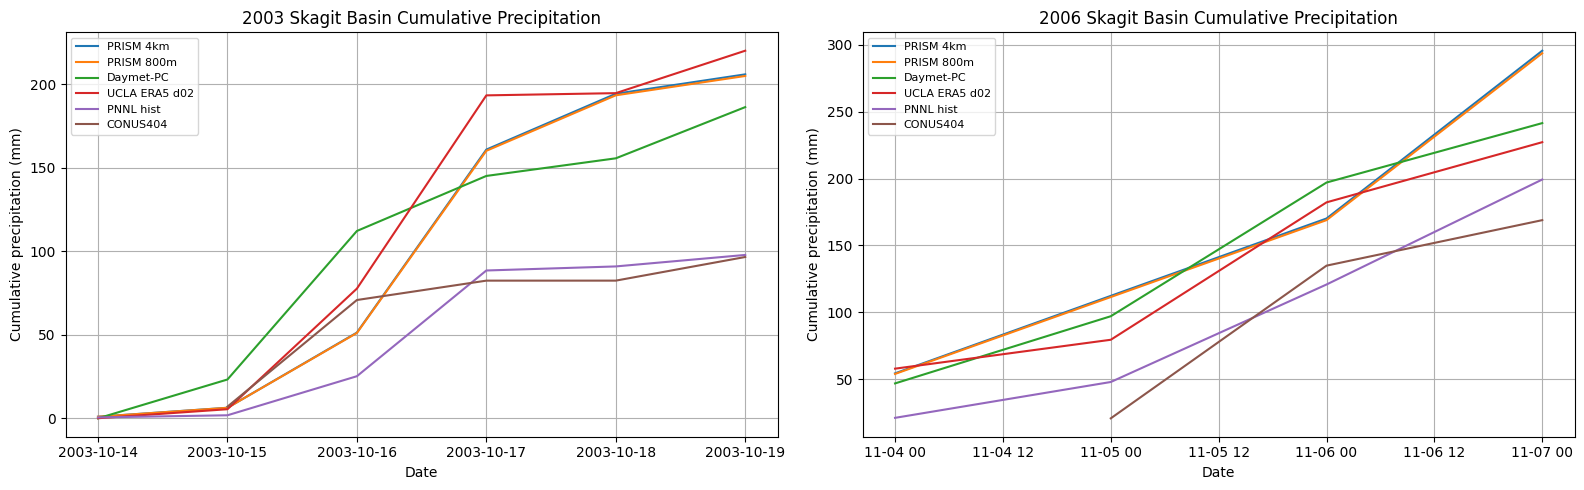


Saved MAE CSV → /data0/balaji24/data/derived/event_mae_vs_prism4km_mm_per_day.csv
   event_year       start         end  reference        dataset  \
0        2003  2003-10-14  2003-10-19  PRISM 4km       CONUS404   
1        2003  2003-10-14  2003-10-19  PRISM 4km      Daymet-PC   
2        2003  2003-10-14  2003-10-19  PRISM 4km      PNNL hist   
3        2003  2003-10-14  2003-10-19  PRISM 4km     PRISM 800m   
4        2003  2003-10-14  2003-10-19  PRISM 4km  UCLA ERA5 d02   
5        2006  2006-11-04  2006-11-07  PRISM 4km       CONUS404   
6        2006  2006-11-04  2006-11-07  PRISM 4km      Daymet-PC   
7        2006  2006-11-04  2006-11-07  PRISM 4km      PNNL hist   
8        2006  2006-11-04  2006-11-07  PRISM 4km     PRISM 800m   
9        2006  2006-11-04  2006-11-07  PRISM 4km  UCLA ERA5 d02   

   mae_mm_per_day  n_days  
0       30.890026       5  
1       30.224066       6  
2       18.018686       6  
3        0.162992       6  
4       13.360894       6  
5       61.

In [ ]:
# ============================================================
# Skagit Basin – Event CUMULATIVE Precip comparison + VERIFICATION + MAE vs PRISM 4km
#
# SOURCES:
# - PRISM (local zarr)                         BASE/prism_ppt
# - Daymet v4 (Planetary Computer)             (external zarr via STAC + SAS)
# - HRRR (monthly zarr stitched)               BASE/weather_data
# - UCLA ERA5 WRF d02 (daily NetCDF)           /data0/.../ucla_era5_d02_daily/prec
# - PNNL historical WRF (hourly NetCDF)        BASE/PNNL/historical
# - CONUS404 (external OSN via HyTEST intake)  conus404-daily-osn


# Daymet: fresh SAS per event + eager .load() + close session
# Daymet: avoid "multiple values for consolidated" by removing consolidated from open_kwargs
# PNNL + CONUS404 included in plots + MAE
# ============================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
import regionmask
import intake
import shapely
import sys, time
from urllib.parse import urlparse, urlunparse, urlsplit, urlunsplit

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/balaji24/data")

P_PRISM_DIR = BASE / "prism_nc"
P_HRRR_DIR  = BASE / "weather_data"

# UCLA ERA5 WRF d02 daily NetCDF
UCLA_PREC_DIR      = Path("/data0/balaji24/data/ucla_era5_d02_daily/prec")
UCLA_PREC_TEMPLATE = "prec.daily.era5.d02.{year}.nc"
UCLA_COORD_FILE    = Path("/data0/balaji24/data/ucla_era5_d02_daily/static/wrfinput_d02_coord.nc")

# PNNL historical (hourly NetCDF per year) + geo grid for mask
P_PNNL_DIR = BASE / "PNNL" / "historical"
P_PNNL_GEO = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"

BOUNDARY_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json")

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)
MAE_CSV = OUT / "event_mae_vs_prism4km_mm_per_day.csv"

# External (CONUS404)
CONUS_INTAKE_YML = (
    "https://raw.githubusercontent.com/hytest-org/hytest/main/"
    "dataset_catalog/hytest_intake_catalog.yml"
)
CONUS_MAX_TIME = np.datetime64("2022-10-01")

# ----------------------------
# EVENTS
# ----------------------------
events = [
    {"event_year": 2003, "start": "2003-10-14", "end": "2003-10-19"},
    {"event_year": 2006, "start": "2006-11-04", "end": "2006-11-07"},
]

# ============================================================
# HELPERS
# ============================================================

def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def pick_var(ds, names):
    for n in names:
        if n in ds.data_vars:
            return n
    return None

def units_str(ds, var):
    return ds[var].attrs.get("units", "(missing)")

def print_units(ds, var, label):
    print(f"  - {label}: var='{var}', units='{units_str(ds, var)}'")

def load_basin_geom():
    gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    try:
        return gdf.geometry.union_all()
    except Exception:
        return gdf.geometry.unary_union

def median_timestep_seconds(time_index):
    if len(time_index) < 2:
        return None
    dt = pd.Series(time_index).diff().dt.total_seconds().median()
    return float(dt) if pd.notnull(dt) else None

def ensure_daily_sum(da):
    """Sum to daily totals (safe for both hourly and daily)."""
    if da is None or "time" not in da.dims:
        return da
    t = pd.to_datetime(da["time"].values)
    dt = median_timestep_seconds(t)
    if dt is None:
        return da
    return da.resample(time="1D").sum()

def is_plottable_1d(da):
    if da is None:
        return False
    if da.ndim != 1 or da.size == 0:
        return False
    try:
        v = da.values
        return np.isfinite(v).any()
    except Exception:
        return False

def reset_safe_increment(acc_like_1d):
    """
    Reset-safe increments for an accumulated series (1D time):
      inc[t] = diff if diff>=0 else current_value (reset)
    Output aligns to time[1:].
    """
    d = acc_like_1d.diff("time")
    curr = acc_like_1d.isel(time=slice(1, None))
    inc = xr.where(d >= 0, d, curr)
    return inc.clip(min=0)

def accumulated_to_daily_mm(acc_like_1d, label):
    """
    Convert accumulated precip (mm) -> increments (mm/step) -> daily totals (mm/day).
    acc_like_1d MUST be 1D (time).
    """
    bm = acc_like_1d
    if bm.size < 3:
        return bm.clip(min=0).resample(time="1D").sum()

    d = bm.diff("time")
    frac_neg = float((d < 0).mean())
    mean_raw = float(bm.mean())
    mean_diff_pos = float(d.clip(min=0).mean())
    print(f"    [{label}] accum-check: frac_neg={frac_neg:.3f}, mean_raw={mean_raw:.4g}, mean_diff_pos={mean_diff_pos:.4g}")

    inc = reset_safe_increment(bm)
    daily = ensure_daily_sum(inc)
    return daily

# ============================================================
# VERIFICATION PRINTS
# ============================================================

def debug_daily(label, daily_da):
    """Print distribution stats for a DAILY (mm/day) 1D time series."""
    if daily_da is None or "time" not in daily_da.dims or daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (empty)")
        return
    daily_da = daily_da.dropna("time")
    if daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (all NaN)")
        return
    print(f"\n[{label}] DAILY CHECK")
    print("  min:", float(daily_da.min()))
    print("  max:", float(daily_da.max()))
    print("  mean:", float(daily_da.mean()))
    print("  sum:", float(daily_da.sum()))

def _median_dt_hours_from_da(da):
    if da is None or "time" not in da.dims:
        return None
    t = pd.to_datetime(da["time"].values)
    if len(t) < 2:
        return None
    dt_hours = pd.Series(t).diff().dt.total_seconds().dropna().median() / 3600.0
    return float(dt_hours) if pd.notnull(dt_hours) else None

def verify_daily_and_cumsum(label, daily_da, cum_da=None, top_n=5):
    """
    Verifies:
      - dt sanity
      - daily stats
      - sum(daily) == last(cumsum) (if cum passed)
      - top-N daily increments
    """
    if daily_da is None or daily_da.size == 0:
        print(f"\n===== VERIFY: {label} =====")
        print("  (no data)")
        return

    daily_da = daily_da.dropna("time").sortby("time")
    print(f"\n===== VERIFY: {label} =====")
    dt_hours = _median_dt_hours_from_da(daily_da)
    if dt_hours is not None:
        print(f"  median dt (hours): {dt_hours:.2f}")

    debug_daily(label, daily_da)

    if cum_da is not None and is_plottable_1d(cum_da):
        try:
            cum_last = float(cum_da.dropna("time").isel(time=-1))
            daily_sum = float(daily_da.sum())
            print("  CHECK: daily.sum vs cum[-1]:", daily_sum, cum_last, " | diff:", daily_sum - cum_last)
        except Exception as e:
            print("  CHECK: daily.sum vs cum[-1]: (failed)", repr(e))

    try:
        top = daily_da.sortby(daily_da, ascending=False).isel(time=slice(0, min(top_n, daily_da.size)))
        print(f"  TOP {min(top_n, daily_da.size)} daily values:")
        for tt, vv in zip(pd.to_datetime(top["time"].values), np.asarray(top.values)):
            print("   ", tt.date(), float(vv))
    except Exception as e:
        print("  TOP daily values: (failed)", repr(e))

# ============================================================
# MASKING UTIL (BASIN MEAN ON ANY GRID WITH lon/lat)
# ============================================================

_MASK_CACHE = {}  # key -> xr.DataArray bool with spatial dims

def _infer_lonlat_vars(ds):
    lon_candidates = ["lon", "longitude", "XLONG", "XLONG_M", "xlong", "xlong_m"]
    lat_candidates = ["lat", "latitude", "XLAT", "XLAT_M", "xlat", "xlat_m"]

    def _get(name):
        if name in ds.coords:
            return ds.coords[name]
        if name in ds.data_vars:
            return ds.data_vars[name]
        if name in ds.variables:
            return ds[name]
        return None

    lon = None
    lat = None

    for n in lon_candidates:
        lon = _get(n)
        if lon is not None:
            break
    for n in lat_candidates:
        lat = _get(n)
        if lat is not None:
            break

    if lon is None or lat is None:
        for v in list(ds.variables):
            if lon is None and "lon" in v.lower() and getattr(ds[v], "ndim", 0) >= 1:
                lon = ds[v]
            if lat is None and "lat" in v.lower() and getattr(ds[v], "ndim", 0) >= 1:
                lat = ds[v]
            if lon is not None and lat is not None:
                break

    if lon is None or lat is None:
        return None, None

    for d in list(getattr(lon, "dims", [])):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})
    for d in list(getattr(lat, "dims", [])):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})

    return lon, lat

def _sorted_unique_time(da: xr.DataArray) -> xr.DataArray:
    if da is None or "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = pd.to_datetime(da["time"].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def basin_mean_daily_from_gridded(ds, var, start, end, geom, label_for_print, assume_accumulated=False):
    if "time" not in ds.dims and "Time" in ds.dims:
        ds = ds.rename({"Time": "time"})
    if "time" not in ds[var].dims and ("Time" in ds[var].dims):
        ds = ds.rename({"Time": "time"})
    if "time" not in ds[var].dims:
        print(f"  - {label_for_print}: (no time dim on var '{var}')")
        return None

    da0 = _sorted_unique_time(ds[var])
    da = da0.sel(time=slice(start, end))
    if da.sizes.get("time", 0) == 0:
        print(f"  - {label_for_print}: (no data in window)")
        return None

    da = da.sortby("time")
    spatial = [d for d in da.dims if d != "time"]
    if len(spatial) not in (1, 2):
        print(f"  - {label_for_print}: unexpected spatial dims={spatial}")
        return None

    if len(spatial) == 1:
        bm = da.mean(dim=spatial, skipna=True)
    else:
        d0, d1 = spatial
        key = (label_for_print, d0, d1, da.sizes[d0], da.sizes[d1])

        mask_da = _MASK_CACHE.get(key)
        if mask_da is None:
            lon, lat = _infer_lonlat_vars(ds)
            if lon is None or lat is None:
                print(f"  - {label_for_print}: could not infer lon/lat (mask skip)")
                bm = da.mean(dim=spatial, skipna=True)
            else:
                reg = regionmask.Regions([geom])
                rid = reg.mask(lon, lat)
                mask_geo = ~xr.ufuncs.isnan(rid)
                mask_np = np.asarray(mask_geo.data).astype(bool)

                if mask_np.shape == (da.sizes[d0], da.sizes[d1]):
                    pass
                elif mask_np.shape == (da.sizes[d1], da.sizes[d0]):
                    mask_np = mask_np.T
                else:
                    raise RuntimeError(
                        f"[{label_for_print}] mask shape {mask_np.shape} != grid {(da.sizes[d0], da.sizes[d1])}"
                    )

                mask_da = xr.DataArray(mask_np, dims=(d0, d1))
                _MASK_CACHE[key] = mask_da

        bm = da.where(mask_da).mean(dim=(d0, d1), skipna=True)

    units = str(da.attrs.get("units", "")).lower().strip()
    if units in {"m", "meter", "meters", "metre", "metres"}:
        bm = bm * 1000.0

    if assume_accumulated:
        bm_daily = accumulated_to_daily_mm(bm, label=f"{label_for_print} accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    return bm_daily.sortby("time")

# ============================================================
# PRISM
# ============================================================

_PRISM_NAME_RE = re.compile(
    r"(?P<s>\d{4}-\d{2}-\d{2})_(?P<e>\d{4}-\d{2}-\d{2})_daily_(?P<tag>4km|800m)_PRISM_data\.zarr$"
)

def find_prism_zarr_covering(start, end, tag):
    start = pd.Timestamp(start)
    end   = pd.Timestamp(end)

    candidates = []
    for p in P_PRISM_DIR.glob(f"*_daily_{tag}_PRISM_data.zarr"):
        m = _PRISM_NAME_RE.search(p.name)
        if not m:
            continue
        f0 = pd.Timestamp(m.group("s"))
        f1 = pd.Timestamp(m.group("e"))
        if f0 <= start and f1 >= end:
            span_days = (f1 - f0).days
            candidates.append((span_days, f0, p))

    if not candidates:
        return None

    candidates.sort(key=lambda t: (t[0], -t[1].value))
    return candidates[0][2]

def load_prism_daily(start, end, tag, geom, do_verify=True):
    z = find_prism_zarr_covering(start, end, tag)
    if z is None:
        print(f"  - PRISM {tag}: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["ppt", "precip", "prcp"])
    if var is None:
        print(f"  - PRISM {tag} [{z.name}]: (no precip var found)")
        ds.close()
        return None

    print_units(ds, var, f"PRISM {tag} [{z.name}]")
    bm_daily = basin_mean_daily_from_gridded(ds, var, start, end, geom, label_for_print=f"PRISM {tag}", assume_accumulated=False)

    if bm_daily is not None and do_verify:
        verify_daily_and_cumsum(f"PRISM {tag}", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

# ============================================================
# Daymet (Planetary Computer) — FIXED consolidated conflict + eager load
# ============================================================

def ensure_daymet_pkgs():
    needed = ["pystac-client", "planetary-computer", "pyproj", "fsspec", "zarr"]
    import importlib, subprocess
    missing = []
    for p in needed:
        mod = p.replace("-", "_")
        try:
            importlib.import_module(mod)
        except Exception:
            missing.append(p)
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

ensure_daymet_pkgs()

from pystac_client import Client
import planetary_computer as pc
from pyproj import CRS, Transformer
from fsspec.implementations.http import HTTPFileSystem
from shapely.ops import transform as shp_transform

class SASEndAppendingHTTPFileSystem(HTTPFileSystem):
    def __init__(self, sas_query: str, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._sas_query = sas_query.lstrip("?")

    def _with_sas(self, url: str) -> str:
        return url if "?" in url else f"{url}?{self._sas_query}"

    def _open(self, path, mode="rb", block_size=None, **kwargs):
        return super()._open(self._with_sas(path), mode=mode, block_size=block_size, **kwargs)

    async def _cat_file(self, url, start=None, end=None, **kwargs):
        return await super()._cat_file(self._with_sas(url), start=start, end=end, **kwargs)

def daymet_lcc_crs():
    return CRS.from_proj4(
        "+proj=lcc +lat_1=25 +lat_2=60 +lat_0=42.5 +lon_0=-100 "
        "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )

_DAYMET_TFM_LL_TO_XY = Transformer.from_crs("EPSG:4326", daymet_lcc_crs(), always_xy=True)

def get_daymet_mapper_and_fs():
    stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
    col = stac.get_collection("daymet-daily-na")
    asset_key = "zarr-https" if "zarr-https" in col.assets else "zarr-abfs"
    signed_href = pc.sign(col.assets[asset_key].href)

    parts = urlsplit(signed_href)
    root_no_query = urlunsplit((parts.scheme, parts.netloc, parts.path, "", ""))
    sas_query = parts.query

    fs = SASEndAppendingHTTPFileSystem(sas_query)
    mapper = fs.get_mapper(root_no_query)

    open_kwargs = col.assets[asset_key].extra_fields.get("xarray:open_kwargs", {})
    return mapper, fs, open_kwargs

def lonlat_to_daymet_xy_bounds(geom_wgs84, pad_m=5000.0):
    minx, miny, maxx, maxy = geom_wgs84.bounds
    corners = [(minx, miny), (minx, maxy), (maxx, miny), (maxx, maxy)]
    xs, ys = zip(*[_DAYMET_TFM_LL_TO_XY.transform(lon, lat) for lon, lat in corners])
    return (float(min(xs) - pad_m), float(max(xs) + pad_m),
            float(min(ys) - pad_m), float(max(ys) + pad_m))

def _daymet_project_geom_to_xy(geom_ll):
    def _proj(x, y, z=None):
        return _DAYMET_TFM_LL_TO_XY.transform(x, y)
    return shp_transform(_proj, geom_ll)

_DAYMET_MASK_CACHE = {}

def load_daymet_pc_daily(start, end, geom_ll, do_verify=True):
    for attempt in range(1, 4):
        ds = None
        fs = None
        try:
            mapper, fs, open_kwargs = get_daymet_mapper_and_fs()

            # avoid consolidated conflict
            open_kwargs = dict(open_kwargs)
            open_kwargs.pop("consolidated", None)

            ds = xr.open_zarr(mapper, **open_kwargs)

            if "prcp" not in ds:
                raise RuntimeError("Daymet dataset missing 'prcp'")

            print_units(ds, "prcp", "Daymet-PC (Daymet v4)")
            prcp = ds["prcp"]

            units = str(prcp.attrs.get("units", "")).lower().strip()
            if units in {"m", "meter", "meters", "metre", "metres"}:
                prcp = prcp * 1000.0
                prcp.attrs["units"] = "mm"

            xmin, xmax, ymin, ymax = lonlat_to_daymet_xy_bounds(geom_ll, pad_m=5000.0)

            y0 = float(ds["y"].values[0])
            y1 = float(ds["y"].values[-1])
            y_slice = slice(ymax, ymin) if y0 > y1 else slice(ymin, ymax)

            pr = prcp.sel(time=slice(start, end), x=slice(xmin, xmax), y=y_slice).chunk({"time": -1, "y": 256, "x": 256})
            if pr.sizes.get("time", 0) == 0:
                print("  - Daymet-PC: (no data in window)")
                return None

            pr = _sorted_unique_time(pr).sortby("time")

            key = (
                float(pr["x"].values[0]), float(pr["x"].values[-1]),
                float(pr["y"].values[0]), float(pr["y"].values[-1]),
                int(pr.sizes["x"]), int(pr.sizes["y"]),
            )

            mask = _DAYMET_MASK_CACHE.get(key)
            if mask is None:
                xx, yy = xr.broadcast(pr["x"], pr["y"])
                geom_xy = _daymet_project_geom_to_xy(geom_ll)
                from shapely import contains_xy
                mask_np = contains_xy(geom_xy, np.asarray(xx.values), np.asarray(yy.values))
                mask = xr.DataArray(mask_np, dims=xx.dims, coords=xx.coords)
                _DAYMET_MASK_CACHE[key] = mask

            bm_daily = pr.where(mask).mean(dim=("y", "x"), skipna=True)
            bm_daily = ensure_daily_sum(bm_daily).sortby("time")

            # load now so SAS cannot expire later
            bm_daily = bm_daily.load()

            if do_verify:
                verify_daily_and_cumsum("Daymet-PC", bm_daily, bm_daily.cumsum("time"))

            return bm_daily

        except Exception as e:
            print(f"[DAYMET-PC] attempt {attempt}/3 failed ({type(e).__name__}): {e}")
            time.sleep(5 * attempt)
        finally:
            if ds is not None:
                try: ds.close()
                except Exception: pass
            if fs is not None:
                try: fs.close_session()
                except Exception: pass

    print("  - Daymet-PC: (failed after retries)")
    return None

# ============================================================
# HRRR (monthly stitched)
# ============================================================

def hrrr_hourly_precip_mm(ds, var="tp"):
    da = ds[var]
    probe = da.isel({k: 0 for k in da.dims if k not in ("time", "step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9

    if not is_cum:
        return da

    da = da.sortby("time")
    dif = da.diff("time", label="upper")
    dif = xr.where(dif < 0, 0, dif)
    dif = dif.fillna(0)
    dif = xr.concat([da.isel(time=slice(0, 1)) * 0, dif], dim="time")
    return dif

def load_hrrr_daily(start, end, geom, do_verify=True):
    if not P_HRRR_DIR.exists():
        print("  - HRRR: (dir missing)")
        return None

    monthly = sorted([p for p in P_HRRR_DIR.glob("*.zarr") if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)])
    if not monthly:
        print("  - HRRR: (no monthly zarrs found)")
        return None

    start_ts = pd.Timestamp(start)
    end_ts   = pd.Timestamp(end)
    need = pd.period_range(start_ts.to_period("M"), end_ts.to_period("M"), freq="M")
    need_prefixes = {f"{p.year}-{p.month:02d}" for p in need}

    available = {p.name[:7] for p in monthly}
    missing = sorted(list(need_prefixes - available))
    if missing:
        print(f"  - HRRR: missing months {missing} -> skipping HRRR for this event")
        return None

    parts = sorted([p for p in monthly if p.name[:7] in need_prefixes], key=lambda p: p.name[:7])

    ds0 = safe_open_zarr(parts[0])
    var = "tp" if "tp" in ds0 else ("apcp" if "apcp" in ds0 else None)
    if not var:
        print(f"  - HRRR: no tp/apcp in {parts[0].name} -> skipping")
        try: ds0.close()
        except Exception: pass
        return None

    dsets = []
    ok = True
    for p in parts:
        dsm = safe_open_zarr(p)
        if var not in dsm:
            print(f"  - HRRR: {p.name} missing {var} -> skipping")
            try: dsm.close()
            except Exception: pass
            ok = False
            break
        dsets.append(dsm[[var]])

    if not ok:
        for d in dsets:
            try: d.close()
            except Exception: pass
        try: ds0.close()
        except Exception: pass
        return None

    ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override").sortby("time")
    print_units(ds, var, "HRRR (stitched monthly zarr)")

    hourly_mm = hrrr_hourly_precip_mm(ds, var=var)
    daily = hourly_mm.resample(time="1D").sum()

    ds_daily = xr.Dataset({var: daily})
    for c in ["lon", "lat", "longitude", "latitude", "XLONG", "XLAT", "XLONG_M", "XLAT_M"]:
        if c in ds0:
            ds_daily[c] = ds0[c]

    bm_daily = basin_mean_daily_from_gridded(ds_daily, var, start, end, geom, label_for_print="HRRR", assume_accumulated=False)
    if bm_daily is not None and do_verify:
        verify_daily_and_cumsum("HRRR", bm_daily, bm_daily.cumsum("time"))

    for d in dsets:
        try: d.close()
        except Exception: pass
    try: ds0.close()
    except Exception: pass

    return bm_daily

# ============================================================
# UCLA ERA5 d02 (daily NetCDF)
# ============================================================

def ucla_file_label_for_date(dt: pd.Timestamp) -> int:
    return dt.year if dt.month >= 9 else (dt.year - 1)

def open_ucla_prec_for_window(t0: str, t1: str):
    t0_ts = pd.Timestamp(t0)
    t1_ts = pd.Timestamp(t1)
    labels_needed = sorted({ucla_file_label_for_date(t0_ts), ucla_file_label_for_date(t1_ts)})

    files = []
    for lab in labels_needed:
        f = UCLA_PREC_DIR / UCLA_PREC_TEMPLATE.format(year=lab)
        if f.exists():
            files.append(str(f))

    if not files:
        return None, []

    dsets = []
    pr_list = []
    for f in files:
        ds = xr.open_dataset(f, engine="netcdf4", decode_cf=True, mask_and_scale=True)
        if "prec" not in ds:
            ds.close()
            continue
        pr = ds["prec"]
        if "time" not in pr.dims:
            tdim = "day" if "day" in pr.dims else None
            if tdim is None:
                for d in pr.dims:
                    if "time" in d.lower() or "day" in d.lower():
                        tdim = d
                        break
            if tdim is not None and tdim != "time":
                pr = pr.rename({tdim: "time"})
        pr_list.append(pr)
        dsets.append(ds)

    if not pr_list:
        return None, []

    pr_all = xr.concat(pr_list, dim="time", join="outer", coords="minimal", compat="override")
    pr_all = pr_all.sortby("time")
    try:
        tt = pd.to_datetime(pr_all["time"].values)
        _, idx = np.unique(tt, return_index=True)
        pr_all = pr_all.isel(time=np.sort(idx))
    except Exception:
        pass

    pr_all = pr_all.sel(time=slice(t0, t1))
    if pr_all.sizes.get("time", 0) == 0:
        for ds in dsets:
            try: ds.close()
            except Exception: pass
        return None, []

    return pr_all, dsets

_UCLA_MASK2D = None

def build_ucla_basin_mask(coord_file: Path, geom):
    g = xr.open_dataset(coord_file, engine="netcdf4")
    lat = g["lat2d"].squeeze(drop=True).astype("float64")
    lon = g["lon2d"].squeeze(drop=True).astype("float64")
    g.close()

    lonv = lon.values.ravel()
    latv = lat.values.ravel()
    ny, nx = lon.shape

    try:
        from shapely import contains_xy
        m_flat = contains_xy(geom, lonv, latv)
    except Exception:
        import shapely as _sh
        from shapely.prepared import prep
        pg = prep(geom)
        m_flat = np.array([pg.contains(_sh.Point(x, y)) for x, y in zip(lonv, latv)], dtype=bool)

    mask2d = m_flat.reshape(ny, nx).astype(bool)
    return xr.DataArray(mask2d, dims=lon.dims, coords=lon.coords)

def load_ucla_era5_d02_daily(start, end, geom, do_verify=True):
    global _UCLA_MASK2D

    if not UCLA_PREC_DIR.exists() or not UCLA_COORD_FILE.exists():
        print("  - UCLA ERA5 d02: (missing dir or coord file)")
        return None

    pr, parents = open_ucla_prec_for_window(start, end)
    if pr is None:
        print("  - UCLA ERA5 d02: (no files / no data in window)")
        return None

    try:
        print(f"  - UCLA ERA5 d02: var='prec', units='{pr.attrs.get('units', '(missing)')}'")

        units = str(pr.attrs.get("units", "")).lower().strip()
        if units in {"m", "meter", "meters", "metre", "metres"}:
            pr = pr * 1000.0
            pr.attrs["units"] = "mm"

        if _UCLA_MASK2D is None:
            _UCLA_MASK2D = build_ucla_basin_mask(UCLA_COORD_FILE, geom)
            print(f"    [UCLA] basin mask cells inside: {int(_UCLA_MASK2D.sum())} / {_UCLA_MASK2D.size}")

        spatial = [d for d in pr.dims if d != "time"]
        if len(spatial) != 2:
            print(f"  - UCLA ERA5 d02: unexpected spatial dims={spatial}")
            return None

        mask = _UCLA_MASK2D
        if set(mask.dims) != set(spatial):
            rename_map = {}
            for md in mask.dims:
                for pdim in spatial:
                    if mask.sizes[md] == pr.sizes[pdim]:
                        rename_map[md] = pdim
                        break
            mask = mask.rename(rename_map)

        bm = pr.where(mask).mean(dim=spatial, skipna=True)
        bm_daily = ensure_daily_sum(bm).sortby("time")
        if do_verify:
            verify_daily_and_cumsum("UCLA ERA5 d02", bm_daily, bm_daily.cumsum("time"))
        return bm_daily

    finally:
        for ds in parents:
            try: ds.close()
            except Exception: pass

# ============================================================
# PNNL hist (hourly accum → daily)
# ============================================================

_PNNL_MASK_XY = None
_PNNL_MASK_KEY = None

def build_pnnl_mask_for_ds(ds_prec, geom):
    spatial = [d for d in ds_prec["PREC_ACC_NC"].dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"[PNNL] Unexpected spatial dims: {spatial}")

    d0, d1 = spatial[0], spatial[1]
    s0, s1 = ds_prec.sizes[d0], ds_prec.sizes[d1]

    geo = xr.open_dataset(P_PNNL_GEO)

    lat_name = next((c for c in ["XLAT_M", "XLAT", "lat", "LAT"] if c in geo), None)
    lon_name = next((c for c in ["XLONG_M", "XLONG", "lon", "LON"] if c in geo), None)
    if lat_name is None or lon_name is None:
        geo.close()
        raise RuntimeError(f"[PNNL geo] Could not find lat/lon vars. vars={list(geo.data_vars)[:60]}")

    lat = geo[lat_name]
    lon = geo[lon_name]

    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})
    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask_geo = ~xr.ufuncs.isnan(m)
    mask_np = np.asarray(mask_geo.data).astype(bool)
    geo.close()

    if mask_np.shape == (s0, s1):
        pass
    elif mask_np.shape == (s1, s0):
        mask_np = mask_np.T
    else:
        raise RuntimeError(
            f"[PNNL] Mask shape {mask_np.shape} does not match precip grid ({d0},{d1})={(s0,s1)}"
        )

    return xr.DataArray(mask_np, dims=(d0, d1))

def load_pnnl_daily(year, start, end, geom, do_verify=True):
    global _PNNL_MASK_XY, _PNNL_MASK_KEY

    f1 = P_PNNL_DIR / str(year) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc"
    if f1.exists():
        f = f1
    else:
        cands = sorted((P_PNNL_DIR / str(year)).glob("*PREC_ACC_NC*.nc"))
        f = cands[0] if cands else None

    if f is None or not f.exists():
        print("  - PNNL hist: (not available)")
        return None

    ds = xr.open_dataset(f, chunks={"time": 24})
    if "PREC_ACC_NC" not in ds:
        print("  - PNNL hist: (PREC_ACC_NC missing)")
        ds.close()
        return None

    print_units(ds, "PREC_ACC_NC", f"PNNL hist [{f.name}]")

    spatial = [d for d in ds["PREC_ACC_NC"].dims if d != "time"]
    key = (tuple(spatial), ds.sizes[spatial[0]], ds.sizes[spatial[1]])
    if (_PNNL_MASK_XY is None) or (_PNNL_MASK_KEY != key):
        _PNNL_MASK_XY = build_pnnl_mask_for_ds(ds, geom)
        _PNNL_MASK_KEY = key

    da = ds["PREC_ACC_NC"].sel(time=slice(start, end)).sortby("time")
    bm_acc = da.where(_PNNL_MASK_XY).mean(dim=spatial, skipna=True)

    bm_daily = accumulated_to_daily_mm(bm_acc, label="PNNL hist").sortby("time")
    if do_verify:
        verify_daily_and_cumsum("PNNL hist", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

# ============================================================
# CONUS404 (external)
# ============================================================

_conus_ds = None
_conus_mask = None

def get_conus():
    global _conus_ds
    if _conus_ds is None:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        _conus_ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    return _conus_ds

def load_conus_daily(start, end, geom, do_verify=True):
    global _conus_mask

    if np.datetime64(end) > CONUS_MAX_TIME:
        print("  - CONUS404: skipped (out of range)")
        return None

    ds = get_conus()
    var = pick_var(ds, ["PREC_ACC_NC", "prcp", "precip", "precipitation", "PREC", "PRECIP", "RAIN", "RAINNC", "RAINC"])
    if var is None:
        print("  - CONUS404: (no precip var found)")
        return None

    print_units(ds, var, "CONUS404")

    if _conus_mask is None:
        lon = ds["lon"]
        lat = ds["lat"]
        mask_np = shapely.contains_xy(geom, lon.values, lat.values)
        _conus_mask = xr.DataArray(mask_np, dims=("y", "x"))

    da = ds[var].sel(time=slice(start, end)).sortby("time")
    bm = da.where(_conus_mask).mean(dim=("y", "x"), skipna=True)

    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = ("accum" in var.lower()) or ("accumul" in desc) or (var.upper() in ("RAINNC", "RAINC", "PREC_ACC_NC"))
    if looks_accum:
        bm_daily = accumulated_to_daily_mm(bm, label="CONUS404 accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    bm_daily = bm_daily.sortby("time")
    if do_verify:
        verify_daily_and_cumsum("CONUS404", bm_daily, bm_daily.cumsum("time"))
    return bm_daily

# ============================================================
# MAE util
# ============================================================

def mae_vs_reference_mm_per_day(ref_daily, other_daily):
    if ref_daily is None or other_daily is None:
        return np.nan, 0
    if ("time" not in ref_daily.dims) or ("time" not in other_daily.dims):
        return np.nan, 0

    a = ref_daily.dropna("time").sortby("time")
    b = other_daily.dropna("time").sortby("time")

    a2, b2 = xr.align(a, b, join="inner")
    if a2.size == 0 or b2.size == 0:
        return np.nan, 0

    diff = np.abs(a2 - b2)
    mae = float(diff.mean().values)
    n = int(diff.sizes.get("time", diff.size))
    return mae, n

# ============================================================
# MAIN
# ============================================================

def main():
    geom = load_basin_geom()

    n = len(events)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axs = np.array(axs).reshape(-1)

    mae_rows = []

    for i, ev in enumerate(events):
        yr = int(ev["event_year"])
        start = ev["start"]
        end = ev["end"]

        ax = axs[i]
        print(f"\n================ {yr} ({start} → {end}) ================")

        ref_daily = load_prism_daily(start, end, "4km", geom, do_verify=True)

        daily_series = [
            ("PRISM 4km",       ref_daily),
            ("PRISM 800m",      load_prism_daily(start, end, "800m", geom, do_verify=True)),
            ("Daymet-PC",       load_daymet_pc_daily(start, end, geom, do_verify=True)),
            ("HRRR (stitched)", load_hrrr_daily(start, end, geom, do_verify=True)),
            ("UCLA ERA5 d02",   load_ucla_era5_d02_daily(start, end, geom, do_verify=True)),
            ("PNNL hist",       load_pnnl_daily(yr, start, end, geom, do_verify=True)),
            ("CONUS404",        load_conus_daily(start, end, geom, do_verify=True)),
        ]

        plotted_any = False
        for label, dly in daily_series:
            if is_plottable_1d(dly):
                cum = dly.cumsum("time")
                ax.plot(pd.to_datetime(cum["time"].values), cum.values, label=label)
                plotted_any = True

        ax.set_title(f"{yr} Skagit Basin Cumulative Precipitation")
        ax.set_xlabel("Date")
        ax.set_ylabel("Cumulative precipitation (mm)")
        ax.grid(True)
        if plotted_any:
            ax.legend(fontsize=8)

        for label, dly in daily_series:
            if label == "PRISM 4km":
                continue
            mae, n_days = mae_vs_reference_mm_per_day(ref_daily, dly)
            if n_days > 0 and np.isfinite(mae):
                mae_rows.append({
                    "event_year": yr,
                    "start": start,
                    "end": end,
                    "reference": "PRISM 4km",
                    "dataset": label,
                    "mae_mm_per_day": mae,
                    "n_days": n_days,
                })

    for j in range(len(events), len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

    mae_df = pd.DataFrame(mae_rows).sort_values(["event_year", "dataset"]).reset_index(drop=True)
    mae_df.to_csv(MAE_CSV, index=False)
    print("\nSaved MAE CSV →", MAE_CSV)
    print(mae_df)

if __name__ == "__main__":
    main()

# Sub Basin plots

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7871382e2a20>



================ EVENT 2016 (2016-10-30 → 2016-11-05) ================

----- Region: Upper Skagit -----
  - PRISM 4km [2016-01-01_2016-12-31_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km | Upper Skagit =====
  median dt (hours): 24.00

[PRISM 4km | Upper Skagit] DAILY CHECK
  min: 0.9166993498802185
  max: 32.46138381958008
  mean: 11.824533462524414
  sum: 82.77173614501953
  CHECK: daily.sum vs cum[-1]: 82.77173614501953 82.77174377441406  | diff: -7.62939453125e-06
  TOP 5 daily values:
    2016-11-03 32.46138381958008
    2016-11-02 20.91453742980957
    2016-11-01 16.57731819152832
    2016-10-30 6.005738735198975
    2016-10-31 4.376817226409912
  - PRISM 800m: (not available)
  - Daymet-PC (Daymet v4): var='prcp', units='mm/day'

===== VERIFY: Daymet-PC | Upper Skagit =====
  median dt (hours): 24.00

[Daymet-PC | Upper Skagit] DAILY CHECK
  min: 2.5304062366485596
  max: 28.695079803466797
  mean: 13.314943313598633
  sum: 93.20460510253906

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7871986f1130>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7870dee58a70>, 359163.063056323), (<aiohttp.client_proto.ResponseHandler object at 0x7870dee5b6b0>, 359163.063877495), (<aiohttp.client_proto.ResponseHandler object at 0x7870dee5bcb0>, 359163.071209351), (<aiohttp.client_proto.ResponseHandler object at 0x7870dee58650>, 359163.071935682), (<aiohttp.client_proto.ResponseHandler object at 0x7870de186690>, 359163.073017258), (<aiohttp.client_proto.ResponseHandler object at 0x7870dee5b110>, 359163.073745528), (<aiohttp.client_proto.ResponseHandler object at 0x7870dee5bd10>, 359163.075487843), (<aiohttp.client_proto.ResponseHandler object at 0x7870dee5b050>, 359163.077439792), (<aiohttp.client_proto.ResponseHandler object at 0x7870de187770>, 359163.078766421), (<aiohttp.client_proto.ResponseHandler object at 0x7870dee5a630>, 359184.22294645)])']
connector: 

  CHECK: daily.sum vs cum[-1]: 46.28034973144531 46.28034973144531  | diff: 0.0
  TOP 5 daily values:
    2016-11-02 20.419113159179688
    2016-11-05 14.922231674194336
    2016-11-01 7.393956184387207
    2016-11-03 3.5214736461639404
    2016-10-30 0.02270854450762272
  - UCLA ERA5 d02: var='prec', units='mm/d'
    [UCLA | Upper Skagit] mask cells inside: 61 / 91800

===== VERIFY: UCLA ERA5 d02 | Upper Skagit =====
  median dt (hours): 24.00

[UCLA ERA5 d02 | Upper Skagit] DAILY CHECK
  min: 0.006915983743965626
  max: 35.26198196411133
  mean: 15.924864768981934
  sum: 111.47405242919922
  CHECK: daily.sum vs cum[-1]: 111.47405242919922 111.47405242919922  | diff: 0.0
  TOP 5 daily values:
    2016-11-02 35.26198196411133
    2016-10-31 24.635913848876953
    2016-11-05 22.641721725463867
    2016-11-03 19.76847267150879
    2016-10-30 6.067724704742432
  - PNNL hist [PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.2016.nc]: var='PREC_ACC_NC', units='mm'
    [PNNL hist | Upper Skagit] accum-

Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed

...


===== VERIFY: CONUS404 | Sauk =====
  median dt (hours): 24.00

[CONUS404 | Sauk] DAILY CHECK
  min: 5.296875
  max: 41.16748046875
  mean: 17.132596969604492
  sum: 102.79558563232422
  CHECK: daily.sum vs cum[-1]: 102.79558563232422 102.79558563232422  | diff: 0.0
  TOP 5 daily values:
    2018-12-18 41.16748046875
    2018-12-16 19.30547332763672
    2018-12-17 16.16285514831543
    2018-12-19 13.518362998962402
    2018-12-20 7.344534873962402

----- Region: Lower Skagit -----
  - PRISM 4km [2018-01-01_2018-12-31_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km | Lower Skagit =====
  median dt (hours): 24.00

[PRISM 4km | Lower Skagit] DAILY CHECK
  min: 7.9327874183654785
  max: 28.924697875976562
  mean: 17.490602493286133
  sum: 122.43421173095703
  CHECK: daily.sum vs cum[-1]: 122.43421173095703 122.43421173095703  | diff: 0.0
  TOP 5 daily values:
    2018-12-17 28.924697875976562
    2018-12-19 23.23136329650879
    2018-12-21 20.737136840820

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7870de108f20>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x787118600830>, 360006.547203395), (<aiohttp.client_proto.ResponseHandler object at 0x7870ddb101d0>, 360006.547406557), (<aiohttp.client_proto.ResponseHandler object at 0x7870de7792b0>, 360006.548158545), (<aiohttp.client_proto.ResponseHandler object at 0x7870deef7e30>, 360006.550842111), (<aiohttp.client_proto.ResponseHandler object at 0x7870de71ac30>, 360006.552033733), (<aiohttp.client_proto.ResponseHandler object at 0x7870de778530>, 360006.552233345), (<aiohttp.client_proto.ResponseHandler object at 0x7870ddb10290>, 360006.557493618), (<aiohttp.client_proto.ResponseHandler object at 0x7870deef69f0>, 360006.561550898), (<aiohttp.client_proto.ResponseHandler object at 0x787118601df0>, 360006.564551418), (<aiohttp.client_proto.ResponseHandler object at 0x7870de77a5d0>, 360022.007874226)])']
connector:


===== VERIFY: HRRR | Lower Skagit =====
  median dt (hours): 24.00

[HRRR | Lower Skagit] DAILY CHECK
  min: 4.9937334060668945
  max: 28.344335556030273
  mean: 9.729158401489258
  sum: 68.10411071777344
  CHECK: daily.sum vs cum[-1]: 68.10411071777344 68.10411071777344  | diff: 0.0
  TOP 5 daily values:
    2018-12-18 28.344335556030273
    2018-12-19 7.790816783905029
    2018-12-16 6.8941144943237305
    2018-12-17 6.8688859939575195
    2018-12-15 6.831954479217529
  - UCLA ERA5 d02: var='prec', units='mm/d'

===== VERIFY: UCLA ERA5 d02 | Lower Skagit =====
  median dt (hours): 24.00

[UCLA ERA5 d02 | Lower Skagit] DAILY CHECK
  min: 2.8013672828674316
  max: 24.912471771240234
  mean: 10.405059814453125
  sum: 72.83541870117188
  CHECK: daily.sum vs cum[-1]: 72.83541870117188 72.83541870117188  | diff: 0.0
  TOP 5 daily values:
    2018-12-18 24.912471771240234
    2018-12-16 14.622498512268066
    2018-12-20 14.520167350769043
    2018-12-21 5.843224048614502
    2018-12-19 5.3

Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed


[CONUS404 | Lower Skagit] DAILY CHECK
  min: 2.2916970252990723
  max: 22.78253936767578
  mean: 10.268067359924316
  sum: 61.60840606689453
  CHECK: daily.sum vs cum[-1]: 61.60840606689453 61.60840606689453  | diff: 0.0
  TOP 5 daily values:
    2018-12-18 22.78253936767578
    2018-12-16 18.58340835571289
    2018-12-19 7.411679744720459
    2018-12-17 6.457437515258789
    2018-12-20 4.0816426277160645


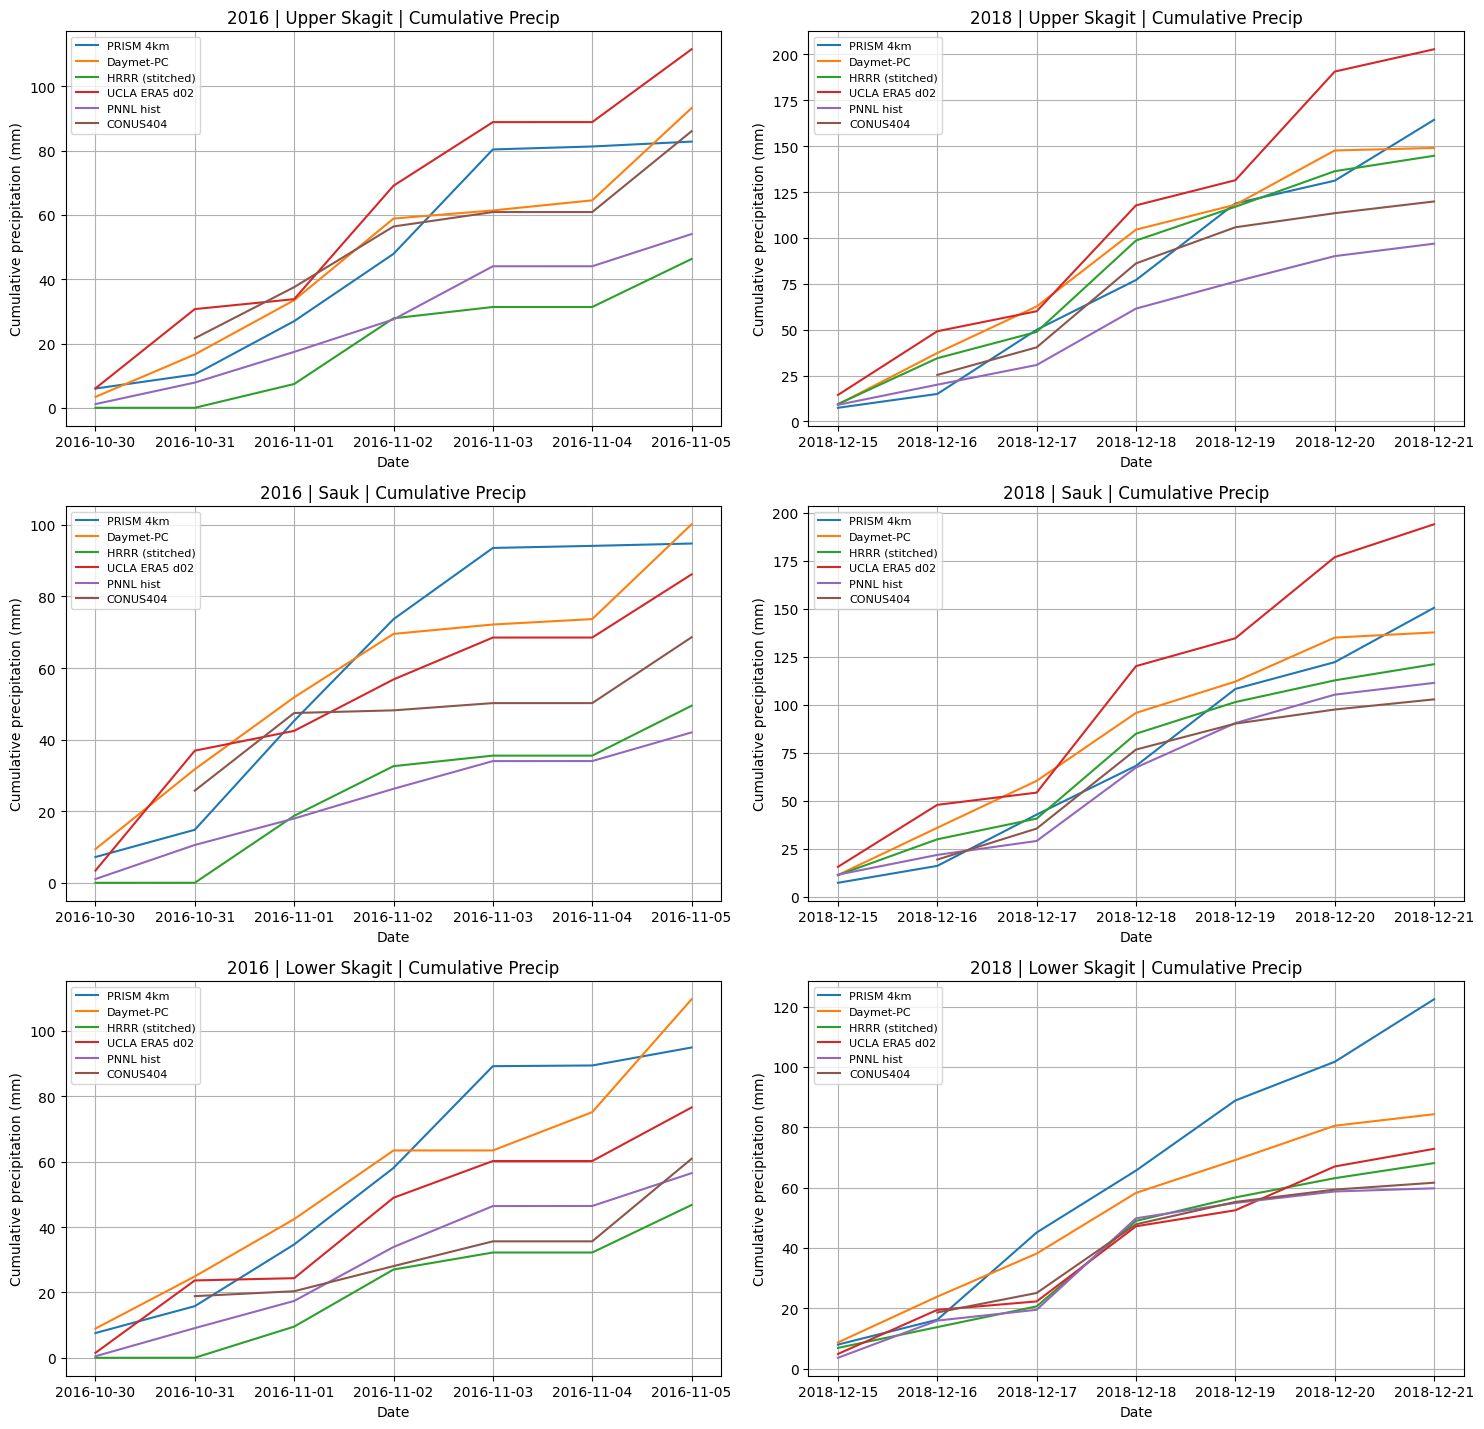


Saved MAE CSV → /data0/balaji24/data/derived/event_mae_vs_prism4km_mm_per_day__SUBBASINS.csv
    event_year       start         end        region  reference  \
0         2016  2016-10-30  2016-11-05  Lower Skagit  PRISM 4km   
1         2016  2016-10-30  2016-11-05  Lower Skagit  PRISM 4km   
2         2016  2016-10-30  2016-11-05  Lower Skagit  PRISM 4km   
3         2016  2016-10-30  2016-11-05  Lower Skagit  PRISM 4km   
4         2016  2016-10-30  2016-11-05  Lower Skagit  PRISM 4km   
5         2016  2016-10-30  2016-11-05          Sauk  PRISM 4km   
6         2016  2016-10-30  2016-11-05          Sauk  PRISM 4km   
7         2016  2016-10-30  2016-11-05          Sauk  PRISM 4km   
8         2016  2016-10-30  2016-11-05          Sauk  PRISM 4km   
9         2016  2016-10-30  2016-11-05          Sauk  PRISM 4km   
10        2016  2016-10-30  2016-11-05  Upper Skagit  PRISM 4km   
11        2016  2016-10-30  2016-11-05  Upper Skagit  PRISM 4km   
12        2016  2016-10-30  2016-11

In [ ]:
# ============================================================
# Skagit Basin – Event CUMULATIVE Precip comparison + VERIFICATION + MAE vs PRISM 4km
# NOW WITH SUB-BASIN PLOTS (Upper Skagit / Sauk / Lower Skagit)
#
# SOURCES:
# - PRISM (local zarr)                         BASE/prism_ppt
# - Daymet v4 (Planetary Computer)             (external zarr via STAC + SAS) 
# - HRRR (monthly zarr stitched)               BASE/weather_data
# - UCLA ERA5 WRF d02 (daily NetCDF)           /data0/.../ucla_era5_d02_daily/prec
# - PNNL historical WRF (hourly NetCDF)        BASE/PNNL/historical
# - CONUS404 (external OSN via HyTEST intake)  conus404-daily-osn


# Daymet: fresh SAS per event + eager .load() + close session
# Daymet: avoid "multiple values for consolidated" by removing consolidated from open_kwargs
# PNNL + CONUS404 included in plots + MAE
# NEW: sub-basin plots + MAE per sub-basin
# basin_mean_daily_from_gridded() no longer throws UnboundLocalError
# ============================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
import regionmask
import intake
import shapely
import sys, time
from urllib.parse import urlsplit, urlunsplit

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/balaji24/data")

P_PRISM_DIR = BASE / "prism_ppt"
P_HRRR_DIR  = BASE / "weather_data"

# UCLA ERA5 WRF d02 daily NetCDF
UCLA_PREC_DIR      = Path("/data0/balaji24/data/ucla_era5_d02_daily/prec")
UCLA_PREC_TEMPLATE = "prec.daily.era5.d02.{year}.nc"
UCLA_COORD_FILE    = Path("/data0/balaji24/data/ucla_era5_d02_daily/static/wrfinput_d02_coord.nc")

# PNNL historical (hourly NetCDF per year) + geo grid for mask
P_PNNL_DIR = BASE / "PNNL" / "historical"
P_PNNL_GEO = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"

# Basin boundary (still used for reference / optional)
BOUNDARY_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json")

# Sub-basin polygons (HUC8)
HUC8_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitSubBasin_HUC8.geojson")
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)
MAE_CSV = OUT / "event_mae_vs_prism4km_mm_per_day__SUBBASINS.csv"

# External (CONUS404)
CONUS_INTAKE_YML = (
    "https://raw.githubusercontent.com/hytest-org/hytest/main/"
    "dataset_catalog/hytest_intake_catalog.yml"
)
CONUS_MAX_TIME = np.datetime64("2022-10-01")

# ----------------------------
# EVENTS
# ----------------------------
events = [
    {"event_year": 2016, "start": "2016-10-30", "end": "2016-11-05"},
    {"event_year": 2018, "start": "2018-12-15", "end": "2018-12-21"},
]

# ============================================================
# HELPERS
# ============================================================

def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def pick_var(ds, names):
    for n in names:
        if n in ds.data_vars:
            return n
    return None

def units_str(ds, var):
    return ds[var].attrs.get("units", "(missing)")

def print_units(ds, var, label):
    print(f"  - {label}: var='{var}', units='{units_str(ds, var)}'")

def load_basin_geom():
    gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    try:
        return gdf.geometry.union_all()
    except Exception:
        return gdf.geometry.unary_union

def load_subbasin_geoms():
    """
    Reads HUC8 geojson and returns dict {RegionName: shapely_geom} in EPSG:4326.
    Tries to match REGION_NAMES by name-like columns.
    """
    if not HUC8_GEO.exists():
        raise FileNotFoundError(f"Missing sub-basin geojson: {HUC8_GEO}")

    gdf = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

    # Heuristic to find the name column
    name_cols = [c for c in gdf.columns if c.lower() in ("name", "names", "huc8_name", "subbasin", "basin", "huc_name")]
    if not name_cols:
        name_cols = [c for c in gdf.columns if "name" in c.lower()]

    if not name_cols:
        raise RuntimeError(f"Could not find a name column in {HUC8_GEO}. Columns={list(gdf.columns)}")

    name_col = name_cols[0]
    geoms = {}

    gdf["_nm_"] = gdf[name_col].astype(str).str.strip()

    for target in REGION_NAMES:
        sub = gdf[gdf["_nm_"].str.lower() == target.lower()]
        if sub.empty:
            sub = gdf[gdf["_nm_"].str.lower().str.contains(target.lower(), regex=False)]
        if sub.empty:
            raise RuntimeError(f"Could not match region '{target}' in {HUC8_GEO} using column '{name_col}'")

        try:
            geom = sub.geometry.union_all()
        except Exception:
            geom = sub.geometry.unary_union
        geoms[target] = geom

    return geoms

def median_timestep_seconds(time_index):
    if len(time_index) < 2:
        return None
    dt = pd.Series(time_index).diff().dt.total_seconds().median()
    return float(dt) if pd.notnull(dt) else None

def ensure_daily_sum(da):
    """Sum to daily totals (safe for both hourly and daily)."""
    if da is None or "time" not in da.dims:
        return da
    t = pd.to_datetime(da["time"].values)
    dt = median_timestep_seconds(t)
    if dt is None:
        return da
    return da.resample(time="1D").sum()

def is_plottable_1d(da):
    if da is None:
        return False
    if da.ndim != 1 or da.size == 0:
        return False
    try:
        v = da.values
        return np.isfinite(v).any()
    except Exception:
        return False

def reset_safe_increment(acc_like_1d):
    """
    Reset-safe increments for an accumulated series (1D time):
      inc[t] = diff if diff>=0 else current_value (reset)
    Output aligns to time[1:].
    """
    d = acc_like_1d.diff("time")
    curr = acc_like_1d.isel(time=slice(1, None))
    inc = xr.where(d >= 0, d, curr)
    return inc.clip(min=0)

def accumulated_to_daily_mm(acc_like_1d, label):
    """
    Convert accumulated precip (mm) -> increments (mm/step) -> daily totals (mm/day).
    acc_like_1d MUST be 1D (time).
    """
    bm = acc_like_1d
    if bm.size < 3:
        return bm.clip(min=0).resample(time="1D").sum()

    d = bm.diff("time")
    frac_neg = float((d < 0).mean())
    mean_raw = float(bm.mean())
    mean_diff_pos = float(d.clip(min=0).mean())
    print(f"    [{label}] accum-check: frac_neg={frac_neg:.3f}, mean_raw={mean_raw:.4g}, mean_diff_pos={mean_diff_pos:.4g}")

    inc = reset_safe_increment(bm)
    daily = ensure_daily_sum(inc)
    return daily

# ============================================================
# VERIFICATION PRINTS
# ============================================================

def debug_daily(label, daily_da):
    """Print distribution stats for a DAILY (mm/day) 1D time series."""
    if daily_da is None or "time" not in daily_da.dims or daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (empty)")
        return
    daily_da = daily_da.dropna("time")
    if daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (all NaN)")
        return
    print(f"\n[{label}] DAILY CHECK")
    print("  min:", float(daily_da.min()))
    print("  max:", float(daily_da.max()))
    print("  mean:", float(daily_da.mean()))
    print("  sum:", float(daily_da.sum()))

def _median_dt_hours_from_da(da):
    if da is None or "time" not in da.dims:
        return None
    t = pd.to_datetime(da["time"].values)
    if len(t) < 2:
        return None
    dt_hours = pd.Series(t).diff().dt.total_seconds().dropna().median() / 3600.0
    return float(dt_hours) if pd.notnull(dt_hours) else None

def verify_daily_and_cumsum(label, daily_da, cum_da=None, top_n=5):
    """
    Verifies:
      - dt sanity
      - daily stats
      - sum(daily) == last(cumsum) (if cum passed)
      - top-N daily increments
    """
    if daily_da is None or daily_da.size == 0:
        print(f"\n===== VERIFY: {label} =====")
        print("  (no data)")
        return

    daily_da = daily_da.dropna("time").sortby("time")
    print(f"\n===== VERIFY: {label} =====")
    dt_hours = _median_dt_hours_from_da(daily_da)
    if dt_hours is not None:
        print(f"  median dt (hours): {dt_hours:.2f}")

    debug_daily(label, daily_da)

    if cum_da is not None and is_plottable_1d(cum_da):
        try:
            cum_last = float(cum_da.dropna("time").isel(time=-1))
            daily_sum = float(daily_da.sum())
            print("  CHECK: daily.sum vs cum[-1]:", daily_sum, cum_last, " | diff:", daily_sum - cum_last)
        except Exception as e:
            print("  CHECK: daily.sum vs cum[-1]: (failed)", repr(e))

    try:
        top = daily_da.sortby(daily_da, ascending=False).isel(time=slice(0, min(top_n, daily_da.size)))
        print(f"  TOP {min(top_n, daily_da.size)} daily values:")
        for tt, vv in zip(pd.to_datetime(top["time"].values), np.asarray(top.values)):
            print("   ", tt.date(), float(vv))
    except Exception as e:
        print("  TOP daily values: (failed)", repr(e))

# ============================================================
# MASKING UTIL (REGION MEAN ON ANY GRID WITH lon/lat)
# ============================================================

_MASK_CACHE = {}  # key -> xr.DataArray bool with spatial dims

def _geom_key(geom):
    try:
        return geom.wkb_hex
    except Exception:
        return str(geom)

def _infer_lonlat_vars(ds):
    lon_candidates = ["lon", "longitude", "XLONG", "XLONG_M", "xlong", "xlong_m"]
    lat_candidates = ["lat", "latitude", "XLAT", "XLAT_M", "xlat", "xlat_m"]

    def _get(name):
        if name in ds.coords:
            return ds.coords[name]
        if name in ds.data_vars:
            return ds.data_vars[name]
        if name in ds.variables:
            return ds[name]
        return None

    lon = None
    lat = None

    for n in lon_candidates:
        lon = _get(n)
        if lon is not None:
            break
    for n in lat_candidates:
        lat = _get(n)
        if lat is not None:
            break

    if lon is None or lat is None:
        for v in list(ds.variables):
            if lon is None and "lon" in v.lower() and getattr(ds[v], "ndim", 0) >= 1:
                lon = ds[v]
            if lat is None and "lat" in v.lower() and getattr(ds[v], "ndim", 0) >= 1:
                lat = ds[v]
            if lon is not None and lat is not None:
                break

    if lon is None or lat is None:
        return None, None

    for d in list(getattr(lon, "dims", [])):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})
    for d in list(getattr(lat, "dims", [])):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})

    return lon, lat

def _sorted_unique_time(da: xr.DataArray) -> xr.DataArray:
    if da is None or "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = pd.to_datetime(da["time"].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

# bm is always defined or we return None safely
def basin_mean_daily_from_gridded(ds, var, start, end, geom, label_for_print, assume_accumulated=False):
    if "time" not in ds.dims and "Time" in ds.dims:
        ds = ds.rename({"Time": "time"})
    if "time" not in ds[var].dims and ("Time" in ds[var].dims):
        ds = ds.rename({"Time": "time"})
    if "time" not in ds[var].dims:
        print(f"  - {label_for_print}: (no time dim on var '{var}')")
        return None

    da0 = _sorted_unique_time(ds[var])
    da = da0.sel(time=slice(start, end))
    if da.sizes.get("time", 0) == 0:
        print(f"  - {label_for_print}: (no data in window)")
        return None

    da = da.sortby("time")
    spatial = [d for d in da.dims if d != "time"]
    if len(spatial) not in (1, 2):
        print(f"  - {label_for_print}: unexpected spatial dims={spatial}")
        return None

    bm = None  # ALWAYS defined

    if len(spatial) == 1:
        bm = da.mean(dim=spatial, skipna=True)
    else:
        d0, d1 = spatial
        key = (label_for_print, _geom_key(geom), d0, d1, da.sizes[d0], da.sizes[d1])

        mask_da = _MASK_CACHE.get(key)
        if mask_da is None:
            lon, lat = _infer_lonlat_vars(ds)

            if lon is None or lat is None:
                print(f"  - {label_for_print}: could not infer lon/lat -> fallback to spatial mean")
                bm = da.mean(dim=spatial, skipna=True)
            else:
                try:
                    reg = regionmask.Regions([geom])
                    rid = reg.mask(lon, lat)
                    mask_geo = ~xr.ufuncs.isnan(rid)
                    mask_np = np.asarray(mask_geo.data).astype(bool)

                    if mask_np.shape == (da.sizes[d0], da.sizes[d1]):
                        pass
                    elif mask_np.shape == (da.sizes[d1], da.sizes[d0]):
                        mask_np = mask_np.T
                    else:
                        print(f"  - {label_for_print}: mask shape {mask_np.shape} != grid {(da.sizes[d0], da.sizes[d1])} -> fallback mean")
                        bm = da.mean(dim=spatial, skipna=True)

                    if bm is None:
                        mask_da = xr.DataArray(mask_np, dims=(d0, d1))
                        _MASK_CACHE[key] = mask_da
                except Exception as e:
                    print(f"  - {label_for_print}: mask build failed ({type(e).__name__}): {e} -> fallback mean")
                    bm = da.mean(dim=spatial, skipna=True)

        if bm is None:
            mask_da = _MASK_CACHE.get(key)
            if mask_da is None:
                bm = da.mean(dim=spatial, skipna=True)
            else:
                bm = da.where(mask_da).mean(dim=(d0, d1), skipna=True)

    units = str(da.attrs.get("units", "")).lower().strip()
    if units in {"m", "meter", "meters", "metre", "metres"}:
        bm = bm * 1000.0

    if assume_accumulated:
        bm_daily = accumulated_to_daily_mm(bm, label=f"{label_for_print} accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    return bm_daily.sortby("time")

# ============================================================
# PRISM
# ============================================================

_PRISM_NAME_RE = re.compile(
    r"(?P<s>\d{4}-\d{2}-\d{2})_(?P<e>\d{4}-\d{2}-\d{2})_daily_(?P<tag>4km|800m)_PRISM_data\.zarr$"
)

def find_prism_zarr_covering(start, end, tag):
    start = pd.Timestamp(start)
    end   = pd.Timestamp(end)

    candidates = []
    for p in P_PRISM_DIR.glob(f"*_daily_{tag}_PRISM_data.zarr"):
        m = _PRISM_NAME_RE.search(p.name)
        if not m:
            continue
        f0 = pd.Timestamp(m.group("s"))
        f1 = pd.Timestamp(m.group("e"))
        if f0 <= start and f1 >= end:
            span_days = (f1 - f0).days
            candidates.append((span_days, f0, p))

    if not candidates:
        return None

    candidates.sort(key=lambda t: (t[0], -t[1].value))
    return candidates[0][2]

def load_prism_daily(start, end, tag, geom, region_label, do_verify=True):
    z = find_prism_zarr_covering(start, end, tag)
    if z is None:
        print(f"  - PRISM {tag}: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["ppt", "precip", "prcp"])
    if var is None:
        print(f"  - PRISM {tag} [{z.name}]: (no precip var found)")
        ds.close()
        return None

    print_units(ds, var, f"PRISM {tag} [{z.name}]")
    bm_daily = basin_mean_daily_from_gridded(
        ds, var, start, end, geom,
        label_for_print=f"PRISM {tag} | {region_label}",
        assume_accumulated=False
    )

    if bm_daily is not None and do_verify:
        verify_daily_and_cumsum(f"PRISM {tag} | {region_label}", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

# ============================================================
# Daymet (Planetary Computer) — FIXED consolidated conflict + eager load
# ============================================================

def ensure_daymet_pkgs():
    needed = ["pystac-client", "planetary-computer", "pyproj", "fsspec", "zarr"]
    import importlib, subprocess
    missing = []
    for p in needed:
        mod = p.replace("-", "_")
        try:
            importlib.import_module(mod)
        except Exception:
            missing.append(p)
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

ensure_daymet_pkgs()

from pystac_client import Client
import planetary_computer as pc
from pyproj import CRS, Transformer
from fsspec.implementations.http import HTTPFileSystem
from shapely.ops import transform as shp_transform

class SASEndAppendingHTTPFileSystem(HTTPFileSystem):
    def __init__(self, sas_query: str, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._sas_query = sas_query.lstrip("?")

    def _with_sas(self, url: str) -> str:
        return url if "?" in url else f"{url}?{self._sas_query}"

    def _open(self, path, mode="rb", block_size=None, **kwargs):
        return super()._open(self._with_sas(path), mode=mode, block_size=block_size, **kwargs)

    async def _cat_file(self, url, start=None, end=None, **kwargs):
        return await super()._cat_file(self._with_sas(url), start=start, end=end, **kwargs)

def daymet_lcc_crs():
    return CRS.from_proj4(
        "+proj=lcc +lat_1=25 +lat_2=60 +lat_0=42.5 +lon_0=-100 "
        "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )

_DAYMET_TFM_LL_TO_XY = Transformer.from_crs("EPSG:4326", daymet_lcc_crs(), always_xy=True)

def get_daymet_mapper_and_fs():
    stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
    col = stac.get_collection("daymet-daily-na")
    asset_key = "zarr-https" if "zarr-https" in col.assets else "zarr-abfs"
    signed_href = pc.sign(col.assets[asset_key].href)

    parts = urlsplit(signed_href)
    root_no_query = urlunsplit((parts.scheme, parts.netloc, parts.path, "", ""))
    sas_query = parts.query

    fs = SASEndAppendingHTTPFileSystem(sas_query)
    mapper = fs.get_mapper(root_no_query)

    open_kwargs = col.assets[asset_key].extra_fields.get("xarray:open_kwargs", {})
    return mapper, fs, open_kwargs

def lonlat_to_daymet_xy_bounds(geom_wgs84, pad_m=5000.0):
    minx, miny, maxx, maxy = geom_wgs84.bounds
    corners = [(minx, miny), (minx, maxy), (maxx, miny), (maxx, maxy)]
    xs, ys = zip(*[_DAYMET_TFM_LL_TO_XY.transform(lon, lat) for lon, lat in corners])
    return (float(min(xs) - pad_m), float(max(xs) + pad_m),
            float(min(ys) - pad_m), float(max(ys) + pad_m))

def _daymet_project_geom_to_xy(geom_ll):
    def _proj(x, y, z=None):
        return _DAYMET_TFM_LL_TO_XY.transform(x, y)
    return shp_transform(_proj, geom_ll)

_DAYMET_MASK_CACHE = {}

def load_daymet_pc_daily(start, end, geom_ll, region_label, do_verify=True):
    for attempt in range(1, 4):
        ds = None
        fs = None
        try:
            mapper, fs, open_kwargs = get_daymet_mapper_and_fs()

            open_kwargs = dict(open_kwargs)
            open_kwargs.pop("consolidated", None)

            ds = xr.open_zarr(mapper, **open_kwargs)

            if "prcp" not in ds:
                raise RuntimeError("Daymet dataset missing 'prcp'")

            print_units(ds, "prcp", "Daymet-PC (Daymet v4)")
            prcp = ds["prcp"]

            units = str(prcp.attrs.get("units", "")).lower().strip()
            if units in {"m", "meter", "meters", "metre", "metres"}:
                prcp = prcp * 1000.0
                prcp.attrs["units"] = "mm"

            xmin, xmax, ymin, ymax = lonlat_to_daymet_xy_bounds(geom_ll, pad_m=5000.0)

            y0 = float(ds["y"].values[0])
            y1 = float(ds["y"].values[-1])
            y_slice = slice(ymax, ymin) if y0 > y1 else slice(ymin, ymax)

            pr = prcp.sel(time=slice(start, end), x=slice(xmin, xmax), y=y_slice).chunk({"time": -1, "y": 256, "x": 256})
            if pr.sizes.get("time", 0) == 0:
                print("  - Daymet-PC: (no data in window)")
                return None

            pr = _sorted_unique_time(pr).sortby("time")

            key = (
                region_label,
                _geom_key(geom_ll),
                float(pr["x"].values[0]), float(pr["x"].values[-1]),
                float(pr["y"].values[0]), float(pr["y"].values[-1]),
                int(pr.sizes["x"]), int(pr.sizes["y"]),
            )

            mask = _DAYMET_MASK_CACHE.get(key)
            if mask is None:
                xx, yy = xr.broadcast(pr["x"], pr["y"])
                geom_xy = _daymet_project_geom_to_xy(geom_ll)
                from shapely import contains_xy
                mask_np = contains_xy(geom_xy, np.asarray(xx.values), np.asarray(yy.values))
                mask = xr.DataArray(mask_np, dims=xx.dims, coords=xx.coords)
                _DAYMET_MASK_CACHE[key] = mask

            bm_daily = pr.where(mask).mean(dim=("y", "x"), skipna=True)
            bm_daily = ensure_daily_sum(bm_daily).sortby("time")

            bm_daily = bm_daily.load()

            if do_verify:
                verify_daily_and_cumsum(f"Daymet-PC | {region_label}", bm_daily, bm_daily.cumsum("time"))

            return bm_daily

        except Exception as e:
            print(f"[DAYMET-PC] attempt {attempt}/3 failed ({type(e).__name__}): {e}")
            time.sleep(5 * attempt)
        finally:
            if ds is not None:
                try: ds.close()
                except Exception: pass
            if fs is not None:
                try: fs.close_session()
                except Exception: pass

    print("  - Daymet-PC: (failed after retries)")
    return None

# ============================================================
# HRRR (monthly stitched)
# ============================================================

def hrrr_hourly_precip_mm(ds, var="tp"):
    da = ds[var]
    probe = da.isel({k: 0 for k in da.dims if k not in ("time", "step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9

    if not is_cum:
        return da

    da = da.sortby("time")
    dif = da.diff("time", label="upper")
    dif = xr.where(dif < 0, 0, dif)
    dif = dif.fillna(0)
    dif = xr.concat([da.isel(time=slice(0, 1)) * 0, dif], dim="time")
    return dif

def load_hrrr_daily(start, end, geom, region_label, do_verify=True):
    if not P_HRRR_DIR.exists():
        print("  - HRRR: (dir missing)")
        return None

    monthly = sorted([p for p in P_HRRR_DIR.glob("*.zarr") if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)])
    if not monthly:
        print("  - HRRR: (no monthly zarrs found)")
        return None

    start_ts = pd.Timestamp(start)
    end_ts   = pd.Timestamp(end)
    need = pd.period_range(start_ts.to_period("M"), end_ts.to_period("M"), freq="M")
    need_prefixes = {f"{p.year}-{p.month:02d}" for p in need}

    available = {p.name[:7] for p in monthly}
    missing = sorted(list(need_prefixes - available))
    if missing:
        print(f"  - HRRR: missing months {missing} -> skipping HRRR for this event")
        return None

    parts = sorted([p for p in monthly if p.name[:7] in need_prefixes], key=lambda p: p.name[:7])

    ds0 = safe_open_zarr(parts[0])
    var = "tp" if "tp" in ds0 else ("apcp" if "apcp" in ds0 else None)
    if not var:
        print(f"  - HRRR: no tp/apcp in {parts[0].name} -> skipping")
        try: ds0.close()
        except Exception: pass
        return None

    dsets = []
    ok = True
    for p in parts:
        dsm = safe_open_zarr(p)
        if var not in dsm:
            print(f"  - HRRR: {p.name} missing {var} -> skipping")
            try: dsm.close()
            except Exception: pass
            ok = False
            break
        dsets.append(dsm[[var]])

    if not ok:
        for d in dsets:
            try: d.close()
            except Exception: pass
        try: ds0.close()
        except Exception: pass
        return None

    ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override").sortby("time")
    print_units(ds, var, "HRRR (stitched monthly zarr)")

    hourly_mm = hrrr_hourly_precip_mm(ds, var=var)
    daily = hourly_mm.resample(time="1D").sum()

    ds_daily = xr.Dataset({var: daily})
    for c in ["lon", "lat", "longitude", "latitude", "XLONG", "XLAT", "XLONG_M", "XLAT_M"]:
        if c in ds0:
            ds_daily[c] = ds0[c]

    bm_daily = basin_mean_daily_from_gridded(
        ds_daily, var, start, end, geom,
        label_for_print=f"HRRR | {region_label}",
        assume_accumulated=False
    )
    if bm_daily is not None and do_verify:
        verify_daily_and_cumsum(f"HRRR | {region_label}", bm_daily, bm_daily.cumsum("time"))

    for d in dsets:
        try: d.close()
        except Exception: pass
    try: ds0.close()
    except Exception: pass

    return bm_daily

# ============================================================
# UCLA ERA5 d02 (daily NetCDF) — per-region mask cache
# ============================================================

def ucla_file_label_for_date(dt: pd.Timestamp) -> int:
    return dt.year if dt.month >= 9 else (dt.year - 1)

def open_ucla_prec_for_window(t0: str, t1: str):
    t0_ts = pd.Timestamp(t0)
    t1_ts = pd.Timestamp(t1)
    labels_needed = sorted({ucla_file_label_for_date(t0_ts), ucla_file_label_for_date(t1_ts)})

    files = []
    for lab in labels_needed:
        f = UCLA_PREC_DIR / UCLA_PREC_TEMPLATE.format(year=lab)
        if f.exists():
            files.append(str(f))

    if not files:
        return None, []

    dsets = []
    pr_list = []
    for f in files:
        ds = xr.open_dataset(f, engine="netcdf4", decode_cf=True, mask_and_scale=True)
        if "prec" not in ds:
            ds.close()
            continue
        pr = ds["prec"]
        if "time" not in pr.dims:
            tdim = "day" if "day" in pr.dims else None
            if tdim is None:
                for d in pr.dims:
                    if "time" in d.lower() or "day" in d.lower():
                        tdim = d
                        break
            if tdim is not None and tdim != "time":
                pr = pr.rename({tdim: "time"})
        pr_list.append(pr)
        dsets.append(ds)

    if not pr_list:
        return None, []

    pr_all = xr.concat(pr_list, dim="time", join="outer", coords="minimal", compat="override")
    pr_all = pr_all.sortby("time")
    try:
        tt = pd.to_datetime(pr_all["time"].values)
        _, idx = np.unique(tt, return_index=True)
        pr_all = pr_all.isel(time=np.sort(idx))
    except Exception:
        pass

    pr_all = pr_all.sel(time=slice(t0, t1))
    if pr_all.sizes.get("time", 0) == 0:
        for ds in dsets:
            try: ds.close()
            except Exception: pass
        return None, []

    return pr_all, dsets

_UCLA_MASKS = {}  # region_label -> mask2d

def build_ucla_basin_mask(coord_file: Path, geom):
    g = xr.open_dataset(coord_file, engine="netcdf4")
    lat = g["lat2d"].squeeze(drop=True).astype("float64")
    lon = g["lon2d"].squeeze(drop=True).astype("float64")
    g.close()

    lonv = lon.values.ravel()
    latv = lat.values.ravel()
    ny, nx = lon.shape

    try:
        from shapely import contains_xy
        m_flat = contains_xy(geom, lonv, latv)
    except Exception:
        import shapely as _sh
        from shapely.prepared import prep
        pg = prep(geom)
        m_flat = np.array([pg.contains(_sh.Point(x, y)) for x, y in zip(lonv, latv)], dtype=bool)

    mask2d = m_flat.reshape(ny, nx).astype(bool)
    return xr.DataArray(mask2d, dims=lon.dims, coords=lon.coords)

def load_ucla_era5_d02_daily(start, end, geom, region_label, do_verify=True):
    if not UCLA_PREC_DIR.exists() or not UCLA_COORD_FILE.exists():
        print("  - UCLA ERA5 d02: (missing dir or coord file)")
        return None

    pr, parents = open_ucla_prec_for_window(start, end)
    if pr is None:
        print("  - UCLA ERA5 d02: (no files / no data in window)")
        return None

    try:
        print(f"  - UCLA ERA5 d02: var='prec', units='{pr.attrs.get('units', '(missing)')}'")

        units = str(pr.attrs.get("units", "")).lower().strip()
        if units in {"m", "meter", "meters", "metre", "metres"}:
            pr = pr * 1000.0
            pr.attrs["units"] = "mm"

        if region_label not in _UCLA_MASKS:
            _UCLA_MASKS[region_label] = build_ucla_basin_mask(UCLA_COORD_FILE, geom)
            m2d = _UCLA_MASKS[region_label]
            print(f"    [UCLA | {region_label}] mask cells inside: {int(m2d.sum())} / {m2d.size}")

        spatial = [d for d in pr.dims if d != "time"]
        if len(spatial) != 2:
            print(f"  - UCLA ERA5 d02: unexpected spatial dims={spatial}")
            return None

        mask = _UCLA_MASKS[region_label]
        if set(mask.dims) != set(spatial):
            rename_map = {}
            for md in mask.dims:
                for pdim in spatial:
                    if mask.sizes[md] == pr.sizes[pdim]:
                        rename_map[md] = pdim
                        break
            mask = mask.rename(rename_map)

        bm = pr.where(mask).mean(dim=spatial, skipna=True)
        bm_daily = ensure_daily_sum(bm).sortby("time")
        if do_verify:
            verify_daily_and_cumsum(f"UCLA ERA5 d02 | {region_label}", bm_daily, bm_daily.cumsum("time"))
        return bm_daily

    finally:
        for ds in parents:
            try: ds.close()
            except Exception: pass

# ============================================================
# PNNL hist (hourly accum → daily) — per-region mask cache
# ============================================================

_PNNL_MASKS = {}  # (region_label, grid_key) -> mask

def build_pnnl_mask_for_ds(ds_prec, geom):
    spatial = [d for d in ds_prec["PREC_ACC_NC"].dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"[PNNL] Unexpected spatial dims: {spatial}")

    d0, d1 = spatial[0], spatial[1]
    s0, s1 = ds_prec.sizes[d0], ds_prec.sizes[d1]

    geo = xr.open_dataset(P_PNNL_GEO)

    lat_name = next((c for c in ["XLAT_M", "XLAT", "lat", "LAT"] if c in geo), None)
    lon_name = next((c for c in ["XLONG_M", "XLONG", "lon", "LON"] if c in geo), None)
    if lat_name is None or lon_name is None:
        geo.close()
        raise RuntimeError(f"[PNNL geo] Could not find lat/lon vars. vars={list(geo.data_vars)[:60]}")

    lat = geo[lat_name]
    lon = geo[lon_name]

    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})
    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask_geo = ~xr.ufuncs.isnan(m)
    mask_np = np.asarray(mask_geo.data).astype(bool)
    geo.close()

    if mask_np.shape == (s0, s1):
        pass
    elif mask_np.shape == (s1, s0):
        mask_np = mask_np.T
    else:
        raise RuntimeError(
            f"[PNNL] Mask shape {mask_np.shape} does not match precip grid ({d0},{d1})={(s0,s1)}"
        )

    return xr.DataArray(mask_np, dims=(d0, d1))

def load_pnnl_daily(year, start, end, geom, region_label, do_verify=True):
    f1 = P_PNNL_DIR / str(year) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc"
    if f1.exists():
        f = f1
    else:
        cands = sorted((P_PNNL_DIR / str(year)).glob("*PREC_ACC_NC*.nc"))
        f = cands[0] if cands else None

    if f is None or not f.exists():
        print("  - PNNL hist: (not available)")
        return None

    ds = xr.open_dataset(f, chunks={"time": 24})
    if "PREC_ACC_NC" not in ds:
        print("  - PNNL hist: (PREC_ACC_NC missing)")
        ds.close()
        return None

    print_units(ds, "PREC_ACC_NC", f"PNNL hist [{f.name}]")

    spatial = [d for d in ds["PREC_ACC_NC"].dims if d != "time"]
    grid_key = (tuple(spatial), ds.sizes[spatial[0]], ds.sizes[spatial[1]])
    key = (region_label, grid_key)

    if key not in _PNNL_MASKS:
        _PNNL_MASKS[key] = build_pnnl_mask_for_ds(ds, geom)

    mask = _PNNL_MASKS[key]

    start_dt = pd.Timestamp(start)
    start_minus_1 = str(start_dt - pd.Timedelta(days=1))
    da = ds["PREC_ACC_NC"].sel(time=slice(start_minus_1, end)).sortby("time")
    bm_acc = da.where(mask).mean(dim=spatial, skipna=True)

    bm_daily = accumulated_to_daily_mm(bm_acc, label=f"PNNL hist | {region_label}").sortby("time")
    bm_daily = bm_daily.sel(time=slice(start, end))
    if do_verify:
        verify_daily_and_cumsum(f"PNNL hist | {region_label}", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

# ============================================================
# CONUS404 (external)
# ============================================================

_conus_ds = None
_conus_mask_cache = {}  # region_label -> mask

def get_conus():
    global _conus_ds
    if _conus_ds is None:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        _conus_ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    return _conus_ds

def load_conus_daily(start, end, geom, region_label, do_verify=True):
    global _conus_mask_cache

    if np.datetime64(end) > CONUS_MAX_TIME:
        print("  - CONUS404: skipped (out of range)")
        return None

    ds = get_conus()
    var = pick_var(ds, ["PREC_ACC_NC", "prcp", "precip", "precipitation", "PREC", "PRECIP", "RAIN", "RAINNC", "RAINC"])
    if var is None:
        print("  - CONUS404: (no precip var found)")
        return None

    print_units(ds, var, "CONUS404")

    if region_label not in _conus_mask_cache:
        lon = ds["lon"]
        lat = ds["lat"]
        mask_np = shapely.contains_xy(geom, lon.values, lat.values)
        _conus_mask_cache[region_label] = xr.DataArray(mask_np, dims=("y", "x"))

    mask = _conus_mask_cache[region_label]

    start_dt = pd.Timestamp(start)
    start_minus_1 = str(start_dt - pd.Timedelta(days=1))
    da = ds[var].sel(time=slice(start_minus_1, end)).sortby("time")
    bm = da.where(mask).mean(dim=("y", "x"), skipna=True)

    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = ("accum" in var.lower()) or ("accumul" in desc) or (var.upper() in ("RAINNC", "RAINC", "PREC_ACC_NC"))
    if looks_accum:
        bm_daily = accumulated_to_daily_mm(bm, label=f"CONUS404 accum | {region_label}")
        bm_daily = bm_daily.sel(time=slice(start, end))
    else:
        bm_daily = ensure_daily_sum(bm).sel(time=slice(start, end))

    bm_daily = bm_daily.sortby("time")
    if do_verify:
        verify_daily_and_cumsum(f"CONUS404 | {region_label}", bm_daily, bm_daily.cumsum("time"))
    return bm_daily

# ============================================================
# MAE util
# ============================================================

def mae_vs_reference_mm_per_day(ref_daily, other_daily):
    if ref_daily is None or other_daily is None:
        return np.nan, 0
    if ("time" not in ref_daily.dims) or ("time" not in other_daily.dims):
        return np.nan, 0

    a = ref_daily.dropna("time").sortby("time")
    b = other_daily.dropna("time").sortby("time")

    a2, b2 = xr.align(a, b, join="inner")
    if a2.size == 0 or b2.size == 0:
        return np.nan, 0

    diff = np.abs(a2 - b2)
    mae = float(diff.mean().values)
    n = int(diff.sizes.get("time", diff.size))
    return mae, n

# ============================================================
# MAIN (SUB-BASIN PLOTS)
# ============================================================

def main():
    sub_geoms = load_subbasin_geoms()

    n_events = len(events)
    n_regions = len(REGION_NAMES)

    fig, axs = plt.subplots(
        n_regions, n_events,
        figsize=(7.5 * n_events, 4.8 * n_regions),
        squeeze=False
    )

    mae_rows = []

    for c, ev in enumerate(events):
        yr = int(ev["event_year"])
        start = ev["start"]
        end = ev["end"]

        print(f"\n================ EVENT {yr} ({start} → {end}) ================")

        for r, region in enumerate(REGION_NAMES):
            geom = sub_geoms[region]
            ax = axs[r, c]

            print(f"\n----- Region: {region} -----")

            ref_daily = load_prism_daily(start, end, "4km", geom, region, do_verify=True)

            daily_series = [
                ("PRISM 4km",       ref_daily),
                ("PRISM 800m",      load_prism_daily(start, end, "800m", geom, region, do_verify=True)),
                ("Daymet-PC",       load_daymet_pc_daily(start, end, geom, region, do_verify=True)),
                ("HRRR (stitched)", load_hrrr_daily(start, end, geom, region, do_verify=True)),
                ("UCLA ERA5 d02",   load_ucla_era5_d02_daily(start, end, geom, region, do_verify=True)),
                ("PNNL hist",       load_pnnl_daily(yr, start, end, geom, region, do_verify=True)),
                ("CONUS404",        load_conus_daily(start, end, geom, region, do_verify=True)),
            ]

            plotted_any = False
            for label, dly in daily_series:
                if is_plottable_1d(dly):
                    cum = dly.cumsum("time")
                    ax.plot(pd.to_datetime(cum["time"].values), cum.values, label=label)
                    plotted_any = True

            title_suffix = " (2-Week)" if is_2week else ""
            ax.set_title(f"{yr} | {region} | Cumulative Precip{title_suffix}")
            ax.set_xlabel("Date")
            ax.set_ylabel("Cumulative precipitation (mm)")
            ax.grid(True)
            if plotted_any:
                ax.legend(fontsize=8)

            for label, dly in daily_series:
                if label == "PRISM 4km":
                    continue
                mae, n_days = mae_vs_reference_mm_per_day(ref_daily, dly)
                if n_days > 0 and np.isfinite(mae):
                    mae_rows.append({
                        "event_year": yr,
                        "start": start,
                        "end": end,
                        "region": region,
                        "reference": "PRISM 4km",
                        "dataset": label,
                        "mae_mm_per_day": mae,
                        "n_days": n_days,
                    })

    plt.tight_layout()
    plt.show()

    mae_df = pd.DataFrame(mae_rows).sort_values(["event_year", "region", "dataset"]).reset_index(drop=True)
    mae_csv_path = MAE_CSV
    if is_2week:
        mae_csv_path = MAE_CSV.parent / MAE_CSV.name.replace(".csv", "_2week.csv")
    mae_df.to_csv(mae_csv_path, index=False)
    print(f"\nSaved MAE CSV → {mae_csv_path}")
    print("\nSaved MAE CSV →", MAE_CSV)
    print(mae_df)

if __name__ == "__main__":
    main()


================ EVENT 2003 (2003-10-14 → 2003-10-19) ================

----- Region: Upper Skagit -----
  - PRISM 4km [2003-10-14_2003-10-19_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km | Upper Skagit =====
  median dt (hours): 24.00

[PRISM 4km | Upper Skagit] DAILY CHECK
  min: 0.46448037028312683
  max: 119.59271240234375
  mean: 37.49338912963867
  sum: 224.96034240722656
  CHECK: daily.sum vs cum[-1]: 224.96034240722656 224.9603271484375  | diff: 1.52587890625e-05
  TOP 5 daily values:
    2003-10-17 119.59271240234375
    2003-10-16 48.63895034790039
    2003-10-18 36.88969802856445
    2003-10-19 12.973715782165527
    2003-10-15 6.400787353515625
  - PRISM 800m [2003-10-14_2003-10-19_daily_800m_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 800m | Upper Skagit =====
  median dt (hours): 24.00

[PRISM 800m | Upper Skagit] DAILY CHECK
  min: 0.43626126646995544
  max: 118.59156036376953
  mean: 37.1938591003418
  sum: 22

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7870de0a5250>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7870ddae4650>, 360306.114363652)])']
connector: <aiohttp.connector.TCPConnector object at 0x7870ddbaa930>


  TOP 5 daily values:
    2003-10-17 78.57838439941406
    2003-10-16 25.18802261352539
    2003-10-19 10.840182304382324
    2003-10-18 3.5755796432495117
    2003-10-15 0.9883702397346497
  - CONUS404: var='PREC_ACC_NC', units='mm'


Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out


    [CONUS404 accum | Upper Skagit] accum-check: frac_neg=0.200, mean_raw=31.24, mean_diff_pos=20.9

===== VERIFY: CONUS404 | Upper Skagit =====
  median dt (hours): 24.00

[CONUS404 | Upper Skagit] DAILY CHECK
  min: 0.0122382752597332
  max: 70.0527114868164
  mean: 20.900043487548828
  sum: 104.5002212524414
  CHECK: daily.sum vs cum[-1]: 104.5002212524414 104.5002212524414  | diff: 0.0
  TOP 5 daily values:
    2003-10-16 70.0527114868164
    2003-10-19 15.401825904846191
    2003-10-17 12.597190856933594
    2003-10-15 6.43625545501709
    2003-10-18 0.0122382752597332

----- Region: Sauk -----
  - PRISM 4km [2003-10-14_2003-10-19_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km | Sauk =====
  median dt (hours): 24.00

[PRISM 4km | Sauk] DAILY CHECK
  min: 2.7860076427459717
  max: 96.96304321289062
  mean: 28.98569679260254
  sum: 173.9141845703125
  CHECK: daily.sum vs cum[-1]: 173.9141845703125 173.91416931152344  | diff: 1.52587890625e-05
  TOP

...


----- Region: Lower Skagit -----
  - PRISM 4km [2003-10-14_2003-10-19_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km | Lower Skagit =====
  median dt (hours): 24.00

[PRISM 4km | Lower Skagit] DAILY CHECK
  min: 0.13130304217338562
  max: 89.90966796875
  mean: 30.93752098083496
  sum: 185.6251220703125
  CHECK: daily.sum vs cum[-1]: 185.6251220703125 185.62510681152344  | diff: 1.52587890625e-05
  TOP 5 daily values:
    2003-10-17 89.90966796875
    2003-10-16 41.994136810302734
    2003-10-18 40.195030212402344
    2003-10-19 9.67481803894043
    2003-10-15 3.720151424407959
  - PRISM 800m [2003-10-14_2003-10-19_daily_800m_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 800m | Lower Skagit =====
  median dt (hours): 24.00

[PRISM 800m | Lower Skagit] DAILY CHECK
  min: 0.08766352385282516
  max: 89.38954162597656
  mean: 30.759077072143555
  sum: 184.55445861816406
  CHECK: daily.sum vs cum[-1]: 184.55445861816406 184.554458618

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7870dea9d4f0>



================ EVENT 2006 (2006-11-04 → 2006-11-07) ================

----- Region: Upper Skagit -----
  - PRISM 4km [2006-11-02_2006-11-11_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km | Upper Skagit =====
  median dt (hours): 24.00

[PRISM 4km | Upper Skagit] DAILY CHECK
  min: 54.31993103027344
  max: 118.44578552246094
  mean: 72.13892364501953
  sum: 288.5556945800781
  CHECK: daily.sum vs cum[-1]: 288.5556945800781 288.5556945800781  | diff: 0.0
  TOP 4 daily values:
    2006-11-07 118.44578552246094
    2006-11-06 59.1553955078125
    2006-11-05 56.634578704833984
    2006-11-04 54.31993103027344
  - PRISM 800m [2006-11-02_2006-11-11_daily_800m_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 800m | Upper Skagit =====
  median dt (hours): 24.00

[PRISM 800m | Upper Skagit] DAILY CHECK
  min: 53.804405212402344
  max: 117.83585357666016
  mean: 71.63096618652344
  sum: 286.52386474609375
  CHECK: daily.sum vs cum[-1]: 286.

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7870dea6a4b0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7870ddcd4e30>



===== VERIFY: Daymet-PC | Lower Skagit =====
  median dt (hours): 24.00

[Daymet-PC | Lower Skagit] DAILY CHECK
  min: 21.827407836914062
  max: 54.49992370605469
  mean: 38.017784118652344
  sum: 152.07113647460938
  CHECK: daily.sum vs cum[-1]: 152.07113647460938 152.07113647460938  | diff: 0.0
  TOP 4 daily values:
    2006-11-06 54.49992370605469
    2006-11-04 40.98154830932617
    2006-11-05 34.76225662231445
    2006-11-07 21.827407836914062
  - HRRR: missing months ['2006-11'] -> skipping HRRR for this event
  - UCLA ERA5 d02: var='prec', units='mm/d'

===== VERIFY: UCLA ERA5 d02 | Lower Skagit =====
  median dt (hours): 24.00

[UCLA ERA5 d02 | Lower Skagit] DAILY CHECK
  min: 10.623063087463379
  max: 40.067562103271484
  mean: 24.794374465942383
  sum: 99.17749786376953
  CHECK: daily.sum vs cum[-1]: 99.17749786376953 99.17749786376953  | diff: 0.0
  TOP 4 daily values:
    2006-11-04 40.067562103271484
    2006-11-06 36.3517951965332
    2006-11-07 12.135076522827148
    20

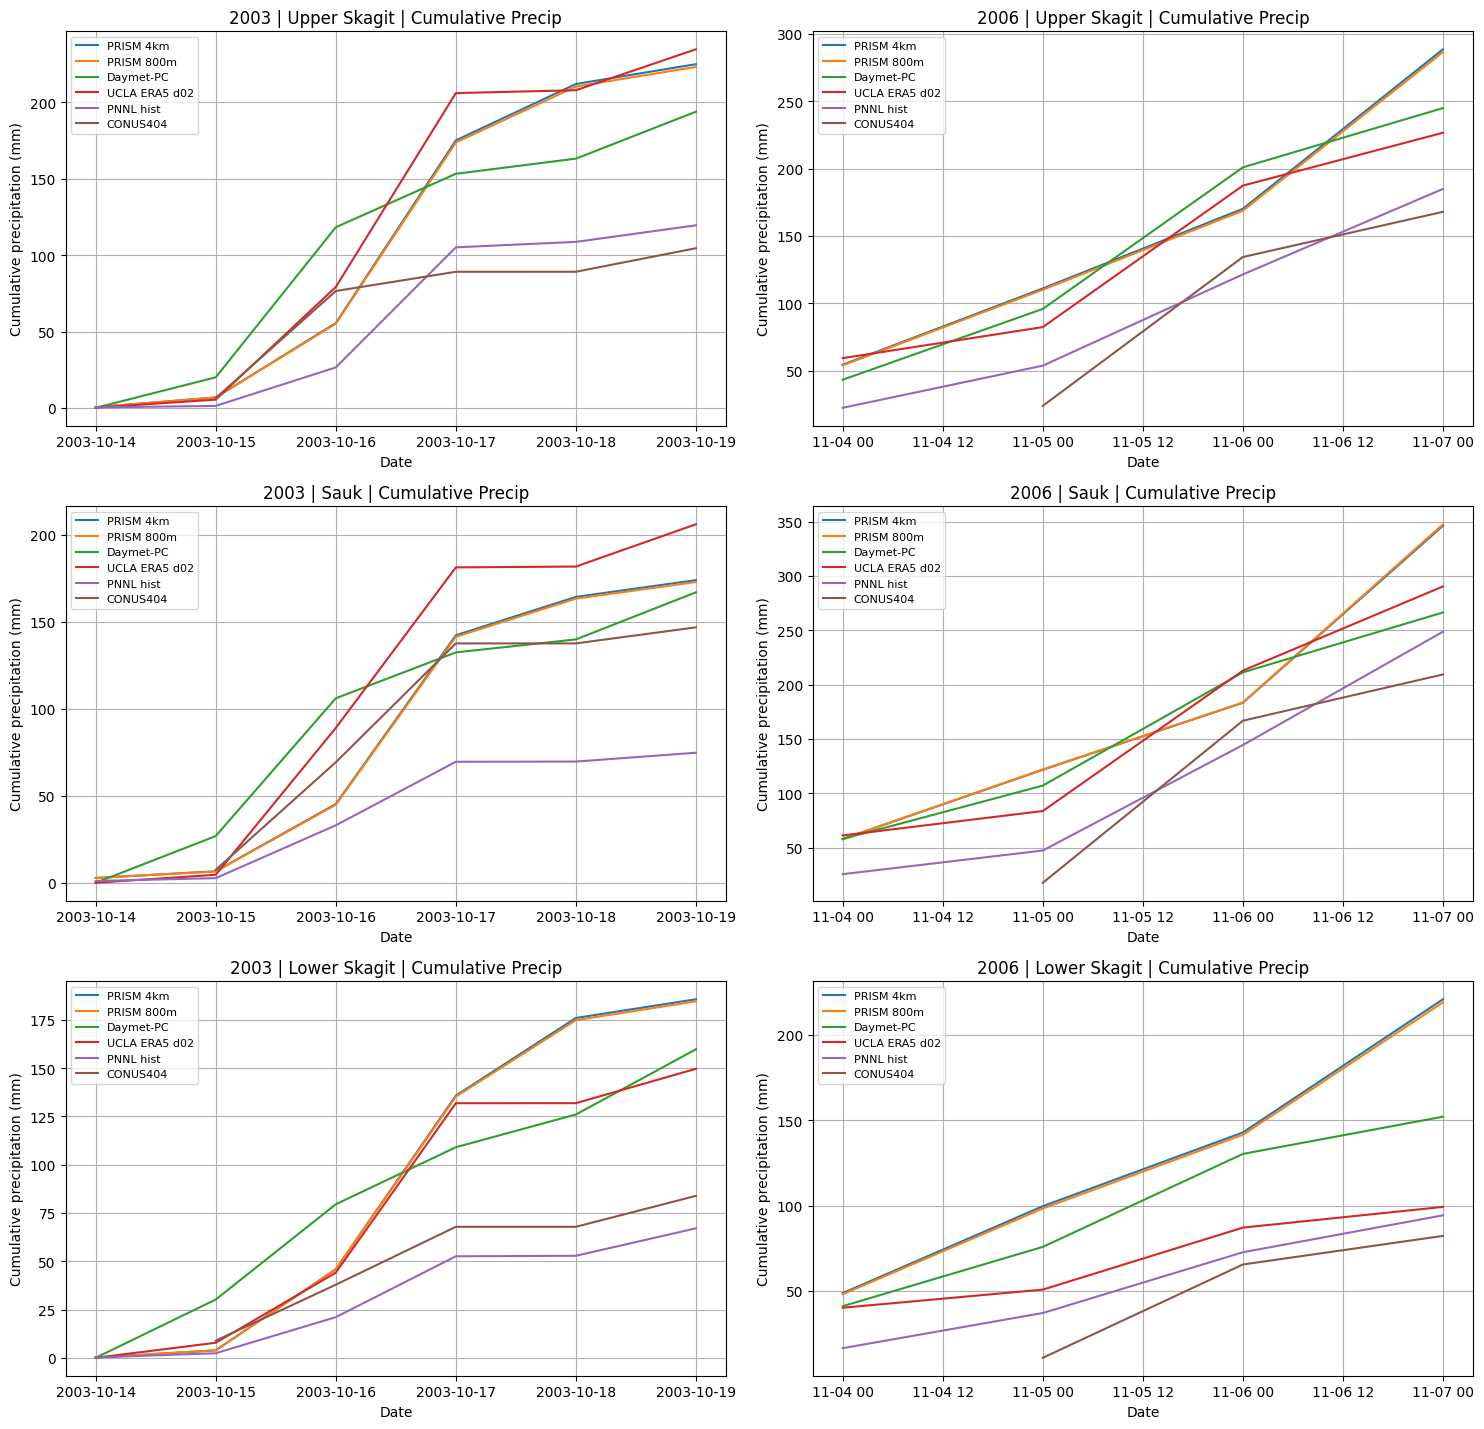


Saved MAE CSV → /data0/balaji24/data/derived/event_mae_vs_prism4km_mm_per_day__SUBBASINS.csv
    event_year       start         end        region  reference  \
0         2003  2003-10-14  2003-10-19  Lower Skagit  PRISM 4km   
1         2003  2003-10-14  2003-10-19  Lower Skagit  PRISM 4km   
2         2003  2003-10-14  2003-10-19  Lower Skagit  PRISM 4km   
3         2003  2003-10-14  2003-10-19  Lower Skagit  PRISM 4km   
4         2003  2003-10-14  2003-10-19  Lower Skagit  PRISM 4km   
5         2003  2003-10-14  2003-10-19          Sauk  PRISM 4km   
6         2003  2003-10-14  2003-10-19          Sauk  PRISM 4km   
7         2003  2003-10-14  2003-10-19          Sauk  PRISM 4km   
8         2003  2003-10-14  2003-10-19          Sauk  PRISM 4km   
9         2003  2003-10-14  2003-10-19          Sauk  PRISM 4km   
10        2003  2003-10-14  2003-10-19  Upper Skagit  PRISM 4km   
11        2003  2003-10-14  2003-10-19  Upper Skagit  PRISM 4km   
12        2003  2003-10-14  2003-10

In [ ]:
# ============================================================
# Skagit Basin – Event CUMULATIVE Precip comparison + VERIFICATION + MAE vs PRISM 4km
# NOW WITH SUB-BASIN PLOTS (Upper Skagit / Sauk / Lower Skagit)
#
# SOURCES:
# - PRISM (local zarr)                         BASE/prism_ppt
# - Daymet v4 (Planetary Computer)             (external zarr via STAC + SAS)
# - HRRR (monthly zarr stitched)               BASE/weather_data
# - UCLA ERA5 WRF d02 (daily NetCDF)           /data0/.../ucla_era5_d02_daily/prec
# - PNNL historical WRF (hourly NetCDF)        BASE/PNNL/historical
# - CONUS404 (external OSN via HyTEST intake)  conus404-daily-osn


# Daymet: fresh SAS per event + eager .load() + close session
# Daymet: avoid "multiple values for consolidated" by removing consolidated from open_kwargs
# PNNL + CONUS404 included in plots + MAE
# sub-basin plots + MAE per sub-basin
# basin_mean_daily_from_gridded() no longer throws UnboundLocalError
# ============================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
import regionmask
import intake
import shapely
import sys, time
from urllib.parse import urlsplit, urlunsplit

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/balaji24/data")

P_PRISM_DIR = BASE / "prism_nc"
P_HRRR_DIR  = BASE / "weather_data"

# UCLA ERA5 WRF d02 daily NetCDF
UCLA_PREC_DIR      = Path("/data0/balaji24/data/ucla_era5_d02_daily/prec")
UCLA_PREC_TEMPLATE = "prec.daily.era5.d02.{year}.nc"
UCLA_COORD_FILE    = Path("/data0/balaji24/data/ucla_era5_d02_daily/static/wrfinput_d02_coord.nc")

# PNNL historical (hourly NetCDF per year) + geo grid for mask
P_PNNL_DIR = BASE / "PNNL" / "historical"
P_PNNL_GEO = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"

# Basin boundary (still used for reference / optional)
BOUNDARY_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json")

# Sub-basin polygons (HUC8)
HUC8_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitSubBasin_HUC8.geojson")
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)
MAE_CSV = OUT / "event_mae_vs_prism4km_mm_per_day__SUBBASINS.csv"

# External (CONUS404)
CONUS_INTAKE_YML = (
    "https://raw.githubusercontent.com/hytest-org/hytest/main/"
    "dataset_catalog/hytest_intake_catalog.yml"
)
CONUS_MAX_TIME = np.datetime64("2022-10-01")

# ----------------------------
# EVENTS
# ----------------------------
events = [
    {"event_year": 2003, "start": "2003-10-14", "end": "2003-10-19"},
    {"event_year": 2006, "start": "2006-11-04", "end": "2006-11-07"},
]

# ============================================================
# HELPERS
# ============================================================

def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def pick_var(ds, names):
    for n in names:
        if n in ds.data_vars:
            return n
    return None

def units_str(ds, var):
    return ds[var].attrs.get("units", "(missing)")

def print_units(ds, var, label):
    print(f"  - {label}: var='{var}', units='{units_str(ds, var)}'")

def load_basin_geom():
    gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    try:
        return gdf.geometry.union_all()
    except Exception:
        return gdf.geometry.unary_union

def load_subbasin_geoms():
    """
    Reads HUC8 geojson and returns dict {RegionName: shapely_geom} in EPSG:4326.
    Tries to match REGION_NAMES by name-like columns.
    """
    if not HUC8_GEO.exists():
        raise FileNotFoundError(f"Missing sub-basin geojson: {HUC8_GEO}")

    gdf = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

    # Heuristic to find the name column
    name_cols = [c for c in gdf.columns if c.lower() in ("name", "names", "huc8_name", "subbasin", "basin", "huc_name")]
    if not name_cols:
        name_cols = [c for c in gdf.columns if "name" in c.lower()]

    if not name_cols:
        raise RuntimeError(f"Could not find a name column in {HUC8_GEO}. Columns={list(gdf.columns)}")

    name_col = name_cols[0]
    geoms = {}

    gdf["_nm_"] = gdf[name_col].astype(str).str.strip()

    for target in REGION_NAMES:
        sub = gdf[gdf["_nm_"].str.lower() == target.lower()]
        if sub.empty:
            sub = gdf[gdf["_nm_"].str.lower().str.contains(target.lower(), regex=False)]
        if sub.empty:
            raise RuntimeError(f"Could not match region '{target}' in {HUC8_GEO} using column '{name_col}'")

        try:
            geom = sub.geometry.union_all()
        except Exception:
            geom = sub.geometry.unary_union
        geoms[target] = geom

    return geoms

def median_timestep_seconds(time_index):
    if len(time_index) < 2:
        return None
    dt = pd.Series(time_index).diff().dt.total_seconds().median()
    return float(dt) if pd.notnull(dt) else None

def ensure_daily_sum(da):
    """Sum to daily totals (safe for both hourly and daily)."""
    if da is None or "time" not in da.dims:
        return da
    t = pd.to_datetime(da["time"].values)
    dt = median_timestep_seconds(t)
    if dt is None:
        return da
    return da.resample(time="1D").sum()

def is_plottable_1d(da):
    if da is None:
        return False
    if da.ndim != 1 or da.size == 0:
        return False
    try:
        v = da.values
        return np.isfinite(v).any()
    except Exception:
        return False

def reset_safe_increment(acc_like_1d):
    """
    Reset-safe increments for an accumulated series (1D time):
      inc[t] = diff if diff>=0 else current_value (reset)
    Output aligns to time[1:].
    """
    d = acc_like_1d.diff("time")
    curr = acc_like_1d.isel(time=slice(1, None))
    inc = xr.where(d >= 0, d, curr)
    return inc.clip(min=0)

def accumulated_to_daily_mm(acc_like_1d, label):
    """
    Convert accumulated precip (mm) -> increments (mm/step) -> daily totals (mm/day).
    acc_like_1d MUST be 1D (time).
    """
    bm = acc_like_1d
    if bm.size < 3:
        return bm.clip(min=0).resample(time="1D").sum()

    d = bm.diff("time")
    frac_neg = float((d < 0).mean())
    mean_raw = float(bm.mean())
    mean_diff_pos = float(d.clip(min=0).mean())
    print(f"    [{label}] accum-check: frac_neg={frac_neg:.3f}, mean_raw={mean_raw:.4g}, mean_diff_pos={mean_diff_pos:.4g}")

    inc = reset_safe_increment(bm)
    daily = ensure_daily_sum(inc)
    return daily

# ============================================================
# VERIFICATION PRINTS
# ============================================================

def debug_daily(label, daily_da):
    """Print distribution stats for a DAILY (mm/day) 1D time series."""
    if daily_da is None or "time" not in daily_da.dims or daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (empty)")
        return
    daily_da = daily_da.dropna("time")
    if daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (all NaN)")
        return
    print(f"\n[{label}] DAILY CHECK")
    print("  min:", float(daily_da.min()))
    print("  max:", float(daily_da.max()))
    print("  mean:", float(daily_da.mean()))
    print("  sum:", float(daily_da.sum()))

def _median_dt_hours_from_da(da):
    if da is None or "time" not in da.dims:
        return None
    t = pd.to_datetime(da["time"].values)
    if len(t) < 2:
        return None
    dt_hours = pd.Series(t).diff().dt.total_seconds().dropna().median() / 3600.0
    return float(dt_hours) if pd.notnull(dt_hours) else None

def verify_daily_and_cumsum(label, daily_da, cum_da=None, top_n=5):
    """
    Verifies:
      - dt sanity
      - daily stats
      - sum(daily) == last(cumsum) (if cum passed)
      - top-N daily increments
    """
    if daily_da is None or daily_da.size == 0:
        print(f"\n===== VERIFY: {label} =====")
        print("  (no data)")
        return

    daily_da = daily_da.dropna("time").sortby("time")
    print(f"\n===== VERIFY: {label} =====")
    dt_hours = _median_dt_hours_from_da(daily_da)
    if dt_hours is not None:
        print(f"  median dt (hours): {dt_hours:.2f}")

    debug_daily(label, daily_da)

    if cum_da is not None and is_plottable_1d(cum_da):
        try:
            cum_last = float(cum_da.dropna("time").isel(time=-1))
            daily_sum = float(daily_da.sum())
            print("  CHECK: daily.sum vs cum[-1]:", daily_sum, cum_last, " | diff:", daily_sum - cum_last)
        except Exception as e:
            print("  CHECK: daily.sum vs cum[-1]: (failed)", repr(e))

    try:
        top = daily_da.sortby(daily_da, ascending=False).isel(time=slice(0, min(top_n, daily_da.size)))
        print(f"  TOP {min(top_n, daily_da.size)} daily values:")
        for tt, vv in zip(pd.to_datetime(top["time"].values), np.asarray(top.values)):
            print("   ", tt.date(), float(vv))
    except Exception as e:
        print("  TOP daily values: (failed)", repr(e))

# ============================================================
# MASKING UTIL (REGION MEAN ON ANY GRID WITH lon/lat)
# ============================================================

_MASK_CACHE = {}  # key -> xr.DataArray bool with spatial dims

def _geom_key(geom):
    try:
        return geom.wkb_hex
    except Exception:
        return str(geom)

def _infer_lonlat_vars(ds):
    lon_candidates = ["lon", "longitude", "XLONG", "XLONG_M", "xlong", "xlong_m"]
    lat_candidates = ["lat", "latitude", "XLAT", "XLAT_M", "xlat", "xlat_m"]

    def _get(name):
        if name in ds.coords:
            return ds.coords[name]
        if name in ds.data_vars:
            return ds.data_vars[name]
        if name in ds.variables:
            return ds[name]
        return None

    lon = None
    lat = None

    for n in lon_candidates:
        lon = _get(n)
        if lon is not None:
            break
    for n in lat_candidates:
        lat = _get(n)
        if lat is not None:
            break

    if lon is None or lat is None:
        for v in list(ds.variables):
            if lon is None and "lon" in v.lower() and getattr(ds[v], "ndim", 0) >= 1:
                lon = ds[v]
            if lat is None and "lat" in v.lower() and getattr(ds[v], "ndim", 0) >= 1:
                lat = ds[v]
            if lon is not None and lat is not None:
                break

    if lon is None or lat is None:
        return None, None

    for d in list(getattr(lon, "dims", [])):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})
    for d in list(getattr(lat, "dims", [])):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})

    return lon, lat

def _sorted_unique_time(da: xr.DataArray) -> xr.DataArray:
    if da is None or "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = pd.to_datetime(da["time"].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

# bm is always defined or we return None safely
def basin_mean_daily_from_gridded(ds, var, start, end, geom, label_for_print, assume_accumulated=False):
    if "time" not in ds.dims and "Time" in ds.dims:
        ds = ds.rename({"Time": "time"})
    if "time" not in ds[var].dims and ("Time" in ds[var].dims):
        ds = ds.rename({"Time": "time"})
    if "time" not in ds[var].dims:
        print(f"  - {label_for_print}: (no time dim on var '{var}')")
        return None

    da0 = _sorted_unique_time(ds[var])
    da = da0.sel(time=slice(start, end))
    if da.sizes.get("time", 0) == 0:
        print(f"  - {label_for_print}: (no data in window)")
        return None

    da = da.sortby("time")
    spatial = [d for d in da.dims if d != "time"]
    if len(spatial) not in (1, 2):
        print(f"  - {label_for_print}: unexpected spatial dims={spatial}")
        return None

    bm = None  # ALWAYS defined

    if len(spatial) == 1:
        bm = da.mean(dim=spatial, skipna=True)
    else:
        d0, d1 = spatial
        key = (label_for_print, _geom_key(geom), d0, d1, da.sizes[d0], da.sizes[d1])

        mask_da = _MASK_CACHE.get(key)
        if mask_da is None:
            lon, lat = _infer_lonlat_vars(ds)

            if lon is None or lat is None:
                print(f"  - {label_for_print}: could not infer lon/lat -> fallback to spatial mean")
                bm = da.mean(dim=spatial, skipna=True)
            else:
                try:
                    reg = regionmask.Regions([geom])
                    rid = reg.mask(lon, lat)
                    mask_geo = ~xr.ufuncs.isnan(rid)
                    mask_np = np.asarray(mask_geo.data).astype(bool)

                    if mask_np.shape == (da.sizes[d0], da.sizes[d1]):
                        pass
                    elif mask_np.shape == (da.sizes[d1], da.sizes[d0]):
                        mask_np = mask_np.T
                    else:
                        print(f"  - {label_for_print}: mask shape {mask_np.shape} != grid {(da.sizes[d0], da.sizes[d1])} -> fallback mean")
                        bm = da.mean(dim=spatial, skipna=True)

                    if bm is None:
                        mask_da = xr.DataArray(mask_np, dims=(d0, d1))
                        _MASK_CACHE[key] = mask_da
                except Exception as e:
                    print(f"  - {label_for_print}: mask build failed ({type(e).__name__}): {e} -> fallback mean")
                    bm = da.mean(dim=spatial, skipna=True)

        if bm is None:
            mask_da = _MASK_CACHE.get(key)
            if mask_da is None:
                bm = da.mean(dim=spatial, skipna=True)
            else:
                bm = da.where(mask_da).mean(dim=(d0, d1), skipna=True)

    units = str(da.attrs.get("units", "")).lower().strip()
    if units in {"m", "meter", "meters", "metre", "metres"}:
        bm = bm * 1000.0

    if assume_accumulated:
        bm_daily = accumulated_to_daily_mm(bm, label=f"{label_for_print} accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    return bm_daily.sortby("time")

# ============================================================
# PRISM
# ============================================================

_PRISM_NAME_RE = re.compile(
    r"(?P<s>\d{4}-\d{2}-\d{2})_(?P<e>\d{4}-\d{2}-\d{2})_daily_(?P<tag>4km|800m)_PRISM_data\.zarr$"
)

def find_prism_zarr_covering(start, end, tag):
    start = pd.Timestamp(start)
    end   = pd.Timestamp(end)

    candidates = []
    for p in P_PRISM_DIR.glob(f"*_daily_{tag}_PRISM_data.zarr"):
        m = _PRISM_NAME_RE.search(p.name)
        if not m:
            continue
        f0 = pd.Timestamp(m.group("s"))
        f1 = pd.Timestamp(m.group("e"))
        if f0 <= start and f1 >= end:
            span_days = (f1 - f0).days
            candidates.append((span_days, f0, p))

    if not candidates:
        return None

    candidates.sort(key=lambda t: (t[0], -t[1].value))
    return candidates[0][2]

def load_prism_daily(start, end, tag, geom, region_label, do_verify=True):
    z = find_prism_zarr_covering(start, end, tag)
    if z is None:
        print(f"  - PRISM {tag}: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["ppt", "precip", "prcp"])
    if var is None:
        print(f"  - PRISM {tag} [{z.name}]: (no precip var found)")
        ds.close()
        return None

    print_units(ds, var, f"PRISM {tag} [{z.name}]")
    bm_daily = basin_mean_daily_from_gridded(
        ds, var, start, end, geom,
        label_for_print=f"PRISM {tag} | {region_label}",
        assume_accumulated=False
    )

    if bm_daily is not None and do_verify:
        verify_daily_and_cumsum(f"PRISM {tag} | {region_label}", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

# ============================================================
# Daymet (Planetary Computer) — FIXED consolidated conflict + eager load
# ============================================================

def ensure_daymet_pkgs():
    needed = ["pystac-client", "planetary-computer", "pyproj", "fsspec", "zarr"]
    import importlib, subprocess
    missing = []
    for p in needed:
        mod = p.replace("-", "_")
        try:
            importlib.import_module(mod)
        except Exception:
            missing.append(p)
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

ensure_daymet_pkgs()

from pystac_client import Client
import planetary_computer as pc
from pyproj import CRS, Transformer
from fsspec.implementations.http import HTTPFileSystem
from shapely.ops import transform as shp_transform

class SASEndAppendingHTTPFileSystem(HTTPFileSystem):
    def __init__(self, sas_query: str, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._sas_query = sas_query.lstrip("?")

    def _with_sas(self, url: str) -> str:
        return url if "?" in url else f"{url}?{self._sas_query}"

    def _open(self, path, mode="rb", block_size=None, **kwargs):
        return super()._open(self._with_sas(path), mode=mode, block_size=block_size, **kwargs)

    async def _cat_file(self, url, start=None, end=None, **kwargs):
        return await super()._cat_file(self._with_sas(url), start=start, end=end, **kwargs)

def daymet_lcc_crs():
    return CRS.from_proj4(
        "+proj=lcc +lat_1=25 +lat_2=60 +lat_0=42.5 +lon_0=-100 "
        "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )

_DAYMET_TFM_LL_TO_XY = Transformer.from_crs("EPSG:4326", daymet_lcc_crs(), always_xy=True)

def get_daymet_mapper_and_fs():
    stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
    col = stac.get_collection("daymet-daily-na")
    asset_key = "zarr-https" if "zarr-https" in col.assets else "zarr-abfs"
    signed_href = pc.sign(col.assets[asset_key].href)

    parts = urlsplit(signed_href)
    root_no_query = urlunsplit((parts.scheme, parts.netloc, parts.path, "", ""))
    sas_query = parts.query

    fs = SASEndAppendingHTTPFileSystem(sas_query)
    mapper = fs.get_mapper(root_no_query)

    open_kwargs = col.assets[asset_key].extra_fields.get("xarray:open_kwargs", {})
    return mapper, fs, open_kwargs

def lonlat_to_daymet_xy_bounds(geom_wgs84, pad_m=5000.0):
    minx, miny, maxx, maxy = geom_wgs84.bounds
    corners = [(minx, miny), (minx, maxy), (maxx, miny), (maxx, maxy)]
    xs, ys = zip(*[_DAYMET_TFM_LL_TO_XY.transform(lon, lat) for lon, lat in corners])
    return (float(min(xs) - pad_m), float(max(xs) + pad_m),
            float(min(ys) - pad_m), float(max(ys) + pad_m))

def _daymet_project_geom_to_xy(geom_ll):
    def _proj(x, y, z=None):
        return _DAYMET_TFM_LL_TO_XY.transform(x, y)
    return shp_transform(_proj, geom_ll)

_DAYMET_MASK_CACHE = {}

def load_daymet_pc_daily(start, end, geom_ll, region_label, do_verify=True):
    for attempt in range(1, 4):
        ds = None
        fs = None
        try:
            mapper, fs, open_kwargs = get_daymet_mapper_and_fs()

            open_kwargs = dict(open_kwargs)
            open_kwargs.pop("consolidated", None)

            ds = xr.open_zarr(mapper, **open_kwargs)

            if "prcp" not in ds:
                raise RuntimeError("Daymet dataset missing 'prcp'")

            print_units(ds, "prcp", "Daymet-PC (Daymet v4)")
            prcp = ds["prcp"]

            units = str(prcp.attrs.get("units", "")).lower().strip()
            if units in {"m", "meter", "meters", "metre", "metres"}:
                prcp = prcp * 1000.0
                prcp.attrs["units"] = "mm"

            xmin, xmax, ymin, ymax = lonlat_to_daymet_xy_bounds(geom_ll, pad_m=5000.0)

            y0 = float(ds["y"].values[0])
            y1 = float(ds["y"].values[-1])
            y_slice = slice(ymax, ymin) if y0 > y1 else slice(ymin, ymax)

            pr = prcp.sel(time=slice(start, end), x=slice(xmin, xmax), y=y_slice).chunk({"time": -1, "y": 256, "x": 256})
            if pr.sizes.get("time", 0) == 0:
                print("  - Daymet-PC: (no data in window)")
                return None

            pr = _sorted_unique_time(pr).sortby("time")

            key = (
                region_label,
                _geom_key(geom_ll),
                float(pr["x"].values[0]), float(pr["x"].values[-1]),
                float(pr["y"].values[0]), float(pr["y"].values[-1]),
                int(pr.sizes["x"]), int(pr.sizes["y"]),
            )

            mask = _DAYMET_MASK_CACHE.get(key)
            if mask is None:
                xx, yy = xr.broadcast(pr["x"], pr["y"])
                geom_xy = _daymet_project_geom_to_xy(geom_ll)
                from shapely import contains_xy
                mask_np = contains_xy(geom_xy, np.asarray(xx.values), np.asarray(yy.values))
                mask = xr.DataArray(mask_np, dims=xx.dims, coords=xx.coords)
                _DAYMET_MASK_CACHE[key] = mask

            bm_daily = pr.where(mask).mean(dim=("y", "x"), skipna=True)
            bm_daily = ensure_daily_sum(bm_daily).sortby("time")

            bm_daily = bm_daily.load()

            if do_verify:
                verify_daily_and_cumsum(f"Daymet-PC | {region_label}", bm_daily, bm_daily.cumsum("time"))

            return bm_daily

        except Exception as e:
            print(f"[DAYMET-PC] attempt {attempt}/3 failed ({type(e).__name__}): {e}")
            time.sleep(5 * attempt)
        finally:
            if ds is not None:
                try: ds.close()
                except Exception: pass
            if fs is not None:
                try: fs.close_session()
                except Exception: pass

    print("  - Daymet-PC: (failed after retries)")
    return None

# ============================================================
# HRRR (monthly stitched)
# ============================================================

def hrrr_hourly_precip_mm(ds, var="tp"):
    da = ds[var]
    probe = da.isel({k: 0 for k in da.dims if k not in ("time", "step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9

    if not is_cum:
        return da

    da = da.sortby("time")
    dif = da.diff("time", label="upper")
    dif = xr.where(dif < 0, 0, dif)
    dif = dif.fillna(0)
    dif = xr.concat([da.isel(time=slice(0, 1)) * 0, dif], dim="time")
    return dif

def load_hrrr_daily(start, end, geom, region_label, do_verify=True):
    if not P_HRRR_DIR.exists():
        print("  - HRRR: (dir missing)")
        return None

    monthly = sorted([p for p in P_HRRR_DIR.glob("*.zarr") if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)])
    if not monthly:
        print("  - HRRR: (no monthly zarrs found)")
        return None

    start_ts = pd.Timestamp(start)
    end_ts   = pd.Timestamp(end)
    need = pd.period_range(start_ts.to_period("M"), end_ts.to_period("M"), freq="M")
    need_prefixes = {f"{p.year}-{p.month:02d}" for p in need}

    available = {p.name[:7] for p in monthly}
    missing = sorted(list(need_prefixes - available))
    if missing:
        print(f"  - HRRR: missing months {missing} -> skipping HRRR for this event")
        return None

    parts = sorted([p for p in monthly if p.name[:7] in need_prefixes], key=lambda p: p.name[:7])

    ds0 = safe_open_zarr(parts[0])
    var = "tp" if "tp" in ds0 else ("apcp" if "apcp" in ds0 else None)
    if not var:
        print(f"  - HRRR: no tp/apcp in {parts[0].name} -> skipping")
        try: ds0.close()
        except Exception: pass
        return None

    dsets = []
    ok = True
    for p in parts:
        dsm = safe_open_zarr(p)
        if var not in dsm:
            print(f"  - HRRR: {p.name} missing {var} -> skipping")
            try: dsm.close()
            except Exception: pass
            ok = False
            break
        dsets.append(dsm[[var]])

    if not ok:
        for d in dsets:
            try: d.close()
            except Exception: pass
        try: ds0.close()
        except Exception: pass
        return None

    ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override").sortby("time")
    print_units(ds, var, "HRRR (stitched monthly zarr)")

    hourly_mm = hrrr_hourly_precip_mm(ds, var=var)
    daily = hourly_mm.resample(time="1D").sum()

    ds_daily = xr.Dataset({var: daily})
    for c in ["lon", "lat", "longitude", "latitude", "XLONG", "XLAT", "XLONG_M", "XLAT_M"]:
        if c in ds0:
            ds_daily[c] = ds0[c]

    bm_daily = basin_mean_daily_from_gridded(
        ds_daily, var, start, end, geom,
        label_for_print=f"HRRR | {region_label}",
        assume_accumulated=False
    )
    if bm_daily is not None and do_verify:
        verify_daily_and_cumsum(f"HRRR | {region_label}", bm_daily, bm_daily.cumsum("time"))

    for d in dsets:
        try: d.close()
        except Exception: pass
    try: ds0.close()
    except Exception: pass

    return bm_daily

# ============================================================
# UCLA ERA5 d02 (daily NetCDF) — per-region mask cache
# ============================================================

def ucla_file_label_for_date(dt: pd.Timestamp) -> int:
    return dt.year if dt.month >= 9 else (dt.year - 1)

def open_ucla_prec_for_window(t0: str, t1: str):
    t0_ts = pd.Timestamp(t0)
    t1_ts = pd.Timestamp(t1)
    labels_needed = sorted({ucla_file_label_for_date(t0_ts), ucla_file_label_for_date(t1_ts)})

    files = []
    for lab in labels_needed:
        f = UCLA_PREC_DIR / UCLA_PREC_TEMPLATE.format(year=lab)
        if f.exists():
            files.append(str(f))

    if not files:
        return None, []

    dsets = []
    pr_list = []
    for f in files:
        ds = xr.open_dataset(f, engine="netcdf4", decode_cf=True, mask_and_scale=True)
        if "prec" not in ds:
            ds.close()
            continue
        pr = ds["prec"]
        if "time" not in pr.dims:
            tdim = "day" if "day" in pr.dims else None
            if tdim is None:
                for d in pr.dims:
                    if "time" in d.lower() or "day" in d.lower():
                        tdim = d
                        break
            if tdim is not None and tdim != "time":
                pr = pr.rename({tdim: "time"})
        pr_list.append(pr)
        dsets.append(ds)

    if not pr_list:
        return None, []

    pr_all = xr.concat(pr_list, dim="time", join="outer", coords="minimal", compat="override")
    pr_all = pr_all.sortby("time")
    try:
        tt = pd.to_datetime(pr_all["time"].values)
        _, idx = np.unique(tt, return_index=True)
        pr_all = pr_all.isel(time=np.sort(idx))
    except Exception:
        pass

    pr_all = pr_all.sel(time=slice(t0, t1))
    if pr_all.sizes.get("time", 0) == 0:
        for ds in dsets:
            try: ds.close()
            except Exception: pass
        return None, []

    return pr_all, dsets

_UCLA_MASKS = {}  # region_label -> mask2d

def build_ucla_basin_mask(coord_file: Path, geom):
    g = xr.open_dataset(coord_file, engine="netcdf4")
    lat = g["lat2d"].squeeze(drop=True).astype("float64")
    lon = g["lon2d"].squeeze(drop=True).astype("float64")
    g.close()

    lonv = lon.values.ravel()
    latv = lat.values.ravel()
    ny, nx = lon.shape

    try:
        from shapely import contains_xy
        m_flat = contains_xy(geom, lonv, latv)
    except Exception:
        import shapely as _sh
        from shapely.prepared import prep
        pg = prep(geom)
        m_flat = np.array([pg.contains(_sh.Point(x, y)) for x, y in zip(lonv, latv)], dtype=bool)

    mask2d = m_flat.reshape(ny, nx).astype(bool)
    return xr.DataArray(mask2d, dims=lon.dims, coords=lon.coords)

def load_ucla_era5_d02_daily(start, end, geom, region_label, do_verify=True):
    if not UCLA_PREC_DIR.exists() or not UCLA_COORD_FILE.exists():
        print("  - UCLA ERA5 d02: (missing dir or coord file)")
        return None

    pr, parents = open_ucla_prec_for_window(start, end)
    if pr is None:
        print("  - UCLA ERA5 d02: (no files / no data in window)")
        return None

    try:
        print(f"  - UCLA ERA5 d02: var='prec', units='{pr.attrs.get('units', '(missing)')}'")

        units = str(pr.attrs.get("units", "")).lower().strip()
        if units in {"m", "meter", "meters", "metre", "metres"}:
            pr = pr * 1000.0
            pr.attrs["units"] = "mm"

        if region_label not in _UCLA_MASKS:
            _UCLA_MASKS[region_label] = build_ucla_basin_mask(UCLA_COORD_FILE, geom)
            m2d = _UCLA_MASKS[region_label]
            print(f"    [UCLA | {region_label}] mask cells inside: {int(m2d.sum())} / {m2d.size}")

        spatial = [d for d in pr.dims if d != "time"]
        if len(spatial) != 2:
            print(f"  - UCLA ERA5 d02: unexpected spatial dims={spatial}")
            return None

        mask = _UCLA_MASKS[region_label]
        if set(mask.dims) != set(spatial):
            rename_map = {}
            for md in mask.dims:
                for pdim in spatial:
                    if mask.sizes[md] == pr.sizes[pdim]:
                        rename_map[md] = pdim
                        break
            mask = mask.rename(rename_map)

        bm = pr.where(mask).mean(dim=spatial, skipna=True)
        bm_daily = ensure_daily_sum(bm).sortby("time")
        if do_verify:
            verify_daily_and_cumsum(f"UCLA ERA5 d02 | {region_label}", bm_daily, bm_daily.cumsum("time"))
        return bm_daily

    finally:
        for ds in parents:
            try: ds.close()
            except Exception: pass

# ============================================================
# PNNL hist (hourly accum → daily) — per-region mask cache
# ============================================================

_PNNL_MASKS = {}  # (region_label, grid_key) -> mask

def build_pnnl_mask_for_ds(ds_prec, geom):
    spatial = [d for d in ds_prec["PREC_ACC_NC"].dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"[PNNL] Unexpected spatial dims: {spatial}")

    d0, d1 = spatial[0], spatial[1]
    s0, s1 = ds_prec.sizes[d0], ds_prec.sizes[d1]

    geo = xr.open_dataset(P_PNNL_GEO)

    lat_name = next((c for c in ["XLAT_M", "XLAT", "lat", "LAT"] if c in geo), None)
    lon_name = next((c for c in ["XLONG_M", "XLONG", "lon", "LON"] if c in geo), None)
    if lat_name is None or lon_name is None:
        geo.close()
        raise RuntimeError(f"[PNNL geo] Could not find lat/lon vars. vars={list(geo.data_vars)[:60]}")

    lat = geo[lat_name]
    lon = geo[lon_name]

    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})
    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask_geo = ~xr.ufuncs.isnan(m)
    mask_np = np.asarray(mask_geo.data).astype(bool)
    geo.close()

    if mask_np.shape == (s0, s1):
        pass
    elif mask_np.shape == (s1, s0):
        mask_np = mask_np.T
    else:
        raise RuntimeError(
            f"[PNNL] Mask shape {mask_np.shape} does not match precip grid ({d0},{d1})={(s0,s1)}"
        )

    return xr.DataArray(mask_np, dims=(d0, d1))

def load_pnnl_daily(year, start, end, geom, region_label, do_verify=True):
    f1 = P_PNNL_DIR / str(year) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc"
    if f1.exists():
        f = f1
    else:
        cands = sorted((P_PNNL_DIR / str(year)).glob("*PREC_ACC_NC*.nc"))
        f = cands[0] if cands else None

    if f is None or not f.exists():
        print("  - PNNL hist: (not available)")
        return None

    ds = xr.open_dataset(f, chunks={"time": 24})
    if "PREC_ACC_NC" not in ds:
        print("  - PNNL hist: (PREC_ACC_NC missing)")
        ds.close()
        return None

    print_units(ds, "PREC_ACC_NC", f"PNNL hist [{f.name}]")

    spatial = [d for d in ds["PREC_ACC_NC"].dims if d != "time"]
    grid_key = (tuple(spatial), ds.sizes[spatial[0]], ds.sizes[spatial[1]])
    key = (region_label, grid_key)

    if key not in _PNNL_MASKS:
        _PNNL_MASKS[key] = build_pnnl_mask_for_ds(ds, geom)

    mask = _PNNL_MASKS[key]

    start_dt = pd.Timestamp(start)
    start_minus_1 = str(start_dt - pd.Timedelta(days=1))
    da = ds["PREC_ACC_NC"].sel(time=slice(start_minus_1, end)).sortby("time")
    bm_acc = da.where(mask).mean(dim=spatial, skipna=True)

    bm_daily = accumulated_to_daily_mm(bm_acc, label=f"PNNL hist | {region_label}").sortby("time")
    bm_daily = bm_daily.sel(time=slice(start, end))
    if do_verify:
        verify_daily_and_cumsum(f"PNNL hist | {region_label}", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

# ============================================================
# CONUS404 (external)
# ============================================================

_conus_ds = None
_conus_mask_cache = {}  # region_label -> mask

def get_conus():
    global _conus_ds
    if _conus_ds is None:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        _conus_ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    return _conus_ds

def load_conus_daily(start, end, geom, region_label, do_verify=True):
    global _conus_mask_cache

    if np.datetime64(end) > CONUS_MAX_TIME:
        print("  - CONUS404: skipped (out of range)")
        return None

    ds = get_conus()
    var = pick_var(ds, ["PREC_ACC_NC", "prcp", "precip", "precipitation", "PREC", "PRECIP", "RAIN", "RAINNC", "RAINC"])
    if var is None:
        print("  - CONUS404: (no precip var found)")
        return None

    print_units(ds, var, "CONUS404")

    if region_label not in _conus_mask_cache:
        lon = ds["lon"]
        lat = ds["lat"]
        mask_np = shapely.contains_xy(geom, lon.values, lat.values)
        _conus_mask_cache[region_label] = xr.DataArray(mask_np, dims=("y", "x"))

    mask = _conus_mask_cache[region_label]

    start_dt = pd.Timestamp(start)
    start_minus_1 = str(start_dt - pd.Timedelta(days=1))
    da = ds[var].sel(time=slice(start_minus_1, end)).sortby("time")
    bm = da.where(mask).mean(dim=("y", "x"), skipna=True)

    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = ("accum" in var.lower()) or ("accumul" in desc) or (var.upper() in ("RAINNC", "RAINC", "PREC_ACC_NC"))
    if looks_accum:
        bm_daily = accumulated_to_daily_mm(bm, label=f"CONUS404 accum | {region_label}")
        bm_daily = bm_daily.sel(time=slice(start, end))
    else:
        bm_daily = ensure_daily_sum(bm).sel(time=slice(start, end))

    bm_daily = bm_daily.sortby("time")
    if do_verify:
        verify_daily_and_cumsum(f"CONUS404 | {region_label}", bm_daily, bm_daily.cumsum("time"))
    return bm_daily

# ============================================================
# MAE util
# ============================================================

def mae_vs_reference_mm_per_day(ref_daily, other_daily):
    if ref_daily is None or other_daily is None:
        return np.nan, 0
    if ("time" not in ref_daily.dims) or ("time" not in other_daily.dims):
        return np.nan, 0

    a = ref_daily.dropna("time").sortby("time")
    b = other_daily.dropna("time").sortby("time")

    a2, b2 = xr.align(a, b, join="inner")
    if a2.size == 0 or b2.size == 0:
        return np.nan, 0

    diff = np.abs(a2 - b2)
    mae = float(diff.mean().values)
    n = int(diff.sizes.get("time", diff.size))
    return mae, n

# ============================================================
# MAIN (SUB-BASIN PLOTS)
# ============================================================

def main():
    sub_geoms = load_subbasin_geoms()

    n_events = len(events)
    n_regions = len(REGION_NAMES)

    fig, axs = plt.subplots(
        n_regions, n_events,
        figsize=(7.5 * n_events, 4.8 * n_regions),
        squeeze=False
    )

    mae_rows = []

    for c, ev in enumerate(events):
        yr = int(ev["event_year"])
        start = ev["start"]
        end = ev["end"]

        print(f"\n================ EVENT {yr} ({start} → {end}) ================")

        for r, region in enumerate(REGION_NAMES):
            geom = sub_geoms[region]
            ax = axs[r, c]

            print(f"\n----- Region: {region} -----")

            ref_daily = load_prism_daily(start, end, "4km", geom, region, do_verify=True)

            daily_series = [
                ("PRISM 4km",       ref_daily),
                ("PRISM 800m",      load_prism_daily(start, end, "800m", geom, region, do_verify=True)),
                ("Daymet-PC",       load_daymet_pc_daily(start, end, geom, region, do_verify=True)),
                ("HRRR (stitched)", load_hrrr_daily(start, end, geom, region, do_verify=True)),
                ("UCLA ERA5 d02",   load_ucla_era5_d02_daily(start, end, geom, region, do_verify=True)),
                ("PNNL hist",       load_pnnl_daily(yr, start, end, geom, region, do_verify=True)),
                ("CONUS404",        load_conus_daily(start, end, geom, region, do_verify=True)),
            ]

            plotted_any = False
            for label, dly in daily_series:
                if is_plottable_1d(dly):
                    cum = dly.cumsum("time")
                    ax.plot(pd.to_datetime(cum["time"].values), cum.values, label=label)
                    plotted_any = True

            title_suffix = " (2-Week)" if is_2week else ""
            ax.set_title(f"{yr} | {region} | Cumulative Precip{title_suffix}")
            ax.set_xlabel("Date")
            ax.set_ylabel("Cumulative precipitation (mm)")
            ax.grid(True)
            if plotted_any:
                ax.legend(fontsize=8)

            for label, dly in daily_series:
                if label == "PRISM 4km":
                    continue
                mae, n_days = mae_vs_reference_mm_per_day(ref_daily, dly)
                if n_days > 0 and np.isfinite(mae):
                    mae_rows.append({
                        "event_year": yr,
                        "start": start,
                        "end": end,
                        "region": region,
                        "reference": "PRISM 4km",
                        "dataset": label,
                        "mae_mm_per_day": mae,
                        "n_days": n_days,
                    })

    plt.tight_layout()
    plt.show()

    mae_df = pd.DataFrame(mae_rows).sort_values(["event_year", "region", "dataset"]).reset_index(drop=True)
    mae_csv_path = MAE_CSV
    if is_2week:
        mae_csv_path = MAE_CSV.parent / MAE_CSV.name.replace(".csv", "_2week.csv")
    mae_df.to_csv(mae_csv_path, index=False)
    print(f"\nSaved MAE CSV → {mae_csv_path}")
    print("\nSaved MAE CSV →", MAE_CSV)
    print(mae_df)

if __name__ == "__main__":
    main()

# Updated HRRR source and consistent color pattern


================ EVENT 2016 (2016-10-30 → 2016-11-05) ================

----- Region: Upper Skagit -----
  - PRISM 4km [2016-01-01_2016-12-31_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km | Upper Skagit =====
  median dt (hours): 24.00

[PRISM 4km | Upper Skagit] DAILY CHECK
  min: 0.9166993498802185
  max: 32.46138381958008
  mean: 11.824533462524414
  sum: 82.77173614501953
  CHECK: daily.sum vs cum[-1]: 82.77173614501953 82.77174377441406  | diff: -7.62939453125e-06
  TOP 5 daily values:
    2016-11-03 32.46138381958008
    2016-11-02 20.91453742980957
    2016-11-01 16.57731819152832
    2016-10-30 6.005738735198975
    2016-10-31 4.376817226409912
  - PRISM 800m: (not available)
  - Daymet-PC (Daymet v4): var='prcp', units='mm/day'

===== VERIFY: Daymet-PC | Upper Skagit =====
  median dt (hours): 24.00

[Daymet-PC | Upper Skagit] DAILY CHECK
  min: 2.5304062366485596
  max: 28.695079803466797
  mean: 13.314943313598633
  sum: 93.20460510253906

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x76c1b17ffe00>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x76c0fc7c7e30>, 968565.818507493), (<aiohttp.client_proto.ResponseHandler object at 0x76c1a83d9b50>, 968565.821464408), (<aiohttp.client_proto.ResponseHandler object at 0x76c0fc7c4710>, 968565.825744134), (<aiohttp.client_proto.ResponseHandler object at 0x76c0fc7c7350>, 968565.828742919), (<aiohttp.client_proto.ResponseHandler object at 0x76c19c57f710>, 968565.829037492), (<aiohttp.client_proto.ResponseHandler object at 0x76c19c57e0f0>, 968565.834215125), (<aiohttp.client_proto.ResponseHandler object at 0x76c19c57e510>, 968565.837297371), (<aiohttp.client_proto.ResponseHandler object at 0x76c0fc7c7470>, 968565.837931457), (<aiohttp.client_proto.ResponseHandler object at 0x76c19c57e090>, 968565.838579992), (<aiohttp.client_proto.ResponseHandler object at 0x76c0fc7c5010>, 968578.073025642)])']
connector:

  max: 20.419113159179688
  mean: 6.611478328704834
  sum: 46.28034973144531
  CHECK: daily.sum vs cum[-1]: 46.28034973144531 46.28034973144531  | diff: 0.0
  TOP 5 daily values:
    2016-11-02 20.419113159179688
    2016-11-05 14.922231674194336
    2016-11-01 7.393956184387207
    2016-11-03 3.5214736461639404
    2016-10-30 0.02270854450762272
  - HRRR (stitched monthly zarr) | F06: var='tp', units='kg m**-2'

===== VERIFY: HRRR F06 | Upper Skagit =====
  median dt (hours): 24.00

[HRRR F06 | Upper Skagit] DAILY CHECK
  min: 8.207705832319334e-05
  max: 20.419113159179688
  mean: 6.611478328704834
  sum: 46.28034973144531
  CHECK: daily.sum vs cum[-1]: 46.28034973144531 46.28034973144531  | diff: 0.0
  TOP 5 daily values:
    2016-11-02 20.419113159179688
    2016-11-05 14.922231674194336
    2016-11-01 7.393956184387207
    2016-11-03 3.5214736461639404
    2016-10-30 0.02270854450762272
  - UCLA ERA5 d02: var='prec', units='mm/d'
    [UCLA | Upper Skagit] mask cells inside: 61 / 9

Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed

  mean: 14.333338737487793
  sum: 86.00003051757812
  CHECK: daily.sum vs cum[-1]: 86.00003051757812 86.00003051757812  | diff: 0.0
  TOP 5 daily values:
    2016-11-05 25.13507843017578
    2016-10-31 21.641077041625977
    2016-11-02 18.852798461914062
    2016-11-01 15.890801429748535
    2016-11-03 4.480279445648193

----- Region: Sauk -----
  - PRISM 4km [2016-01-01_2016-12-31_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km | Sauk =====
  median dt (hours): 24.00

[PRISM 4km | Sauk] DAILY CHECK
  min: 0.5751742720603943
  max: 30.440507888793945
  mean: 13.541643142700195
  sum: 94.79150390625
  CHECK: daily.sum vs cum[-1]: 94.79150390625 94.79149627685547  | diff: 7.62939453125e-06
  TOP 5 daily values:
    2016-11-01 30.440507888793945
    2016-11-02 28.38016700744629
    2016-11-03 19.902236938476562
    2016-10-31 7.6157426834106445
    2016-10-30 7.21953010559082
  - PRISM 800m: (not available)
  - Daymet-PC (Daymet v4): var='prcp', units='mm

...

  CHECK: daily.sum vs cum[-1]: 102.79558563232422 102.79558563232422  | diff: 0.0
  TOP 5 daily values:
    2018-12-18 41.16748046875
    2018-12-16 19.30547332763672
    2018-12-17 16.16285514831543
    2018-12-19 13.518362998962402
    2018-12-20 7.344534873962402

----- Region: Lower Skagit -----
  - PRISM 4km [2018-01-01_2018-12-31_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km | Lower Skagit =====
  median dt (hours): 24.00

[PRISM 4km | Lower Skagit] DAILY CHECK
  min: 7.9327874183654785
  max: 28.924697875976562
  mean: 17.490602493286133
  sum: 122.43421173095703
  CHECK: daily.sum vs cum[-1]: 122.43421173095703 122.43421173095703  | diff: 0.0
  TOP 5 daily values:
    2018-12-17 28.924697875976562
    2018-12-19 23.23136329650879
    2018-12-21 20.737136840820312
    2018-12-18 20.541454315185547
    2018-12-20 12.827651977539062
  - PRISM 800m: (not available)
  - Daymet-PC (Daymet v4): var='prcp', units='mm/day'

===== VERIFY: Daymet-PC | L

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x76c1a8198860>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x76c13c2ed610>, 969063.989033708), (<aiohttp.client_proto.ResponseHandler object at 0x76c11c7ce450>, 969063.99314521), (<aiohttp.client_proto.ResponseHandler object at 0x76c11c162a50>, 969063.994868767), (<aiohttp.client_proto.ResponseHandler object at 0x76c11c7cf770>, 969063.99614747), (<aiohttp.client_proto.ResponseHandler object at 0x76c11c4a2750>, 969063.997350172), (<aiohttp.client_proto.ResponseHandler object at 0x76c11c7cd790>, 969064.0022032), (<aiohttp.client_proto.ResponseHandler object at 0x76c13c2eecf0>, 969064.006466443), (<aiohttp.client_proto.ResponseHandler object at 0x76c11c7ce570>, 969064.007389572), (<aiohttp.client_proto.ResponseHandler object at 0x76c11c7cfa70>, 969064.013333702), (<aiohttp.client_proto.ResponseHandler object at 0x76c1a9379910>, 969083.665506398)])']
connector: <ai

  sum: 68.10411071777344
  CHECK: daily.sum vs cum[-1]: 68.10411071777344 68.10411071777344  | diff: 0.0
  TOP 5 daily values:
    2018-12-18 28.344335556030273
    2018-12-19 7.790816783905029
    2018-12-16 6.8941144943237305
    2018-12-17 6.8688859939575195
    2018-12-15 6.831954479217529
  - HRRR (stitched monthly zarr) | F06: var='tp', units='kg m**-2'

===== VERIFY: HRRR F06 | Lower Skagit =====
  median dt (hours): 24.00

[HRRR F06 | Lower Skagit] DAILY CHECK
  min: 4.9937334060668945
  max: 28.344335556030273
  mean: 9.729158401489258
  sum: 68.10411071777344
  CHECK: daily.sum vs cum[-1]: 68.10411071777344 68.10411071777344  | diff: 0.0
  TOP 5 daily values:
    2018-12-18 28.344335556030273
    2018-12-19 7.790816783905029
    2018-12-16 6.8941144943237305
    2018-12-17 6.8688859939575195
    2018-12-15 6.831954479217529
  - UCLA ERA5 d02: var='prec', units='mm/d'

===== VERIFY: UCLA ERA5 d02 | Lower Skagit =====
  median dt (hours): 24.00

[UCLA ERA5 d02 | Lower Skagit] D

Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed

  CHECK: daily.sum vs cum[-1]: 61.60840606689453 61.60840606689453  | diff: 0.0
  TOP 5 daily values:
    2018-12-18 22.78253936767578
    2018-12-16 18.58340835571289
    2018-12-19 7.411679744720459
    2018-12-17 6.457437515258789
    2018-12-20 4.0816426277160645


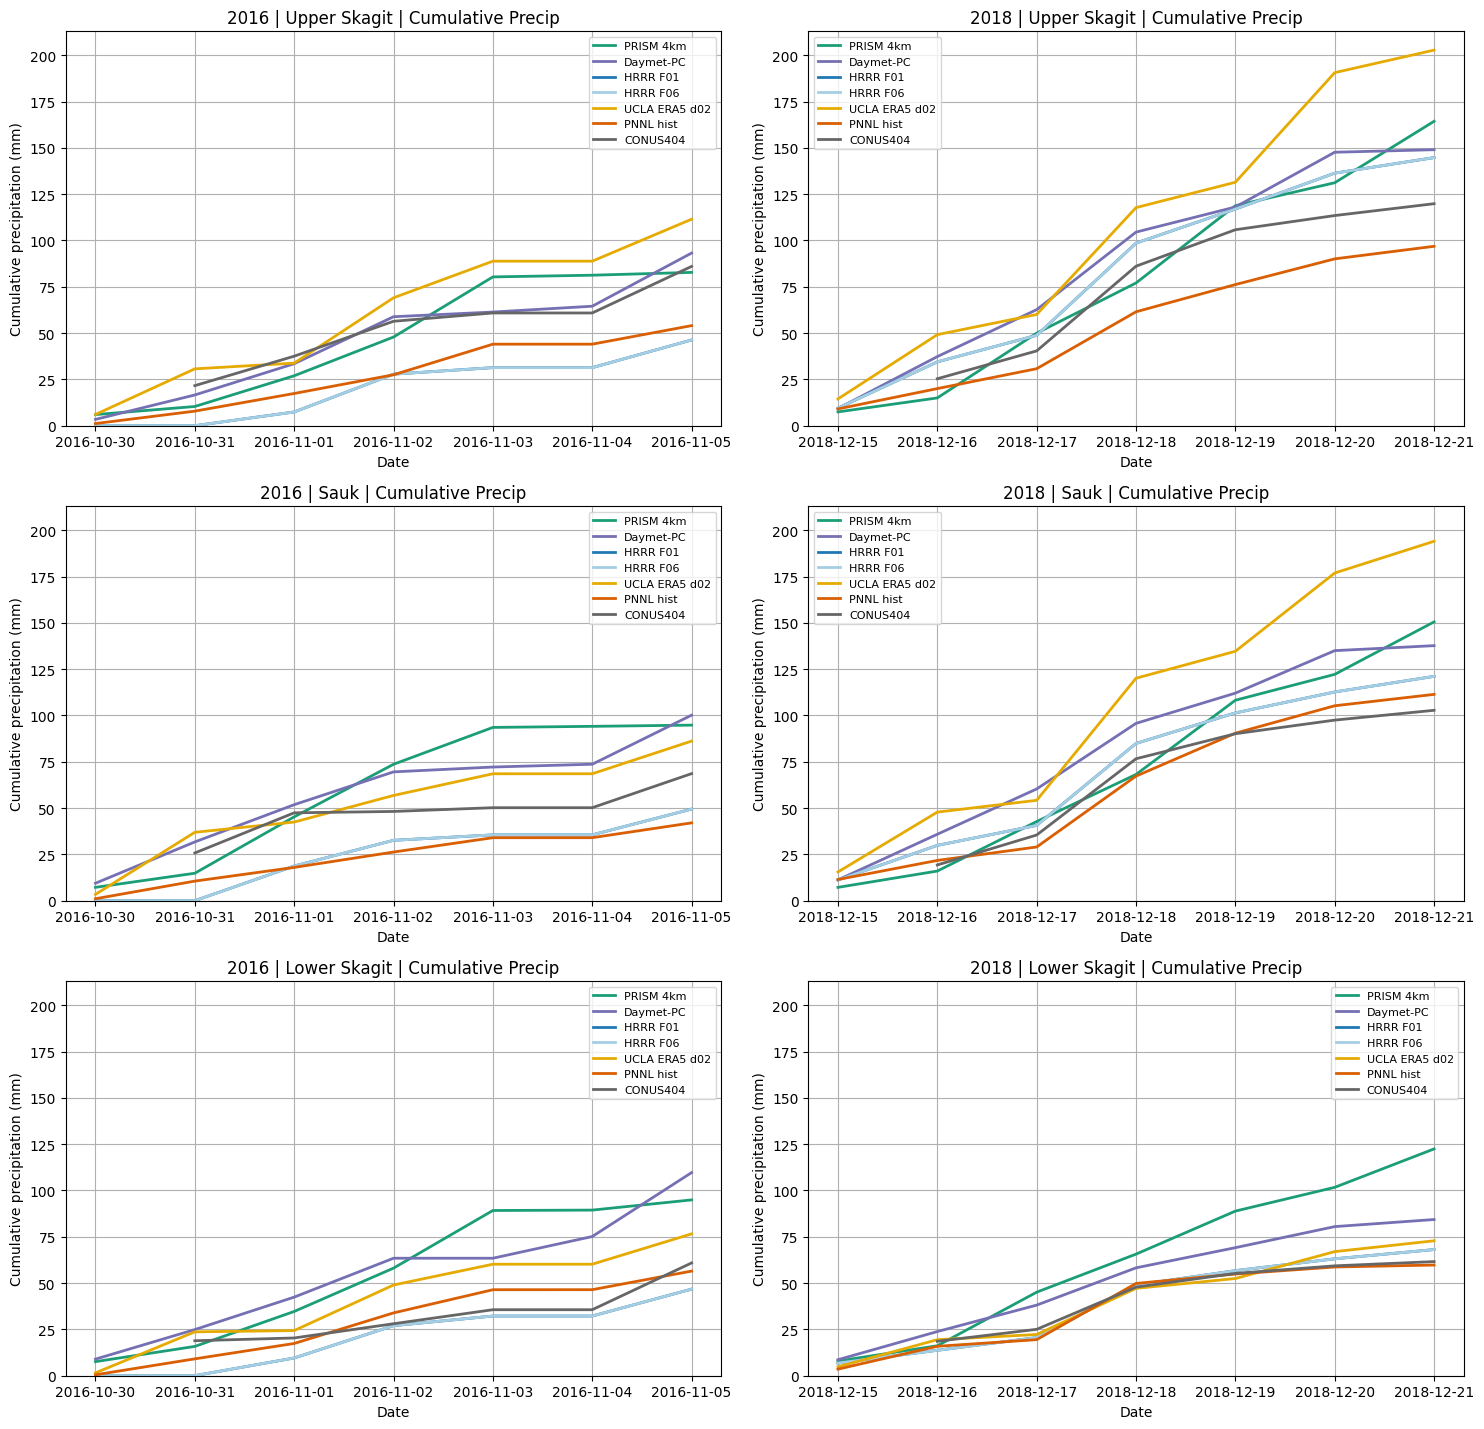


Saved MAE CSV → /data0/balaji24/data/derived/event_mae_vs_prism4km_mm_per_day__SUBBASINS.csv
    event_year       start         end        region  reference  \
0         2016  2016-10-30  2016-11-05  Lower Skagit  PRISM 4km   
1         2016  2016-10-30  2016-11-05  Lower Skagit  PRISM 4km   
2         2016  2016-10-30  2016-11-05  Lower Skagit  PRISM 4km   
3         2016  2016-10-30  2016-11-05  Lower Skagit  PRISM 4km   
4         2016  2016-10-30  2016-11-05  Lower Skagit  PRISM 4km   
5         2016  2016-10-30  2016-11-05  Lower Skagit  PRISM 4km   
6         2016  2016-10-30  2016-11-05          Sauk  PRISM 4km   
7         2016  2016-10-30  2016-11-05          Sauk  PRISM 4km   
8         2016  2016-10-30  2016-11-05          Sauk  PRISM 4km   
9         2016  2016-10-30  2016-11-05          Sauk  PRISM 4km   
10        2016  2016-10-30  2016-11-05          Sauk  PRISM 4km   
11        2016  2016-10-30  2016-11-05          Sauk  PRISM 4km   
12        2016  2016-10-30  2016-11

In [ ]:
# ============================================================
# Skagit Basin – Event CUMULATIVE Precip comparison + VERIFICATION + MAE vs PRISM 4km
# NOW WITH SUB-BASIN PLOTS (Upper Skagit / Sauk / Lower Skagit)
#
# SOURCES:
# - PRISM (local zarr)                         BASE/prism_ppt
# - Daymet v4 (Planetary Computer)             (external zarr via STAC + SAS) 
# - HRRR (monthly zarr stitched)               BASE/weather_data   NOW: HRRR F01 + HRRR F06
# - UCLA ERA5 WRF d02 (daily NetCDF)           /data0/.../ucla_era5_d02_daily/prec
# - PNNL historical WRF (hourly NetCDF)        BASE/PNNL/historical
# - CONUS404 (external OSN via HyTEST intake)  conus404-daily-osn


# Daymet: fresh SAS per event + eager .load() + close session
# Daymet: avoid "multiple values for consolidated" by removing consolidated from open_kwargs
# PNNL + CONUS404 included in plots + MAE
# sub-basin plots + MAE per sub-basin
# basin_mean_daily_from_gridded() no longer throws UnboundLocalError
# consistent colors across ALL subplots (hard-coded palette)
# same y-axis scale across ALL subplots
# ============================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
import regionmask
import intake
import shapely
import sys, time
from urllib.parse import urlsplit, urlunsplit

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/balaji24/data")

P_PRISM_DIR = BASE / "prism_ppt"
P_HRRR_DIR  = BASE / "weather_data"

# UCLA ERA5 WRF d02 daily NetCDF
UCLA_PREC_DIR      = Path("/data0/balaji24/data/ucla_era5_d02_daily/prec")
UCLA_PREC_TEMPLATE = "prec.daily.era5.d02.{year}.nc"
UCLA_COORD_FILE    = Path("/data0/balaji24/data/ucla_era5_d02_daily/static/wrfinput_d02_coord.nc")

# PNNL historical (hourly NetCDF per year) + geo grid for mask
P_PNNL_DIR = BASE / "PNNL" / "historical"
P_PNNL_GEO = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"

# Basin boundary (still used for reference / optional)
BOUNDARY_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json")

# Sub-basin polygons (HUC8)
HUC8_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitSubBasin_HUC8.geojson")
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)
MAE_CSV = OUT / "event_mae_vs_prism4km_mm_per_day__SUBBASINS.csv"

# External (CONUS404)
CONUS_INTAKE_YML = (
    "https://raw.githubusercontent.com/hytest-org/hytest/main/"
    "dataset_catalog/hytest_intake_catalog.yml"
)
CONUS_MAX_TIME = np.datetime64("2022-10-01")

# ----------------------------
# EVENTS
# ----------------------------
events = [
    {"event_year": 2016, "start": "2016-10-30", "end": "2016-11-05"},
    {"event_year": 2018, "start": "2018-12-15", "end": "2018-12-21"},
]

# ============================================================
# ONE CANONICAL COLOR PALETTE
# - Hard-coded HEX so colors never shift.
# - HRRR F01 vs HRRR F06 are different colors.
# ============================================================
DATASET_ORDER = [
    "PRISM 4km",
    "PRISM 800m",
    "Daymet-PC",
    "HRRR F01",
    "HRRR F06",
    "UCLA ERA5 d02",
    "PNNL hist",
    "CONUS404",
]

COLORS = {
    # PRISM family (greens)
    "PRISM 4km":    "#1B9E77",
    "PRISM 800m":   "#66C2A5",

    # Daymet (purple)
    "Daymet-PC":    "#7570B3",

    # HRRR family (blues) — different shades per forecast hour
    "HRRR F01":     "#1F78B4",
    "HRRR F06":     "#A6CEE3",

    # UCLA ERA5 d02 (orange)
    "UCLA ERA5 d02":"#E6AB02",

    # PNNL hist (red)
    "PNNL hist":    "#D95F02",

    # CONUS404 (gray)
    "CONUS404":     "#666666",
}

# ============================================================
# HELPERS
# ============================================================

def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def pick_var(ds, names):
    for n in names:
        if n in ds.data_vars:
            return n
    return None

def units_str(ds, var):
    return ds[var].attrs.get("units", "(missing)")

def print_units(ds, var, label):
    print(f"  - {label}: var='{var}', units='{units_str(ds, var)}'")

def load_basin_geom():
    gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    try:
        return gdf.geometry.union_all()
    except Exception:
        return gdf.geometry.unary_union

def load_subbasin_geoms():
    """
    Reads HUC8 geojson and returns dict {RegionName: shapely_geom} in EPSG:4326.
    Tries to match REGION_NAMES by name-like columns.
    """
    if not HUC8_GEO.exists():
        raise FileNotFoundError(f"Missing sub-basin geojson: {HUC8_GEO}")

    gdf = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

    # Heuristic to find the name column
    name_cols = [c for c in gdf.columns if c.lower() in ("name", "names", "huc8_name", "subbasin", "basin", "huc_name")]
    if not name_cols:
        name_cols = [c for c in gdf.columns if "name" in c.lower()]

    if not name_cols:
        raise RuntimeError(f"Could not find a name column in {HUC8_GEO}. Columns={list(gdf.columns)}")

    name_col = name_cols[0]
    geoms = {}

    gdf["_nm_"] = gdf[name_col].astype(str).str.strip()

    for target in REGION_NAMES:
        sub = gdf[gdf["_nm_"].str.lower() == target.lower()]
        if sub.empty:
            sub = gdf[gdf["_nm_"].str.lower().str.contains(target.lower(), regex=False)]
        if sub.empty:
            raise RuntimeError(f"Could not match region '{target}' in {HUC8_GEO} using column '{name_col}'")

        try:
            geom = sub.geometry.union_all()
        except Exception:
            geom = sub.geometry.unary_union
        geoms[target] = geom

    return geoms

def median_timestep_seconds(time_index):
    if len(time_index) < 2:
        return None
    dt = pd.Series(time_index).diff().dt.total_seconds().median()
    return float(dt) if pd.notnull(dt) else None

def ensure_daily_sum(da):
    """Sum to daily totals (safe for both hourly and daily)."""
    if da is None or "time" not in da.dims:
        return da
    t = pd.to_datetime(da["time"].values)
    dt = median_timestep_seconds(t)
    if dt is None:
        return da
    return da.resample(time="1D").sum()

def is_plottable_1d(da):
    if da is None:
        return False
    if da.ndim != 1 or da.size == 0:
        return False
    try:
        v = da.values
        return np.isfinite(v).any()
    except Exception:
        return False

def reset_safe_increment(acc_like_1d):
    """
    Reset-safe increments for an accumulated series (1D time):
      inc[t] = diff if diff>=0 else current_value (reset)
    Output aligns to time[1:].
    """
    d = acc_like_1d.diff("time")
    curr = acc_like_1d.isel(time=slice(1, None))
    inc = xr.where(d >= 0, d, curr)
    return inc.clip(min=0)

def accumulated_to_daily_mm(acc_like_1d, label):
    """
    Convert accumulated precip (mm) -> increments (mm/step) -> daily totals (mm/day).
    acc_like_1d MUST be 1D (time).
    """
    bm = acc_like_1d
    if bm.size < 3:
        return bm.clip(min=0).resample(time="1D").sum()

    d = bm.diff("time")
    frac_neg = float((d < 0).mean())
    mean_raw = float(bm.mean())
    mean_diff_pos = float(d.clip(min=0).mean())
    print(f"    [{label}] accum-check: frac_neg={frac_neg:.3f}, mean_raw={mean_raw:.4g}, mean_diff_pos={mean_diff_pos:.4g}")

    inc = reset_safe_increment(bm)
    daily = ensure_daily_sum(inc)
    return daily

# ============================================================
# VERIFICATION PRINTS
# ============================================================

def debug_daily(label, daily_da):
    """Print distribution stats for a DAILY (mm/day) 1D time series."""
    if daily_da is None or "time" not in daily_da.dims or daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (empty)")
        return
    daily_da = daily_da.dropna("time")
    if daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (all NaN)")
        return
    print(f"\n[{label}] DAILY CHECK")
    print("  min:", float(daily_da.min()))
    print("  max:", float(daily_da.max()))
    print("  mean:", float(daily_da.mean()))
    print("  sum:", float(daily_da.sum()))

def _median_dt_hours_from_da(da):
    if da is None or "time" not in da.dims:
        return None
    t = pd.to_datetime(da["time"].values)
    if len(t) < 2:
        return None
    dt_hours = pd.Series(t).diff().dt.total_seconds().dropna().median() / 3600.0
    return float(dt_hours) if pd.notnull(dt_hours) else None

def verify_daily_and_cumsum(label, daily_da, cum_da=None, top_n=5):
    """
    Verifies:
      - dt sanity
      - daily stats
      - sum(daily) == last(cumsum) (if cum passed)
      - top-N daily increments
    """
    if daily_da is None or daily_da.size == 0:
        print(f"\n===== VERIFY: {label} =====")
        print("  (no data)")
        return

    daily_da = daily_da.dropna("time").sortby("time")
    print(f"\n===== VERIFY: {label} =====")
    dt_hours = _median_dt_hours_from_da(daily_da)
    if dt_hours is not None:
        print(f"  median dt (hours): {dt_hours:.2f}")

    debug_daily(label, daily_da)

    if cum_da is not None and is_plottable_1d(cum_da):
        try:
            cum_last = float(cum_da.dropna("time").isel(time=-1))
            daily_sum = float(daily_da.sum())
            print("  CHECK: daily.sum vs cum[-1]:", daily_sum, cum_last, " | diff:", daily_sum - cum_last)
        except Exception as e:
            print("  CHECK: daily.sum vs cum[-1]: (failed)", repr(e))

    try:
        top = daily_da.sortby(daily_da, ascending=False).isel(time=slice(0, min(top_n, daily_da.size)))
        print(f"  TOP {min(top_n, daily_da.size)} daily values:")
        for tt, vv in zip(pd.to_datetime(top["time"].values), np.asarray(top.values)):
            print("   ", tt.date(), float(vv))
    except Exception as e:
        print("  TOP daily values: (failed)", repr(e))

# ============================================================
# MASKING UTIL (REGION MEAN ON ANY GRID WITH lon/lat)
# ============================================================

_MASK_CACHE = {}  # key -> xr.DataArray bool with spatial dims

def _geom_key(geom):
    try:
        return geom.wkb_hex
    except Exception:
        return str(geom)

def _infer_lonlat_vars(ds):
    lon_candidates = ["lon", "longitude", "XLONG", "XLONG_M", "xlong", "xlong_m"]
    lat_candidates = ["lat", "latitude", "XLAT", "XLAT_M", "xlat", "xlat_m"]

    def _get(name):
        if name in ds.coords:
            return ds.coords[name]
        if name in ds.data_vars:
            return ds.data_vars[name]
        if name in ds.variables:
            return ds[name]
        return None

    lon = None
    lat = None

    for n in lon_candidates:
        lon = _get(n)
        if lon is not None:
            break
    for n in lat_candidates:
        lat = _get(n)
        if lat is not None:
            break

    if lon is None or lat is None:
        for v in list(ds.variables):
            if lon is None and "lon" in v.lower() and getattr(ds[v], "ndim", 0) >= 1:
                lon = ds[v]
            if lat is None and "lat" in v.lower() and getattr(ds[v], "ndim", 0) >= 1:
                lat = ds[v]
            if lon is not None and lat is not None:
                break

    if lon is None or lat is None:
        return None, None

    for d in list(getattr(lon, "dims", [])):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})
    for d in list(getattr(lat, "dims", [])):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})

    return lon, lat

def _sorted_unique_time(da: xr.DataArray) -> xr.DataArray:
    if da is None or "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = pd.to_datetime(da["time"].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

# bm is always defined or we return None safely
def basin_mean_daily_from_gridded(ds, var, start, end, geom, label_for_print, assume_accumulated=False):
    if "time" not in ds.dims and "Time" in ds.dims:
        ds = ds.rename({"Time": "time"})
    if "time" not in ds[var].dims and ("Time" in ds[var].dims):
        ds = ds.rename({"Time": "time"})
    if "time" not in ds[var].dims:
        print(f"  - {label_for_print}: (no time dim on var '{var}')")
        return None

    da0 = _sorted_unique_time(ds[var])
    da = da0.sel(time=slice(start, end))
    if da.sizes.get("time", 0) == 0:
        print(f"  - {label_for_print}: (no data in window)")
        return None

    da = da.sortby("time")
    spatial = [d for d in da.dims if d != "time"]
    if len(spatial) not in (1, 2):
        print(f"  - {label_for_print}: unexpected spatial dims={spatial}")
        return None

    bm = None  # ALWAYS defined

    if len(spatial) == 1:
        bm = da.mean(dim=spatial, skipna=True)
    else:
        d0, d1 = spatial
        key = (label_for_print, _geom_key(geom), d0, d1, da.sizes[d0], da.sizes[d1])

        mask_da = _MASK_CACHE.get(key)
        if mask_da is None:
            lon, lat = _infer_lonlat_vars(ds)

            if lon is None or lat is None:
                print(f"  - {label_for_print}: could not infer lon/lat -> fallback to spatial mean")
                bm = da.mean(dim=spatial, skipna=True)
            else:
                try:
                    reg = regionmask.Regions([geom])
                    rid = reg.mask(lon, lat)
                    mask_geo = ~xr.ufuncs.isnan(rid)
                    mask_np = np.asarray(mask_geo.data).astype(bool)

                    if mask_np.shape == (da.sizes[d0], da.sizes[d1]):
                        pass
                    elif mask_np.shape == (da.sizes[d1], da.sizes[d0]):
                        mask_np = mask_np.T
                    else:
                        print(f"  - {label_for_print}: mask shape {mask_np.shape} != grid {(da.sizes[d0], da.sizes[d1])} -> fallback mean")
                        bm = da.mean(dim=spatial, skipna=True)

                    if bm is None:
                        mask_da = xr.DataArray(mask_np, dims=(d0, d1))
                        _MASK_CACHE[key] = mask_da
                except Exception as e:
                    print(f"  - {label_for_print}: mask build failed ({type(e).__name__}): {e} -> fallback mean")
                    bm = da.mean(dim=spatial, skipna=True)

        if bm is None:
            mask_da = _MASK_CACHE.get(key)
            if mask_da is None:
                bm = da.mean(dim=spatial, skipna=True)
            else:
                bm = da.where(mask_da).mean(dim=(d0, d1), skipna=True)

    units = str(da.attrs.get("units", "")).lower().strip()
    if units in {"m", "meter", "meters", "metre", "metres"}:
        bm = bm * 1000.0

    if assume_accumulated:
        bm_daily = accumulated_to_daily_mm(bm, label=f"{label_for_print} accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    return bm_daily.sortby("time")

# ============================================================
# PRISM
# ============================================================

_PRISM_NAME_RE = re.compile(
    r"(?P<s>\d{4}-\d{2}-\d{2})_(?P<e>\d{4}-\d{2}-\d{2})_daily_(?P<tag>4km|800m)_PRISM_data\.zarr$"
)

def find_prism_zarr_covering(start, end, tag):
    start = pd.Timestamp(start)
    end   = pd.Timestamp(end)

    candidates = []
    for p in P_PRISM_DIR.glob(f"*_daily_{tag}_PRISM_data.zarr"):
        m = _PRISM_NAME_RE.search(p.name)
        if not m:
            continue
        f0 = pd.Timestamp(m.group("s"))
        f1 = pd.Timestamp(m.group("e"))
        if f0 <= start and f1 >= end:
            span_days = (f1 - f0).days
            candidates.append((span_days, f0, p))

    if not candidates:
        return None

    candidates.sort(key=lambda t: (t[0], -t[1].value))
    return candidates[0][2]

def load_prism_daily(start, end, tag, geom, region_label, do_verify=True):
    z = find_prism_zarr_covering(start, end, tag)
    if z is None:
        print(f"  - PRISM {tag}: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["ppt", "precip", "prcp"])
    if var is None:
        print(f"  - PRISM {tag} [{z.name}]: (no precip var found)")
        ds.close()
        return None

    print_units(ds, var, f"PRISM {tag} [{z.name}]")
    bm_daily = basin_mean_daily_from_gridded(
        ds, var, start, end, geom,
        label_for_print=f"PRISM {tag} | {region_label}",
        assume_accumulated=False
    )

    if bm_daily is not None and do_verify:
        verify_daily_and_cumsum(f"PRISM {tag} | {region_label}", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

# ============================================================
# Daymet (Planetary Computer) — FIXED consolidated conflict + eager load
# ============================================================

def ensure_daymet_pkgs():
    needed = ["pystac-client", "planetary-computer", "pyproj", "fsspec", "zarr"]
    import importlib, subprocess
    missing = []
    for p in needed:
        mod = p.replace("-", "_")
        try:
            importlib.import_module(mod)
        except Exception:
            missing.append(p)
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

ensure_daymet_pkgs()

from pystac_client import Client
import planetary_computer as pc
from pyproj import CRS, Transformer
from fsspec.implementations.http import HTTPFileSystem
from shapely.ops import transform as shp_transform

class SASEndAppendingHTTPFileSystem(HTTPFileSystem):
    def __init__(self, sas_query: str, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._sas_query = sas_query.lstrip("?")

    def _with_sas(self, url: str) -> str:
        return url if "?" in url else f"{url}?{self._sas_query}"

    def _open(self, path, mode="rb", block_size=None, **kwargs):
        return super()._open(self._with_sas(path), mode=mode, block_size=block_size, **kwargs)

    async def _cat_file(self, url, start=None, end=None, **kwargs):
        return await super()._cat_file(self._with_sas(url), start=start, end=end, **kwargs)

def daymet_lcc_crs():
    return CRS.from_proj4(
        "+proj=lcc +lat_1=25 +lat_2=60 +lat_0=42.5 +lon_0=-100 "
        "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )

_DAYMET_TFM_LL_TO_XY = Transformer.from_crs("EPSG:4326", daymet_lcc_crs(), always_xy=True)

def get_daymet_mapper_and_fs():
    stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
    col = stac.get_collection("daymet-daily-na")
    asset_key = "zarr-https" if "zarr-https" in col.assets else "zarr-abfs"
    signed_href = pc.sign(col.assets[asset_key].href)

    parts = urlsplit(signed_href)
    root_no_query = urlunsplit((parts.scheme, parts.netloc, parts.path, "", ""))
    sas_query = parts.query

    fs = SASEndAppendingHTTPFileSystem(sas_query)
    mapper = fs.get_mapper(root_no_query)

    open_kwargs = col.assets[asset_key].extra_fields.get("xarray:open_kwargs", {})
    return mapper, fs, open_kwargs

def lonlat_to_daymet_xy_bounds(geom_wgs84, pad_m=5000.0):
    minx, miny, maxx, maxy = geom_wgs84.bounds
    corners = [(minx, miny), (minx, maxy), (maxx, miny), (maxx, maxy)]
    xs, ys = zip(*[_DAYMET_TFM_LL_TO_XY.transform(lon, lat) for lon, lat in corners])
    return (float(min(xs) - pad_m), float(max(xs) + pad_m),
            float(min(ys) - pad_m), float(max(ys) + pad_m))

def _daymet_project_geom_to_xy(geom_ll):
    def _proj(x, y, z=None):
        return _DAYMET_TFM_LL_TO_XY.transform(x, y)
    return shp_transform(_proj, geom_ll)

_DAYMET_MASK_CACHE = {}

def load_daymet_pc_daily(start, end, geom_ll, region_label, do_verify=True):
    for attempt in range(1, 4):
        ds = None
        fs = None
        try:
            mapper, fs, open_kwargs = get_daymet_mapper_and_fs()

            open_kwargs = dict(open_kwargs)
            open_kwargs.pop("consolidated", None)

            ds = xr.open_zarr(mapper, **open_kwargs)

            if "prcp" not in ds:
                raise RuntimeError("Daymet dataset missing 'prcp'")

            print_units(ds, "prcp", "Daymet-PC (Daymet v4)")
            prcp = ds["prcp"]

            units = str(prcp.attrs.get("units", "")).lower().strip()
            if units in {"m", "meter", "meters", "metre", "metres"}:
                prcp = prcp * 1000.0
                prcp.attrs["units"] = "mm"

            xmin, xmax, ymin, ymax = lonlat_to_daymet_xy_bounds(geom_ll, pad_m=5000.0)

            y0 = float(ds["y"].values[0])
            y1 = float(ds["y"].values[-1])
            y_slice = slice(ymax, ymin) if y0 > y1 else slice(ymin, ymax)

            pr = prcp.sel(time=slice(start, end), x=slice(xmin, xmax), y=y_slice).chunk({"time": -1, "y": 256, "x": 256})
            if pr.sizes.get("time", 0) == 0:
                print("  - Daymet-PC: (no data in window)")
                return None

            pr = _sorted_unique_time(pr).sortby("time")

            key = (
                region_label,
                _geom_key(geom_ll),
                float(pr["x"].values[0]), float(pr["x"].values[-1]),
                float(pr["y"].values[0]), float(pr["y"].values[-1]),
                int(pr.sizes["x"]), int(pr.sizes["y"]),
            )

            mask = _DAYMET_MASK_CACHE.get(key)
            if mask is None:
                xx, yy = xr.broadcast(pr["x"], pr["y"])
                geom_xy = _daymet_project_geom_to_xy(geom_ll)
                from shapely import contains_xy
                mask_np = contains_xy(geom_xy, np.asarray(xx.values), np.asarray(yy.values))
                mask = xr.DataArray(mask_np, dims=xx.dims, coords=xx.coords)
                _DAYMET_MASK_CACHE[key] = mask

            bm_daily = pr.where(mask).mean(dim=("y", "x"), skipna=True)
            bm_daily = ensure_daily_sum(bm_daily).sortby("time")

            bm_daily = bm_daily.load()

            if do_verify:
                verify_daily_and_cumsum(f"Daymet-PC | {region_label}", bm_daily, bm_daily.cumsum("time"))

            return bm_daily

        except Exception as e:
            print(f"[DAYMET-PC] attempt {attempt}/3 failed ({type(e).__name__}): {e}")
            time.sleep(5 * attempt)
        finally:
            if ds is not None:
                try: ds.close()
                except Exception: pass
            if fs is not None:
                try: fs.close_session()
                except Exception: pass

    print("  - Daymet-PC: (failed after retries)")
    return None

# ============================================================
# HRRR (monthly stitched) — NOW supports selecting F01 or F06
# ============================================================

def hrrr_hourly_precip_mm(ds, var="tp"):
    da = ds[var]
    probe = da.isel({k: 0 for k in da.dims if k not in ("time", "step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9

    if not is_cum:
        return da

    da = da.sortby("time")
    dif = da.diff("time", label="upper")
    dif = xr.where(dif < 0, 0, dif)
    dif = dif.fillna(0)
    dif = xr.concat([da.isel(time=slice(0, 1)) * 0, dif], dim="time")
    return dif

def _pick_hrrr_step_value(step_da: xr.DataArray, fh_hours: int):
    """
    Return a step coordinate value matching fh_hours.
    Handles step stored as timedelta64 or numeric hours.
    """
    if np.issubdtype(step_da.dtype, np.timedelta64):
        target = np.timedelta64(fh_hours, "h")
        diffs = np.abs(step_da.values - target)
        idx = int(np.argmin(diffs))
        return step_da.values[idx]

    try:
        vals = step_da.values.astype(float)
        idx = int(np.argmin(np.abs(vals - float(fh_hours))))
        return step_da.values[idx]
    except Exception:
        return step_da.values[0]

def hrrr_select_forecast_hour(da: xr.DataArray, fh_hours: int) -> xr.DataArray:
    """
    Select HRRR forecast hour from a DataArray if a forecast/step dimension exists.
    Supports dims: 'step' (most common), or 'forecast_hour'.
    """
    if "step" in da.dims:
        sv = _pick_hrrr_step_value(da["step"], fh_hours)
        out = da.sel(step=sv)
        out.attrs.update(da.attrs)
        return out

    if "forecast_hour" in da.dims:
        vals = da["forecast_hour"].values.astype(float)
        idx = int(np.argmin(np.abs(vals - float(fh_hours))))
        out = da.isel(forecast_hour=idx)
        out.attrs.update(da.attrs)
        return out

    return da

def load_hrrr_daily(start, end, geom, region_label, do_verify=True, fh_hours=1):
    """
    HRRR stitched monthly zarr -> select forecast hour (F01 or F06),
    then convert to daily totals and region-mean.
    """
    if not P_HRRR_DIR.exists():
        print("  - HRRR: (dir missing)")
        return None

    monthly = sorted([p for p in P_HRRR_DIR.glob("*.zarr") if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)])
    if not monthly:
        print("  - HRRR: (no monthly zarrs found)")
        return None

    start_ts = pd.Timestamp(start)
    end_ts   = pd.Timestamp(end)
    need = pd.period_range(start_ts.to_period("M"), end_ts.to_period("M"), freq="M")
    need_prefixes = {f"{p.year}-{p.month:02d}" for p in need}

    available = {p.name[:7] for p in monthly}
    missing = sorted(list(need_prefixes - available))
    if missing:
        print(f"  - HRRR: missing months {missing} -> skipping HRRR for this event")
        return None

    parts = sorted([p for p in monthly if p.name[:7] in need_prefixes], key=lambda p: p.name[:7])

    ds0 = safe_open_zarr(parts[0])
    var = "tp" if "tp" in ds0 else ("apcp" if "apcp" in ds0 else None)
    if not var:
        print(f"  - HRRR: no tp/apcp in {parts[0].name} -> skipping")
        try: ds0.close()
        except Exception: pass
        return None

    dsets = []
    ok = True
    for p in parts:
        dsm = safe_open_zarr(p)
        if var not in dsm:
            print(f"  - HRRR: {p.name} missing {var} -> skipping")
            try: dsm.close()
            except Exception: pass
            ok = False
            break
        dsets.append(dsm[[var]])

    if not ok:
        for d in dsets:
            try: d.close()
            except Exception: pass
        try: ds0.close()
        except Exception: pass
        return None

    ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override").sortby("time")
    print_units(ds, var, f"HRRR (stitched monthly zarr) | F{fh_hours:02d}")

    # Select forecast hour if possible
    da = hrrr_select_forecast_hour(ds[var], fh_hours=fh_hours)

    # Convert to hourly increments if series looks accumulated
    hourly_mm = hrrr_hourly_precip_mm(xr.Dataset({var: da}), var=var)

    # Daily totals
    daily = hourly_mm.resample(time="1D").sum()

    ds_daily = xr.Dataset({var: daily})
    for c in ["lon", "lat", "longitude", "latitude", "XLONG", "XLAT", "XLONG_M", "XLAT_M"]:
        if c in ds0:
            ds_daily[c] = ds0[c]

    bm_daily = basin_mean_daily_from_gridded(
        ds_daily, var, start, end, geom,
        label_for_print=f"HRRR F{fh_hours:02d} | {region_label}",
        assume_accumulated=False
    )

    if bm_daily is not None and do_verify:
        verify_daily_and_cumsum(f"HRRR F{fh_hours:02d} | {region_label}", bm_daily, bm_daily.cumsum("time"))

    for d in dsets:
        try: d.close()
        except Exception: pass
    try: ds0.close()
    except Exception: pass

    return bm_daily

# ============================================================
# UCLA ERA5 d02 (daily NetCDF) — per-region mask cache
# ============================================================

def ucla_file_label_for_date(dt: pd.Timestamp) -> int:
    return dt.year if dt.month >= 9 else (dt.year - 1)

def open_ucla_prec_for_window(t0: str, t1: str):
    t0_ts = pd.Timestamp(t0)
    t1_ts = pd.Timestamp(t1)
    labels_needed = sorted({ucla_file_label_for_date(t0_ts), ucla_file_label_for_date(t1_ts)})

    files = []
    for lab in labels_needed:
        f = UCLA_PREC_DIR / UCLA_PREC_TEMPLATE.format(year=lab)
        if f.exists():
            files.append(str(f))

    if not files:
        return None, []

    dsets = []
    pr_list = []
    for f in files:
        ds = xr.open_dataset(f, engine="netcdf4", decode_cf=True, mask_and_scale=True)
        if "prec" not in ds:
            ds.close()
            continue
        pr = ds["prec"]
        if "time" not in pr.dims:
            tdim = "day" if "day" in pr.dims else None
            if tdim is None:
                for d in pr.dims:
                    if "time" in d.lower() or "day" in d.lower():
                        tdim = d
                        break
            if tdim is not None and tdim != "time":
                pr = pr.rename({tdim: "time"})
        pr_list.append(pr)
        dsets.append(ds)

    if not pr_list:
        return None, []

    pr_all = xr.concat(pr_list, dim="time", join="outer", coords="minimal", compat="override")
    pr_all = pr_all.sortby("time")
    try:
        tt = pd.to_datetime(pr_all["time"].values)
        _, idx = np.unique(tt, return_index=True)
        pr_all = pr_all.isel(time=np.sort(idx))
    except Exception:
        pass

    pr_all = pr_all.sel(time=slice(t0, t1))
    if pr_all.sizes.get("time", 0) == 0:
        for ds in dsets:
            try: ds.close()
            except Exception: pass
        return None, []

    return pr_all, dsets

_UCLA_MASKS = {}  # region_label -> mask2d

def build_ucla_basin_mask(coord_file: Path, geom):
    g = xr.open_dataset(coord_file, engine="netcdf4")
    lat = g["lat2d"].squeeze(drop=True).astype("float64")
    lon = g["lon2d"].squeeze(drop=True).astype("float64")
    g.close()

    lonv = lon.values.ravel()
    latv = lat.values.ravel()
    ny, nx = lon.shape

    try:
        from shapely import contains_xy
        m_flat = contains_xy(geom, lonv, latv)
    except Exception:
        import shapely as _sh
        from shapely.prepared import prep
        pg = prep(geom)
        m_flat = np.array([pg.contains(_sh.Point(x, y)) for x, y in zip(lonv, latv)], dtype=bool)

    mask2d = m_flat.reshape(ny, nx).astype(bool)
    return xr.DataArray(mask2d, dims=lon.dims, coords=lon.coords)

def load_ucla_era5_d02_daily(start, end, geom, region_label, do_verify=True):
    if not UCLA_PREC_DIR.exists() or not UCLA_COORD_FILE.exists():
        print("  - UCLA ERA5 d02: (missing dir or coord file)")
        return None

    pr, parents = open_ucla_prec_for_window(start, end)
    if pr is None:
        print("  - UCLA ERA5 d02: (no files / no data in window)")
        return None

    try:
        print(f"  - UCLA ERA5 d02: var='prec', units='{pr.attrs.get('units', '(missing)')}'")

        units = str(pr.attrs.get("units", "")).lower().strip()
        if units in {"m", "meter", "meters", "metre", "metres"}:
            pr = pr * 1000.0
            pr.attrs["units"] = "mm"

        if region_label not in _UCLA_MASKS:
            _UCLA_MASKS[region_label] = build_ucla_basin_mask(UCLA_COORD_FILE, geom)
            m2d = _UCLA_MASKS[region_label]
            print(f"    [UCLA | {region_label}] mask cells inside: {int(m2d.sum())} / {m2d.size}")

        spatial = [d for d in pr.dims if d != "time"]
        if len(spatial) != 2:
            print(f"  - UCLA ERA5 d02: unexpected spatial dims={spatial}")
            return None

        mask = _UCLA_MASKS[region_label]
        if set(mask.dims) != set(spatial):
            rename_map = {}
            for md in mask.dims:
                for pdim in spatial:
                    if mask.sizes[md] == pr.sizes[pdim]:
                        rename_map[md] = pdim
                        break
            mask = mask.rename(rename_map)

        bm = pr.where(mask).mean(dim=spatial, skipna=True)
        bm_daily = ensure_daily_sum(bm).sortby("time")
        if do_verify:
            verify_daily_and_cumsum(f"UCLA ERA5 d02 | {region_label}", bm_daily, bm_daily.cumsum("time"))
        return bm_daily

    finally:
        for ds in parents:
            try: ds.close()
            except Exception: pass

# ============================================================
# PNNL hist (hourly accum → daily) — per-region mask cache
# ============================================================

_PNNL_MASKS = {}  # (region_label, grid_key) -> mask

def build_pnnl_mask_for_ds(ds_prec, geom):
    spatial = [d for d in ds_prec["PREC_ACC_NC"].dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"[PNNL] Unexpected spatial dims: {spatial}")

    d0, d1 = spatial[0], spatial[1]
    s0, s1 = ds_prec.sizes[d0], ds_prec.sizes[d1]

    geo = xr.open_dataset(P_PNNL_GEO)

    lat_name = next((c for c in ["XLAT_M", "XLAT", "lat", "LAT"] if c in geo), None)
    lon_name = next((c for c in ["XLONG_M", "XLONG", "lon", "LON"] if c in geo), None)
    if lat_name is None or lon_name is None:
        geo.close()
        raise RuntimeError(f"[PNNL geo] Could not find lat/lon vars. vars={list(geo.data_vars)[:60]}")

    lat = geo[lat_name]
    lon = geo[lon_name]

    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})
    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask_geo = ~xr.ufuncs.isnan(m)
    mask_np = np.asarray(mask_geo.data).astype(bool)
    geo.close()

    if mask_np.shape == (s0, s1):
        pass
    elif mask_np.shape == (s1, s0):
        mask_np = mask_np.T
    else:
        raise RuntimeError(
            f"[PNNL] Mask shape {mask_np.shape} does not match precip grid ({d0},{d1})={(s0,s1)}"
        )

    return xr.DataArray(mask_np, dims=(d0, d1))

def load_pnnl_daily(year, start, end, geom, region_label, do_verify=True):
    f1 = P_PNNL_DIR / str(year) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc"
    if f1.exists():
        f = f1
    else:
        cands = sorted((P_PNNL_DIR / str(year)).glob("*PREC_ACC_NC*.nc"))
        f = cands[0] if cands else None

    if f is None or not f.exists():
        print("  - PNNL hist: (not available)")
        return None

    ds = xr.open_dataset(f, chunks={"time": 24})
    if "PREC_ACC_NC" not in ds:
        print("  - PNNL hist: (PREC_ACC_NC missing)")
        ds.close()
        return None

    print_units(ds, "PREC_ACC_NC", f"PNNL hist [{f.name}]")

    spatial = [d for d in ds["PREC_ACC_NC"].dims if d != "time"]
    grid_key = (tuple(spatial), ds.sizes[spatial[0]], ds.sizes[spatial[1]])
    key = (region_label, grid_key)

    if key not in _PNNL_MASKS:
        _PNNL_MASKS[key] = build_pnnl_mask_for_ds(ds, geom)

    mask = _PNNL_MASKS[key]

    start_dt = pd.Timestamp(start)
    start_minus_1 = str(start_dt - pd.Timedelta(days=1))
    da = ds["PREC_ACC_NC"].sel(time=slice(start_minus_1, end)).sortby("time")
    bm_acc = da.where(mask).mean(dim=spatial, skipna=True)

    bm_daily = accumulated_to_daily_mm(bm_acc, label=f"PNNL hist | {region_label}").sortby("time")
    bm_daily = bm_daily.sel(time=slice(start, end))
    if do_verify:
        verify_daily_and_cumsum(f"PNNL hist | {region_label}", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

# ============================================================
# CONUS404 (external)
# ============================================================

_conus_ds = None
_conus_mask_cache = {}  # region_label -> mask

def get_conus():
    global _conus_ds
    if _conus_ds is None:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        _conus_ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    return _conus_ds

def load_conus_daily(start, end, geom, region_label, do_verify=True):
    global _conus_mask_cache

    if np.datetime64(end) > CONUS_MAX_TIME:
        print("  - CONUS404: skipped (out of range)")
        return None

    ds = get_conus()
    var = pick_var(ds, ["PREC_ACC_NC", "prcp", "precip", "precipitation", "PREC", "PRECIP", "RAIN", "RAINNC", "RAINC"])
    if var is None:
        print("  - CONUS404: (no precip var found)")
        return None

    print_units(ds, var, "CONUS404")

    if region_label not in _conus_mask_cache:
        lon = ds["lon"]
        lat = ds["lat"]
        mask_np = shapely.contains_xy(geom, lon.values, lat.values)
        _conus_mask_cache[region_label] = xr.DataArray(mask_np, dims=("y", "x"))

    mask = _conus_mask_cache[region_label]

    start_dt = pd.Timestamp(start)
    start_minus_1 = str(start_dt - pd.Timedelta(days=1))
    da = ds[var].sel(time=slice(start_minus_1, end)).sortby("time")
    bm = da.where(mask).mean(dim=("y", "x"), skipna=True)

    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = ("accum" in var.lower()) or ("accumul" in desc) or (var.upper() in ("RAINNC", "RAINC", "PREC_ACC_NC"))
    if looks_accum:
        bm_daily = accumulated_to_daily_mm(bm, label=f"CONUS404 accum | {region_label}")
        bm_daily = bm_daily.sel(time=slice(start, end))
    else:
        bm_daily = ensure_daily_sum(bm).sel(time=slice(start, end))

    bm_daily = bm_daily.sortby("time")
    if do_verify:
        verify_daily_and_cumsum(f"CONUS404 | {region_label}", bm_daily, bm_daily.cumsum("time"))
    return bm_daily

# ============================================================
# MAE util
# ============================================================

def mae_vs_reference_mm_per_day(ref_daily, other_daily):
    if ref_daily is None or other_daily is None:
        return np.nan, 0
    if ("time" not in ref_daily.dims) or ("time" not in other_daily.dims):
        return np.nan, 0

    a = ref_daily.dropna("time").sortby("time")
    b = other_daily.dropna("time").sortby("time")

    a2, b2 = xr.align(a, b, join="inner")
    if a2.size == 0 or b2.size == 0:
        return np.nan, 0

    diff = np.abs(a2 - b2)
    mae = float(diff.mean().values)
    n = int(diff.sizes.get("time", diff.size))
    return mae, n

# ============================================================
# MAIN (SUB-BASIN PLOTS)
# ============================================================

def main():
    sub_geoms = load_subbasin_geoms()

    n_events = len(events)
    n_regions = len(REGION_NAMES)

    fig, axs = plt.subplots(
        n_regions, n_events,
        figsize=(7.5 * n_events, 4.8 * n_regions),
        squeeze=False
    )

    mae_rows = []
    global_ymax = 0.0  # to force same y-scale across every subplot

    for c, ev in enumerate(events):
        yr = int(ev["event_year"])
        start = ev["start"]
        end = ev["end"]

        print(f"\n================ EVENT {yr} ({start} → {end}) ================")

        for r, region in enumerate(REGION_NAMES):
            geom = sub_geoms[region]
            ax = axs[r, c]

            print(f"\n----- Region: {region} -----")

            ref_daily = load_prism_daily(start, end, "4km", geom, region, do_verify=True)

            daily_series = [
                ("PRISM 4km",       ref_daily),
                ("PRISM 800m",      load_prism_daily(start, end, "800m", geom, region, do_verify=True)),
                ("Daymet-PC",       load_daymet_pc_daily(start, end, geom, region, do_verify=True)),
                ("HRRR F01",        load_hrrr_daily(start, end, geom, region, do_verify=True, fh_hours=1)),
                ("HRRR F06",        load_hrrr_daily(start, end, geom, region, do_verify=True, fh_hours=6)),
                ("UCLA ERA5 d02",   load_ucla_era5_d02_daily(start, end, geom, region, do_verify=True)),
                ("PNNL hist",       load_pnnl_daily(yr, start, end, geom, region, do_verify=True)),
                ("CONUS404",        load_conus_daily(start, end, geom, region, do_verify=True)),
            ]

            plotted_any = False
            for label, dly in daily_series:
                if is_plottable_1d(dly):
                    cum = dly.cumsum("time")
                    x = pd.to_datetime(cum["time"].values)
                    y = np.asarray(cum.values)

                    ax.plot(
                        x, y,
                        label=label,
                        color=COLORS.get(label, "#000000"),  # fallback black (shouldn't happen if labels match)
                        linewidth=2.0
                    )

                    if np.isfinite(y).any():
                        global_ymax = max(global_ymax, float(np.nanmax(y)))

                    plotted_any = True

            title_suffix = " (2-Week)" if is_2week else ""
            ax.set_title(f"{yr} | {region} | Cumulative Precip{title_suffix}")
            ax.set_xlabel("Date")
            ax.set_ylabel("Cumulative precipitation (mm)")
            ax.grid(True)
            if plotted_any:
                ax.legend(fontsize=8)

            for label, dly in daily_series:
                if label == "PRISM 4km":
                    continue
                mae, n_days = mae_vs_reference_mm_per_day(ref_daily, dly)
                if n_days > 0 and np.isfinite(mae):
                    mae_rows.append({
                        "event_year": yr,
                        "start": start,
                        "end": end,
                        "region": region,
                        "reference": "PRISM 4km",
                        "dataset": label,
                        "mae_mm_per_day": mae,
                        "n_days": n_days,
                    })

    # --- force identical y-scale on every subplot ---
    if global_ymax > 0 and np.isfinite(global_ymax):
        ymax = global_ymax * 1.05  # small padding
        for ax in axs.ravel():
            ax.set_ylim(0, ymax)

    plt.tight_layout()
    plt.show()

    mae_df = pd.DataFrame(mae_rows).sort_values(["event_year", "region", "dataset"]).reset_index(drop=True)
    mae_csv_path = MAE_CSV
    if is_2week:
        mae_csv_path = MAE_CSV.parent / MAE_CSV.name.replace(".csv", "_2week.csv")
    mae_df.to_csv(mae_csv_path, index=False)
    print(f"\nSaved MAE CSV → {mae_csv_path}")
    print("\nSaved MAE CSV →", MAE_CSV)
    print(mae_df)

if __name__ == "__main__":
    main()

# Final code for AR Events


================ EVENT 2003 (2003-10-14 → 2003-10-19) ================

----- Region: Upper Skagit -----
  - PRISM 4km [2003-10-14_2003-10-19_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km | Upper Skagit =====
  median dt (hours): 24.00

[PRISM 4km | Upper Skagit] DAILY CHECK
  min: 0.46448037028312683
  max: 119.59271240234375
  mean: 37.49338912963867
  sum: 224.96034240722656
  CHECK: daily.sum vs cum[-1]: 224.96034240722656 224.9603271484375  | diff: 1.52587890625e-05
  TOP 5 daily values:
    2003-10-17 119.59271240234375
    2003-10-16 48.63895034790039
    2003-10-18 36.88969802856445
    2003-10-19 12.973715782165527
    2003-10-15 6.400787353515625
  - PRISM 800m [2003-10-14_2003-10-19_daily_800m_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 800m | Upper Skagit =====
  median dt (hours): 24.00

[PRISM 800m | Upper Skagit] DAILY CHECK
  min: 0.43626126646995544
  max: 118.59156036376953
  mean: 37.1938591003418
  sum: 22

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x76c11c403350>


  sum: 104.5002212524414
  CHECK: daily.sum vs cum[-1]: 104.5002212524414 104.5002212524414  | diff: 0.0
  TOP 5 daily values:
    2003-10-16 70.0527114868164
    2003-10-19 15.401825904846191
    2003-10-17 12.597190856933594
    2003-10-15 6.43625545501709
    2003-10-18 0.0122382752597332

----- Region: Sauk -----
  - PRISM 4km [2003-10-14_2003-10-19_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km | Sauk =====
  median dt (hours): 24.00

[PRISM 4km | Sauk] DAILY CHECK
  min: 2.7860076427459717
  max: 96.96304321289062
  mean: 28.98569679260254
  sum: 173.9141845703125
  CHECK: daily.sum vs cum[-1]: 173.9141845703125 173.91416931152344  | diff: 1.52587890625e-05
  TOP 5 daily values:
    2003-10-17 96.96304321289062
    2003-10-16 38.65763854980469
    2003-10-18 22.036598205566406
    2003-10-19 9.64842414855957
    2003-10-15 3.8224620819091797
  - PRISM 800m [2003-10-14_2003-10-19_daily_800m_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VE

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x76c13c43ef60>


  CHECK: daily.sum vs cum[-1]: 146.78350830078125 146.78350830078125  | diff: 0.0
  TOP 5 daily values:
    2003-10-17 68.29590606689453
    2003-10-16 61.829532623291016
    2003-10-19 9.234770774841309
    2003-10-15 7.423303604125977
    2003-10-18 0.0

----- Region: Lower Skagit -----
  - PRISM 4km [2003-10-14_2003-10-19_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km | Lower Skagit =====
  median dt (hours): 24.00

[PRISM 4km | Lower Skagit] DAILY CHECK
  min: 0.13130304217338562
  max: 89.90966796875
  mean: 30.93752098083496
  sum: 185.6251220703125
  CHECK: daily.sum vs cum[-1]: 185.6251220703125 185.62510681152344  | diff: 1.52587890625e-05
  TOP 5 daily values:
    2003-10-17 89.90966796875
    2003-10-16 41.994136810302734
    2003-10-18 40.195030212402344
    2003-10-19 9.67481803894043
    2003-10-15 3.720151424407959
  - PRISM 800m [2003-10-14_2003-10-19_daily_800m_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 800m |

...

Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed

  TOP 3 daily values:
    2006-11-06 149.1930694580078
    2006-11-07 42.58312225341797
    2006-11-05 17.529878616333008

----- Region: Lower Skagit -----
  - PRISM 4km [2006-11-02_2006-11-11_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km | Lower Skagit =====
  median dt (hours): 24.00

[PRISM 4km | Lower Skagit] DAILY CHECK
  min: 43.24712371826172
  max: 78.06825256347656
  mean: 55.22783279418945
  sum: 220.9113311767578
  CHECK: daily.sum vs cum[-1]: 220.9113311767578 220.9113311767578  | diff: 0.0
  TOP 4 daily values:
    2006-11-07 78.06825256347656
    2006-11-05 50.93531799316406
    2006-11-04 48.66063690185547
    2006-11-06 43.24712371826172
  - PRISM 800m [2006-11-02_2006-11-11_daily_800m_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 800m | Lower Skagit =====
  median dt (hours): 24.00

[PRISM 800m | Lower Skagit] DAILY CHECK
  min: 43.22872543334961
  max: 77.65524291992188
  mean: 54.779518127441406
  sum: 219.118

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x76c1b1a4ee40>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x76c11c2542f0>, 986060.347028836), (<aiohttp.client_proto.ResponseHandler object at 0x76c11c255850>, 986060.350781313), (<aiohttp.client_proto.ResponseHandler object at 0x76c11c257b90>, 986060.351539112), (<aiohttp.client_proto.ResponseHandler object at 0x76c11c256ff0>, 986060.354293877), (<aiohttp.client_proto.ResponseHandler object at 0x76c11c254e30>, 986060.354873354), (<aiohttp.client_proto.ResponseHandler object at 0x76c11c255310>, 986060.355902047), (<aiohttp.client_proto.ResponseHandler object at 0x76c11c254950>, 986060.358829663), (<aiohttp.client_proto.ResponseHandler object at 0x76c0fc172db0>, 986060.363227758), (<aiohttp.client_proto.ResponseHandler object at 0x76c1a8727710>, 986060.36342845), (<aiohttp.client_proto.ResponseHandler object at 0x76c19c75aab0>, 986075.896296188)])']
connector: 

  min: 10.721684455871582
  max: 54.70431137084961
  mean: 27.395803451538086
  sum: 82.18740844726562
  CHECK: daily.sum vs cum[-1]: 82.18740844726562 82.18740844726562  | diff: 0.0
  TOP 3 daily values:
    2006-11-06 54.70431137084961
    2006-11-07 16.761409759521484
    2006-11-05 10.721684455871582


Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed

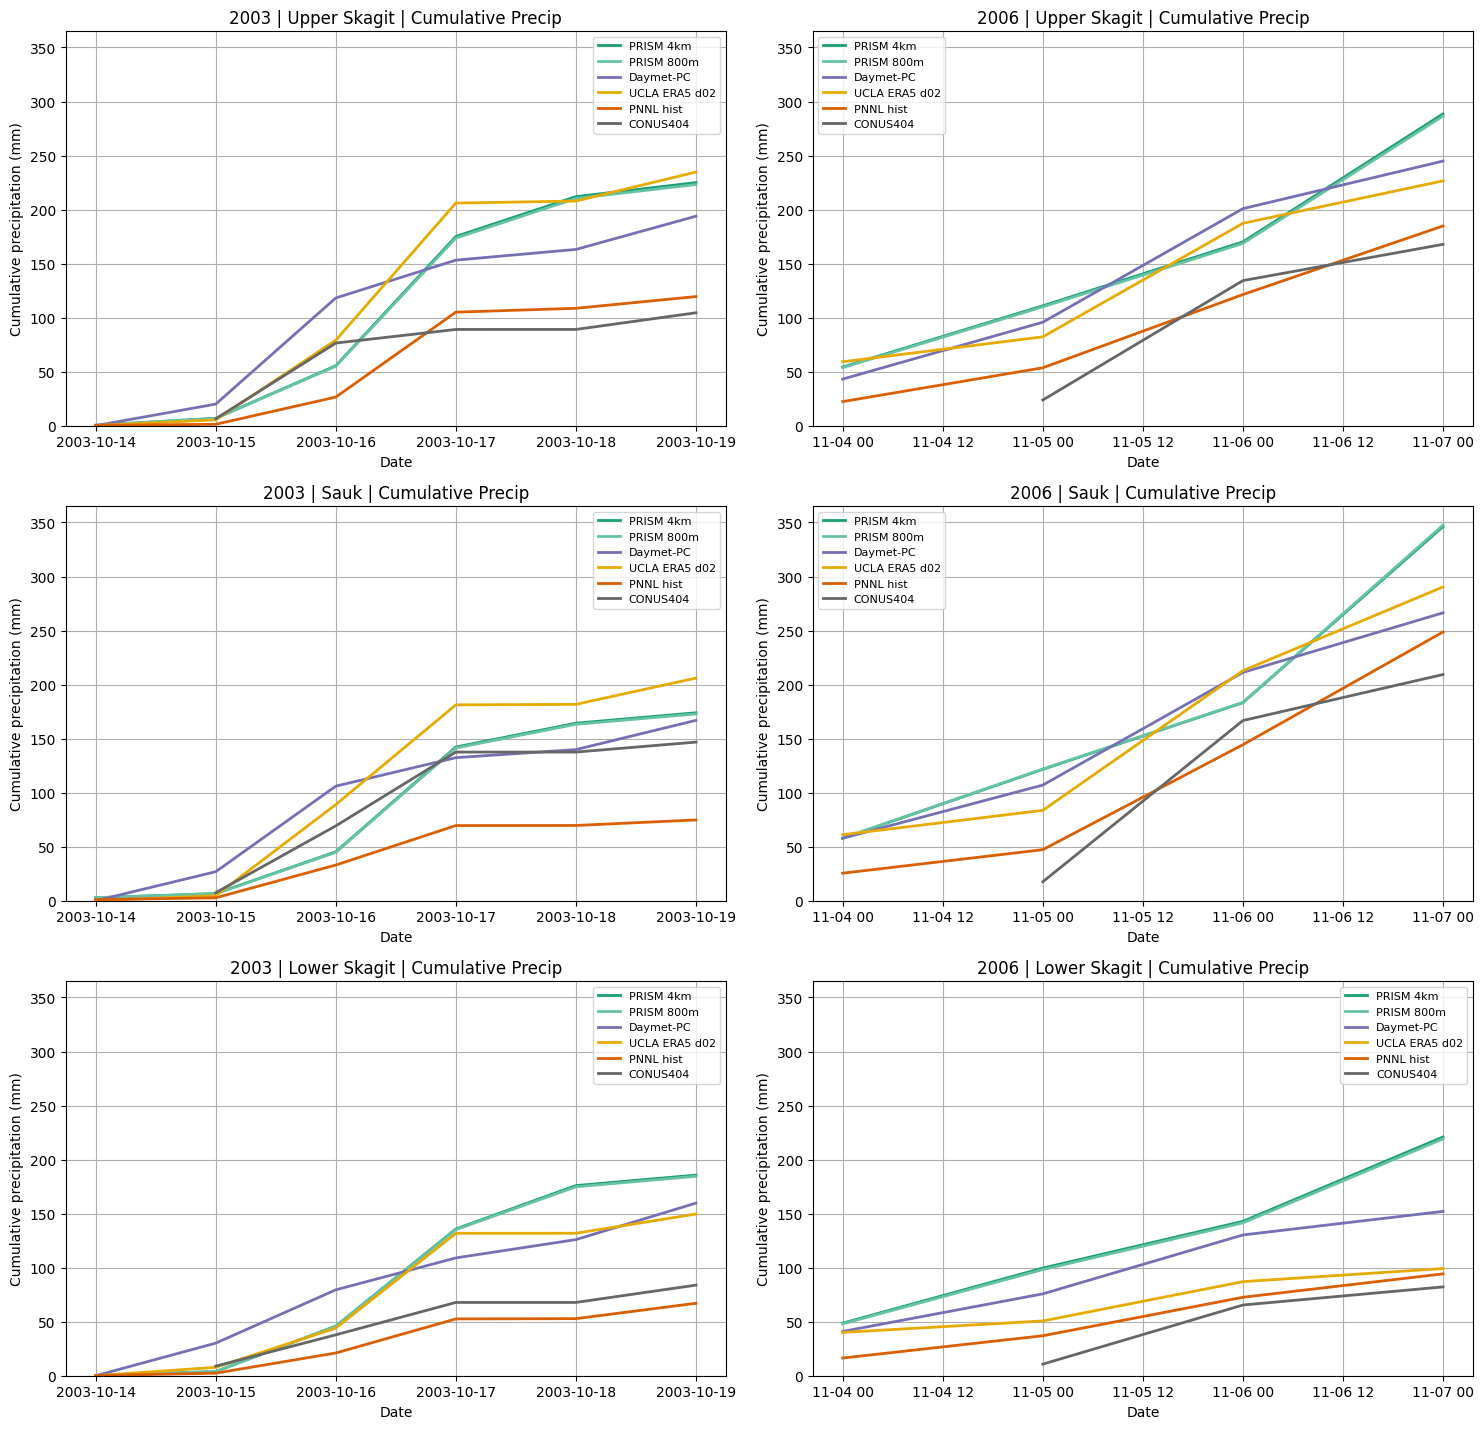


Saved MAE CSV → /data0/balaji24/data/derived/event_mae_vs_prism4km_mm_per_day__SUBBASINS.csv
    event_year       start         end        region  reference  \
0         2003  2003-10-14  2003-10-19  Lower Skagit  PRISM 4km   
1         2003  2003-10-14  2003-10-19  Lower Skagit  PRISM 4km   
2         2003  2003-10-14  2003-10-19  Lower Skagit  PRISM 4km   
3         2003  2003-10-14  2003-10-19  Lower Skagit  PRISM 4km   
4         2003  2003-10-14  2003-10-19  Lower Skagit  PRISM 4km   
5         2003  2003-10-14  2003-10-19          Sauk  PRISM 4km   
6         2003  2003-10-14  2003-10-19          Sauk  PRISM 4km   
7         2003  2003-10-14  2003-10-19          Sauk  PRISM 4km   
8         2003  2003-10-14  2003-10-19          Sauk  PRISM 4km   
9         2003  2003-10-14  2003-10-19          Sauk  PRISM 4km   
10        2003  2003-10-14  2003-10-19  Upper Skagit  PRISM 4km   
11        2003  2003-10-14  2003-10-19  Upper Skagit  PRISM 4km   
12        2003  2003-10-14  2003-10

In [ ]:
# ============================================================
# Skagit Basin – Event CUMULATIVE Precip comparison + VERIFICATION + MAE vs PRISM 4km
# NOW WITH SUB-BASIN PLOTS (Upper Skagit / Sauk / Lower Skagit)
#
# SOURCES:
# - PRISM (local zarr)                         BASE/prism_ppt
# - Daymet v4 (Planetary Computer)             (external zarr via STAC + SAS) 
# - HRRR (monthly zarr stitched)               BASE/weather_data
# - UCLA ERA5 WRF d02 (daily NetCDF)           /data0/.../ucla_era5_d02_daily/prec
# - PNNL historical WRF (hourly NetCDF)        BASE/PNNL/historical
# - CONUS404 (external OSN via HyTEST intake)  conus404-daily-osn


# Daymet: fresh SAS per event + eager .load() + close session
# Daymet: avoid "multiple values for consolidated" by removing consolidated from open_kwargs
# PNNL + CONUS404 included in plots + MAE
# sub-basin plots + MAE per sub-basin
# basin_mean_daily_from_gridded() no longer throws UnboundLocalError
# consistent dataset colors across ALL graphs/scripts
# if a new dataset key appears, auto-assign a totally different unused color
# SAME Y-SCALE across ALL subplots within the SAME image (global ylim)
# ============================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
import regionmask
import intake
import shapely
import sys, time
from urllib.parse import urlsplit, urlunsplit

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/balaji24/data")

P_PRISM_DIR = BASE / "prism_nc"
P_HRRR_DIR  = BASE / "weather_data"

# UCLA ERA5 WRF d02 daily NetCDF
UCLA_PREC_DIR      = Path("/data0/balaji24/data/ucla_era5_d02_daily/prec")
UCLA_PREC_TEMPLATE = "prec.daily.era5.d02.{year}.nc"
UCLA_COORD_FILE    = Path("/data0/balaji24/data/ucla_era5_d02_daily/static/wrfinput_d02_coord.nc")

# PNNL historical (hourly NetCDF per year) + geo grid for mask
P_PNNL_DIR = BASE / "PNNL" / "historical"
P_PNNL_GEO = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"

# Basin boundary (still used for reference / optional)
BOUNDARY_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json")

# Sub-basin polygons (HUC8)
HUC8_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitSubBasin_HUC8.geojson")
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)
MAE_CSV = OUT / "event_mae_vs_prism4km_mm_per_day__SUBBASINS.csv"

# External (CONUS404)
CONUS_INTAKE_YML = (
    "https://raw.githubusercontent.com/hytest-org/hytest/main/"
    "dataset_catalog/hytest_intake_catalog.yml"
)
CONUS_MAX_TIME = np.datetime64("2022-10-01")

# ----------------------------
# EVENTS
# ----------------------------
events = [
    {"event_year": 2003, "start": "2003-10-14", "end": "2003-10-19"},
    {"event_year": 2006, "start": "2006-11-04", "end": "2006-11-07"},
]

# ============================================================
# GLOBAL CONSISTENT COLORS (fixed + auto-assign for new datasets)
# ============================================================

def _distinct_color_pool():
    """
    Big pool of distinct colors (deterministic order).
    Pulls from multiple qualitative colormaps so any new dataset gets a unique color.
    """
    pools = []
    for cm in ["tab20", "tab20b", "tab20c", "Dark2", "Set2", "Set3", "Paired", "Accent"]:
        cmap = plt.get_cmap(cm)
        pools.extend([cmap(i) for i in range(cmap.N)])

    # de-dup
    uniq = []
    seen = set()
    for c in pools:
        key = tuple(np.round(np.array(c), 6))
        if key not in seen:
            uniq.append(c)
            seen.add(key)
    return uniq

_COLOR_POOL = _distinct_color_pool()

def dataset_color_map():
    """
    Stable pinned colors for known datasets.
    (These must NEVER change across scripts.)
    """
    fixed_hex = {
        "PRISM 4km":     "#1B9E77",  # black
        "PRISM 800m":    "#66C2A5",  # gray
        "Daymet-PC":     "#7570B3",  # green
        "HRRR F01":      "#1F78B4",  # orange
        "HRRR F06":      "#A6CEE3",  # reserved light-orange
        "UCLA ERA5 d02": "#E6AB02",  # purple
        "PNNL hist":     "#D95F02",  # blue
        "CONUS404":      "#666666",  # red
    }
    return {k: plt.matplotlib.colors.to_rgba(v) for k, v in fixed_hex.items()}

def make_color_getter(initial_map: dict):
    """
    Returns (get_color, color_map).
    get_color(key): fixed if known, else assigns next unused distinct color.
    """
    color_map = dict(initial_map)

    used = set(tuple(np.round(np.array(c), 6)) for c in color_map.values())
    pool_idx = 0

    def get_color(dataset_key: str):
        nonlocal pool_idx
        if dataset_key in color_map:
            return color_map[dataset_key]

        while pool_idx < len(_COLOR_POOL):
            c = _COLOR_POOL[pool_idx]
            pool_idx += 1
            key = tuple(np.round(np.array(c), 6))
            if key not in used:
                used.add(key)
                color_map[dataset_key] = c
                print(f"[COLOR] New dataset key '{dataset_key}' assigned color {c}")
                return c

        # fallback (should never happen)
        color_map[dataset_key] = (0.0, 0.0, 0.0, 1.0)
        print(f"[COLOR] WARNING: ran out of colors; '{dataset_key}' set to black")
        return color_map[dataset_key]

    return get_color, color_map

# ============================================================
# HELPERS
# ============================================================

def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def pick_var(ds, names):
    for n in names:
        if n in ds.data_vars:
            return n
    return None

def units_str(ds, var):
    return ds[var].attrs.get("units", "(missing)")

def print_units(ds, var, label):
    print(f"  - {label}: var='{var}', units='{units_str(ds, var)}'")

def load_basin_geom():
    gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    try:
        return gdf.geometry.union_all()
    except Exception:
        return gdf.geometry.unary_union

def load_subbasin_geoms():
    """
    Reads HUC8 geojson and returns dict {RegionName: shapely_geom} in EPSG:4326.
    Tries to match REGION_NAMES by name-like columns.
    """
    if not HUC8_GEO.exists():
        raise FileNotFoundError(f"Missing sub-basin geojson: {HUC8_GEO}")

    gdf = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

    name_cols = [c for c in gdf.columns if c.lower() in ("name", "names", "huc8_name", "subbasin", "basin", "huc_name")]
    if not name_cols:
        name_cols = [c for c in gdf.columns if "name" in c.lower()]
    if not name_cols:
        raise RuntimeError(f"Could not find a name column in {HUC8_GEO}. Columns={list(gdf.columns)}")

    name_col = name_cols[0]
    geoms = {}
    gdf["_nm_"] = gdf[name_col].astype(str).str.strip()

    for target in REGION_NAMES:
        sub = gdf[gdf["_nm_"].str.lower() == target.lower()]
        if sub.empty:
            sub = gdf[gdf["_nm_"].str.lower().str.contains(target.lower(), regex=False)]
        if sub.empty:
            raise RuntimeError(f"Could not match region '{target}' in {HUC8_GEO} using column '{name_col}'")

        try:
            geom = sub.geometry.union_all()
        except Exception:
            geom = sub.geometry.unary_union
        geoms[target] = geom

    return geoms

def median_timestep_seconds(time_index):
    if len(time_index) < 2:
        return None
    dt = pd.Series(time_index).diff().dt.total_seconds().median()
    return float(dt) if pd.notnull(dt) else None

def ensure_daily_sum(da):
    """Sum to daily totals (safe for both hourly and daily)."""
    if da is None or "time" not in da.dims:
        return da
    t = pd.to_datetime(da["time"].values)
    dt = median_timestep_seconds(t)
    if dt is None:
        return da
    return da.resample(time="1D").sum()

def is_plottable_1d(da):
    if da is None:
        return False
    if da.ndim != 1 or da.size == 0:
        return False
    try:
        v = da.values
        return np.isfinite(v).any()
    except Exception:
        return False

def reset_safe_increment(acc_like_1d):
    d = acc_like_1d.diff("time")
    curr = acc_like_1d.isel(time=slice(1, None))
    inc = xr.where(d >= 0, d, curr)
    return inc.clip(min=0)

def accumulated_to_daily_mm(acc_like_1d, label):
    bm = acc_like_1d
    if bm.size < 3:
        return bm.clip(min=0).resample(time="1D").sum()

    d = bm.diff("time")
    frac_neg = float((d < 0).mean())
    mean_raw = float(bm.mean())
    mean_diff_pos = float(d.clip(min=0).mean())
    print(f"    [{label}] accum-check: frac_neg={frac_neg:.3f}, mean_raw={mean_raw:.4g}, mean_diff_pos={mean_diff_pos:.4g}")

    inc = reset_safe_increment(bm)
    daily = ensure_daily_sum(inc)
    return daily

# ============================================================
# VERIFICATION PRINTS
# ============================================================

def debug_daily(label, daily_da):
    if daily_da is None or "time" not in daily_da.dims or daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (empty)")
        return
    daily_da = daily_da.dropna("time")
    if daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (all NaN)")
        return
    print(f"\n[{label}] DAILY CHECK")
    print("  min:", float(daily_da.min()))
    print("  max:", float(daily_da.max()))
    print("  mean:", float(daily_da.mean()))
    print("  sum:", float(daily_da.sum()))

def _median_dt_hours_from_da(da):
    if da is None or "time" not in da.dims:
        return None
    t = pd.to_datetime(da["time"].values)
    if len(t) < 2:
        return None
    dt_hours = pd.Series(t).diff().dt.total_seconds().dropna().median() / 3600.0
    return float(dt_hours) if pd.notnull(dt_hours) else None

def verify_daily_and_cumsum(label, daily_da, cum_da=None, top_n=5):
    if daily_da is None or daily_da.size == 0:
        print(f"\n===== VERIFY: {label} =====")
        print("  (no data)")
        return

    daily_da = daily_da.dropna("time").sortby("time")
    print(f"\n===== VERIFY: {label} =====")
    dt_hours = _median_dt_hours_from_da(daily_da)
    if dt_hours is not None:
        print(f"  median dt (hours): {dt_hours:.2f}")

    debug_daily(label, daily_da)

    if cum_da is not None and is_plottable_1d(cum_da):
        try:
            cum_last = float(cum_da.dropna("time").isel(time=-1))
            daily_sum = float(daily_da.sum())
            print("  CHECK: daily.sum vs cum[-1]:", daily_sum, cum_last, " | diff:", daily_sum - cum_last)
        except Exception as e:
            print("  CHECK: daily.sum vs cum[-1]: (failed)", repr(e))

    try:
        top = daily_da.sortby(daily_da, ascending=False).isel(time=slice(0, min(top_n, daily_da.size)))
        print(f"  TOP {min(top_n, daily_da.size)} daily values:")
        for tt, vv in zip(pd.to_datetime(top["time"].values), np.asarray(top.values)):
            print("   ", tt.date(), float(vv))
    except Exception as e:
        print("  TOP daily values: (failed)", repr(e))

# ============================================================
# MASKING UTIL (REGION MEAN ON ANY GRID WITH lon/lat)
# ============================================================

_MASK_CACHE = {}

def _geom_key(geom):
    try:
        return geom.wkb_hex
    except Exception:
        return str(geom)

def _infer_lonlat_vars(ds):
    lon_candidates = ["lon", "longitude", "XLONG", "XLONG_M", "xlong", "xlong_m"]
    lat_candidates = ["lat", "latitude", "XLAT", "XLAT_M", "xlat", "xlat_m"]

    def _get(name):
        if name in ds.coords:
            return ds.coords[name]
        if name in ds.data_vars:
            return ds.data_vars[name]
        if name in ds.variables:
            return ds[name]
        return None

    lon = None
    lat = None

    for n in lon_candidates:
        lon = _get(n)
        if lon is not None:
            break
    for n in lat_candidates:
        lat = _get(n)
        if lat is not None:
            break

    if lon is None or lat is None:
        for v in list(ds.variables):
            if lon is None and "lon" in v.lower() and getattr(ds[v], "ndim", 0) >= 1:
                lon = ds[v]
            if lat is None and "lat" in v.lower() and getattr(ds[v], "ndim", 0) >= 1:
                lat = ds[v]
            if lon is not None and lat is not None:
                break

    if lon is None or lat is None:
        return None, None

    for d in list(getattr(lon, "dims", [])):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})
    for d in list(getattr(lat, "dims", [])):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})

    return lon, lat

def _sorted_unique_time(da: xr.DataArray) -> xr.DataArray:
    if da is None or "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = pd.to_datetime(da["time"].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def basin_mean_daily_from_gridded(ds, var, start, end, geom, label_for_print, assume_accumulated=False):
    if "time" not in ds.dims and "Time" in ds.dims:
        ds = ds.rename({"Time": "time"})
    if "time" not in ds[var].dims and ("Time" in ds[var].dims):
        ds = ds.rename({"Time": "time"})
    if "time" not in ds[var].dims:
        print(f"  - {label_for_print}: (no time dim on var '{var}')")
        return None

    da0 = _sorted_unique_time(ds[var])
    da = da0.sel(time=slice(start, end))
    if da.sizes.get("time", 0) == 0:
        print(f"  - {label_for_print}: (no data in window)")
        return None

    da = da.sortby("time")
    spatial = [d for d in da.dims if d != "time"]
    if len(spatial) not in (1, 2):
        print(f"  - {label_for_print}: unexpected spatial dims={spatial}")
        return None

    bm = None

    if len(spatial) == 1:
        bm = da.mean(dim=spatial, skipna=True)
    else:
        d0, d1 = spatial
        key = (label_for_print, _geom_key(geom), d0, d1, da.sizes[d0], da.sizes[d1])

        mask_da = _MASK_CACHE.get(key)
        if mask_da is None:
            lon, lat = _infer_lonlat_vars(ds)

            if lon is None or lat is None:
                print(f"  - {label_for_print}: could not infer lon/lat -> fallback to spatial mean")
                bm = da.mean(dim=spatial, skipna=True)
            else:
                try:
                    reg = regionmask.Regions([geom])
                    rid = reg.mask(lon, lat)
                    mask_geo = ~xr.ufuncs.isnan(rid)
                    mask_np = np.asarray(mask_geo.data).astype(bool)

                    if mask_np.shape == (da.sizes[d0], da.sizes[d1]):
                        pass
                    elif mask_np.shape == (da.sizes[d1], da.sizes[d0]):
                        mask_np = mask_np.T
                    else:
                        print(f"  - {label_for_print}: mask shape {mask_np.shape} != grid {(da.sizes[d0], da.sizes[d1])} -> fallback mean")
                        bm = da.mean(dim=spatial, skipna=True)

                    if bm is None:
                        mask_da = xr.DataArray(mask_np, dims=(d0, d1))
                        _MASK_CACHE[key] = mask_da
                except Exception as e:
                    print(f"  - {label_for_print}: mask build failed ({type(e).__name__}): {e} -> fallback mean")
                    bm = da.mean(dim=spatial, skipna=True)

        if bm is None:
            mask_da = _MASK_CACHE.get(key)
            if mask_da is None:
                bm = da.mean(dim=spatial, skipna=True)
            else:
                bm = da.where(mask_da).mean(dim=(d0, d1), skipna=True)

    units = str(da.attrs.get("units", "")).lower().strip()
    if units in {"m", "meter", "meters", "metre", "metres"}:
        bm = bm * 1000.0

    if assume_accumulated:
        bm_daily = accumulated_to_daily_mm(bm, label=f"{label_for_print} accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    return bm_daily.sortby("time")

# ============================================================
# PRISM
# ============================================================

_PRISM_NAME_RE = re.compile(
    r"(?P<s>\d{4}-\d{2}-\d{2})_(?P<e>\d{4}-\d{2}-\d{2})_daily_(?P<tag>4km|800m)_PRISM_data\.zarr$"
)

def find_prism_zarr_covering(start, end, tag):
    start = pd.Timestamp(start)
    end   = pd.Timestamp(end)

    candidates = []
    for p in P_PRISM_DIR.glob(f"*_daily_{tag}_PRISM_data.zarr"):
        m = _PRISM_NAME_RE.search(p.name)
        if not m:
            continue
        f0 = pd.Timestamp(m.group("s"))
        f1 = pd.Timestamp(m.group("e"))
        if f0 <= start and f1 >= end:
            span_days = (f1 - f0).days
            candidates.append((span_days, f0, p))

    if not candidates:
        return None

    candidates.sort(key=lambda t: (t[0], -t[1].value))
    return candidates[0][2]

def load_prism_daily(start, end, tag, geom, region_label, do_verify=True):
    z = find_prism_zarr_covering(start, end, tag)
    if z is None:
        print(f"  - PRISM {tag}: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["ppt", "precip", "prcp"])
    if var is None:
        print(f"  - PRISM {tag} [{z.name}]: (no precip var found)")
        ds.close()
        return None

    print_units(ds, var, f"PRISM {tag} [{z.name}]")
    bm_daily = basin_mean_daily_from_gridded(
        ds, var, start, end, geom,
        label_for_print=f"PRISM {tag} | {region_label}",
        assume_accumulated=False
    )

    if bm_daily is not None and do_verify:
        verify_daily_and_cumsum(f"PRISM {tag} | {region_label}", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

# ============================================================
# Daymet (Planetary Computer) — consolidated conflict + eager load
# ============================================================

def ensure_daymet_pkgs():
    needed = ["pystac-client", "planetary-computer", "pyproj", "fsspec", "zarr"]
    import importlib, subprocess
    missing = []
    for p in needed:
        mod = p.replace("-", "_")
        try:
            importlib.import_module(mod)
        except Exception:
            missing.append(p)
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

ensure_daymet_pkgs()

from pystac_client import Client
import planetary_computer as pc
from pyproj import CRS, Transformer
from fsspec.implementations.http import HTTPFileSystem
from shapely.ops import transform as shp_transform

class SASEndAppendingHTTPFileSystem(HTTPFileSystem):
    def __init__(self, sas_query: str, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._sas_query = sas_query.lstrip("?")

    def _with_sas(self, url: str) -> str:
        return url if "?" in url else f"{url}?{self._sas_query}"

    def _open(self, path, mode="rb", block_size=None, **kwargs):
        return super()._open(self._with_sas(path), mode=mode, block_size=block_size, **kwargs)

    async def _cat_file(self, url, start=None, end=None, **kwargs):
        return await super()._cat_file(self._with_sas(url), start=start, end=end, **kwargs)

def daymet_lcc_crs():
    return CRS.from_proj4(
        "+proj=lcc +lat_1=25 +lat_2=60 +lat_0=42.5 +lon_0=-100 "
        "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )

_DAYMET_TFM_LL_TO_XY = Transformer.from_crs("EPSG:4326", daymet_lcc_crs(), always_xy=True)

def get_daymet_mapper_and_fs():
    stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
    col = stac.get_collection("daymet-daily-na")
    asset_key = "zarr-https" if "zarr-https" in col.assets else "zarr-abfs"
    signed_href = pc.sign(col.assets[asset_key].href)

    parts = urlsplit(signed_href)
    root_no_query = urlunsplit((parts.scheme, parts.netloc, parts.path, "", ""))
    sas_query = parts.query

    fs = SASEndAppendingHTTPFileSystem(sas_query)
    mapper = fs.get_mapper(root_no_query)

    open_kwargs = col.assets[asset_key].extra_fields.get("xarray:open_kwargs", {})
    return mapper, fs, open_kwargs

def lonlat_to_daymet_xy_bounds(geom_wgs84, pad_m=5000.0):
    minx, miny, maxx, maxy = geom_wgs84.bounds
    corners = [(minx, miny), (minx, maxy), (maxx, miny), (maxx, maxy)]
    xs, ys = zip(*[_DAYMET_TFM_LL_TO_XY.transform(lon, lat) for lon, lat in corners])
    return (float(min(xs) - pad_m), float(max(xs) + pad_m),
            float(min(ys) - pad_m), float(max(ys) + pad_m))

def _daymet_project_geom_to_xy(geom_ll):
    def _proj(x, y, z=None):
        return _DAYMET_TFM_LL_TO_XY.transform(x, y)
    return shp_transform(_proj, geom_ll)

_DAYMET_MASK_CACHE = {}

def load_daymet_pc_daily(start, end, geom_ll, region_label, do_verify=True):
    for attempt in range(1, 4):
        ds = None
        fs = None
        try:
            mapper, fs, open_kwargs = get_daymet_mapper_and_fs()

            open_kwargs = dict(open_kwargs)
            open_kwargs.pop("consolidated", None)  # avoid multiple values for consolidated

            ds = xr.open_zarr(mapper, **open_kwargs)

            if "prcp" not in ds:
                raise RuntimeError("Daymet dataset missing 'prcp'")

            print_units(ds, "prcp", "Daymet-PC (Daymet v4)")
            prcp = ds["prcp"]

            units = str(prcp.attrs.get("units", "")).lower().strip()
            if units in {"m", "meter", "meters", "metre", "metres"}:
                prcp = prcp * 1000.0
                prcp.attrs["units"] = "mm"

            xmin, xmax, ymin, ymax = lonlat_to_daymet_xy_bounds(geom_ll, pad_m=5000.0)

            y0 = float(ds["y"].values[0])
            y1 = float(ds["y"].values[-1])
            y_slice = slice(ymax, ymin) if y0 > y1 else slice(ymin, ymax)

            pr = prcp.sel(time=slice(start, end), x=slice(xmin, xmax), y=y_slice).chunk({"time": -1, "y": 256, "x": 256})
            if pr.sizes.get("time", 0) == 0:
                print("  - Daymet-PC: (no data in window)")
                return None

            pr = _sorted_unique_time(pr).sortby("time")

            key = (
                region_label,
                _geom_key(geom_ll),
                float(pr["x"].values[0]), float(pr["x"].values[-1]),
                float(pr["y"].values[0]), float(pr["y"].values[-1]),
                int(pr.sizes["x"]), int(pr.sizes["y"]),
            )

            mask = _DAYMET_MASK_CACHE.get(key)
            if mask is None:
                xx, yy = xr.broadcast(pr["x"], pr["y"])
                geom_xy = _daymet_project_geom_to_xy(geom_ll)
                from shapely import contains_xy
                mask_np = contains_xy(geom_xy, np.asarray(xx.values), np.asarray(yy.values))
                mask = xr.DataArray(mask_np, dims=xx.dims, coords=xx.coords)
                _DAYMET_MASK_CACHE[key] = mask

            bm_daily = pr.where(mask).mean(dim=("y", "x"), skipna=True)
            bm_daily = ensure_daily_sum(bm_daily).sortby("time")

            bm_daily = bm_daily.load()  # eager load to avoid session issues

            if do_verify:
                verify_daily_and_cumsum(f"Daymet-PC | {region_label}", bm_daily, bm_daily.cumsum("time"))

            return bm_daily

        except Exception as e:
            print(f"[DAYMET-PC] attempt {attempt}/3 failed ({type(e).__name__}): {e}")
            time.sleep(5 * attempt)
        finally:
            if ds is not None:
                try: ds.close()
                except Exception: pass
            if fs is not None:
                try: fs.close_session()
                except Exception: pass

    print("  - Daymet-PC: (failed after retries)")
    return None

# ============================================================
# HRRR (monthly stitched)
# ============================================================

def hrrr_hourly_precip_mm(ds, var="tp"):
    da = ds[var]
    probe = da.isel({k: 0 for k in da.dims if k not in ("time", "step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9

    if not is_cum:
        return da

    da = da.sortby("time")
    dif = da.diff("time", label="upper")
    dif = xr.where(dif < 0, 0, dif)
    dif = dif.fillna(0)
    dif = xr.concat([da.isel(time=slice(0, 1)) * 0, dif], dim="time")
    return dif

def load_hrrr_daily(start, end, geom, region_label, do_verify=True):
    if not P_HRRR_DIR.exists():
        print("  - HRRR: (dir missing)")
        return None

    monthly = sorted([p for p in P_HRRR_DIR.glob("*.zarr") if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)])
    if not monthly:
        print("  - HRRR: (no monthly zarrs found)")
        return None

    start_ts = pd.Timestamp(start)
    end_ts   = pd.Timestamp(end)
    need = pd.period_range(start_ts.to_period("M"), end_ts.to_period("M"), freq="M")
    need_prefixes = {f"{p.year}-{p.month:02d}" for p in need}

    available = {p.name[:7] for p in monthly}
    missing = sorted(list(need_prefixes - available))
    if missing:
        print(f"  - HRRR: missing months {missing} -> skipping HRRR for this event")
        return None

    parts = sorted([p for p in monthly if p.name[:7] in need_prefixes], key=lambda p: p.name[:7])

    ds0 = safe_open_zarr(parts[0])
    var = "tp" if "tp" in ds0 else ("apcp" if "apcp" in ds0 else None)
    if not var:
        print(f"  - HRRR: no tp/apcp in {parts[0].name} -> skipping")
        try: ds0.close()
        except Exception: pass
        return None

    dsets = []
    ok = True
    for p in parts:
        dsm = safe_open_zarr(p)
        if var not in dsm:
            print(f"  - HRRR: {p.name} missing {var} -> skipping")
            try: dsm.close()
            except Exception: pass
            ok = False
            break
        dsets.append(dsm[[var]])

    if not ok:
        for d in dsets:
            try: d.close()
            except Exception: pass
        try: ds0.close()
        except Exception: pass
        return None

    ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override").sortby("time")
    print_units(ds, var, "HRRR (stitched monthly zarr)")

    hourly_mm = hrrr_hourly_precip_mm(ds, var=var)
    daily = hourly_mm.resample(time="1D").sum()

    ds_daily = xr.Dataset({var: daily})
    for c in ["lon", "lat", "longitude", "latitude", "XLONG", "XLAT", "XLONG_M", "XLAT_M"]:
        if c in ds0:
            ds_daily[c] = ds0[c]

    bm_daily = basin_mean_daily_from_gridded(
        ds_daily, var, start, end, geom,
        label_for_print=f"HRRR | {region_label}",
        assume_accumulated=False
    )
    if bm_daily is not None and do_verify:
        verify_daily_and_cumsum(f"HRRR | {region_label}", bm_daily, bm_daily.cumsum("time"))

    for d in dsets:
        try: d.close()
        except Exception: pass
    try: ds0.close()
    except Exception: pass

    return bm_daily

# ============================================================
# UCLA ERA5 d02 (daily NetCDF) — per-region mask cache
# ============================================================

def ucla_file_label_for_date(dt: pd.Timestamp) -> int:
    return dt.year if dt.month >= 9 else (dt.year - 1)

def open_ucla_prec_for_window(t0: str, t1: str):
    t0_ts = pd.Timestamp(t0)
    t1_ts = pd.Timestamp(t1)
    labels_needed = sorted({ucla_file_label_for_date(t0_ts), ucla_file_label_for_date(t1_ts)})

    files = []
    for lab in labels_needed:
        f = UCLA_PREC_DIR / UCLA_PREC_TEMPLATE.format(year=lab)
        if f.exists():
            files.append(str(f))

    if not files:
        return None, []

    dsets = []
    pr_list = []
    for f in files:
        ds = xr.open_dataset(f, engine="netcdf4", decode_cf=True, mask_and_scale=True)
        if "prec" not in ds:
            ds.close()
            continue
        pr = ds["prec"]
        if "time" not in pr.dims:
            tdim = "day" if "day" in pr.dims else None
            if tdim is None:
                for d in pr.dims:
                    if "time" in d.lower() or "day" in d.lower():
                        tdim = d
                        break
            if tdim is not None and tdim != "time":
                pr = pr.rename({tdim: "time"})
        pr_list.append(pr)
        dsets.append(ds)

    if not pr_list:
        return None, []

    pr_all = xr.concat(pr_list, dim="time", join="outer", coords="minimal", compat="override")
    pr_all = pr_all.sortby("time")
    try:
        tt = pd.to_datetime(pr_all["time"].values)
        _, idx = np.unique(tt, return_index=True)
        pr_all = pr_all.isel(time=np.sort(idx))
    except Exception:
        pass

    pr_all = pr_all.sel(time=slice(t0, t1))
    if pr_all.sizes.get("time", 0) == 0:
        for ds in dsets:
            try: ds.close()
            except Exception: pass
        return None, []

    return pr_all, dsets

_UCLA_MASKS = {}

def build_ucla_basin_mask(coord_file: Path, geom):
    g = xr.open_dataset(coord_file, engine="netcdf4")
    lat = g["lat2d"].squeeze(drop=True).astype("float64")
    lon = g["lon2d"].squeeze(drop=True).astype("float64")
    g.close()

    lonv = lon.values.ravel()
    latv = lat.values.ravel()
    ny, nx = lon.shape

    try:
        from shapely import contains_xy
        m_flat = contains_xy(geom, lonv, latv)
    except Exception:
        import shapely as _sh
        from shapely.prepared import prep
        pg = prep(geom)
        m_flat = np.array([pg.contains(_sh.Point(x, y)) for x, y in zip(lonv, latv)], dtype=bool)

    mask2d = m_flat.reshape(ny, nx).astype(bool)
    return xr.DataArray(mask2d, dims=lon.dims, coords=lon.coords)

def load_ucla_era5_d02_daily(start, end, geom, region_label, do_verify=True):
    if not UCLA_PREC_DIR.exists() or not UCLA_COORD_FILE.exists():
        print("  - UCLA ERA5 d02: (missing dir or coord file)")
        return None

    pr, parents = open_ucla_prec_for_window(start, end)
    if pr is None:
        print("  - UCLA ERA5 d02: (no files / no data in window)")
        return None

    try:
        print(f"  - UCLA ERA5 d02: var='prec', units='{pr.attrs.get('units', '(missing)')}'")

        units = str(pr.attrs.get("units", "")).lower().strip()
        if units in {"m", "meter", "meters", "metre", "metres"}:
            pr = pr * 1000.0
            pr.attrs["units"] = "mm"

        if region_label not in _UCLA_MASKS:
            _UCLA_MASKS[region_label] = build_ucla_basin_mask(UCLA_COORD_FILE, geom)
            m2d = _UCLA_MASKS[region_label]
            print(f"    [UCLA | {region_label}] mask cells inside: {int(m2d.sum())} / {m2d.size}")

        spatial = [d for d in pr.dims if d != "time"]
        if len(spatial) != 2:
            print(f"  - UCLA ERA5 d02: unexpected spatial dims={spatial}")
            return None

        mask = _UCLA_MASKS[region_label]
        if set(mask.dims) != set(spatial):
            rename_map = {}
            for md in mask.dims:
                for pdim in spatial:
                    if mask.sizes[md] == pr.sizes[pdim]:
                        rename_map[md] = pdim
                        break
            mask = mask.rename(rename_map)

        bm = pr.where(mask).mean(dim=spatial, skipna=True)
        bm_daily = ensure_daily_sum(bm).sortby("time")
        if do_verify:
            verify_daily_and_cumsum(f"UCLA ERA5 d02 | {region_label}", bm_daily, bm_daily.cumsum("time"))
        return bm_daily

    finally:
        for ds in parents:
            try: ds.close()
            except Exception: pass

# ============================================================
# PNNL hist (hourly accum → daily) — per-region mask cache
# ============================================================

_PNNL_MASKS = {}

def build_pnnl_mask_for_ds(ds_prec, geom):
    spatial = [d for d in ds_prec["PREC_ACC_NC"].dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"[PNNL] Unexpected spatial dims: {spatial}")

    d0, d1 = spatial[0], spatial[1]
    s0, s1 = ds_prec.sizes[d0], ds_prec.sizes[d1]

    geo = xr.open_dataset(P_PNNL_GEO)

    lat_name = next((c for c in ["XLAT_M", "XLAT", "lat", "LAT"] if c in geo), None)
    lon_name = next((c for c in ["XLONG_M", "XLONG", "lon", "LON"] if c in geo), None)
    if lat_name is None or lon_name is None:
        geo.close()
        raise RuntimeError(f"[PNNL geo] Could not find lat/lon vars. vars={list(geo.data_vars)[:60]}")

    lat = geo[lat_name]
    lon = geo[lon_name]

    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})
    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask_geo = ~xr.ufuncs.isnan(m)
    mask_np = np.asarray(mask_geo.data).astype(bool)
    geo.close()

    if mask_np.shape == (s0, s1):
        pass
    elif mask_np.shape == (s1, s0):
        mask_np = mask_np.T
    else:
        raise RuntimeError(
            f"[PNNL] Mask shape {mask_np.shape} does not match precip grid ({d0},{d1})={(s0,s1)}"
        )

    return xr.DataArray(mask_np, dims=(d0, d1))

def load_pnnl_daily(year, start, end, geom, region_label, do_verify=True):
    f1 = P_PNNL_DIR / str(year) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc"
    if f1.exists():
        f = f1
    else:
        cands = sorted((P_PNNL_DIR / str(year)).glob("*PREC_ACC_NC*.nc"))
        f = cands[0] if cands else None

    if f is None or not f.exists():
        print("  - PNNL hist: (not available)")
        return None

    ds = xr.open_dataset(f, chunks={"time": 24})
    if "PREC_ACC_NC" not in ds:
        print("  - PNNL hist: (PREC_ACC_NC missing)")
        ds.close()
        return None

    print_units(ds, "PREC_ACC_NC", f"PNNL hist [{f.name}]")

    spatial = [d for d in ds["PREC_ACC_NC"].dims if d != "time"]
    grid_key = (tuple(spatial), ds.sizes[spatial[0]], ds.sizes[spatial[1]])
    key = (region_label, grid_key)

    if key not in _PNNL_MASKS:
        _PNNL_MASKS[key] = build_pnnl_mask_for_ds(ds, geom)

    mask = _PNNL_MASKS[key]

    start_dt = pd.Timestamp(start)
    start_minus_1 = str(start_dt - pd.Timedelta(days=1))
    da = ds["PREC_ACC_NC"].sel(time=slice(start_minus_1, end)).sortby("time")
    bm_acc = da.where(mask).mean(dim=spatial, skipna=True)

    bm_daily = accumulated_to_daily_mm(bm_acc, label=f"PNNL hist | {region_label}").sortby("time")
    bm_daily = bm_daily.sel(time=slice(start, end))
    if do_verify:
        verify_daily_and_cumsum(f"PNNL hist | {region_label}", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily

# ============================================================
# CONUS404 (external)
# ============================================================

_conus_ds = None
_conus_mask_cache = {}

def get_conus():
    global _conus_ds
    if _conus_ds is None:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        _conus_ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    return _conus_ds

def load_conus_daily(start, end, geom, region_label, do_verify=True):
    global _conus_mask_cache

    if np.datetime64(end) > CONUS_MAX_TIME:
        print("  - CONUS404: skipped (out of range)")
        return None

    ds = get_conus()
    var = pick_var(ds, ["PREC_ACC_NC", "prcp", "precip", "precipitation", "PREC", "PRECIP", "RAIN", "RAINNC", "RAINC"])
    if var is None:
        print("  - CONUS404: (no precip var found)")
        return None

    print_units(ds, var, "CONUS404")

    if region_label not in _conus_mask_cache:
        lon = ds["lon"]
        lat = ds["lat"]
        mask_np = shapely.contains_xy(geom, lon.values, lat.values)
        _conus_mask_cache[region_label] = xr.DataArray(mask_np, dims=("y", "x"))

    mask = _conus_mask_cache[region_label]

    start_dt = pd.Timestamp(start)
    start_minus_1 = str(start_dt - pd.Timedelta(days=1))
    da = ds[var].sel(time=slice(start_minus_1, end)).sortby("time")
    bm = da.where(mask).mean(dim=("y", "x"), skipna=True)

    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = ("accum" in var.lower()) or ("accumul" in desc) or (var.upper() in ("RAINNC", "RAINC", "PREC_ACC_NC"))
    if looks_accum:
        bm_daily = accumulated_to_daily_mm(bm, label=f"CONUS404 accum | {region_label}")
        bm_daily = bm_daily.sel(time=slice(start, end))
    else:
        bm_daily = ensure_daily_sum(bm).sel(time=slice(start, end))

    bm_daily = bm_daily.sortby("time")
    if do_verify:
        verify_daily_and_cumsum(f"CONUS404 | {region_label}", bm_daily, bm_daily.cumsum("time"))
    return bm_daily

# ============================================================
# MAE util
# ============================================================

def mae_vs_reference_mm_per_day(ref_daily, other_daily):
    if ref_daily is None or other_daily is None:
        return np.nan, 0
    if ("time" not in ref_daily.dims) or ("time" not in other_daily.dims):
        return np.nan, 0

    a = ref_daily.dropna("time").sortby("time")
    b = other_daily.dropna("time").sortby("time")

    a2, b2 = xr.align(a, b, join="inner")
    if a2.size == 0 or b2.size == 0:
        return np.nan, 0

    diff = np.abs(a2 - b2)
    mae = float(diff.mean().values)
    n = int(diff.sizes.get("time", diff.size))
    return mae, n

# ============================================================
# MAIN (SUB-BASIN PLOTS) + GLOBAL SAME SCALE
# ============================================================

def main():
    sub_geoms = load_subbasin_geoms()

    # Fixed colors + auto-new colors
    BASE_COLORS = dataset_color_map()
    get_color, COLORS = make_color_getter(BASE_COLORS)

    n_events = len(events)
    n_regions = len(REGION_NAMES)

    fig, axs = plt.subplots(
        n_regions, n_events,
        figsize=(7.5 * n_events, 4.8 * n_regions),
        squeeze=False
    )

    mae_rows = []

    # global max across ALL panels for consistent ylim
    global_cum_max = 0.0

    for c, ev in enumerate(events):
        yr = int(ev["event_year"])
        start = ev["start"]
        end = ev["end"]

        print(f"\n================ EVENT {yr} ({start} → {end}) ================")

        for r, region in enumerate(REGION_NAMES):
            geom = sub_geoms[region]
            ax = axs[r, c]

            print(f"\n----- Region: {region} -----")

            ref_daily = load_prism_daily(start, end, "4km", geom, region, do_verify=True)

            # (display_label, color_key, series)
            daily_series = [
                ("PRISM 4km",       "PRISM 4km",       ref_daily),
                ("PRISM 800m",      "PRISM 800m",      load_prism_daily(start, end, "800m", geom, region, do_verify=True)),
                ("Daymet-PC",       "Daymet-PC",       load_daymet_pc_daily(start, end, geom, region, do_verify=True)),
                ("HRRR (stitched)", "HRRR F01",        load_hrrr_daily(start, end, geom, region, do_verify=True)),
                ("UCLA ERA5 d02",   "UCLA ERA5 d02",   load_ucla_era5_d02_daily(start, end, geom, region, do_verify=True)),
                ("PNNL hist",       "PNNL hist",       load_pnnl_daily(yr, start, end, geom, region, do_verify=True)),
                ("CONUS404",        "CONUS404",        load_conus_daily(start, end, geom, region, do_verify=True)),
            ]

            plotted_any = False
            for display_label, color_key, dly in daily_series:
                if is_plottable_1d(dly):
                    cum = dly.cumsum("time")
                    x = pd.to_datetime(cum["time"].values)
                    y = np.asarray(cum.values, dtype=float)

                    # track global max for shared scaling
                    if np.isfinite(y).any():
                        local_max = float(np.nanmax(y))
                        if local_max > global_cum_max:
                            global_cum_max = local_max

                    ax.plot(
                        x,
                        y,
                        label=display_label,
                        color=get_color(color_key),   # fixed OR auto-new
                        linewidth=2.0
                    )
                    plotted_any = True

            title_suffix = " (2-Week)" if is_2week else ""
            ax.set_title(f"{yr} | {region} | Cumulative Precip{title_suffix}")
            ax.set_xlabel("Date")
            ax.set_ylabel("Cumulative precipitation (mm)")
            ax.grid(True)
            if plotted_any:
                ax.legend(fontsize=8)

            for display_label, _, dly in daily_series:
                if display_label == "PRISM 4km":
                    continue
                mae, n_days = mae_vs_reference_mm_per_day(ref_daily, dly)
                if n_days > 0 and np.isfinite(mae):
                    mae_rows.append({
                        "event_year": yr,
                        "start": start,
                        "end": end,
                        "region": region,
                        "reference": "PRISM 4km",
                        "dataset": display_label,
                        "mae_mm_per_day": mae,
                        "n_days": n_days,
                    })

    # FORCE SAME SCALE across ALL subplots in this image
    if global_cum_max > 0:
        y_top = global_cum_max * 1.05  # small headroom
        for ax in axs.ravel():
            ax.set_ylim(0, y_top)

    plt.tight_layout()
    plt.show()

    mae_df = pd.DataFrame(mae_rows).sort_values(["event_year", "region", "dataset"]).reset_index(drop=True)
    mae_csv_path = MAE_CSV
    if is_2week:
        mae_csv_path = MAE_CSV.parent / MAE_CSV.name.replace(".csv", "_2week.csv")
    mae_df.to_csv(mae_csv_path, index=False)
    print(f"\nSaved MAE CSV → {mae_csv_path}")
    print("\nSaved MAE CSV →", MAE_CSV)
    print(mae_df)

if __name__ == "__main__":
    main()


================ EVENT 2016 (2016-10-30 → 2016-11-05) ================

----- Region: Upper Skagit -----
  - PRISM 4km [2016-01-01_2016-12-31_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km | Upper Skagit =====
  median dt (hours): 24.00

[PRISM 4km | Upper Skagit] DAILY CHECK
  min: 0.9166993498802185
  max: 32.46138381958008
  mean: 11.824533462524414
  sum: 82.77173614501953
  CHECK: daily.sum vs cum[-1]: 82.77173614501953 82.77174377441406  | diff: -7.62939453125e-06
  TOP 5 daily values:
    2016-11-03 32.46138381958008
    2016-11-02 20.91453742980957
    2016-11-01 16.57731819152832
    2016-10-30 6.005738735198975
    2016-10-31 4.376817226409912
  - PRISM 800m: (not available)
  - Daymet-PC (Daymet v4): var='prcp', units='mm/day'

===== VERIFY: Daymet-PC | Upper Skagit =====
  median dt (hours): 24.00

[Daymet-PC | Upper Skagit] DAILY CHECK
  min: 2.5304062366485596
  max: 28.695079803466797
  mean: 13.314943313598633
  sum: 93.20460510253906

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x76c13c35d760>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x76c13c1ef4d0>, 977943.106065989), (<aiohttp.client_proto.ResponseHandler object at 0x76c11c2ca810>, 977943.112818283), (<aiohttp.client_proto.ResponseHandler object at 0x76c0fc58b710>, 977943.114950846), (<aiohttp.client_proto.ResponseHandler object at 0x76c11c5eb1d0>, 977943.116619335), (<aiohttp.client_proto.ResponseHandler object at 0x76c0fc61cad0>, 977943.117372233), (<aiohttp.client_proto.ResponseHandler object at 0x76c19c7aae70>, 977943.120633969), (<aiohttp.client_proto.ResponseHandler object at 0x76c1b1a41850>, 977943.12072205), (<aiohttp.client_proto.ResponseHandler object at 0x76c0fc58bef0>, 977943.17542484), (<aiohttp.client_proto.ResponseHandler object at 0x76c0fc588d70>, 977943.23247214), (<aiohttp.client_proto.ResponseHandler object at 0x76c11c5e9eb0>, 977955.666037071)])']
connector: <a

  mean: 6.611478328704834
  sum: 46.28034973144531
  CHECK: daily.sum vs cum[-1]: 46.28034973144531 46.28034973144531  | diff: 0.0
  TOP 5 daily values:
    2016-11-02 20.419113159179688
    2016-11-05 14.922231674194336
    2016-11-01 7.393956184387207
    2016-11-03 3.5214736461639404
    2016-10-30 0.02270854450762272
  - HRRR (stitched monthly zarr) | F06: var='tp', units='kg m**-2'

===== VERIFY: HRRR F06 | Upper Skagit =====
  median dt (hours): 24.00

[HRRR F06 | Upper Skagit] DAILY CHECK
  min: 8.207705832319334e-05
  max: 20.419113159179688
  mean: 6.611478328704834
  sum: 46.28034973144531
  CHECK: daily.sum vs cum[-1]: 46.28034973144531 46.28034973144531  | diff: 0.0
  TOP 5 daily values:
    2016-11-02 20.419113159179688
    2016-11-05 14.922231674194336
    2016-11-01 7.393956184387207
    2016-11-03 3.5214736461639404
    2016-10-30 0.02270854450762272
  - UCLA ERA5 d02: var='prec', units='mm/d'
    [UCLA | Upper Skagit] mask cells inside: 61 / 91800

===== VERIFY: UCLA E

Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed

    [CONUS404 accum | Upper Skagit] accum-check: frac_neg=0.500, mean_raw=14.85, mean_diff_pos=10.94

===== VERIFY: CONUS404 | Upper Skagit =====
  median dt (hours): 24.00

[CONUS404 | Upper Skagit] DAILY CHECK
  min: 3.439568185825692e-09
  max: 25.13507843017578
  mean: 14.333338737487793
  sum: 86.00003051757812
  CHECK: daily.sum vs cum[-1]: 86.00003051757812 86.00003051757812  | diff: 0.0
  TOP 5 daily values:
    2016-11-05 25.13507843017578
    2016-10-31 21.641077041625977
    2016-11-02 18.852798461914062
    2016-11-01 15.890801429748535
    2016-11-03 4.480279445648193

----- Region: Sauk -----
  - PRISM 4km [2016-01-01_2016-12-31_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km | Sauk =====
  median dt (hours): 24.00

[PRISM 4km | Sauk] DAILY CHECK
  min: 0.5751742720603943
  max: 30.440507888793945
  mean: 13.541643142700195
  sum: 94.79150390625
  CHECK: daily.sum vs cum[-1]: 94.79150390625 94.79149627685547  | diff: 7.62939453125e-06
  T

...

  min: 5.296875
  max: 41.16748046875
  mean: 17.132596969604492
  sum: 102.79558563232422
  CHECK: daily.sum vs cum[-1]: 102.79558563232422 102.79558563232422  | diff: 0.0
  TOP 5 daily values:
    2018-12-18 41.16748046875
    2018-12-16 19.30547332763672
    2018-12-17 16.16285514831543
    2018-12-19 13.518362998962402
    2018-12-20 7.344534873962402

----- Region: Lower Skagit -----
  - PRISM 4km [2018-01-01_2018-12-31_daily_4km_PRISM_data.zarr]: var='ppt', units='(missing)'

===== VERIFY: PRISM 4km | Lower Skagit =====
  median dt (hours): 24.00

[PRISM 4km | Lower Skagit] DAILY CHECK
  min: 7.9327874183654785
  max: 28.924697875976562
  mean: 17.490602493286133
  sum: 122.43421173095703
  CHECK: daily.sum vs cum[-1]: 122.43421173095703 122.43421173095703  | diff: 0.0
  TOP 5 daily values:
    2018-12-17 28.924697875976562
    2018-12-19 23.23136329650879
    2018-12-21 20.737136840820312
    2018-12-18 20.541454315185547
    2018-12-20 12.827651977539062
  - PRISM 800m: (not av

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x76c1a842e990>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x76c0fc209fd0>, 978581.825070943), (<aiohttp.client_proto.ResponseHandler object at 0x76c19c6757f0>, 978581.829303085), (<aiohttp.client_proto.ResponseHandler object at 0x76c19c677890>, 978581.833238563), (<aiohttp.client_proto.ResponseHandler object at 0x76c0fc208bf0>, 978581.837021579), (<aiohttp.client_proto.ResponseHandler object at 0x76c0fc20a930>, 978581.840666563), (<aiohttp.client_proto.ResponseHandler object at 0x76c0fc209670>, 978581.841633177), (<aiohttp.client_proto.ResponseHandler object at 0x76c0fc2090d0>, 978581.842858675), (<aiohttp.client_proto.ResponseHandler object at 0x76c0fc208ad0>, 978581.843685447), (<aiohttp.client_proto.ResponseHandler object at 0x76c11c2ed130>, 978581.845793858), (<aiohttp.client_proto.ResponseHandler object at 0x76c0fc20bad0>, 978603.458999252)])']
connector:

  mean: 9.729158401489258
  sum: 68.10411071777344
  CHECK: daily.sum vs cum[-1]: 68.10411071777344 68.10411071777344  | diff: 0.0
  TOP 5 daily values:
    2018-12-18 28.344335556030273
    2018-12-19 7.790816783905029
    2018-12-16 6.8941144943237305
    2018-12-17 6.8688859939575195
    2018-12-15 6.831954479217529
  - HRRR (stitched monthly zarr) | F06: var='tp', units='kg m**-2'

===== VERIFY: HRRR F06 | Lower Skagit =====
  median dt (hours): 24.00

[HRRR F06 | Lower Skagit] DAILY CHECK
  min: 4.9937334060668945
  max: 28.344335556030273
  mean: 9.729158401489258
  sum: 68.10411071777344
  CHECK: daily.sum vs cum[-1]: 68.10411071777344 68.10411071777344  | diff: 0.0
  TOP 5 daily values:
    2018-12-18 28.344335556030273
    2018-12-19 7.790816783905029
    2018-12-16 6.8941144943237305
    2018-12-17 6.8688859939575195
    2018-12-15 6.831954479217529
  - UCLA ERA5 d02: var='prec', units='mm/d'

===== VERIFY: UCLA ERA5 d02 | Lower Skagit =====
  median dt (hours): 24.00

[UCLA 

Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed

  sum: 61.60840606689453
  CHECK: daily.sum vs cum[-1]: 61.60840606689453 61.60840606689453  | diff: 0.0
  TOP 5 daily values:
    2018-12-18 22.78253936767578
    2018-12-16 18.58340835571289
    2018-12-19 7.411679744720459
    2018-12-17 6.457437515258789
    2018-12-20 4.0816426277160645


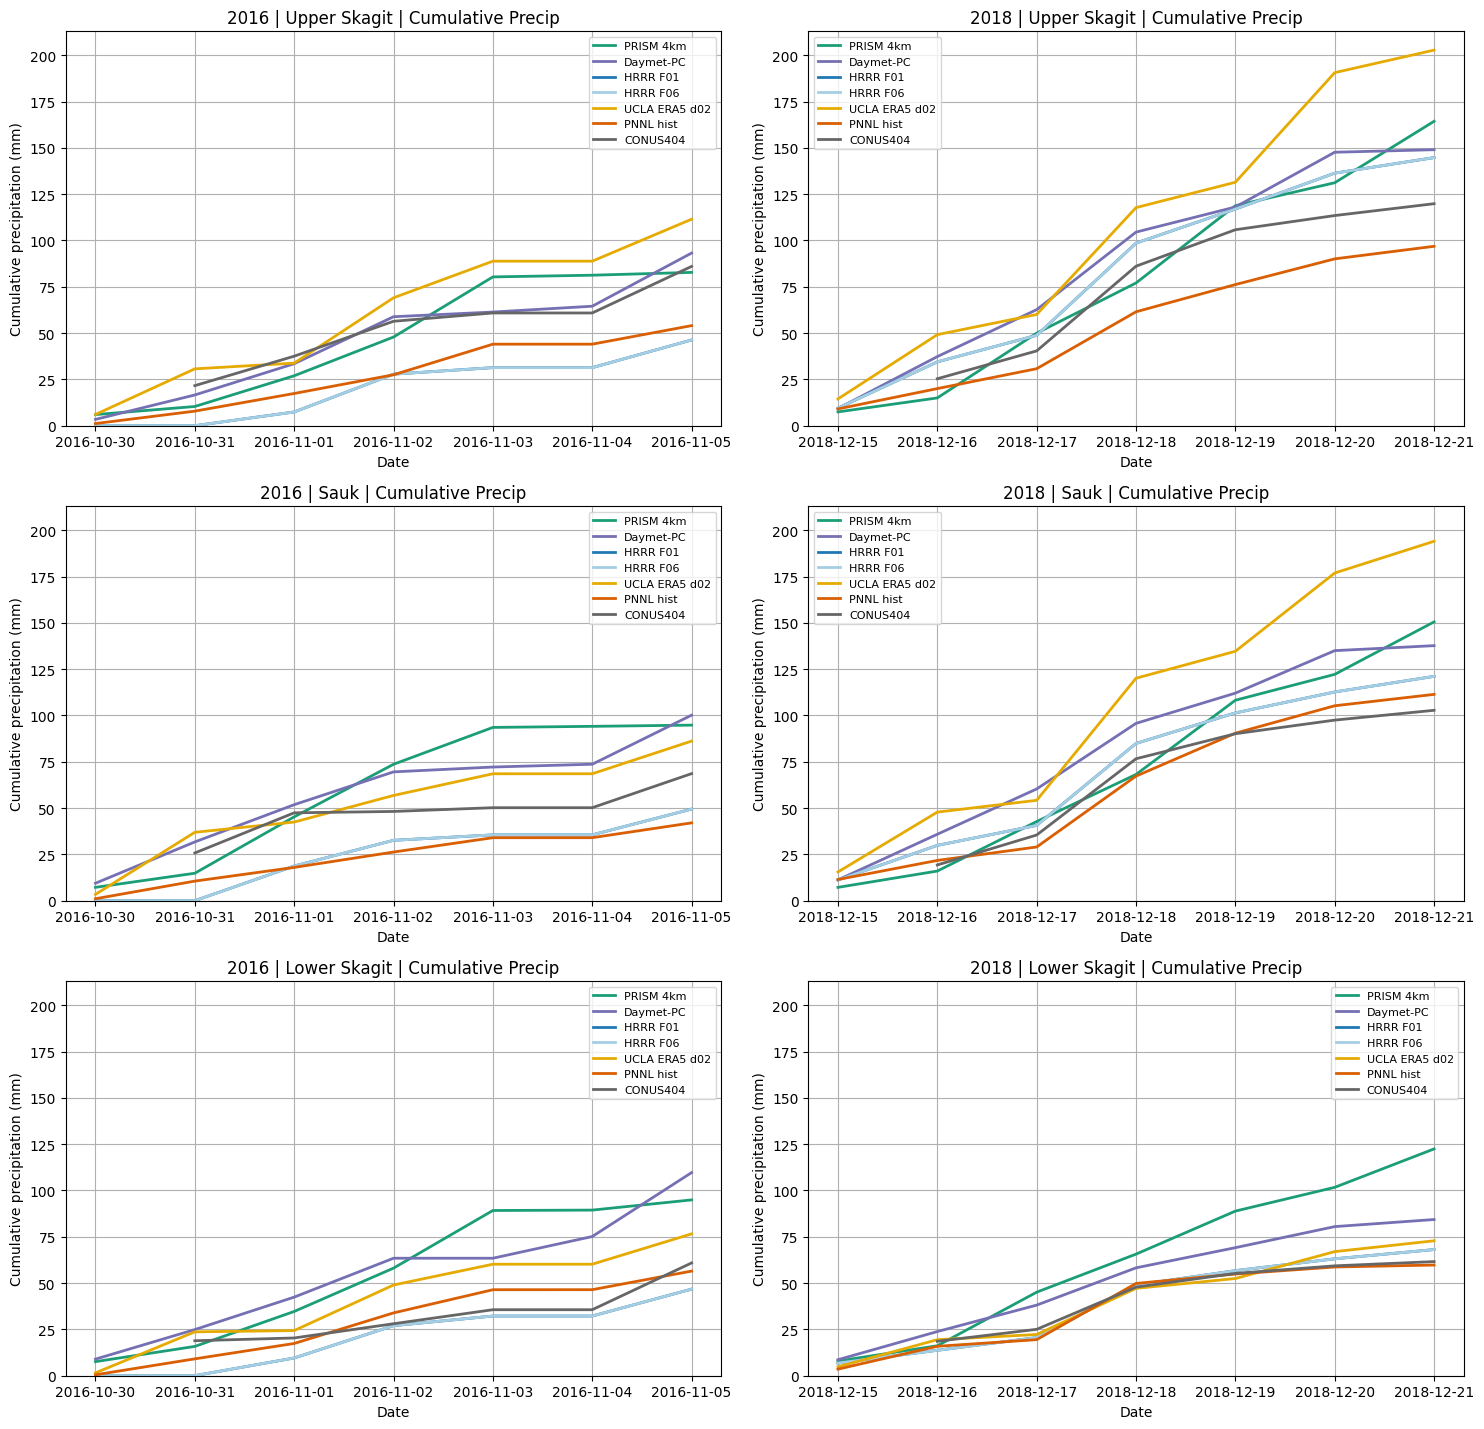


Saved MAE CSV → /data0/balaji24/data/derived/event_mae_vs_prism4km_mm_per_day__SUBBASINS.csv
    event_year       start         end        region  reference  \
0         2016  2016-10-30  2016-11-05  Lower Skagit  PRISM 4km   
1         2016  2016-10-30  2016-11-05  Lower Skagit  PRISM 4km   
2         2016  2016-10-30  2016-11-05  Lower Skagit  PRISM 4km   
3         2016  2016-10-30  2016-11-05  Lower Skagit  PRISM 4km   
4         2016  2016-10-30  2016-11-05  Lower Skagit  PRISM 4km   
5         2016  2016-10-30  2016-11-05  Lower Skagit  PRISM 4km   
6         2016  2016-10-30  2016-11-05          Sauk  PRISM 4km   
7         2016  2016-10-30  2016-11-05          Sauk  PRISM 4km   
8         2016  2016-10-30  2016-11-05          Sauk  PRISM 4km   
9         2016  2016-10-30  2016-11-05          Sauk  PRISM 4km   
10        2016  2016-10-30  2016-11-05          Sauk  PRISM 4km   
11        2016  2016-10-30  2016-11-05          Sauk  PRISM 4km   
12        2016  2016-10-30  2016-11

In [ ]:
# ============================================================
# Skagit Basin – Event CUMULATIVE Precip comparison + VERIFICATION + MAE vs PRISM 4km
# NOW WITH SUB-BASIN PLOTS (Upper Skagit / Sauk / Lower Skagit)
#
# SOURCES:
# - PRISM (local zarr)                         BASE/prism_ppt
# - Daymet v4 (Planetary Computer)             (external zarr via STAC + SAS) 
# - HRRR (monthly zarr stitched)               BASE/weather_data   NOW: HRRR F01 + HRRR F06
# - UCLA ERA5 WRF d02 (daily NetCDF)           /data0/.../ucla_era5_d02_daily/prec
# - PNNL historical WRF (hourly NetCDF)        BASE/PNNL/historical
# - CONUS404 (external OSN via HyTEST intake)  conus404-daily-osn
#
# Fixes included:
# Daymet: fresh SAS per event + eager .load() + close session
# Daymet: avoid "multiple values for consolidated" by removing consolidated from open_kwargs
# PNNL + CONUS404 included in plots + MAE
# sub-basin plots + MAE per sub-basin
# basin_mean_daily_from_gridded() no longer throws UnboundLocalError
# consistent colors across ALL subplots (hard-coded palette)
# same y-axis scale across ALL subplots
# ============================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
import regionmask
import intake
import shapely
import sys, time
from urllib.parse import urlsplit, urlunsplit


# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/balaji24/data")

P_PRISM_DIR = BASE / "prism_ppt"
P_HRRR_DIR  = BASE / "weather_data"

# UCLA ERA5 WRF d02 daily NetCDF
UCLA_PREC_DIR      = Path("/data0/balaji24/data/ucla_era5_d02_daily/prec")
UCLA_PREC_TEMPLATE = "prec.daily.era5.d02.{year}.nc"
UCLA_COORD_FILE    = Path("/data0/balaji24/data/ucla_era5_d02_daily/static/wrfinput_d02_coord.nc")

# PNNL historical (hourly NetCDF per year) + geo grid for mask
P_PNNL_DIR = BASE / "PNNL" / "historical"
P_PNNL_GEO = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"

# Basin boundary (still used for reference / optional)
BOUNDARY_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json")

# Sub-basin polygons (HUC8)
HUC8_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitSubBasin_HUC8.geojson")
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)
MAE_CSV = OUT / "event_mae_vs_prism4km_mm_per_day__SUBBASINS.csv"

# External (CONUS404)
CONUS_INTAKE_YML = (
    "https://raw.githubusercontent.com/hytest-org/hytest/main/"
    "dataset_catalog/hytest_intake_catalog.yml"
)
CONUS_MAX_TIME = np.datetime64("2022-10-01")

# ----------------------------
# EVENTS
# ----------------------------
events = [
    {"event_year": 2016, "start": "2016-10-30", "end": "2016-11-05"},
    {"event_year": 2018, "start": "2018-12-15", "end": "2018-12-21"},
]

# ============================================================
# ONE CANONICAL COLOR PALETTE 
# - Hard-coded HEX so colors never shift.
# - HRRR F01 vs HRRR F06 are different colors.
# ============================================================
DATASET_ORDER = [
    "PRISM 4km",
    "PRISM 800m",
    "Daymet-PC",
    "HRRR F01",
    "HRRR F06",
    "UCLA ERA5 d02",
    "PNNL hist",
    "CONUS404",
]

COLORS = {
    # PRISM family (greens)
    "PRISM 4km":     "#1B9E77",
    "PRISM 800m":    "#66C2A5",

    # Daymet (purple)
    "Daymet-PC":     "#7570B3",

    # HRRR family (blues) — different shades per forecast hour
    "HRRR F01":      "#1F78B4",
    "HRRR F06":      "#A6CEE3",

    # UCLA ERA5 d02 (orange)
    "UCLA ERA5 d02": "#E6AB02",

    # PNNL hist (red/orange)
    "PNNL hist":     "#D95F02",

    # CONUS404 (gray)
    "CONUS404":      "#666666",
}


# ============================================================
# HELPERS
# ============================================================

def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def pick_var(ds, names):
    for n in names:
        if n in ds.data_vars:
            return n
    return None

def units_str(ds, var):
    return ds[var].attrs.get("units", "(missing)")

def print_units(ds, var, label):
    print(f"  - {label}: var='{var}', units='{units_str(ds, var)}'")

def load_basin_geom():
    gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    try:
        return gdf.geometry.union_all()
    except Exception:
        return gdf.geometry.unary_union

def load_subbasin_geoms():
    """
    Reads HUC8 geojson and returns dict {RegionName: shapely_geom} in EPSG:4326.
    Tries to match REGION_NAMES by name-like columns.
    """
    if not HUC8_GEO.exists():
        raise FileNotFoundError(f"Missing sub-basin geojson: {HUC8_GEO}")

    gdf = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

    name_cols = [c for c in gdf.columns if c.lower() in ("name", "names", "huc8_name", "subbasin", "basin", "huc_name")]
    if not name_cols:
        name_cols = [c for c in gdf.columns if "name" in c.lower()]

    if not name_cols:
        raise RuntimeError(f"Could not find a name column in {HUC8_GEO}. Columns={list(gdf.columns)}")

    name_col = name_cols[0]
    geoms = {}
    gdf["_nm_"] = gdf[name_col].astype(str).str.strip()

    for target in REGION_NAMES:
        sub = gdf[gdf["_nm_"].str.lower() == target.lower()]
        if sub.empty:
            sub = gdf[gdf["_nm_"].str.lower().str.contains(target.lower(), regex=False)]
        if sub.empty:
            raise RuntimeError(f"Could not match region '{target}' in {HUC8_GEO} using column '{name_col}'")

        try:
            geom = sub.geometry.union_all()
        except Exception:
            geom = sub.geometry.unary_union
        geoms[target] = geom

    return geoms

def median_timestep_seconds(time_index):
    if len(time_index) < 2:
        return None
    dt = pd.Series(time_index).diff().dt.total_seconds().median()
    return float(dt) if pd.notnull(dt) else None

def ensure_daily_sum(da):
    """Sum to daily totals (safe for both hourly and daily)."""
    if da is None or "time" not in da.dims:
        return da
    t = pd.to_datetime(da["time"].values)
    dt = median_timestep_seconds(t)
    if dt is None:
        return da
    return da.resample(time="1D").sum()

def is_plottable_1d(da):
    if da is None:
        return False
    if da.ndim != 1 or da.size == 0:
        return False
    try:
        v = da.values
        return np.isfinite(v).any()
    except Exception:
        return False

def reset_safe_increment(acc_like_1d):
    """
    Reset-safe increments for an accumulated series (1D time):
      inc[t] = diff if diff>=0 else current_value (reset)
    Output aligns to time[1:].
    """
    d = acc_like_1d.diff("time")
    curr = acc_like_1d.isel(time=slice(1, None))
    inc = xr.where(d >= 0, d, curr)
    return inc.clip(min=0)

def accumulated_to_daily_mm(acc_like_1d, label):
    """
    Convert accumulated precip (mm) -> increments (mm/step) -> daily totals (mm/day).
    acc_like_1d MUST be 1D (time).
    """
    bm = acc_like_1d
    if bm.size < 3:
        return bm.clip(min=0).resample(time="1D").sum()

    d = bm.diff("time")
    frac_neg = float((d < 0).mean())
    mean_raw = float(bm.mean())
    mean_diff_pos = float(d.clip(min=0).mean())
    print(f"    [{label}] accum-check: frac_neg={frac_neg:.3f}, mean_raw={mean_raw:.4g}, mean_diff_pos={mean_diff_pos:.4g}")

    inc = reset_safe_increment(bm)
    daily = ensure_daily_sum(inc)
    return daily


# ============================================================
# VERIFICATION PRINTS
# ============================================================

def debug_daily(label, daily_da):
    """Print distribution stats for a DAILY (mm/day) 1D time series."""
    if daily_da is None or "time" not in daily_da.dims or daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (empty)")
        return
    daily_da = daily_da.dropna("time")
    if daily_da.size == 0:
        print(f"\n[{label}] DAILY CHECK: (all NaN)")
        return
    print(f"\n[{label}] DAILY CHECK")
    print("  min:", float(daily_da.min()))
    print("  max:", float(daily_da.max()))
    print("  mean:", float(daily_da.mean()))
    print("  sum:", float(daily_da.sum()))

def _median_dt_hours_from_da(da):
    if da is None or "time" not in da.dims:
        return None
    t = pd.to_datetime(da["time"].values)
    if len(t) < 2:
        return None
    dt_hours = pd.Series(t).diff().dt.total_seconds().dropna().median() / 3600.0
    return float(dt_hours) if pd.notnull(dt_hours) else None

def verify_daily_and_cumsum(label, daily_da, cum_da=None, top_n=5):
    """
    Verifies:
      - dt sanity
      - daily stats
      - sum(daily) == last(cumsum) (if cum passed)
      - top-N daily increments
    """
    if daily_da is None or daily_da.size == 0:
        print(f"\n===== VERIFY: {label} =====")
        print("  (no data)")
        return

    daily_da = daily_da.dropna("time").sortby("time")
    print(f"\n===== VERIFY: {label} =====")
    dt_hours = _median_dt_hours_from_da(daily_da)
    if dt_hours is not None:
        print(f"  median dt (hours): {dt_hours:.2f}")

    debug_daily(label, daily_da)

    if cum_da is not None and is_plottable_1d(cum_da):
        try:
            cum_last = float(cum_da.dropna("time").isel(time=-1))
            daily_sum = float(daily_da.sum())
            print("  CHECK: daily.sum vs cum[-1]:", daily_sum, cum_last, " | diff:", daily_sum - cum_last)
        except Exception as e:
            print("  CHECK: daily.sum vs cum[-1]: (failed)", repr(e))

    try:
        top = daily_da.sortby(daily_da, ascending=False).isel(time=slice(0, min(top_n, daily_da.size)))
        print(f"  TOP {min(top_n, daily_da.size)} daily values:")
        for tt, vv in zip(pd.to_datetime(top["time"].values), np.asarray(top.values)):
            print("   ", tt.date(), float(vv))
    except Exception as e:
        print("  TOP daily values: (failed)", repr(e))


# ============================================================
# MASKING UTIL (REGION MEAN ON ANY GRID WITH lon/lat)
# ============================================================

_MASK_CACHE = {}  # key -> xr.DataArray bool with spatial dims

def _geom_key(geom):
    try:
        return geom.wkb_hex
    except Exception:
        return str(geom)

def _infer_lonlat_vars(ds):
    lon_candidates = ["lon", "longitude", "XLONG", "XLONG_M", "xlong", "xlong_m"]
    lat_candidates = ["lat", "latitude", "XLAT", "XLAT_M", "xlat", "xlat_m"]

    def _get(name):
        if name in ds.coords:
            return ds.coords[name]
        if name in ds.data_vars:
            return ds.data_vars[name]
        if name in ds.variables:
            return ds[name]
        return None

    lon = None
    lat = None

    for n in lon_candidates:
        lon = _get(n)
        if lon is not None:
            break
    for n in lat_candidates:
        lat = _get(n)
        if lat is not None:
            break

    if lon is None or lat is None:
        for v in list(ds.variables):
            if lon is None and "lon" in v.lower() and getattr(ds[v], "ndim", 0) >= 1:
                lon = ds[v]
            if lat is None and "lat" in v.lower() and getattr(ds[v], "ndim", 0) >= 1:
                lat = ds[v]
            if lon is not None and lat is not None:
                break

    if lon is None or lat is None:
        return None, None

    for d in list(getattr(lon, "dims", [])):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})
    for d in list(getattr(lat, "dims", [])):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})

    return lon, lat

def _sorted_unique_time(da: xr.DataArray) -> xr.DataArray:
    if da is None or "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = pd.to_datetime(da["time"].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

# bm is always defined or we return None safely
def basin_mean_daily_from_gridded(ds, var, start, end, geom, label_for_print, assume_accumulated=False):
    if "time" not in ds.dims and "Time" in ds.dims:
        ds = ds.rename({"Time": "time"})
    if "time" not in ds[var].dims and ("Time" in ds[var].dims):
        ds = ds.rename({"Time": "time"})
    if "time" not in ds[var].dims:
        print(f"  - {label_for_print}: (no time dim on var '{var}')")
        return None

    da0 = _sorted_unique_time(ds[var])
    da = da0.sel(time=slice(start, end))
    if da.sizes.get("time", 0) == 0:
        print(f"  - {label_for_print}: (no data in window)")
        return None

    da = da.sortby("time")
    spatial = [d for d in da.dims if d != "time"]
    if len(spatial) not in (1, 2):
        print(f"  - {label_for_print}: unexpected spatial dims={spatial}")
        return None

    bm = None  # ALWAYS defined

    if len(spatial) == 1:
        bm = da.mean(dim=spatial, skipna=True)
    else:
        d0, d1 = spatial
        key = (label_for_print, _geom_key(geom), d0, d1, da.sizes[d0], da.sizes[d1])

        mask_da = _MASK_CACHE.get(key)
        if mask_da is None:
            lon, lat = _infer_lonlat_vars(ds)

            if lon is None or lat is None:
                print(f"  - {label_for_print}: could not infer lon/lat -> fallback to spatial mean")
                bm = da.mean(dim=spatial, skipna=True)
            else:
                try:
                    reg = regionmask.Regions([geom])
                    rid = reg.mask(lon, lat)
                    mask_geo = ~xr.ufuncs.isnan(rid)
                    mask_np = np.asarray(mask_geo.data).astype(bool)

                    if mask_np.shape == (da.sizes[d0], da.sizes[d1]):
                        pass
                    elif mask_np.shape == (da.sizes[d1], da.sizes[d0]):
                        mask_np = mask_np.T
                    else:
                        print(f"  - {label_for_print}: mask shape {mask_np.shape} != grid {(da.sizes[d0], da.sizes[d1])} -> fallback mean")
                        bm = da.mean(dim=spatial, skipna=True)

                    if bm is None:
                        mask_da = xr.DataArray(mask_np, dims=(d0, d1))
                        _MASK_CACHE[key] = mask_da
                except Exception as e:
                    print(f"  - {label_for_print}: mask build failed ({type(e).__name__}): {e} -> fallback mean")
                    bm = da.mean(dim=spatial, skipna=True)

        if bm is None:
            mask_da = _MASK_CACHE.get(key)
            if mask_da is None:
                bm = da.mean(dim=spatial, skipna=True)
            else:
                bm = da.where(mask_da).mean(dim=(d0, d1), skipna=True)

    units = str(da.attrs.get("units", "")).lower().strip()
    if units in {"m", "meter", "meters", "metre", "metres"}:
        bm = bm * 1000.0

    if assume_accumulated:
        bm_daily = accumulated_to_daily_mm(bm, label=f"{label_for_print} accum")
    else:
        bm_daily = ensure_daily_sum(bm)

    return bm_daily.sortby("time")


# ============================================================
# PRISM
# ============================================================

_PRISM_NAME_RE = re.compile(
    r"(?P<s>\d{4}-\d{2}-\d{2})_(?P<e>\d{4}-\d{2}-\d{2})_daily_(?P<tag>4km|800m)_PRISM_data\.zarr$"
)

def find_prism_zarr_covering(start, end, tag):
    start = pd.Timestamp(start)
    end   = pd.Timestamp(end)

    candidates = []
    for p in P_PRISM_DIR.glob(f"*_daily_{tag}_PRISM_data.zarr"):
        m = _PRISM_NAME_RE.search(p.name)
        if not m:
            continue
        f0 = pd.Timestamp(m.group("s"))
        f1 = pd.Timestamp(m.group("e"))
        if f0 <= start and f1 >= end:
            span_days = (f1 - f0).days
            candidates.append((span_days, f0, p))

    if not candidates:
        return None

    candidates.sort(key=lambda t: (t[0], -t[1].value))
    return candidates[0][2]

def load_prism_daily(start, end, tag, geom, region_label, do_verify=True):
    z = find_prism_zarr_covering(start, end, tag)
    if z is None:
        print(f"  - PRISM {tag}: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["ppt", "precip", "prcp"])
    if var is None:
        print(f"  - PRISM {tag} [{z.name}]: (no precip var found)")
        ds.close()
        return None

    print_units(ds, var, f"PRISM {tag} [{z.name}]")
    bm_daily = basin_mean_daily_from_gridded(
        ds, var, start, end, geom,
        label_for_print=f"PRISM {tag} | {region_label}",
        assume_accumulated=False
    )

    if bm_daily is not None and do_verify:
        verify_daily_and_cumsum(f"PRISM {tag} | {region_label}", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily


# ============================================================
# Daymet (Planetary Computer) — FIXED consolidated conflict + eager load
# ============================================================

def ensure_daymet_pkgs():
    needed = ["pystac-client", "planetary-computer", "pyproj", "fsspec", "zarr"]
    import importlib, subprocess
    missing = []
    for p in needed:
        mod = p.replace("-", "_")
        try:
            importlib.import_module(mod)
        except Exception:
            missing.append(p)
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

ensure_daymet_pkgs()

from pystac_client import Client
import planetary_computer as pc
from pyproj import CRS, Transformer
from fsspec.implementations.http import HTTPFileSystem
from shapely.ops import transform as shp_transform

class SASEndAppendingHTTPFileSystem(HTTPFileSystem):
    def __init__(self, sas_query: str, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._sas_query = sas_query.lstrip("?")

    def _with_sas(self, url: str) -> str:
        return url if "?" in url else f"{url}?{self._sas_query}"

    def _open(self, path, mode="rb", block_size=None, **kwargs):
        return super()._open(self._with_sas(path), mode=mode, block_size=block_size, **kwargs)

    async def _cat_file(self, url, start=None, end=None, **kwargs):
        return await super()._cat_file(self._with_sas(url), start=start, end=end, **kwargs)

def daymet_lcc_crs():
    return CRS.from_proj4(
        "+proj=lcc +lat_1=25 +lat_2=60 +lat_0=42.5 +lon_0=-100 "
        "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )

_DAYMET_TFM_LL_TO_XY = Transformer.from_crs("EPSG:4326", daymet_lcc_crs(), always_xy=True)

def get_daymet_mapper_and_fs():
    stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
    col = stac.get_collection("daymet-daily-na")
    asset_key = "zarr-https" if "zarr-https" in col.assets else "zarr-abfs"
    signed_href = pc.sign(col.assets[asset_key].href)

    parts = urlsplit(signed_href)
    root_no_query = urlunsplit((parts.scheme, parts.netloc, parts.path, "", ""))
    sas_query = parts.query

    fs = SASEndAppendingHTTPFileSystem(sas_query)
    mapper = fs.get_mapper(root_no_query)

    open_kwargs = col.assets[asset_key].extra_fields.get("xarray:open_kwargs", {})
    return mapper, fs, open_kwargs

def lonlat_to_daymet_xy_bounds(geom_wgs84, pad_m=5000.0):
    minx, miny, maxx, maxy = geom_wgs84.bounds
    corners = [(minx, miny), (minx, maxy), (maxx, miny), (maxx, maxy)]
    xs, ys = zip(*[_DAYMET_TFM_LL_TO_XY.transform(lon, lat) for lon, lat in corners])
    return (float(min(xs) - pad_m), float(max(xs) + pad_m),
            float(min(ys) - pad_m), float(max(ys) + pad_m))

def _daymet_project_geom_to_xy(geom_ll):
    def _proj(x, y, z=None):
        return _DAYMET_TFM_LL_TO_XY.transform(x, y)
    return shp_transform(_proj, geom_ll)

_DAYMET_MASK_CACHE = {}

def load_daymet_pc_daily(start, end, geom_ll, region_label, do_verify=True):
    for attempt in range(1, 4):
        ds = None
        fs = None
        try:
            mapper, fs, open_kwargs = get_daymet_mapper_and_fs()

            open_kwargs = dict(open_kwargs)
            open_kwargs.pop("consolidated", None)  # avoid multiple values for consolidated

            ds = xr.open_zarr(mapper, **open_kwargs)

            if "prcp" not in ds:
                raise RuntimeError("Daymet dataset missing 'prcp'")

            print_units(ds, "prcp", "Daymet-PC (Daymet v4)")
            prcp = ds["prcp"]

            units = str(prcp.attrs.get("units", "")).lower().strip()
            if units in {"m", "meter", "meters", "metre", "metres"}:
                prcp = prcp * 1000.0
                prcp.attrs["units"] = "mm"

            xmin, xmax, ymin, ymax = lonlat_to_daymet_xy_bounds(geom_ll, pad_m=5000.0)

            y0 = float(ds["y"].values[0])
            y1 = float(ds["y"].values[-1])
            y_slice = slice(ymax, ymin) if y0 > y1 else slice(ymin, ymax)

            pr = prcp.sel(time=slice(start, end), x=slice(xmin, xmax), y=y_slice).chunk({"time": -1, "y": 256, "x": 256})
            if pr.sizes.get("time", 0) == 0:
                print("  - Daymet-PC: (no data in window)")
                return None

            pr = _sorted_unique_time(pr).sortby("time")

            key = (
                region_label,
                _geom_key(geom_ll),
                float(pr["x"].values[0]), float(pr["x"].values[-1]),
                float(pr["y"].values[0]), float(pr["y"].values[-1]),
                int(pr.sizes["x"]), int(pr.sizes["y"]),
            )

            mask = _DAYMET_MASK_CACHE.get(key)
            if mask is None:
                xx, yy = xr.broadcast(pr["x"], pr["y"])
                geom_xy = _daymet_project_geom_to_xy(geom_ll)
                from shapely import contains_xy
                mask_np = contains_xy(geom_xy, np.asarray(xx.values), np.asarray(yy.values))
                mask = xr.DataArray(mask_np, dims=xx.dims, coords=xx.coords)
                _DAYMET_MASK_CACHE[key] = mask

            bm_daily = pr.where(mask).mean(dim=("y", "x"), skipna=True)
            bm_daily = ensure_daily_sum(bm_daily).sortby("time")

            bm_daily = bm_daily.load()  # eager load

            if do_verify:
                verify_daily_and_cumsum(f"Daymet-PC | {region_label}", bm_daily, bm_daily.cumsum("time"))

            return bm_daily

        except Exception as e:
            print(f"[DAYMET-PC] attempt {attempt}/3 failed ({type(e).__name__}): {e}")
            time.sleep(5 * attempt)
        finally:
            if ds is not None:
                try: ds.close()
                except Exception: pass
            if fs is not None:
                try: fs.close_session()
                except Exception: pass

    print("  - Daymet-PC: (failed after retries)")
    return None


# ============================================================
# HRRR (monthly stitched) — NOW supports selecting F01 or F06
# ============================================================

def hrrr_hourly_precip_mm(ds, var="tp"):
    """
    Converts an accumulated-looking hourly series to increments (mm/hour).
    If it doesn't look accumulated, returns unchanged.
    """
    da = ds[var]
    probe = da.isel({k: 0 for k in da.dims if k not in ("time", "step", "forecast_hour")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9

    if not is_cum:
        return da

    da = da.sortby("time")
    dif = da.diff("time", label="upper")
    dif = xr.where(dif < 0, 0, dif)
    dif = dif.fillna(0)

    # prepend 0 at first timestep so same length as original
    dif = xr.concat([da.isel(time=slice(0, 1)) * 0, dif], dim="time")
    return dif

def _pick_hrrr_step_value(step_da: xr.DataArray, fh_hours: int):
    """
    Return a step coordinate value matching fh_hours.
    Handles step stored as timedelta64 or numeric hours.
    """
    if np.issubdtype(step_da.dtype, np.timedelta64):
        target = np.timedelta64(fh_hours, "h")
        diffs = np.abs(step_da.values - target)
        idx = int(np.argmin(diffs))
        return step_da.values[idx]

    try:
        vals = step_da.values.astype(float)
        idx = int(np.argmin(np.abs(vals - float(fh_hours))))
        return step_da.values[idx]
    except Exception:
        return step_da.values[0]

def hrrr_select_forecast_hour(da: xr.DataArray, fh_hours: int) -> xr.DataArray:
    """
    Select HRRR forecast hour from a DataArray if a forecast/step dimension exists.
    Supports dims: 'step' (most common), or 'forecast_hour'.
    """
    if "step" in da.dims:
        sv = _pick_hrrr_step_value(da["step"], fh_hours)
        out = da.sel(step=sv)
        out.attrs.update(da.attrs)
        return out

    if "forecast_hour" in da.dims:
        vals = da["forecast_hour"].values.astype(float)
        idx = int(np.argmin(np.abs(vals - float(fh_hours))))
        out = da.isel(forecast_hour=idx)
        out.attrs.update(da.attrs)
        return out

    return da

def load_hrrr_daily(start, end, geom, region_label, do_verify=True, fh_hours=1):
    """
    HRRR stitched monthly zarr -> select forecast hour (F01 or F06),
    then convert to daily totals and region-mean.
    """
    if not P_HRRR_DIR.exists():
        print("  - HRRR: (dir missing)")
        return None

    monthly = sorted([p for p in P_HRRR_DIR.glob("*.zarr") if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)])
    if not monthly:
        print("  - HRRR: (no monthly zarrs found)")
        return None

    start_ts = pd.Timestamp(start)
    end_ts   = pd.Timestamp(end)
    need = pd.period_range(start_ts.to_period("M"), end_ts.to_period("M"), freq="M")
    need_prefixes = {f"{p.year}-{p.month:02d}" for p in need}

    available = {p.name[:7] for p in monthly}
    missing = sorted(list(need_prefixes - available))
    if missing:
        print(f"  - HRRR: missing months {missing} -> skipping HRRR for this event")
        return None

    parts = sorted([p for p in monthly if p.name[:7] in need_prefixes], key=lambda p: p.name[:7])

    ds0 = safe_open_zarr(parts[0])
    var = "tp" if "tp" in ds0 else ("apcp" if "apcp" in ds0 else None)
    if not var:
        print(f"  - HRRR: no tp/apcp in {parts[0].name} -> skipping")
        try: ds0.close()
        except Exception: pass
        return None

    dsets = []
    ok = True
    for p in parts:
        dsm = safe_open_zarr(p)
        if var not in dsm:
            print(f"  - HRRR: {p.name} missing {var} -> skipping")
            try: dsm.close()
            except Exception: pass
            ok = False
            break
        dsets.append(dsm[[var]])

    if not ok:
        for d in dsets:
            try: d.close()
            except Exception: pass
        try: ds0.close()
        except Exception: pass
        return None

    ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override").sortby("time")
    print_units(ds, var, f"HRRR (stitched monthly zarr) | F{fh_hours:02d}")

    # Select forecast hour (F01 vs F06) if possible
    da = hrrr_select_forecast_hour(ds[var], fh_hours=fh_hours)

    # Convert to hourly increments if series looks accumulated
    hourly_mm = hrrr_hourly_precip_mm(xr.Dataset({var: da}), var=var)

    # Daily totals
    daily = hourly_mm.resample(time="1D").sum()

    ds_daily = xr.Dataset({var: daily})
    for c in ["lon", "lat", "longitude", "latitude", "XLONG", "XLAT", "XLONG_M", "XLAT_M"]:
        if c in ds0:
            ds_daily[c] = ds0[c]

    bm_daily = basin_mean_daily_from_gridded(
        ds_daily, var, start, end, geom,
        label_for_print=f"HRRR F{fh_hours:02d} | {region_label}",
        assume_accumulated=False
    )

    if bm_daily is not None and do_verify:
        verify_daily_and_cumsum(f"HRRR F{fh_hours:02d} | {region_label}", bm_daily, bm_daily.cumsum("time"))

    for d in dsets:
        try: d.close()
        except Exception: pass
    try: ds0.close()
    except Exception: pass

    return bm_daily


# ============================================================
# UCLA ERA5 d02 (daily NetCDF) — per-region mask cache
# ============================================================

def ucla_file_label_for_date(dt: pd.Timestamp) -> int:
    return dt.year if dt.month >= 9 else (dt.year - 1)

def open_ucla_prec_for_window(t0: str, t1: str):
    t0_ts = pd.Timestamp(t0)
    t1_ts = pd.Timestamp(t1)
    labels_needed = sorted({ucla_file_label_for_date(t0_ts), ucla_file_label_for_date(t1_ts)})

    files = []
    for lab in labels_needed:
        f = UCLA_PREC_DIR / UCLA_PREC_TEMPLATE.format(year=lab)
        if f.exists():
            files.append(str(f))

    if not files:
        return None, []

    dsets = []
    pr_list = []
    for f in files:
        ds = xr.open_dataset(f, engine="netcdf4", decode_cf=True, mask_and_scale=True)
        if "prec" not in ds:
            ds.close()
            continue
        pr = ds["prec"]
        if "time" not in pr.dims:
            tdim = "day" if "day" in pr.dims else None
            if tdim is None:
                for d in pr.dims:
                    if "time" in d.lower() or "day" in d.lower():
                        tdim = d
                        break
            if tdim is not None and tdim != "time":
                pr = pr.rename({tdim: "time"})
        pr_list.append(pr)
        dsets.append(ds)

    if not pr_list:
        return None, []

    pr_all = xr.concat(pr_list, dim="time", join="outer", coords="minimal", compat="override")
    pr_all = pr_all.sortby("time")
    try:
        tt = pd.to_datetime(pr_all["time"].values)
        _, idx = np.unique(tt, return_index=True)
        pr_all = pr_all.isel(time=np.sort(idx))
    except Exception:
        pass

    pr_all = pr_all.sel(time=slice(t0, t1))
    if pr_all.sizes.get("time", 0) == 0:
        for ds in dsets:
            try: ds.close()
            except Exception: pass
        return None, []

    return pr_all, dsets

_UCLA_MASKS = {}  # region_label -> mask2d

def build_ucla_basin_mask(coord_file: Path, geom):
    g = xr.open_dataset(coord_file, engine="netcdf4")
    lat = g["lat2d"].squeeze(drop=True).astype("float64")
    lon = g["lon2d"].squeeze(drop=True).astype("float64")
    g.close()

    lonv = lon.values.ravel()
    latv = lat.values.ravel()
    ny, nx = lon.shape

    try:
        from shapely import contains_xy
        m_flat = contains_xy(geom, lonv, latv)
    except Exception:
        import shapely as _sh
        from shapely.prepared import prep
        pg = prep(geom)
        m_flat = np.array([pg.contains(_sh.Point(x, y)) for x, y in zip(lonv, latv)], dtype=bool)

    mask2d = m_flat.reshape(ny, nx).astype(bool)
    return xr.DataArray(mask2d, dims=lon.dims, coords=lon.coords)

def load_ucla_era5_d02_daily(start, end, geom, region_label, do_verify=True):
    if not UCLA_PREC_DIR.exists() or not UCLA_COORD_FILE.exists():
        print("  - UCLA ERA5 d02: (missing dir or coord file)")
        return None

    pr, parents = open_ucla_prec_for_window(start, end)
    if pr is None:
        print("  - UCLA ERA5 d02: (no files / no data in window)")
        return None

    try:
        print(f"  - UCLA ERA5 d02: var='prec', units='{pr.attrs.get('units', '(missing)')}'")

        units = str(pr.attrs.get("units", "")).lower().strip()
        if units in {"m", "meter", "meters", "metre", "metres"}:
            pr = pr * 1000.0
            pr.attrs["units"] = "mm"

        if region_label not in _UCLA_MASKS:
            _UCLA_MASKS[region_label] = build_ucla_basin_mask(UCLA_COORD_FILE, geom)
            m2d = _UCLA_MASKS[region_label]
            print(f"    [UCLA | {region_label}] mask cells inside: {int(m2d.sum())} / {m2d.size}")

        spatial = [d for d in pr.dims if d != "time"]
        if len(spatial) != 2:
            print(f"  - UCLA ERA5 d02: unexpected spatial dims={spatial}")
            return None

        mask = _UCLA_MASKS[region_label]
        if set(mask.dims) != set(spatial):
            rename_map = {}
            for md in mask.dims:
                for pdim in spatial:
                    if mask.sizes[md] == pr.sizes[pdim]:
                        rename_map[md] = pdim
                        break
            mask = mask.rename(rename_map)

        bm = pr.where(mask).mean(dim=spatial, skipna=True)
        bm_daily = ensure_daily_sum(bm).sortby("time")
        if do_verify:
            verify_daily_and_cumsum(f"UCLA ERA5 d02 | {region_label}", bm_daily, bm_daily.cumsum("time"))
        return bm_daily

    finally:
        for ds in parents:
            try: ds.close()
            except Exception: pass


# ============================================================
# PNNL hist (hourly accum → daily) — per-region mask cache
# ============================================================

_PNNL_MASKS = {}  # (region_label, grid_key) -> mask

def build_pnnl_mask_for_ds(ds_prec, geom):
    spatial = [d for d in ds_prec["PREC_ACC_NC"].dims if d != "time"]
    if len(spatial) != 2:
        raise RuntimeError(f"[PNNL] Unexpected spatial dims: {spatial}")

    d0, d1 = spatial[0], spatial[1]
    s0, s1 = ds_prec.sizes[d0], ds_prec.sizes[d1]

    geo = xr.open_dataset(P_PNNL_GEO)

    lat_name = next((c for c in ["XLAT_M", "XLAT", "lat", "LAT"] if c in geo), None)
    lon_name = next((c for c in ["XLONG_M", "XLONG", "lon", "LON"] if c in geo), None)
    if lat_name is None or lon_name is None:
        geo.close()
        raise RuntimeError(f"[PNNL geo] Could not find lat/lon vars. vars={list(geo.data_vars)[:60]}")

    lat = geo[lat_name]
    lon = geo[lon_name]

    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})
    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})

    region = regionmask.Regions([geom])
    m = region.mask(lon, lat)
    mask_geo = ~xr.ufuncs.isnan(m)
    mask_np = np.asarray(mask_geo.data).astype(bool)
    geo.close()

    if mask_np.shape == (s0, s1):
        pass
    elif mask_np.shape == (s1, s0):
        mask_np = mask_np.T
    else:
        raise RuntimeError(
            f"[PNNL] Mask shape {mask_np.shape} does not match precip grid ({d0},{d1})={(s0,s1)}"
        )

    return xr.DataArray(mask_np, dims=(d0, d1))

def load_pnnl_daily(year, start, end, geom, region_label, do_verify=True):
    f1 = P_PNNL_DIR / str(year) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc"
    if f1.exists():
        f = f1
    else:
        cands = sorted((P_PNNL_DIR / str(year)).glob("*PREC_ACC_NC*.nc"))
        f = cands[0] if cands else None

    if f is None or not f.exists():
        print("  - PNNL hist: (not available)")
        return None

    ds = xr.open_dataset(f, chunks={"time": 24})
    if "PREC_ACC_NC" not in ds:
        print("  - PNNL hist: (PREC_ACC_NC missing)")
        ds.close()
        return None

    print_units(ds, "PREC_ACC_NC", f"PNNL hist [{f.name}]")

    spatial = [d for d in ds["PREC_ACC_NC"].dims if d != "time"]
    grid_key = (tuple(spatial), ds.sizes[spatial[0]], ds.sizes[spatial[1]])
    key = (region_label, grid_key)

    if key not in _PNNL_MASKS:
        _PNNL_MASKS[key] = build_pnnl_mask_for_ds(ds, geom)

    mask = _PNNL_MASKS[key]

    start_dt = pd.Timestamp(start)
    start_minus_1 = str(start_dt - pd.Timedelta(days=1))
    da = ds["PREC_ACC_NC"].sel(time=slice(start_minus_1, end)).sortby("time")
    bm_acc = da.where(mask).mean(dim=spatial, skipna=True)

    bm_daily = accumulated_to_daily_mm(bm_acc, label=f"PNNL hist | {region_label}").sortby("time")
    bm_daily = bm_daily.sel(time=slice(start, end))
    if do_verify:
        verify_daily_and_cumsum(f"PNNL hist | {region_label}", bm_daily, bm_daily.cumsum("time"))

    ds.close()
    return bm_daily


# ============================================================
# CONUS404 (external)
# ============================================================

_conus_ds = None
_conus_mask_cache = {}  # region_label -> mask

def get_conus():
    global _conus_ds
    if _conus_ds is None:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        _conus_ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    return _conus_ds

def load_conus_daily(start, end, geom, region_label, do_verify=True):
    global _conus_mask_cache

    if np.datetime64(end) > CONUS_MAX_TIME:
        print("  - CONUS404: skipped (out of range)")
        return None

    ds = get_conus()
    var = pick_var(ds, ["PREC_ACC_NC", "prcp", "precip", "precipitation", "PREC", "PRECIP", "RAIN", "RAINNC", "RAINC"])
    if var is None:
        print("  - CONUS404: (no precip var found)")
        return None

    print_units(ds, var, "CONUS404")

    if region_label not in _conus_mask_cache:
        lon = ds["lon"]
        lat = ds["lat"]
        mask_np = shapely.contains_xy(geom, lon.values, lat.values)
        _conus_mask_cache[region_label] = xr.DataArray(mask_np, dims=("y", "x"))

    mask = _conus_mask_cache[region_label]

    start_dt = pd.Timestamp(start)
    start_minus_1 = str(start_dt - pd.Timedelta(days=1))
    da = ds[var].sel(time=slice(start_minus_1, end)).sortby("time")
    bm = da.where(mask).mean(dim=("y", "x"), skipna=True)

    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = ("accum" in var.lower()) or ("accumul" in desc) or (var.upper() in ("RAINNC", "RAINC", "PREC_ACC_NC"))
    if looks_accum:
        bm_daily = accumulated_to_daily_mm(bm, label=f"CONUS404 accum | {region_label}")
        bm_daily = bm_daily.sel(time=slice(start, end))
    else:
        bm_daily = ensure_daily_sum(bm).sel(time=slice(start, end))

    bm_daily = bm_daily.sortby("time")
    if do_verify:
        verify_daily_and_cumsum(f"CONUS404 | {region_label}", bm_daily, bm_daily.cumsum("time"))
    return bm_daily


# ============================================================
# MAE util
# ============================================================

def mae_vs_reference_mm_per_day(ref_daily, other_daily):
    if ref_daily is None or other_daily is None:
        return np.nan, 0
    if ("time" not in ref_daily.dims) or ("time" not in other_daily.dims):
        return np.nan, 0

    a = ref_daily.dropna("time").sortby("time")
    b = other_daily.dropna("time").sortby("time")

    a2, b2 = xr.align(a, b, join="inner")
    if a2.size == 0 or b2.size == 0:
        return np.nan, 0

    diff = np.abs(a2 - b2)
    mae = float(diff.mean().values)
    n = int(diff.sizes.get("time", diff.size))
    return mae, n


# ============================================================
# MAIN (SUB-BASIN PLOTS) + SAME Y-SCALE ACROSS ALL SUBPLOTS
# ============================================================

def main():
    sub_geoms = load_subbasin_geoms()

    n_events = len(events)
    n_regions = len(REGION_NAMES)

    fig, axs = plt.subplots(
        n_regions, n_events,
        figsize=(7.5 * n_events, 4.8 * n_regions),
        squeeze=False
    )

    mae_rows = []
    global_ymax = 0.0  # force same y-scale across every subplot

    for c, ev in enumerate(events):
        yr = int(ev["event_year"])
        start = ev["start"]
        end = ev["end"]

        print(f"\n================ EVENT {yr} ({start} → {end}) ================")

        for r, region in enumerate(REGION_NAMES):
            geom = sub_geoms[region]
            ax = axs[r, c]

            print(f"\n----- Region: {region} -----")

            ref_daily = load_prism_daily(start, end, "4km", geom, region, do_verify=True)

            daily_series = [
                ("PRISM 4km",       ref_daily),
                ("PRISM 800m",      load_prism_daily(start, end, "800m", geom, region, do_verify=True)),
                ("Daymet-PC",       load_daymet_pc_daily(start, end, geom, region, do_verify=True)),
                ("HRRR F01",        load_hrrr_daily(start, end, geom, region, do_verify=True, fh_hours=1)),
                ("HRRR F06",        load_hrrr_daily(start, end, geom, region, do_verify=True, fh_hours=6)),
                ("UCLA ERA5 d02",   load_ucla_era5_d02_daily(start, end, geom, region, do_verify=True)),
                ("PNNL hist",       load_pnnl_daily(yr, start, end, geom, region, do_verify=True)),
                ("CONUS404",        load_conus_daily(start, end, geom, region, do_verify=True)),
            ]

            plotted_any = False
            for label, dly in daily_series:
                if is_plottable_1d(dly):
                    cum = dly.cumsum("time")
                    x = pd.to_datetime(cum["time"].values)
                    y = np.asarray(cum.values, dtype=float)

                    ax.plot(
                        x, y,
                        label=label,
                        color=COLORS.get(label, "#000000"),  # fallback black (shouldn't happen if labels match)
                        linewidth=2.0
                    )

                    if np.isfinite(y).any():
                        global_ymax = max(global_ymax, float(np.nanmax(y)))

                    plotted_any = True

            title_suffix = " (2-Week)" if is_2week else ""
            ax.set_title(f"{yr} | {region} | Cumulative Precip{title_suffix}")
            ax.set_xlabel("Date")
            ax.set_ylabel("Cumulative precipitation (mm)")
            ax.grid(True)
            if plotted_any:
                ax.legend(fontsize=8)

            # MAE rows (vs PRISM 4km)
            for label, dly in daily_series:
                if label == "PRISM 4km":
                    continue
                mae, n_days = mae_vs_reference_mm_per_day(ref_daily, dly)
                if n_days > 0 and np.isfinite(mae):
                    mae_rows.append({
                        "event_year": yr,
                        "start": start,
                        "end": end,
                        "region": region,
                        "reference": "PRISM 4km",
                        "dataset": label,
                        "mae_mm_per_day": mae,
                        "n_days": n_days,
                    })

    # force identical y-scale on every subplot
    if global_ymax > 0 and np.isfinite(global_ymax):
        ymax = global_ymax * 1.05  # small padding
        for ax in axs.ravel():
            ax.set_ylim(0, ymax)

    plt.tight_layout()
    plt.show()

    mae_df = pd.DataFrame(mae_rows).sort_values(["event_year", "region", "dataset"]).reset_index(drop=True)
    mae_csv_path = MAE_CSV
    if is_2week:
        mae_csv_path = MAE_CSV.parent / MAE_CSV.name.replace(".csv", "_2week.csv")
    mae_df.to_csv(mae_csv_path, index=False)
    print(f"\nSaved MAE CSV → {mae_csv_path}")
    print("\nSaved MAE CSV →", MAE_CSV)
    print(mae_df)

if __name__ == "__main__":
    main()

# Run 2-Week Cumulative Precipitation Analysis

In [ ]:
events_2021_2w = [{"event_year": 2021, "start": "2021-11-10", "end": "2021-11-23"}]
main(events_2021_2w, is_2week=True)

In [ ]:
events_others_2w = [
    {"event_year": 2003, "start": "2003-10-18", "end": "2003-10-31"},
    {"event_year": 2006, "start": "2006-11-04", "end": "2006-11-17"},
    {"event_year": 2016, "start": "2016-10-30", "end": "2016-11-12"},
    {"event_year": 2018, "start": "2018-12-15", "end": "2018-12-28"}
]
main(events_others_2w, is_2week=True)